# Batch Light Comparison: Field Estimates vs. DSM/DTM-Derived Canopy Closure

This notebook batch-processes every point in `Daten_Lichtverprobung.csv` and compares
the **field observer's estimated canopy closure** (`Überschurmung_geschätzt`) against a
**canopy closure index derived from LDBV DSM/DTM data** (same DOM20/DGM1 pipeline as
`forestry_workflow.ipynb`).

Each point is identified by `Title` + `Versuchsfläche`.

## Derived closure index

For each point, a small circular buffer (`POINT_RADIUS_M`) is analyzed around the
GPS coordinate using the existing nDOM (DOM20 - DGM1) pipeline. The derived index is:

```
closure_index = proportion of valid nDOM pixels above CANOPY_HEIGHT_THRESHOLD_M
```

This ranges from **0** (no canopy above `CANOPY_HEIGHT_THRESHOLD_M` locally → open,
light reaches the ground, like the observer's "Licht" end) to **1** (fully covered by
canopy → closed, like the observer's "Geschlossen/Gedrängt" end) — directly
comparable to the observer's field impression, without inventing a new metric: it
reuses the same threshold-proportion calculation `canopy_histogram_ldbv` already
computes internally.

## Field categories (light → closed order used for comparison)

The CSV's `Überschurmung_geschätzt` field has 4 categories. They are used here only
as **ordinal labels** (not forced onto specific numeric values):

1. `Licht-Geschlossen/Licht` – open canopy, plenty of light
2. `Lücke > Baumlänge` – gap larger than tree height
3. `Lücke < Baumlänge` – gap smaller than tree height
4. `Geschlossen/Gedrängt` – closed, crowded stand

## Workflow

1. Load and clean the CSV
2. Configure analysis parameters + LDBV credentials
3. Group points into spatial clusters (so nearby points share one DSM/DTM download)
4. Download DOM20 + DGM1 once per cluster, derive nDOM
5. Run the per-point histogram analysis against the cached cluster raster
6. Collect results into a summary table + per-point histogram plots
7. Compare field category vs. derived index across all points

---

## Section 1: Setup

In [12]:
import sys
import os
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from modules import batch, ldbv_download, plotting
from canopy_histogram import canopy_histogram_ldbv

%matplotlib inline

print("Modules loaded successfully")

Modules loaded successfully


## Section 2: Load the CSV

`batch.load_light_points_csv` drops the trailing empty rows Survey123-style exports
leave behind, and builds:
- `point_id`  – human-readable `Title (Versuchsfläche)`, used in plot titles
- `point_slug` – filesystem-safe version, used in output filenames

In [13]:
CSV_PATH = r"C:\Users\lwfeckesim\34_light_availabilityP\Daten_Lichtverprobung.csv"

points_df = batch.load_light_points_csv(CSV_PATH)

print(f"Loaded {len(points_df)} points")
print()
print("Überschurmung_geschätzt category counts:")
print(points_df['Überschurmung_geschätzt'].value_counts())

points_df[['point_id', 'Latitude', 'Longitude', 'Hauptbaumart_Verjüngung', 'Überschurmung_geschätzt']].head(10)

Loaded 35 points

Überschurmung_geschätzt category counts:
Überschurmung_geschätzt
Licht-Geschlossen/Licht    13
Geschlossen/Gedrängt       11
Lücke > Baumlänge           6
Lücke < Baumlänge           5
Name: count, dtype: int64


,point_id,Latitude,Longitude,Hauptbaumart_Verjüngung,Überschurmung_geschätzt
0,LVP01 (EBE-f 152),48.128349,11.935212,Buche,Licht-Geschlossen/Licht
1,LVP02 (EBE-f 152),48.128216,11.935663,Buche,Lücke < Baumlänge
2,LVP03 (EBE-f 152),48.128374,11.936622,Fichte,Lücke > Baumlänge
3,LVP04 (EBE-f 152),48.128191,11.937883,Fichte,Lücke > Baumlänge
4,LVP05 (EBE-f 152),48.128354,11.939051,Buche,Lücke > Baumlänge
5,LVP06 (EBE-f 152),48.128846,11.939064,Buche,Licht-Geschlossen/Licht
6,LVP07 (EBE-f 152),48.129161,11.938490,Buche,Lücke > Baumlänge
7,LVP08 (EBE-f 152),48.129867,11.935807,Fichte,Licht-Geschlossen/Licht
8,LVP09 (EBE-f 152),48.129574,11.935080,Slbh,Licht-Geschlossen/Licht
9,LVP10 (EBE-f 152),48.129008,11.935065,Slbh,Licht-Geschlossen/Licht


## Section 3: Analysis Parameters

`POINT_RADIUS_M` is the local footprint analyzed around each GPS point — deliberately
much smaller than the 50m stand-level buffer used in `forestry_workflow.ipynb`, since
here we want the condition *at the point*, not the whole plot. Adjust and re-run if you
want a different footprint (e.g. larger to smooth out DSM/DTM noise, smaller to be more
local).

`CANOPY_HEIGHT_THRESHOLD_M` defines what counts as "canopy" for the closure index
(pixels above this height block light from above). 15m matches the mature-overstory
threshold already used elsewhere in this project.

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# ANALYSIS PARAMETERS
# ══════════════════════════════════════════════════════════════════════════════

# Local footprint analyzed around each point (meters)
POINT_RADIUS_M = 50

# Height classes for each point's histogram (meters)
HEIGHT_CLASSES = [0, 5, 10, 15, 25, 35, 50]

# Height above which a pixel counts as "canopy" for the derived closure index
CANOPY_HEIGHT_THRESHOLD_M = 15.0

# Raster resolution for the analysis (0.2m = DOM native)
TARGET_RESOLUTION_M = 0.2

# Max distance (meters) for chaining points into one shared download cluster
CLUSTER_MAX_DISTANCE_M = 500.0

# Field category order, light -> closed (used as axis order only, not numeric values)
CATEGORY_ORDER = [
    "Licht-Geschlossen/Licht",
    "Lücke > Baumlänge",
    "Lücke < Baumlänge",
    "Geschlossen/Gedrängt",
]

# Output locations
BATCH_TEMP_DIR = "../temp/batch"
PLOTS_DIR = "../plots/batch_points"
RESULTS_CSV = "../temp/light_comparison_results.csv"
COMPARISON_PLOT_PATH = "../plots/category_comparison.png"

os.makedirs(BATCH_TEMP_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f"Point radius: {POINT_RADIUS_M}m")
print(f"Canopy threshold: {CANOPY_HEIGHT_THRESHOLD_M}m")
print(f"Cluster distance: {CLUSTER_MAX_DISTANCE_M}m")
print(f"Category order (light -> closed): {CATEGORY_ORDER}")

Point radius: 50m
Canopy threshold: 15.0m
Cluster distance: 500.0m
Category order (light -> closed): ['Licht-Geschlossen/Licht', 'Lücke > Baumlänge', 'Lücke < Baumlänge', 'Geschlossen/Gedrängt']


In [24]:
# Optional: proxy for corporate networks
os.environ['HTTPS_PROXY'] = 'http://www-proxy.bayern.de:80'

# LDBV credentials: env vars are checked first, only prompts if missing
# and only when a cluster actually needs downloading (see Section 5)
print("Configuration ready.")

Configuration ready.


## Section 4: Cluster Points for Shared Downloads

35 points spread across 3 `Versuchsfläche` groups — some clusters are tight (a few
hundred meters), others (`EBE-any`) are scattered several km apart. Downloading DOM20 +
DGM1 per-point would repeatedly re-fetch the same tiles. Instead, points within
`CLUSTER_MAX_DISTANCE_M` of each other are grouped so each cluster is downloaded once.

In [25]:
points_df['cluster'] = batch.cluster_points_by_distance(
    points_df['Longitude'].values,
    points_df['Latitude'].values,
    max_distance_m=CLUSTER_MAX_DISTANCE_M
)

cluster_summary = batch.summarize_clusters(points_df)
print(f"{len(cluster_summary)} download cluster(s) for {len(points_df)} points:\n")
cluster_summary

6 download cluster(s) for 35 points:



,cluster,n_points,versuchsflaechen,lon_min,lon_max,lat_min,lat_max
0,0,10,EBE-f 152,11.935065,11.939064,48.128191,48.129867
1,1,13,"EBE-any, EBE-e 155",11.926782,11.940503,48.115912,48.120440
2,2,1,EBE-any,11.922177,11.922177,48.133066,48.133066
3,3,4,EBE-any,11.887647,11.890528,48.126549,48.126971
4,4,6,EBE-any,11.852740,11.854281,48.090629,48.091778
5,5,1,EBE-any,11.917029,11.917029,48.097422,48.097422


In [26]:
# Preview DOM20 tile counts per cluster before downloading anything
from modules.ldbv_download import compute_dom20_tiles

for cid, sub in points_df.groupby('cluster'):
    bbox = batch.cluster_bbox_25832(
        sub['Longitude'].values, sub['Latitude'].values,
        point_radius_m=POINT_RADIUS_M, margin_m=50.0
    )
    tiles = compute_dom20_tiles(*bbox)
    print(f"Cluster {cid}: {len(sub)} point(s), bbox size "
          f"{bbox[2]-bbox[0]:.0f}m x {bbox[3]-bbox[1]:.0f}m, {len(tiles)} DOM20 tile(s)")

Cluster 0: 10 point(s), bbox size 501m x 384m, 2 DOM20 tile(s)
Cluster 1: 13 point(s), bbox size 1235m x 666m, 2 DOM20 tile(s)
Cluster 2: 1 point(s), bbox size 200m x 200m, 1 DOM20 tile(s)
Cluster 3: 4 point(s), bbox size 416m x 239m, 2 DOM20 tile(s)
Cluster 4: 6 point(s), bbox size 316m x 331m, 1 DOM20 tile(s)
Cluster 5: 1 point(s), bbox size 200m x 200m, 1 DOM20 tile(s)


## Section 5: Download DSM/DTM per Cluster

Downloads (or reuses, if already present on disk) DOM20 + DGM1 for each cluster's
bounding box and derives nDOM once. Credentials are only requested if at least one
cluster's nDOM isn't already cached from a previous run.

In [27]:
cluster_ndom_paths = {}
cluster_bboxes = {}

for cid, sub in points_df.groupby('cluster'):
    bbox = batch.cluster_bbox_25832(
        sub['Longitude'].values, sub['Latitude'].values,
        point_radius_m=POINT_RADIUS_M, margin_m=50.0
    )
    cluster_bboxes[cid] = bbox
    cluster_dir = os.path.join(BATCH_TEMP_DIR, f"cluster_{cid}")
    ndom_path = os.path.join(cluster_dir, "ndom_derived.tif")
    cluster_ndom_paths[cid] = ndom_path

clusters_needing_download = [
    cid for cid, path in cluster_ndom_paths.items() if not os.path.exists(path)
]

if clusters_needing_download:
    print(f"{len(clusters_needing_download)} of {len(cluster_ndom_paths)} cluster(s) need downloading.")
    user_cred, password_cred = ldbv_download.get_credentials(allow_prompt=True)
else:
    print("All cluster nDOM rasters already cached on disk, skipping downloads.")
    user_cred = password_cred = None

for cid in clusters_needing_download:
    bbox = cluster_bboxes[cid]
    cluster_dir = os.path.join(BATCH_TEMP_DIR, f"cluster_{cid}")
    n_points = (points_df['cluster'] == cid).sum()
    print(f"\n{'='*70}\nCluster {cid} ({n_points} point(s)) -> {cluster_dir}\n{'='*70}")

    ldbv_download.download_and_derive_ndom(
        minx=bbox[0], miny=bbox[1], maxx=bbox[2], maxy=bbox[3],
        user=user_cred, password=password_cred,
        target_resolution_m=TARGET_RESOLUTION_M,
        temp_dir=cluster_dir,
        verbose=True,
    )

print("\nAll clusters ready.")

All cluster nDOM rasters already cached on disk, skipping downloads.

All clusters ready.


## Section 6: Per-Point Analysis

For every point, clip the cluster's cached nDOM to a `POINT_RADIUS_M` buffer around
its GPS coordinate, compute the height histogram, and derive the closure index. Each
point's histogram plot is saved individually; failures (e.g. a point too close to the
edge of its cluster's download extent) are recorded rather than stopping the batch.

C:\Users\lwfeckesim\34_light_availabilityP\notebooks\..\modules\plotting.py:55: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=figsize)



35/35 points processed successfully
Saved: ../temp/light_comparison_results.csv


,point_id,point_slug,Title,Versuchsflaeche,observer_category,derived_closure_index,mean_height_m,max_height_m,valid_pixels,area_ha,plot_path,error
0,LVP01 (EBE-f 152),LVP01_EBE-f_152,LVP01,EBE-f 152,Licht-Geschlossen/Licht,0.919080,22.648272,32.057312,196032,0.784137,../plots/batch_points\LVP01_EBE-f_152_histogra...,None
1,LVP02 (EBE-f 152),LVP02_EBE-f_152,LVP02,EBE-f 152,Lücke < Baumlänge,0.893901,21.683237,31.915039,196033,0.784137,../plots/batch_points\LVP02_EBE-f_152_histogra...,None
2,LVP03 (EBE-f 152),LVP03_EBE-f_152,LVP03,EBE-f 152,Lücke > Baumlänge,0.838161,20.717514,32.075378,196034,0.784137,../plots/batch_points\LVP03_EBE-f_152_histogra...,None
3,LVP04 (EBE-f 152),LVP04_EBE-f_152,LVP04,EBE-f 152,Lücke > Baumlänge,0.705878,17.414715,30.310730,196031,0.784137,../plots/batch_points\LVP04_EBE-f_152_histogra...,None
4,LVP05 (EBE-f 152),LVP05_EBE-f_152,LVP05,EBE-f 152,Lücke > Baumlänge,0.655420,14.993049,30.474548,196033,0.784137,../plots/batch_points\LVP05_EBE-f_152_histogra...,None
5,LVP06 (EBE-f 152),LVP06_EBE-f_152,LVP06,EBE-f 152,Licht-Geschlossen/Licht,0.680531,15.422450,28.960083,196025,0.784137,../plots/batch_points\LVP06_EBE-f_152_histogra...,None
6,LVP07 (EBE-f 152),LVP07_EBE-f_152,LVP07,EBE-f 152,Lücke > Baumlänge,0.447807,10.963209,30.389343,196033,0.784137,../plots/batch_points\LVP07_EBE-f_152_histogra...,None
7,LVP08 (EBE-f 152),LVP08_EBE-f_152,LVP08,EBE-f 152,Licht-Geschlossen/Licht,0.883241,22.230457,32.065552,196027,0.784137,../plots/batch_points\LVP08_EBE-f_152_histogra...,None
8,LVP09 (EBE-f 152),LVP09_EBE-f_152,LVP09,EBE-f 152,Licht-Geschlossen/Licht,0.931919,23.986872,33.927307,196031,0.784137,../plots/batch_points\LVP09_EBE-f_152_histogra...,None
9,LVP10 (EBE-f 152),LVP10_EBE-f_152,LVP10,EBE-f 152,Licht-Geschlossen/Licht,0.844899,21.175779,32.706604,196034,0.784137,../plots/batch_points\LVP10_EBE-f_152_histogra...,None


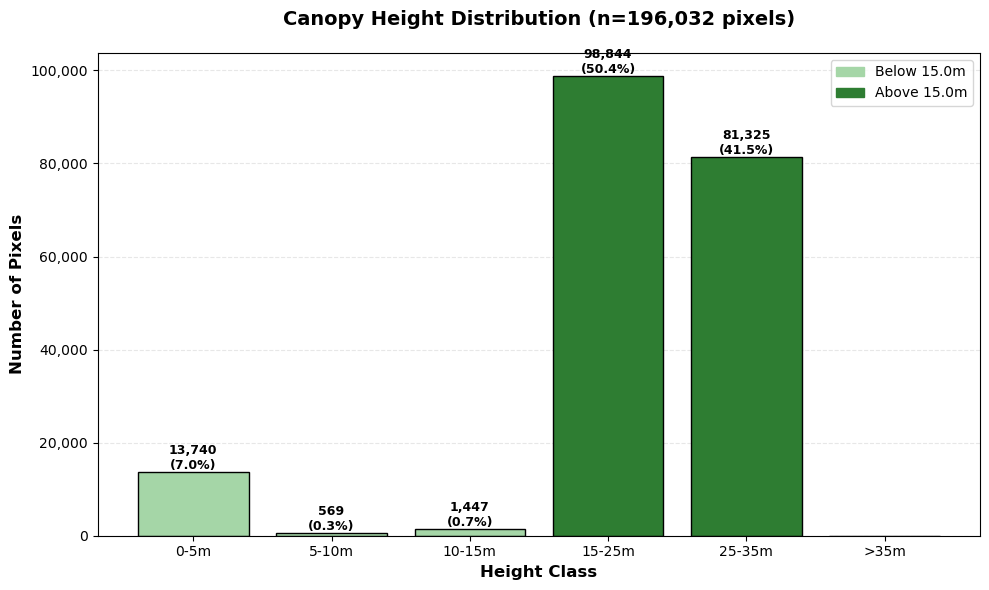

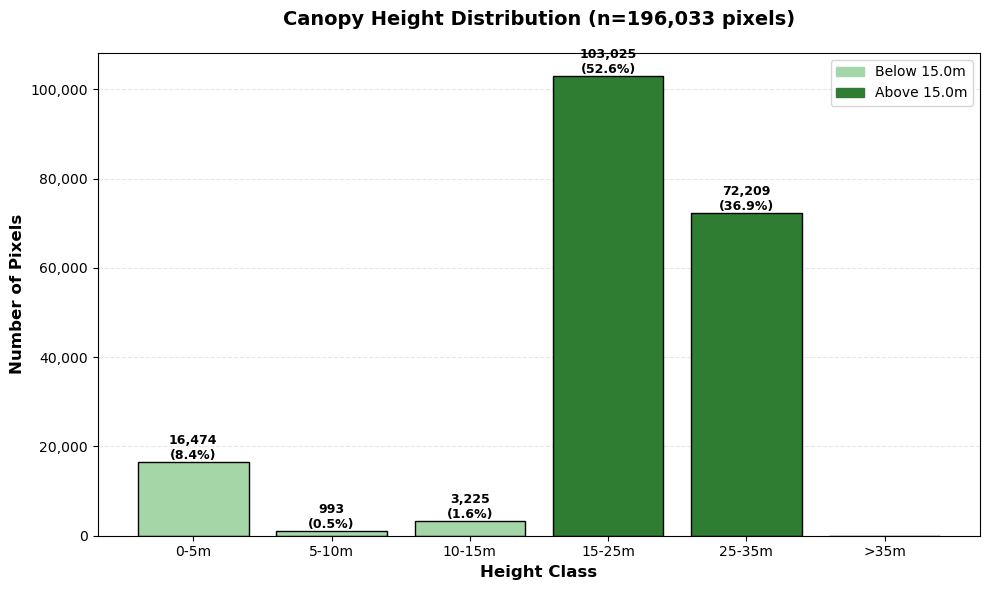

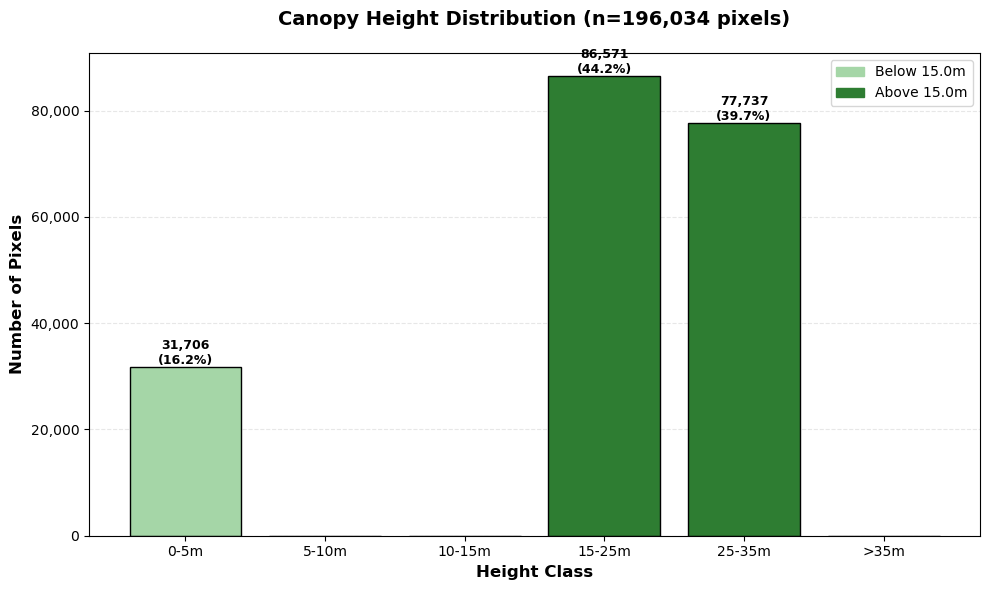

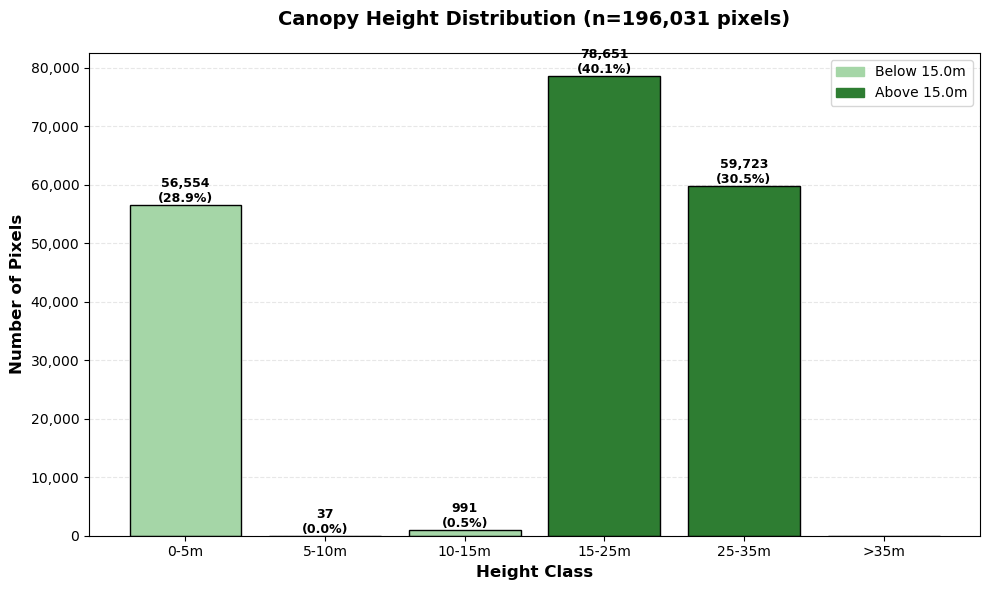

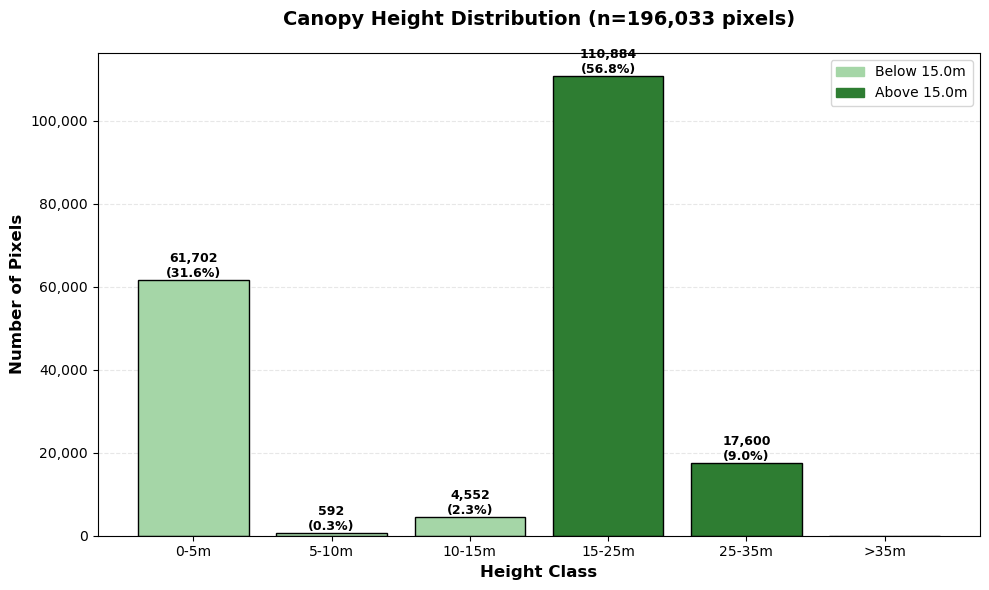

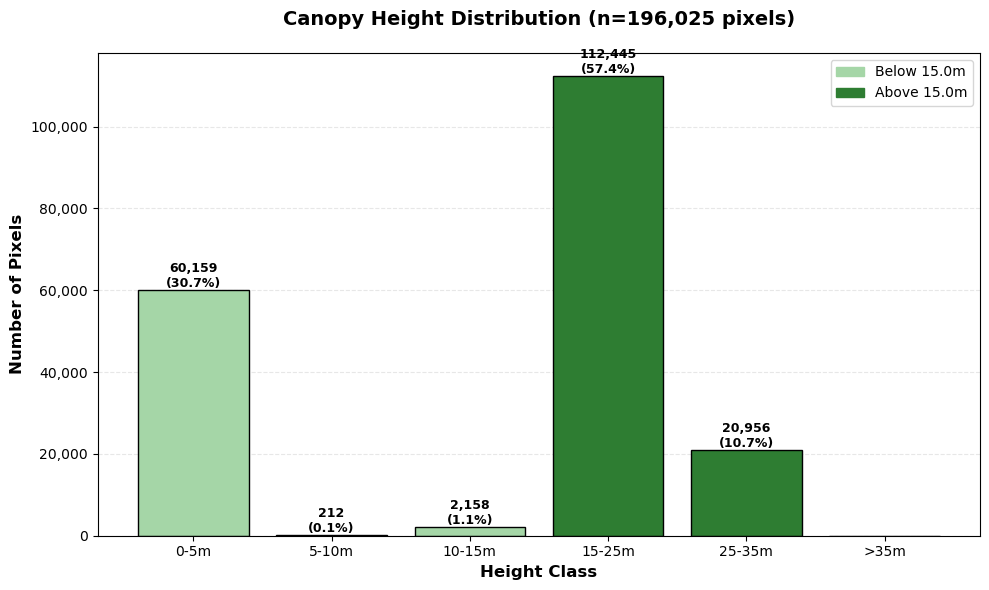

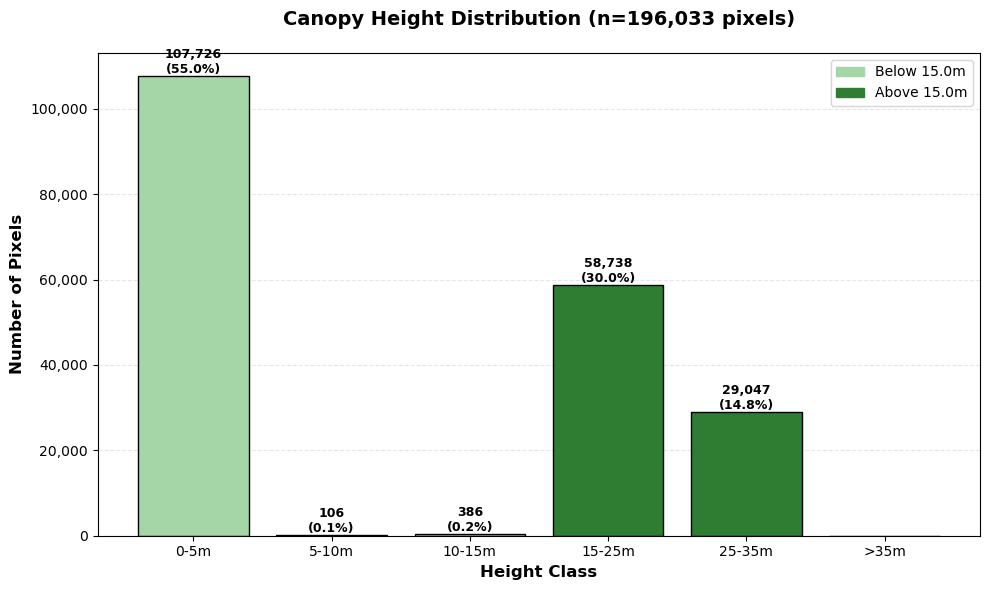

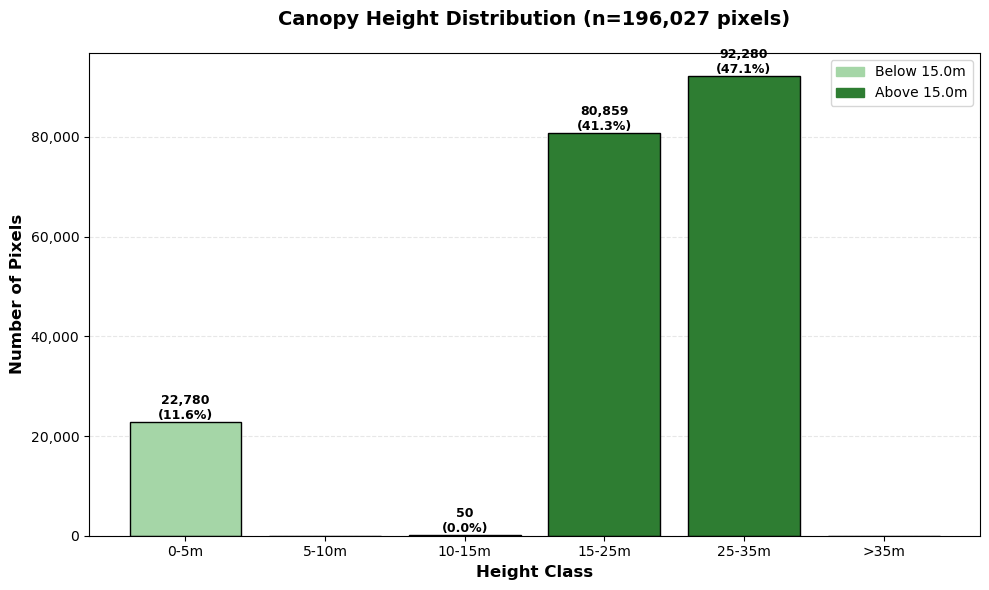

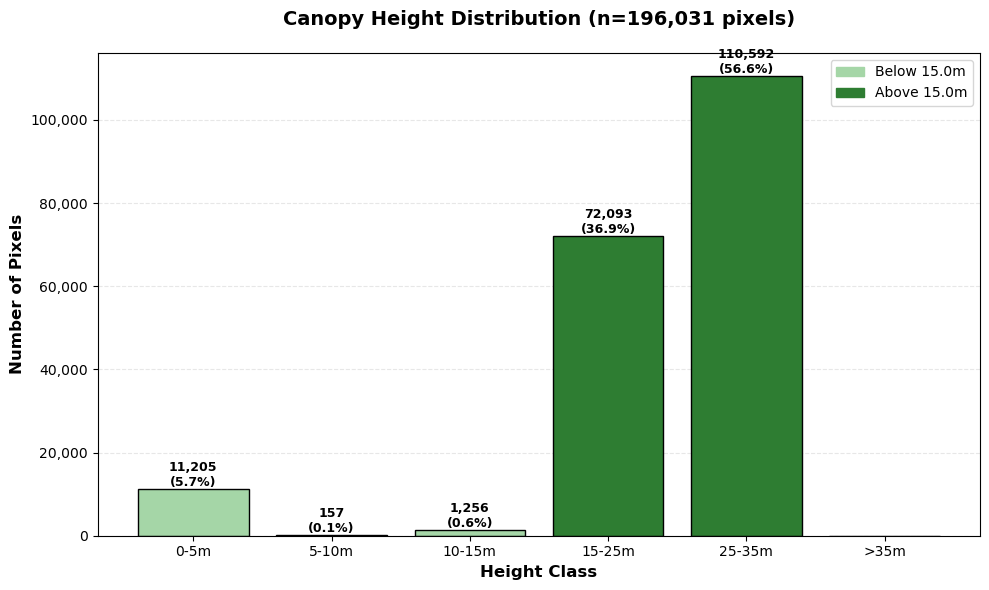

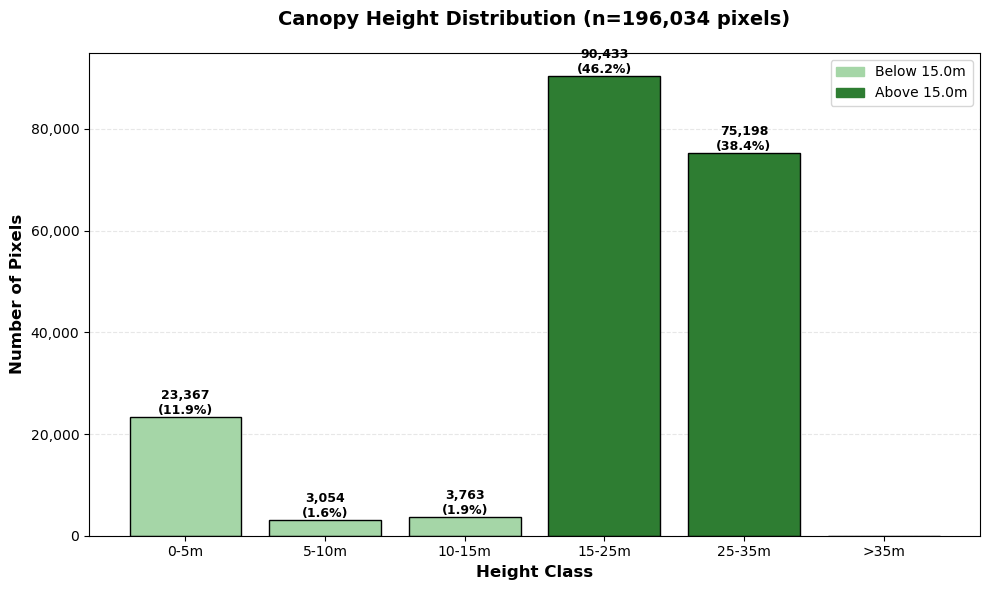

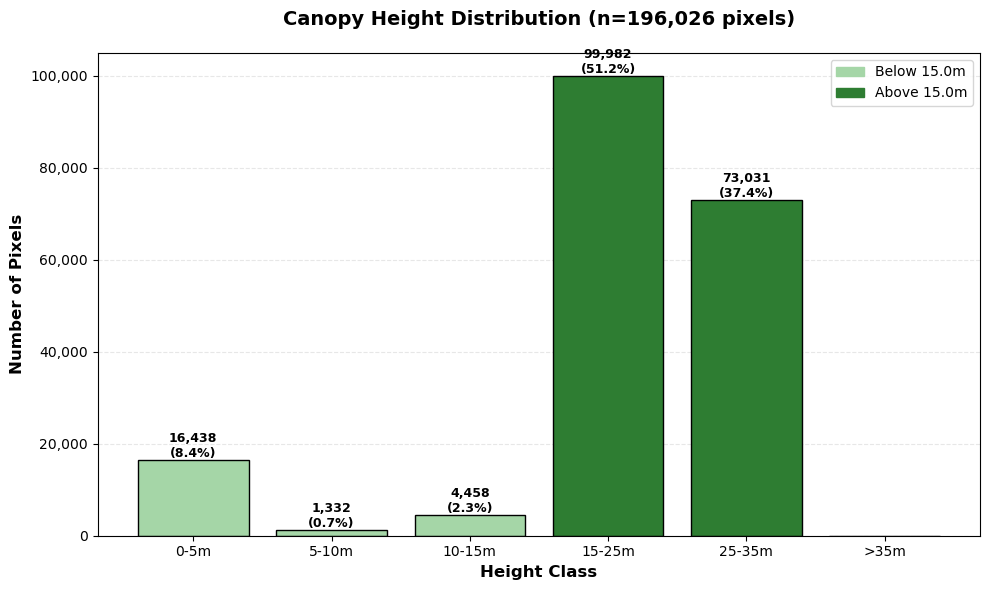

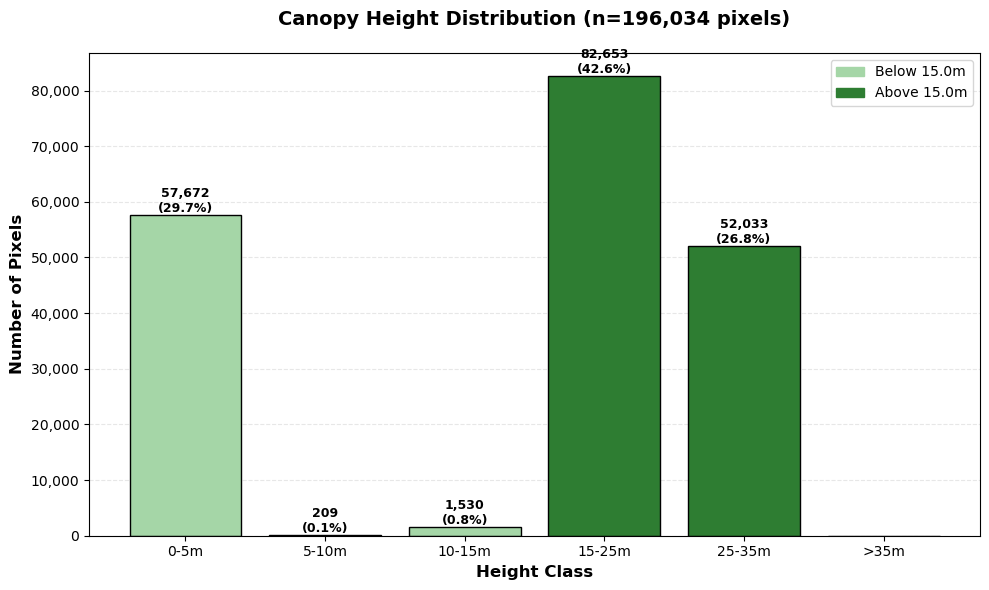

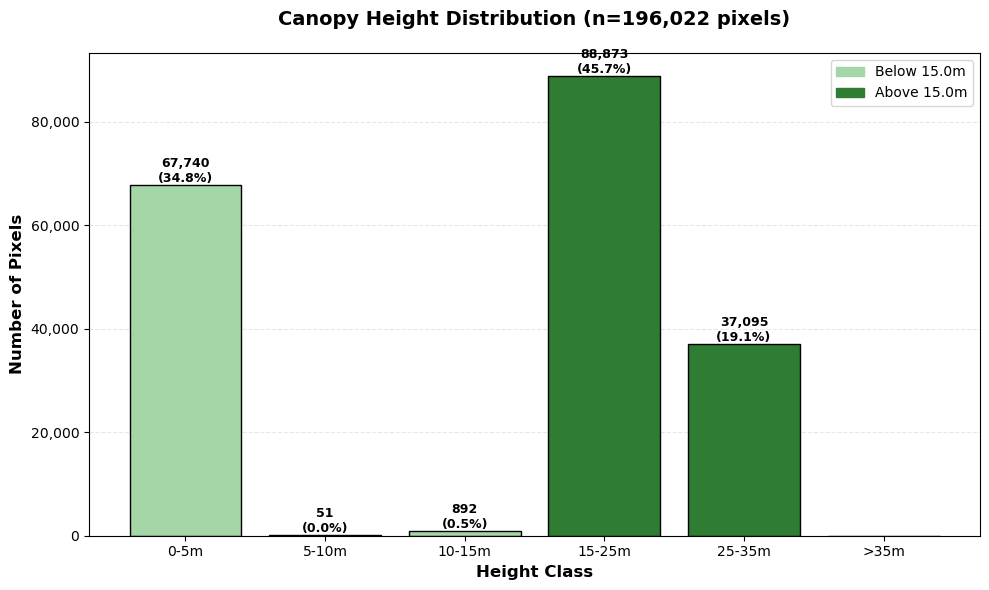

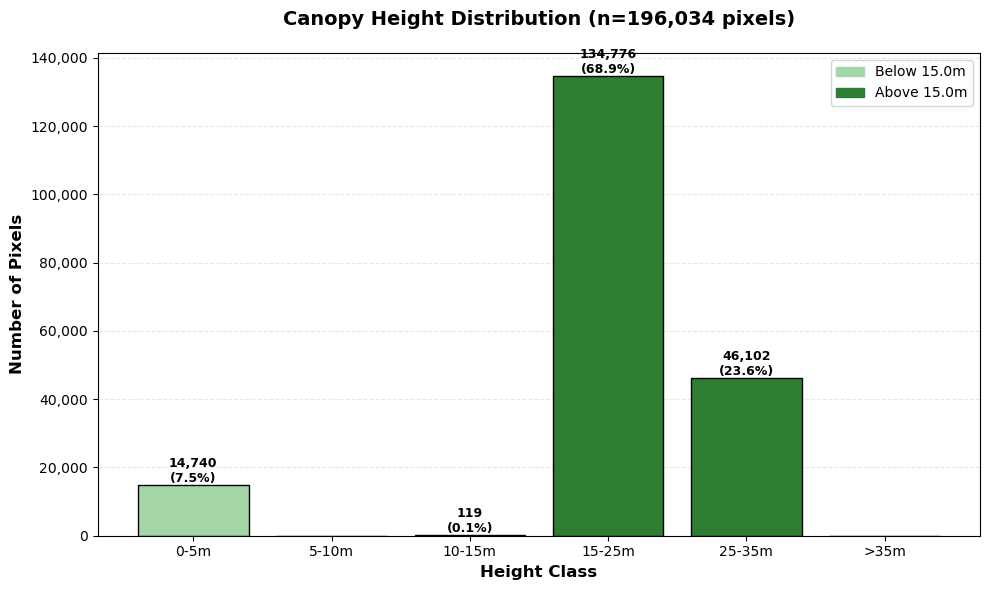

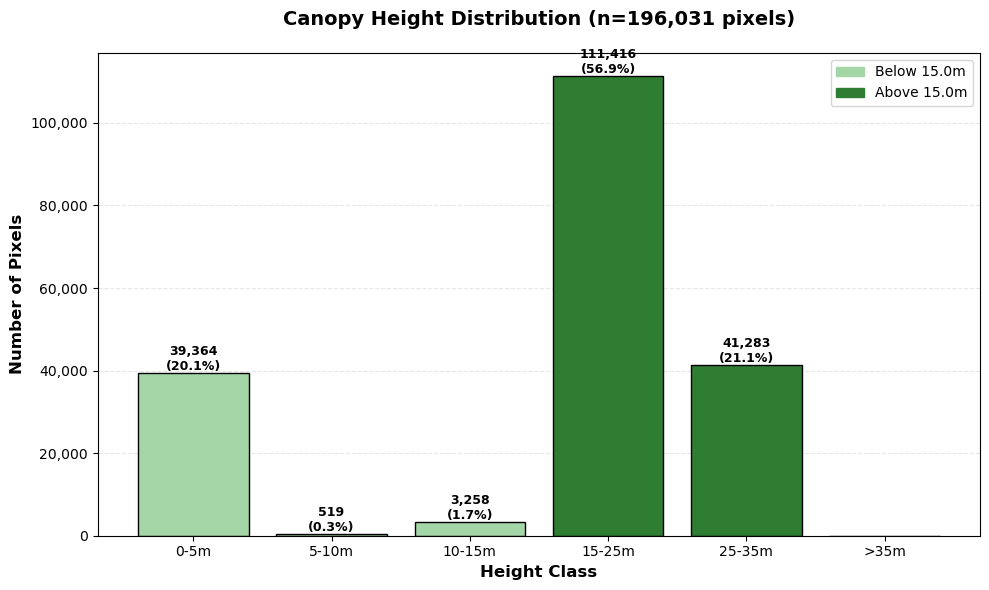

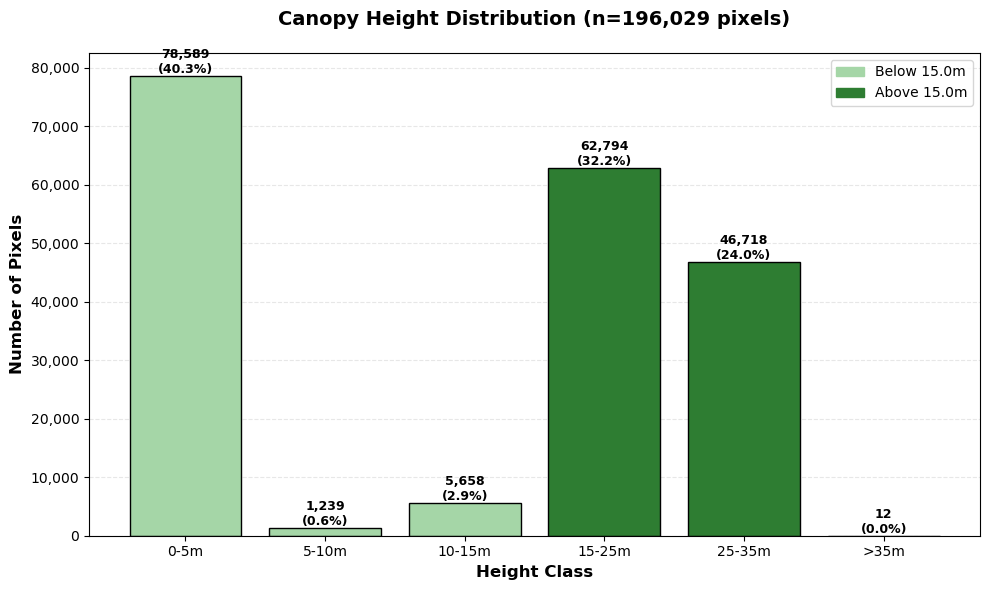

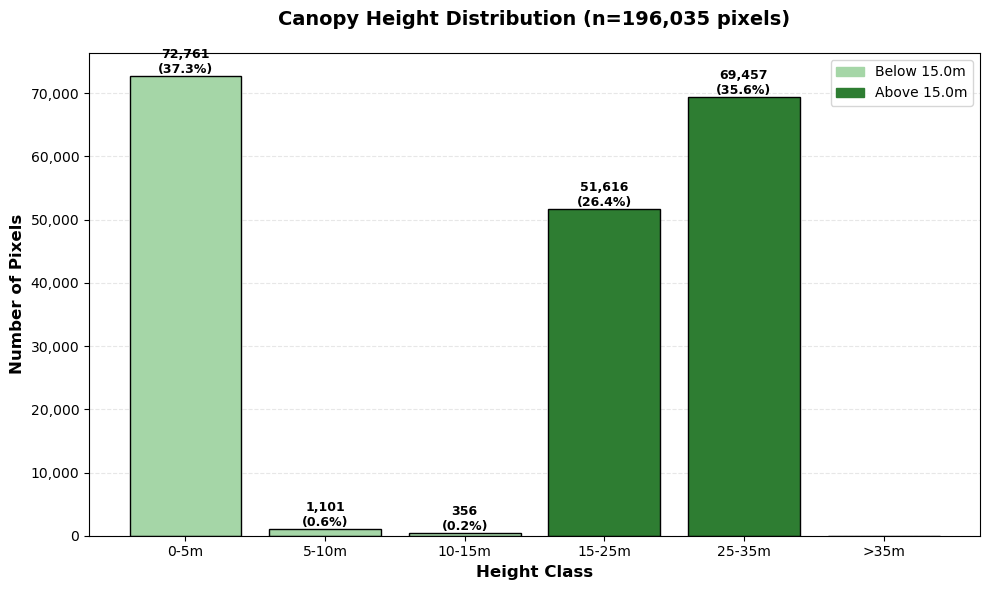

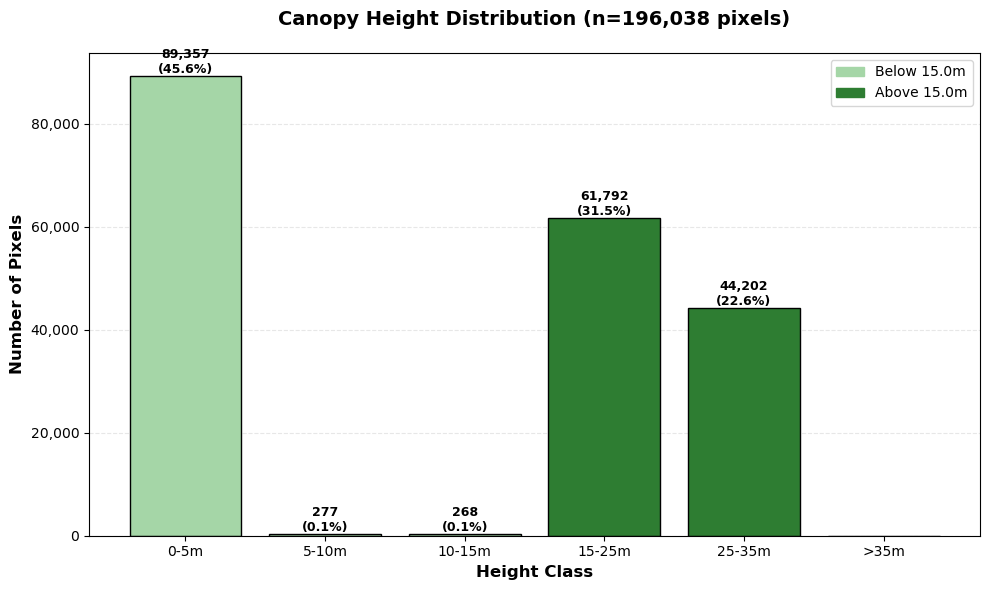

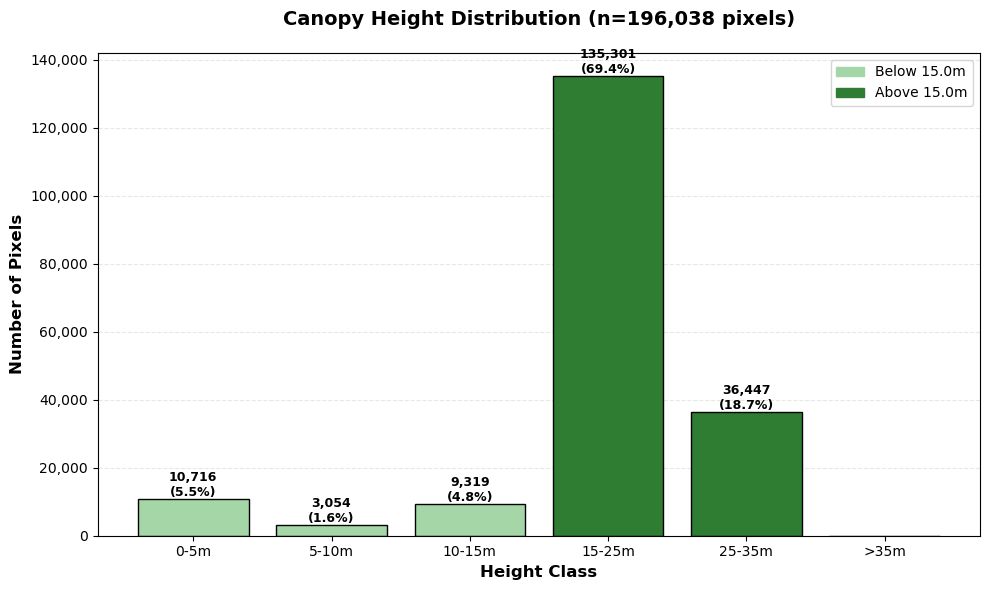

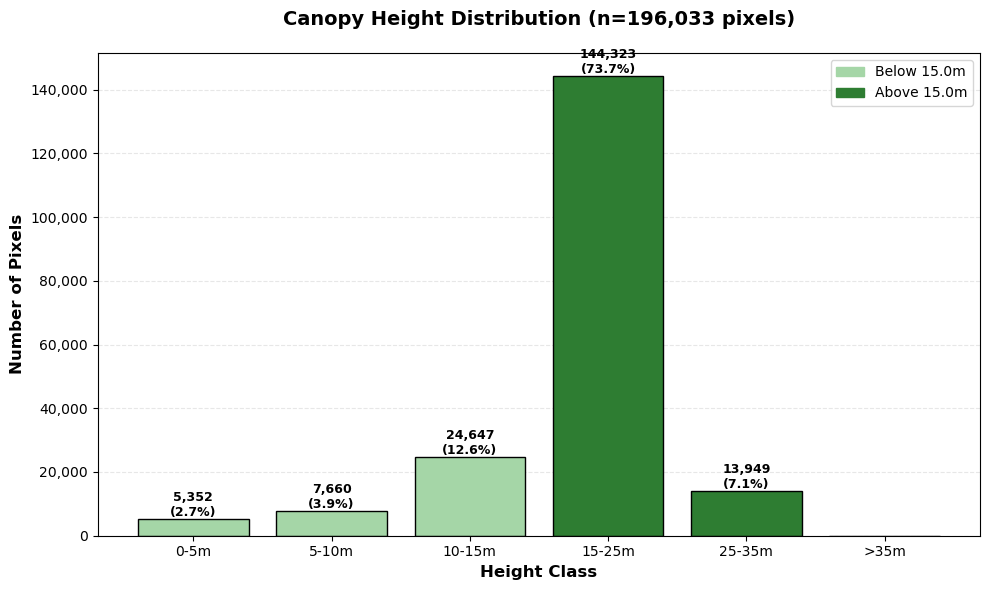

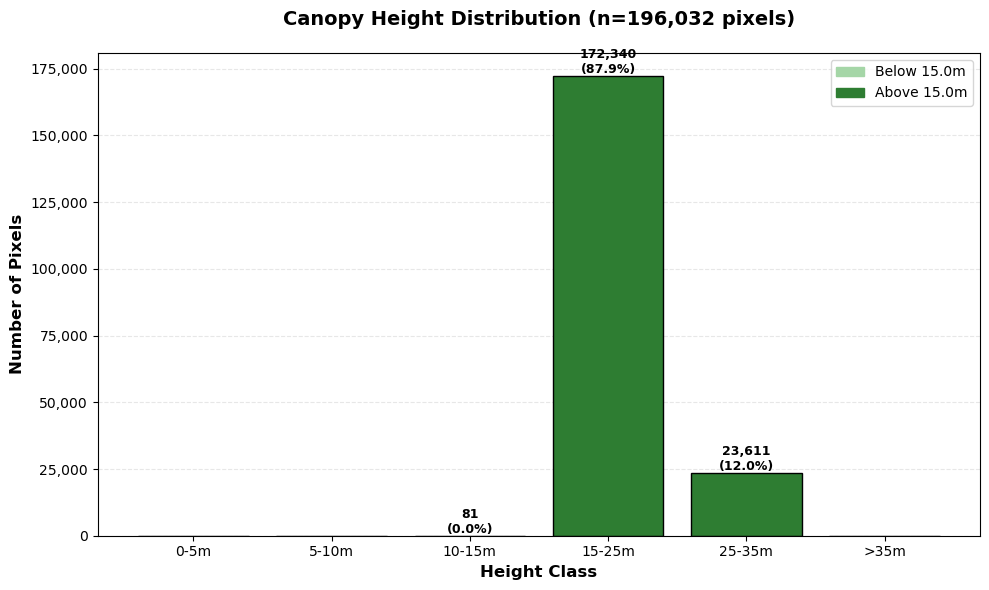

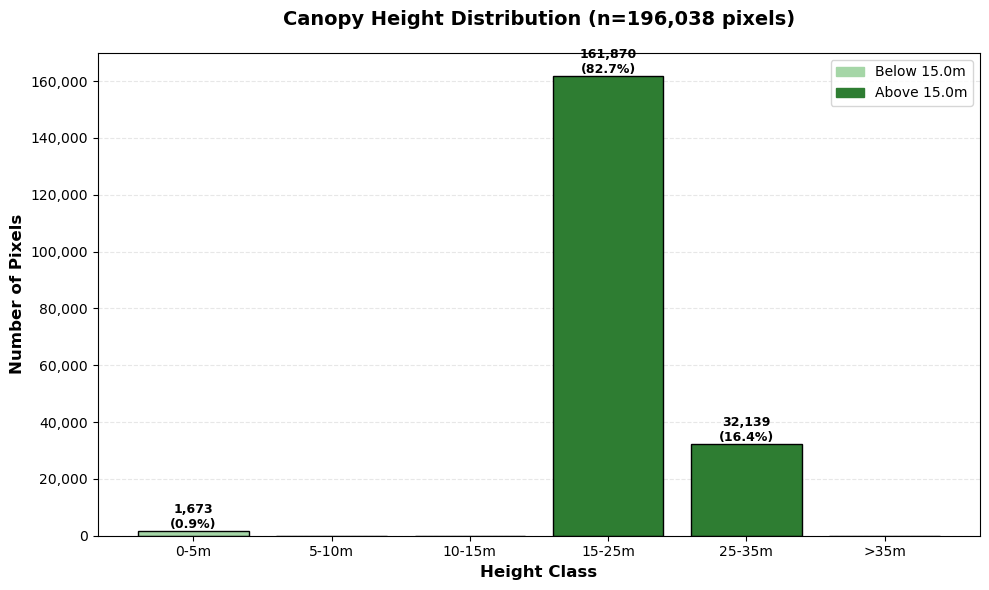

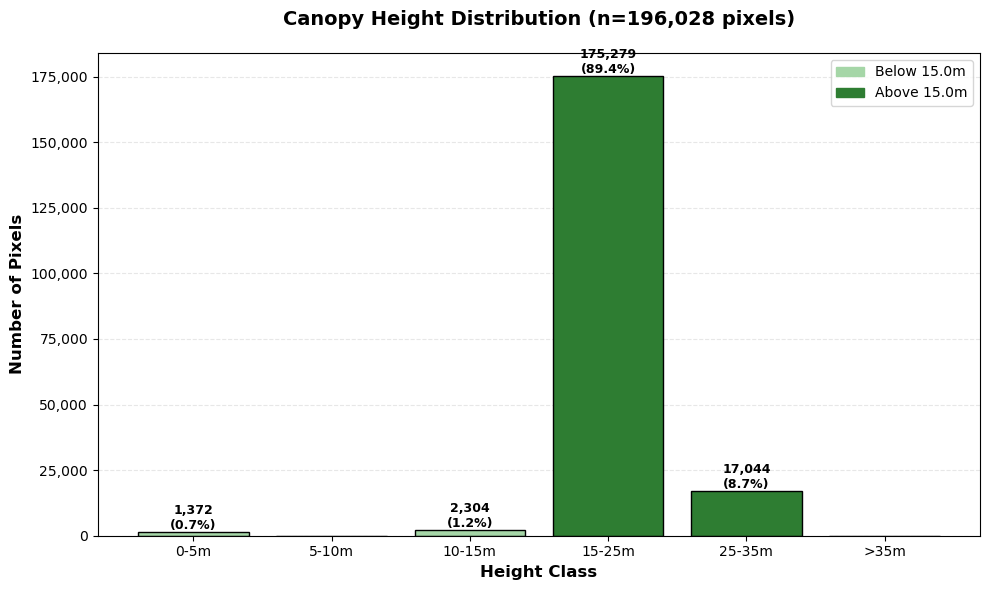

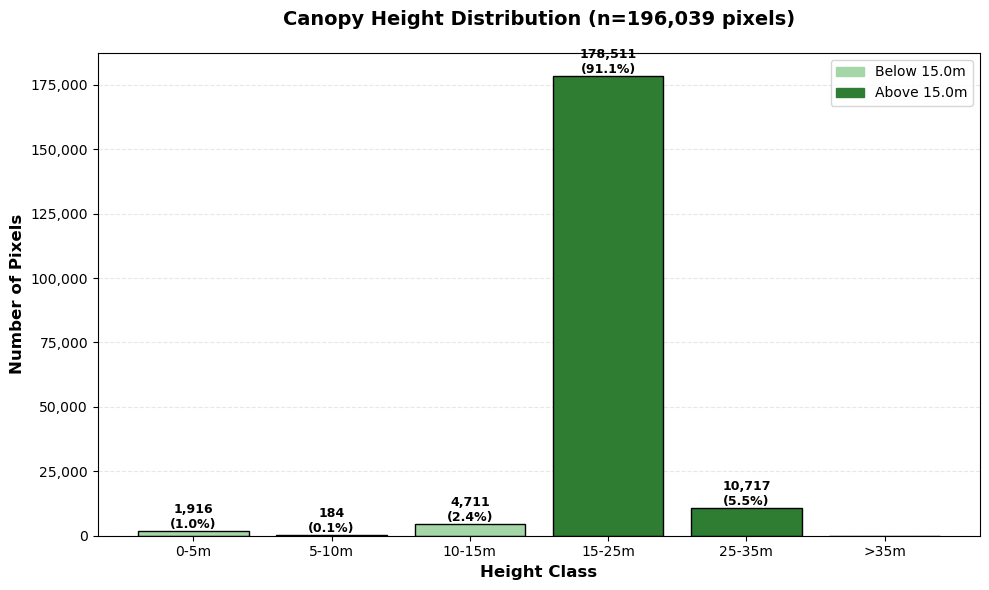

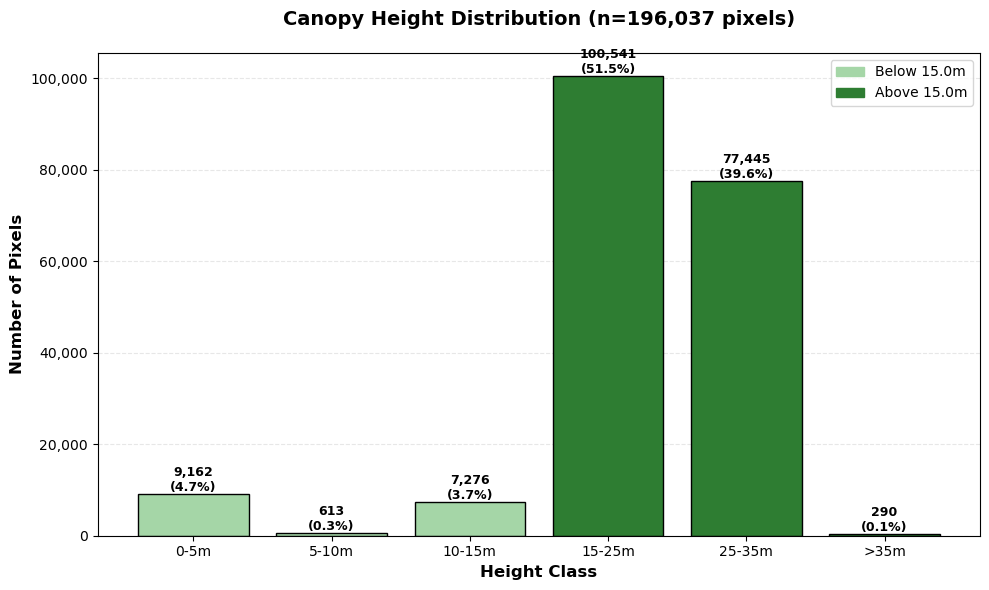

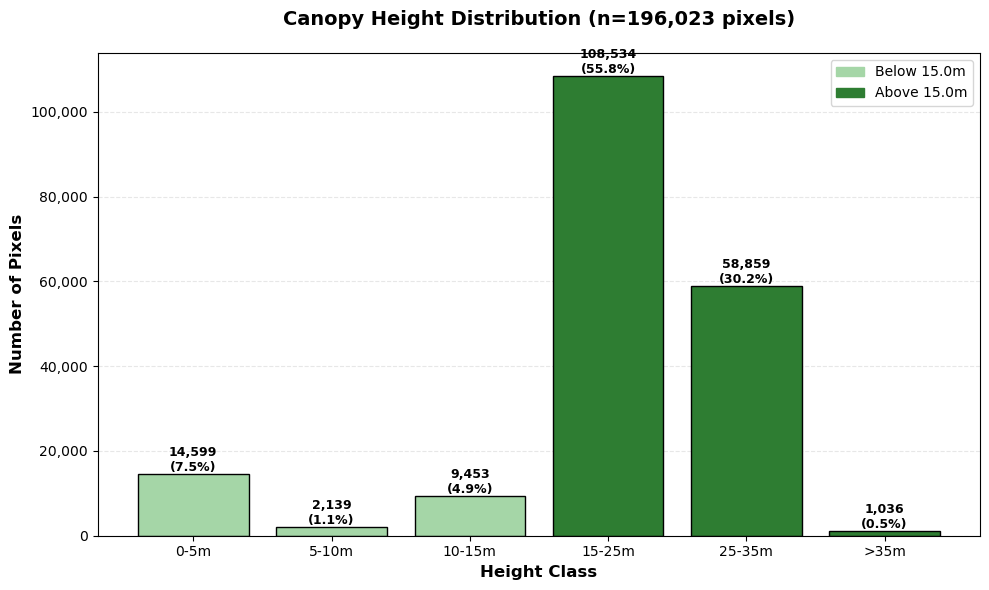

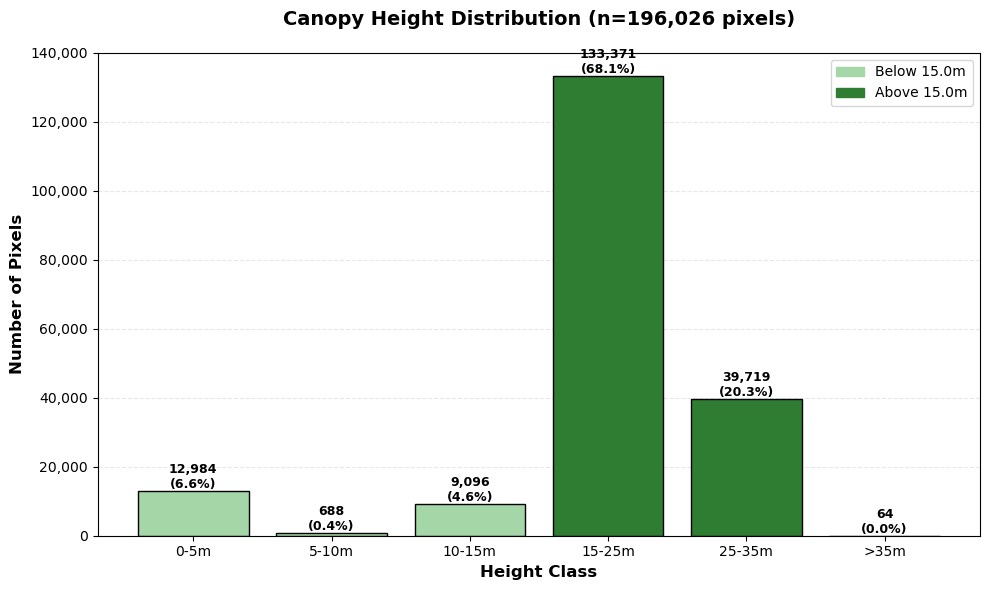

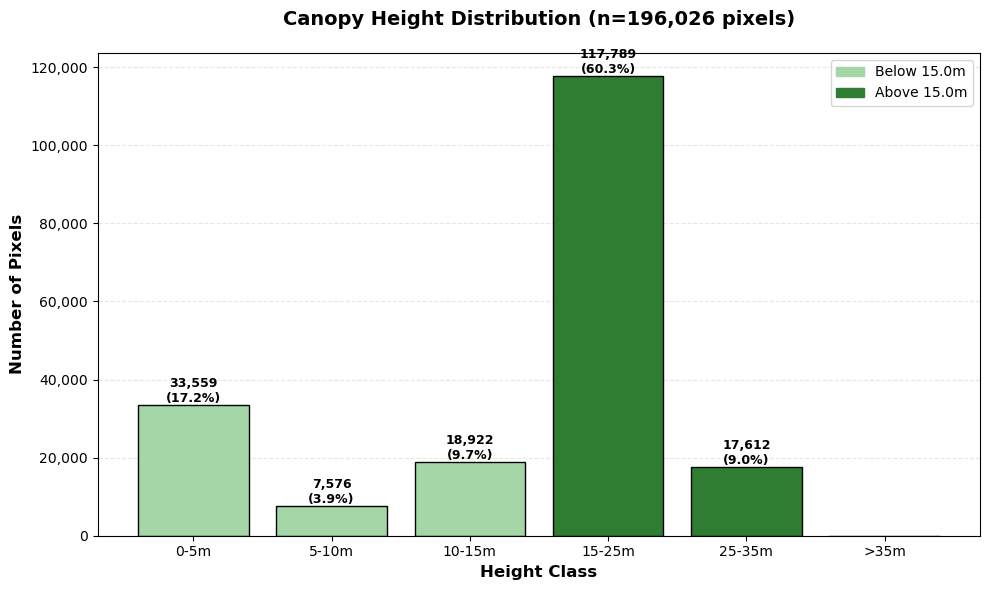

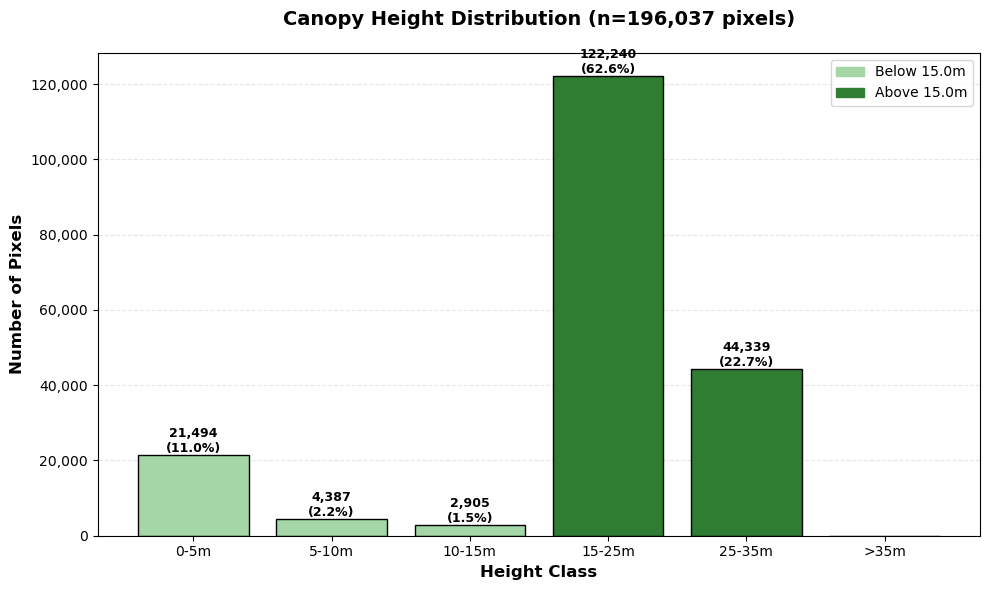

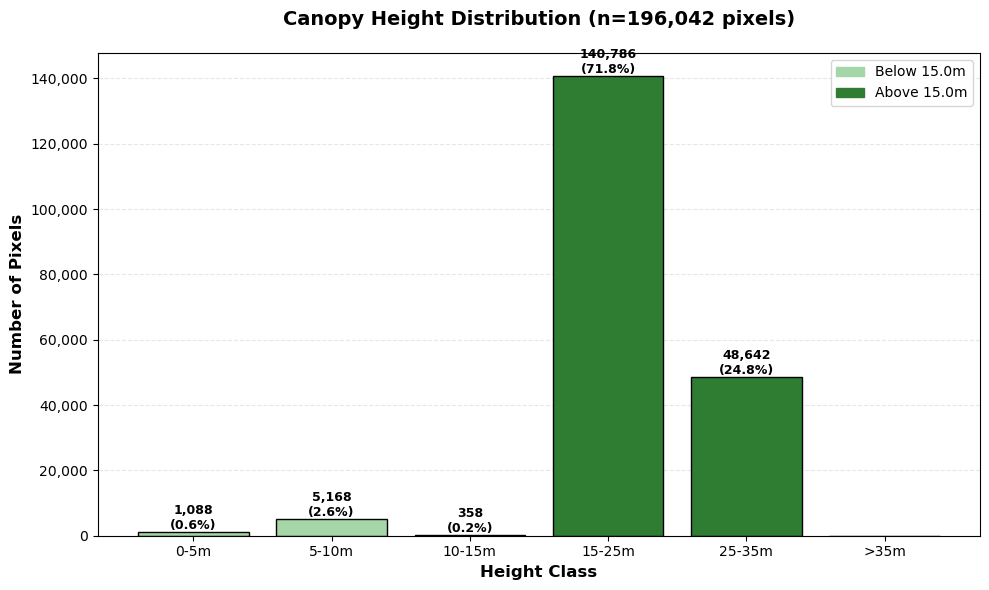

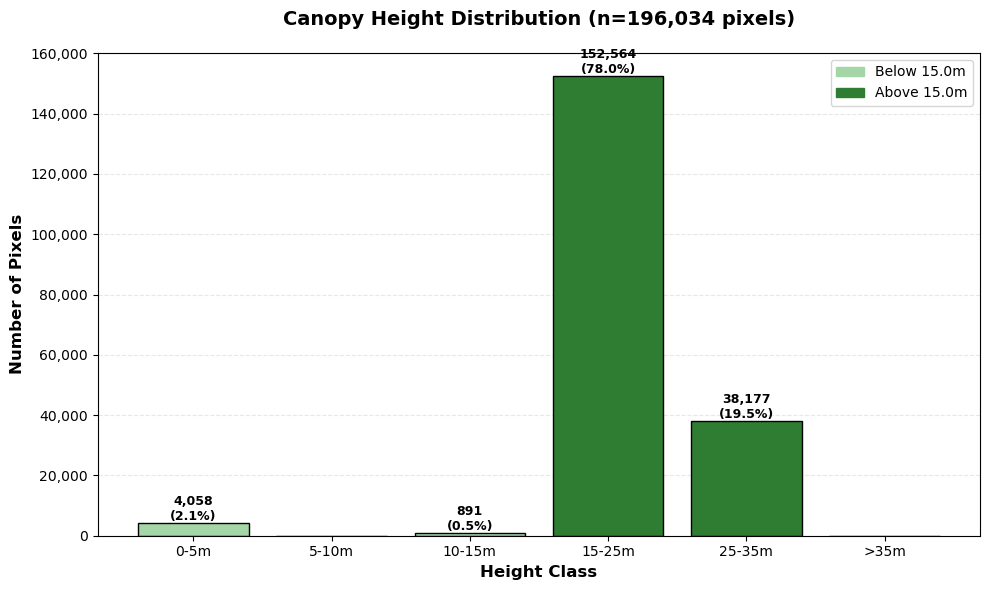

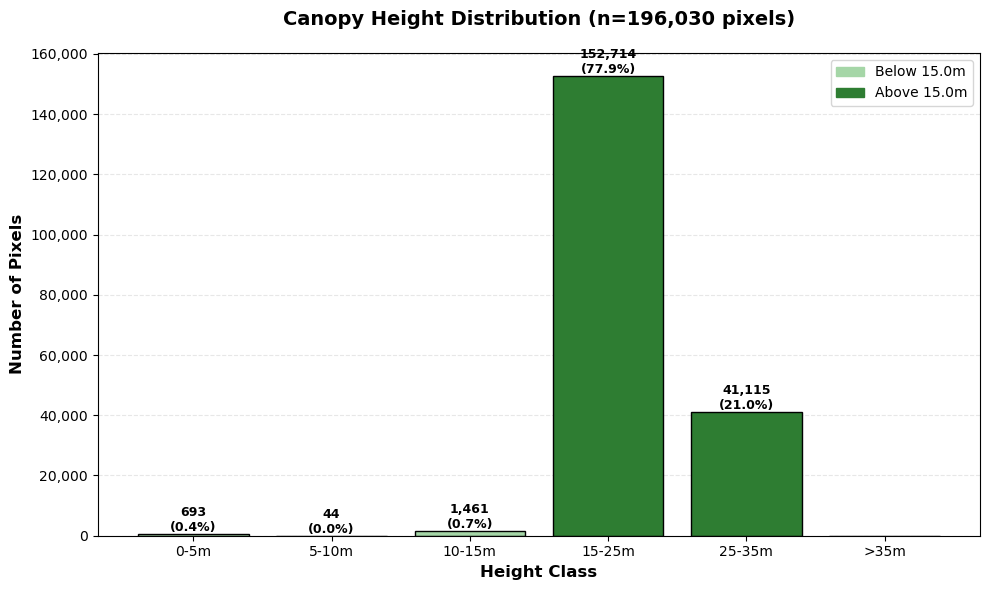

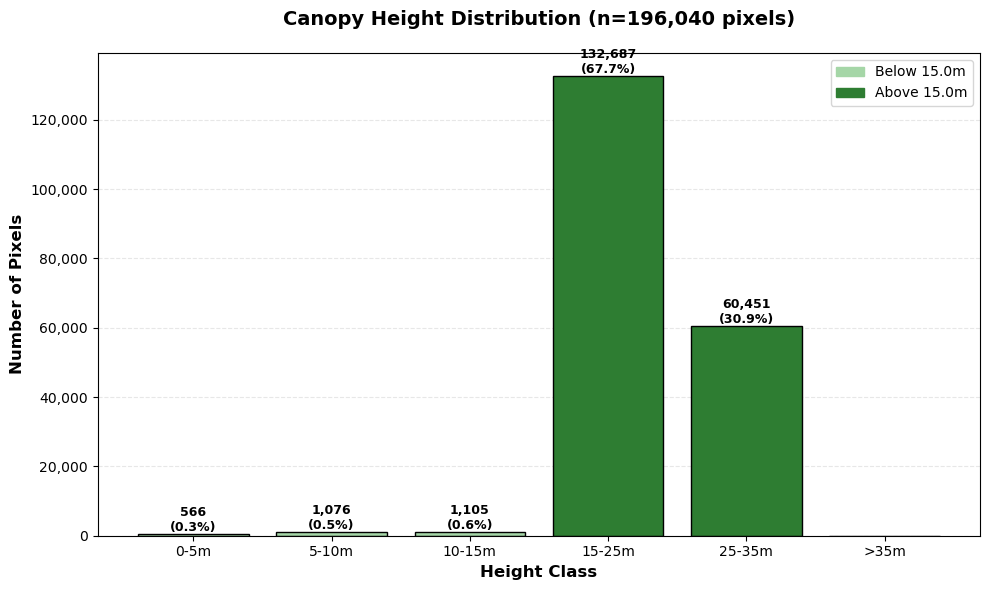

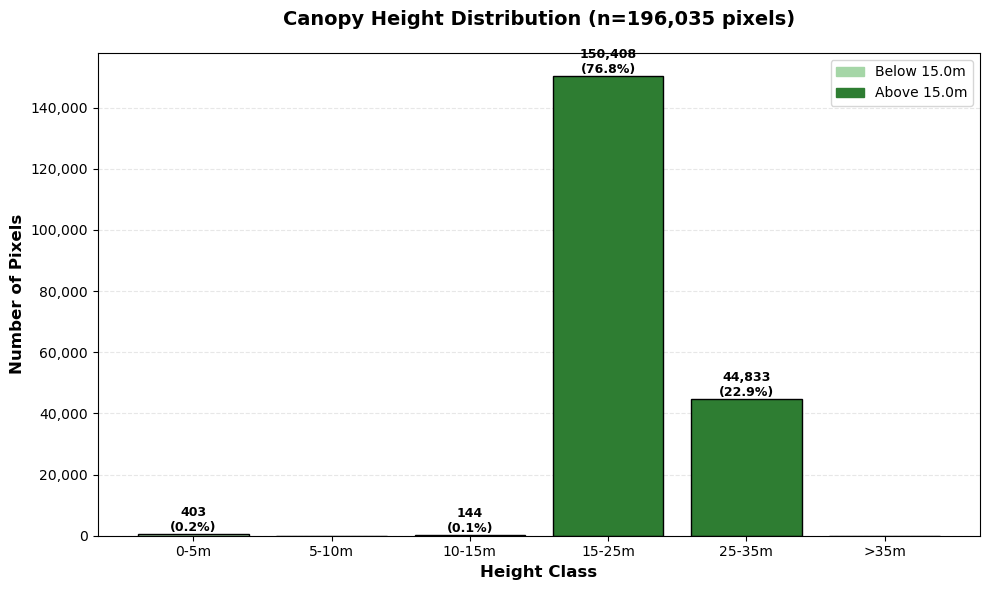

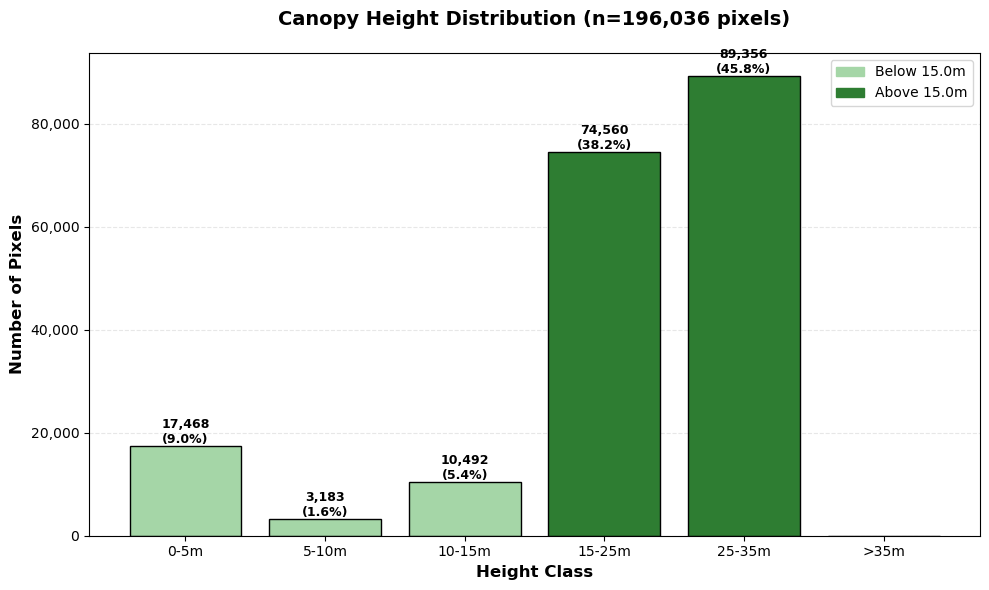

In [28]:
results_rows = []
per_point_results = {}

for row in points_df.itertuples():
    ndom_path = cluster_ndom_paths[row.cluster]
    plot_path = os.path.join(PLOTS_DIR, f"{row.point_slug}_histogram.png")

    try:
        result = canopy_histogram_ldbv(
            coords=[(row.Longitude, row.Latitude)],
            radius_m=POINT_RADIUS_M,
            classes=HEIGHT_CLASSES,
            threshold_height_m=CANOPY_HEIGHT_THRESHOLD_M,
            min_prop_above_threshold=0.0,  # always compute the histogram, even if fully open
            analysis_raster=ndom_path,
            output_plot_path=plot_path,
            temp_dir=BATCH_TEMP_DIR,
            verbose=False,
        )
        stats = result['analysis']['threshold_stats']

        if stats['total_valid_cells'] == 0:
            raise RuntimeError("no valid pixels in point buffer (nodata / outside cluster extent)")

        per_point_results[row.point_id] = result

        results_rows.append({
            'point_id': row.point_id,
            'point_slug': row.point_slug,
            'Title': row.Title,
            'Versuchsflaeche': getattr(row, 'Versuchsfläche'),
            'observer_category': getattr(row, 'Überschurmung_geschätzt'),
            'derived_closure_index': stats['proportion_above_threshold'],
            'mean_height_m': stats['mean_height'],
            'max_height_m': stats['max_height'],
            'valid_pixels': stats['total_valid_cells'],
            'area_ha': result['geometry']['area_ha'],
            'plot_path': plot_path,
            'error': None,
        })
    except Exception as exc:
        results_rows.append({
            'point_id': row.point_id,
            'point_slug': row.point_slug,
            'Title': row.Title,
            'Versuchsflaeche': getattr(row, 'Versuchsfläche'),
            'observer_category': getattr(row, 'Überschurmung_geschätzt'),
            'derived_closure_index': None,
            'mean_height_m': None,
            'max_height_m': None,
            'valid_pixels': None,
            'area_ha': None,
            'plot_path': None,
            'error': str(exc),
        })
        print(f"FAILED: {row.point_id}: {exc}")

results_df = pd.DataFrame(results_rows)
n_ok = results_df['error'].isna().sum()
print(f"\n{n_ok}/{len(results_df)} points processed successfully")

results_df.to_csv(RESULTS_CSV, index=False)
print(f"Saved: {RESULTS_CSV}")

results_df

## Section 7: Per-Point Results

Observer category vs. derived closure index, side by side, for every point.

In [29]:
summary_cols = ['point_id', 'observer_category', 'derived_closure_index', 'mean_height_m', 'valid_pixels', 'error']
pd.set_option('display.max_rows', None)
results_df[summary_cols]

,point_id,observer_category,derived_closure_index,mean_height_m,valid_pixels,error
0,LVP01 (EBE-f 152),Licht-Geschlossen/Licht,0.919080,22.648272,196032,None
1,LVP02 (EBE-f 152),Lücke < Baumlänge,0.893901,21.683237,196033,None
2,LVP03 (EBE-f 152),Lücke > Baumlänge,0.838161,20.717514,196034,None
3,LVP04 (EBE-f 152),Lücke > Baumlänge,0.705878,17.414715,196031,None
4,LVP05 (EBE-f 152),Lücke > Baumlänge,0.655420,14.993049,196033,None
5,LVP06 (EBE-f 152),Licht-Geschlossen/Licht,0.680531,15.422450,196025,None
6,LVP07 (EBE-f 152),Lücke > Baumlänge,0.447807,10.963209,196033,None
7,LVP08 (EBE-f 152),Licht-Geschlossen/Licht,0.883241,22.230457,196027,None
8,LVP09 (EBE-f 152),Licht-Geschlossen/Licht,0.931919,23.986872,196031,None
9,LVP10 (EBE-f 152),Licht-Geschlossen/Licht,0.844899,21.175779,196034,None



LVP01 (EBE-f 152)
  Observer:  Licht-Geschlossen/Licht
  Derived:   0.92  (0=light .. 1=closed)
  Mean height: 22.6m | Valid pixels: 196,032


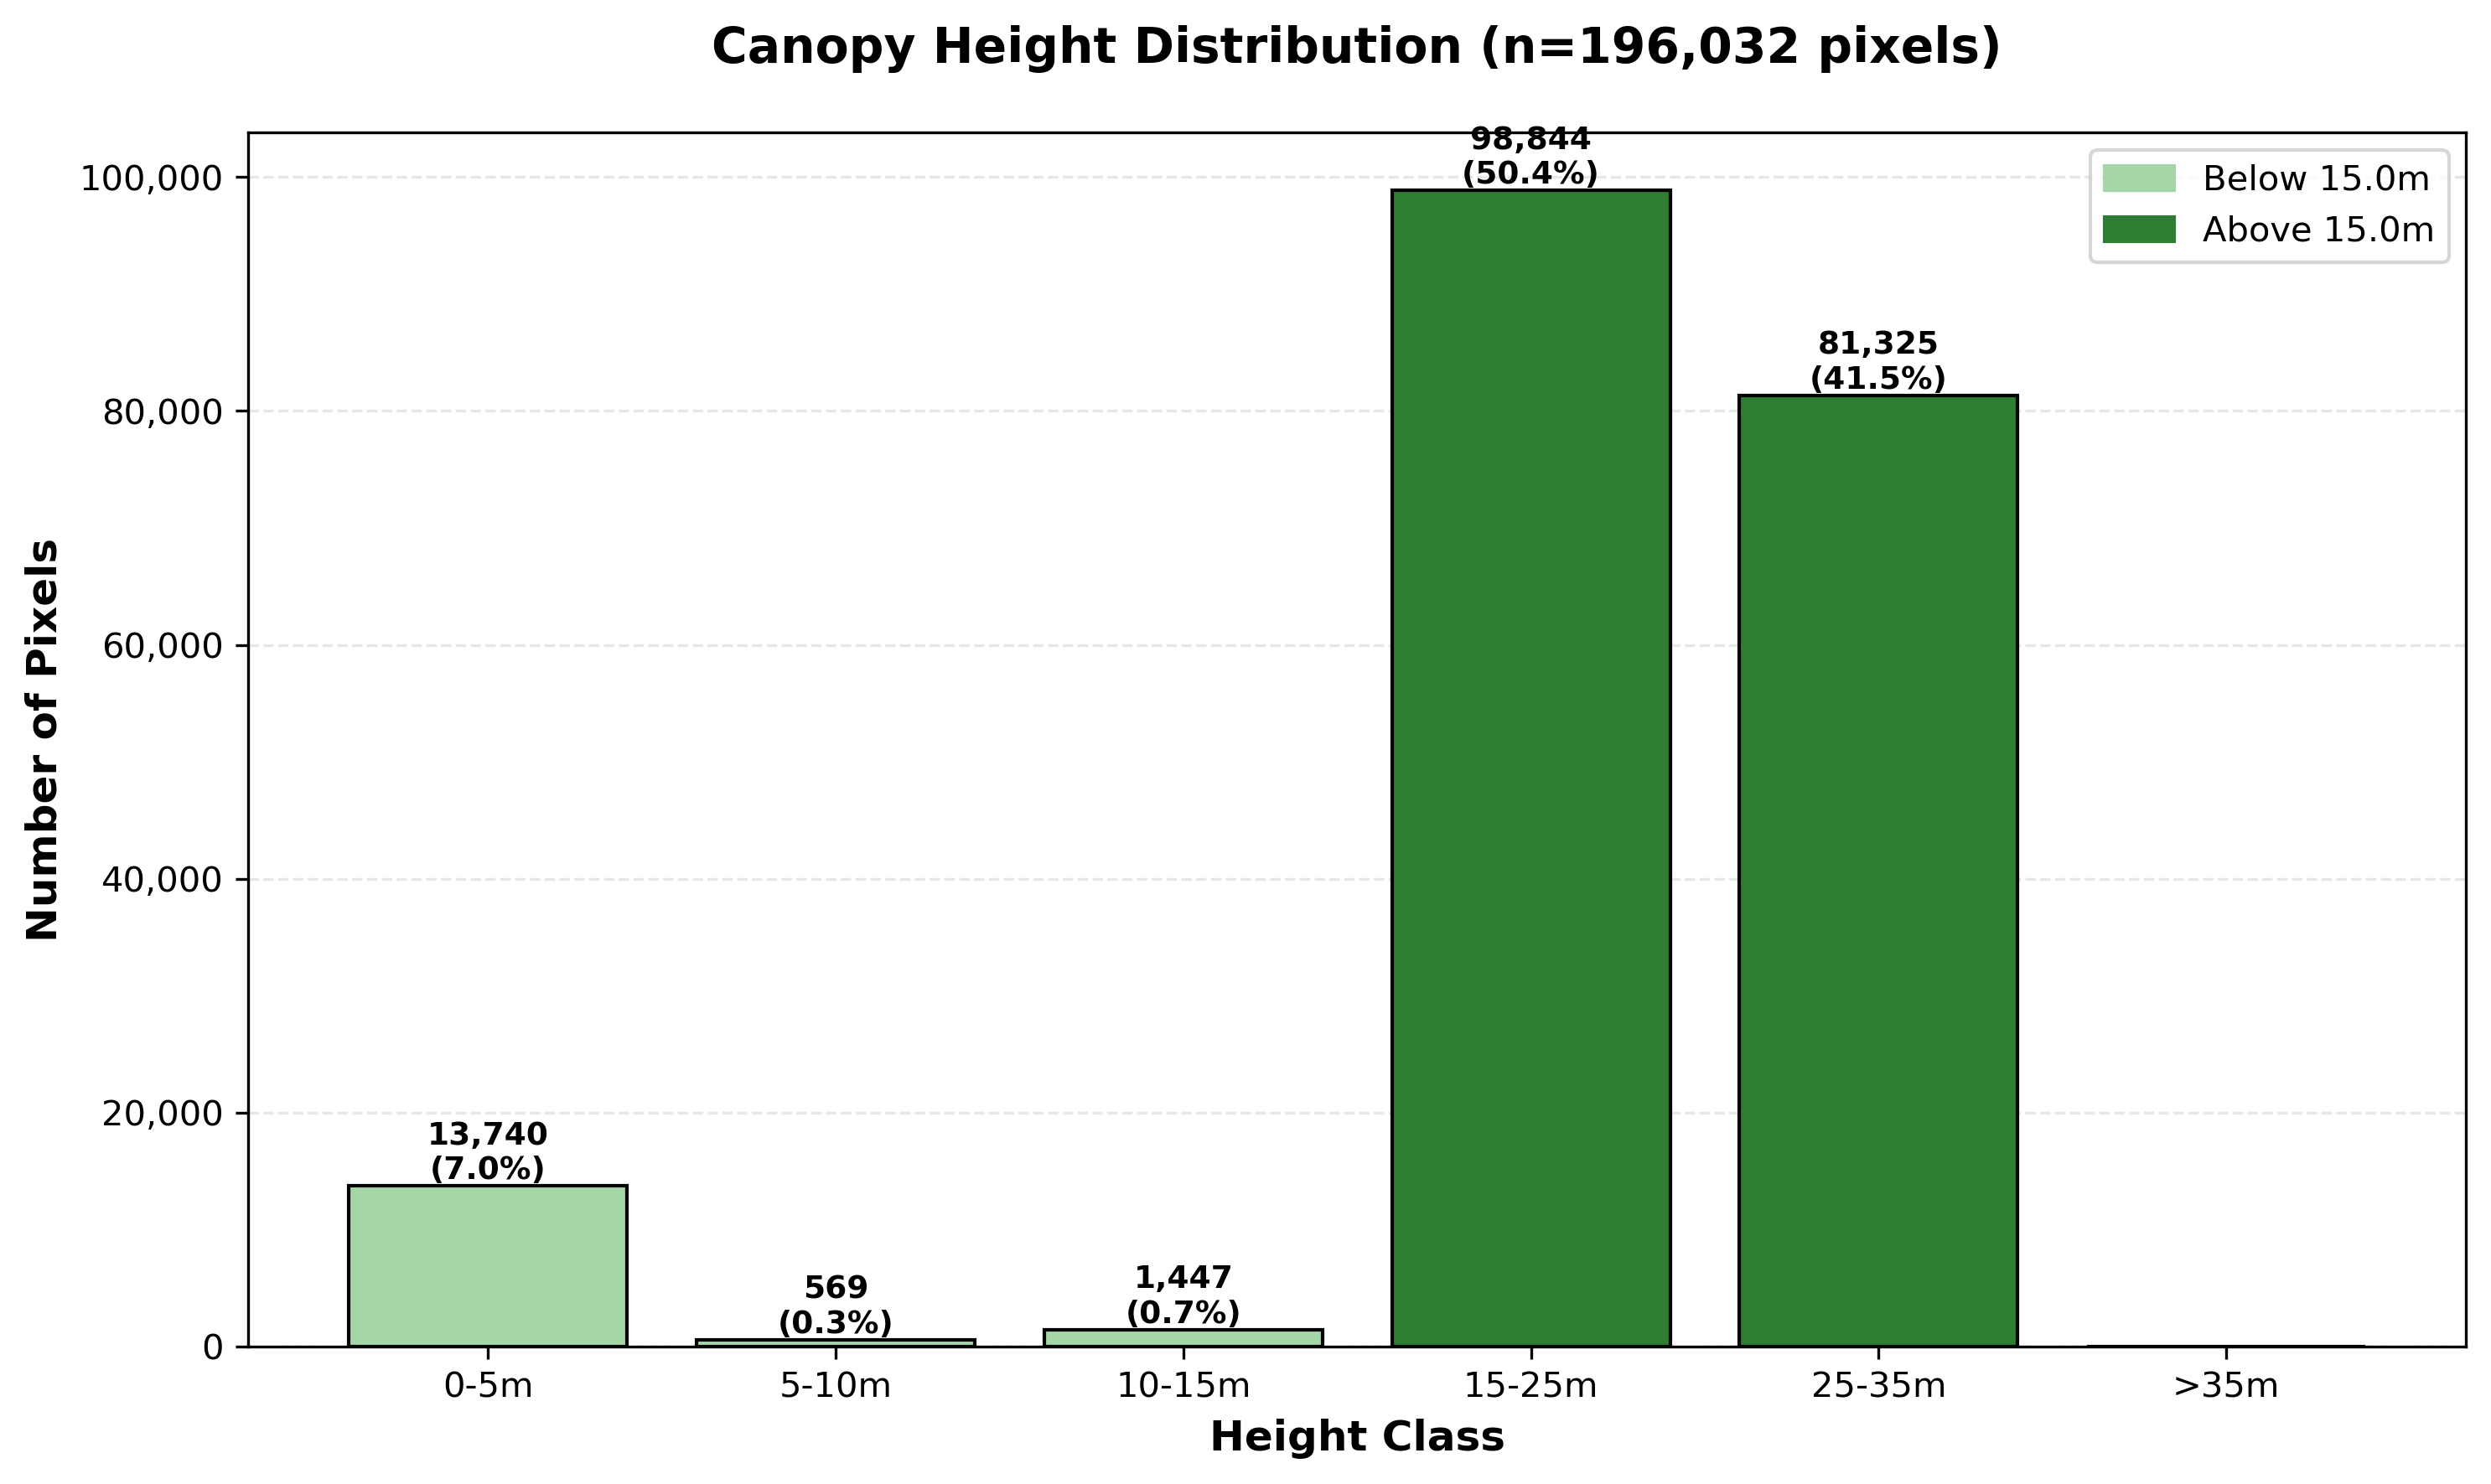


LVP02 (EBE-f 152)
  Observer:  Lücke < Baumlänge
  Derived:   0.89  (0=light .. 1=closed)
  Mean height: 21.7m | Valid pixels: 196,033


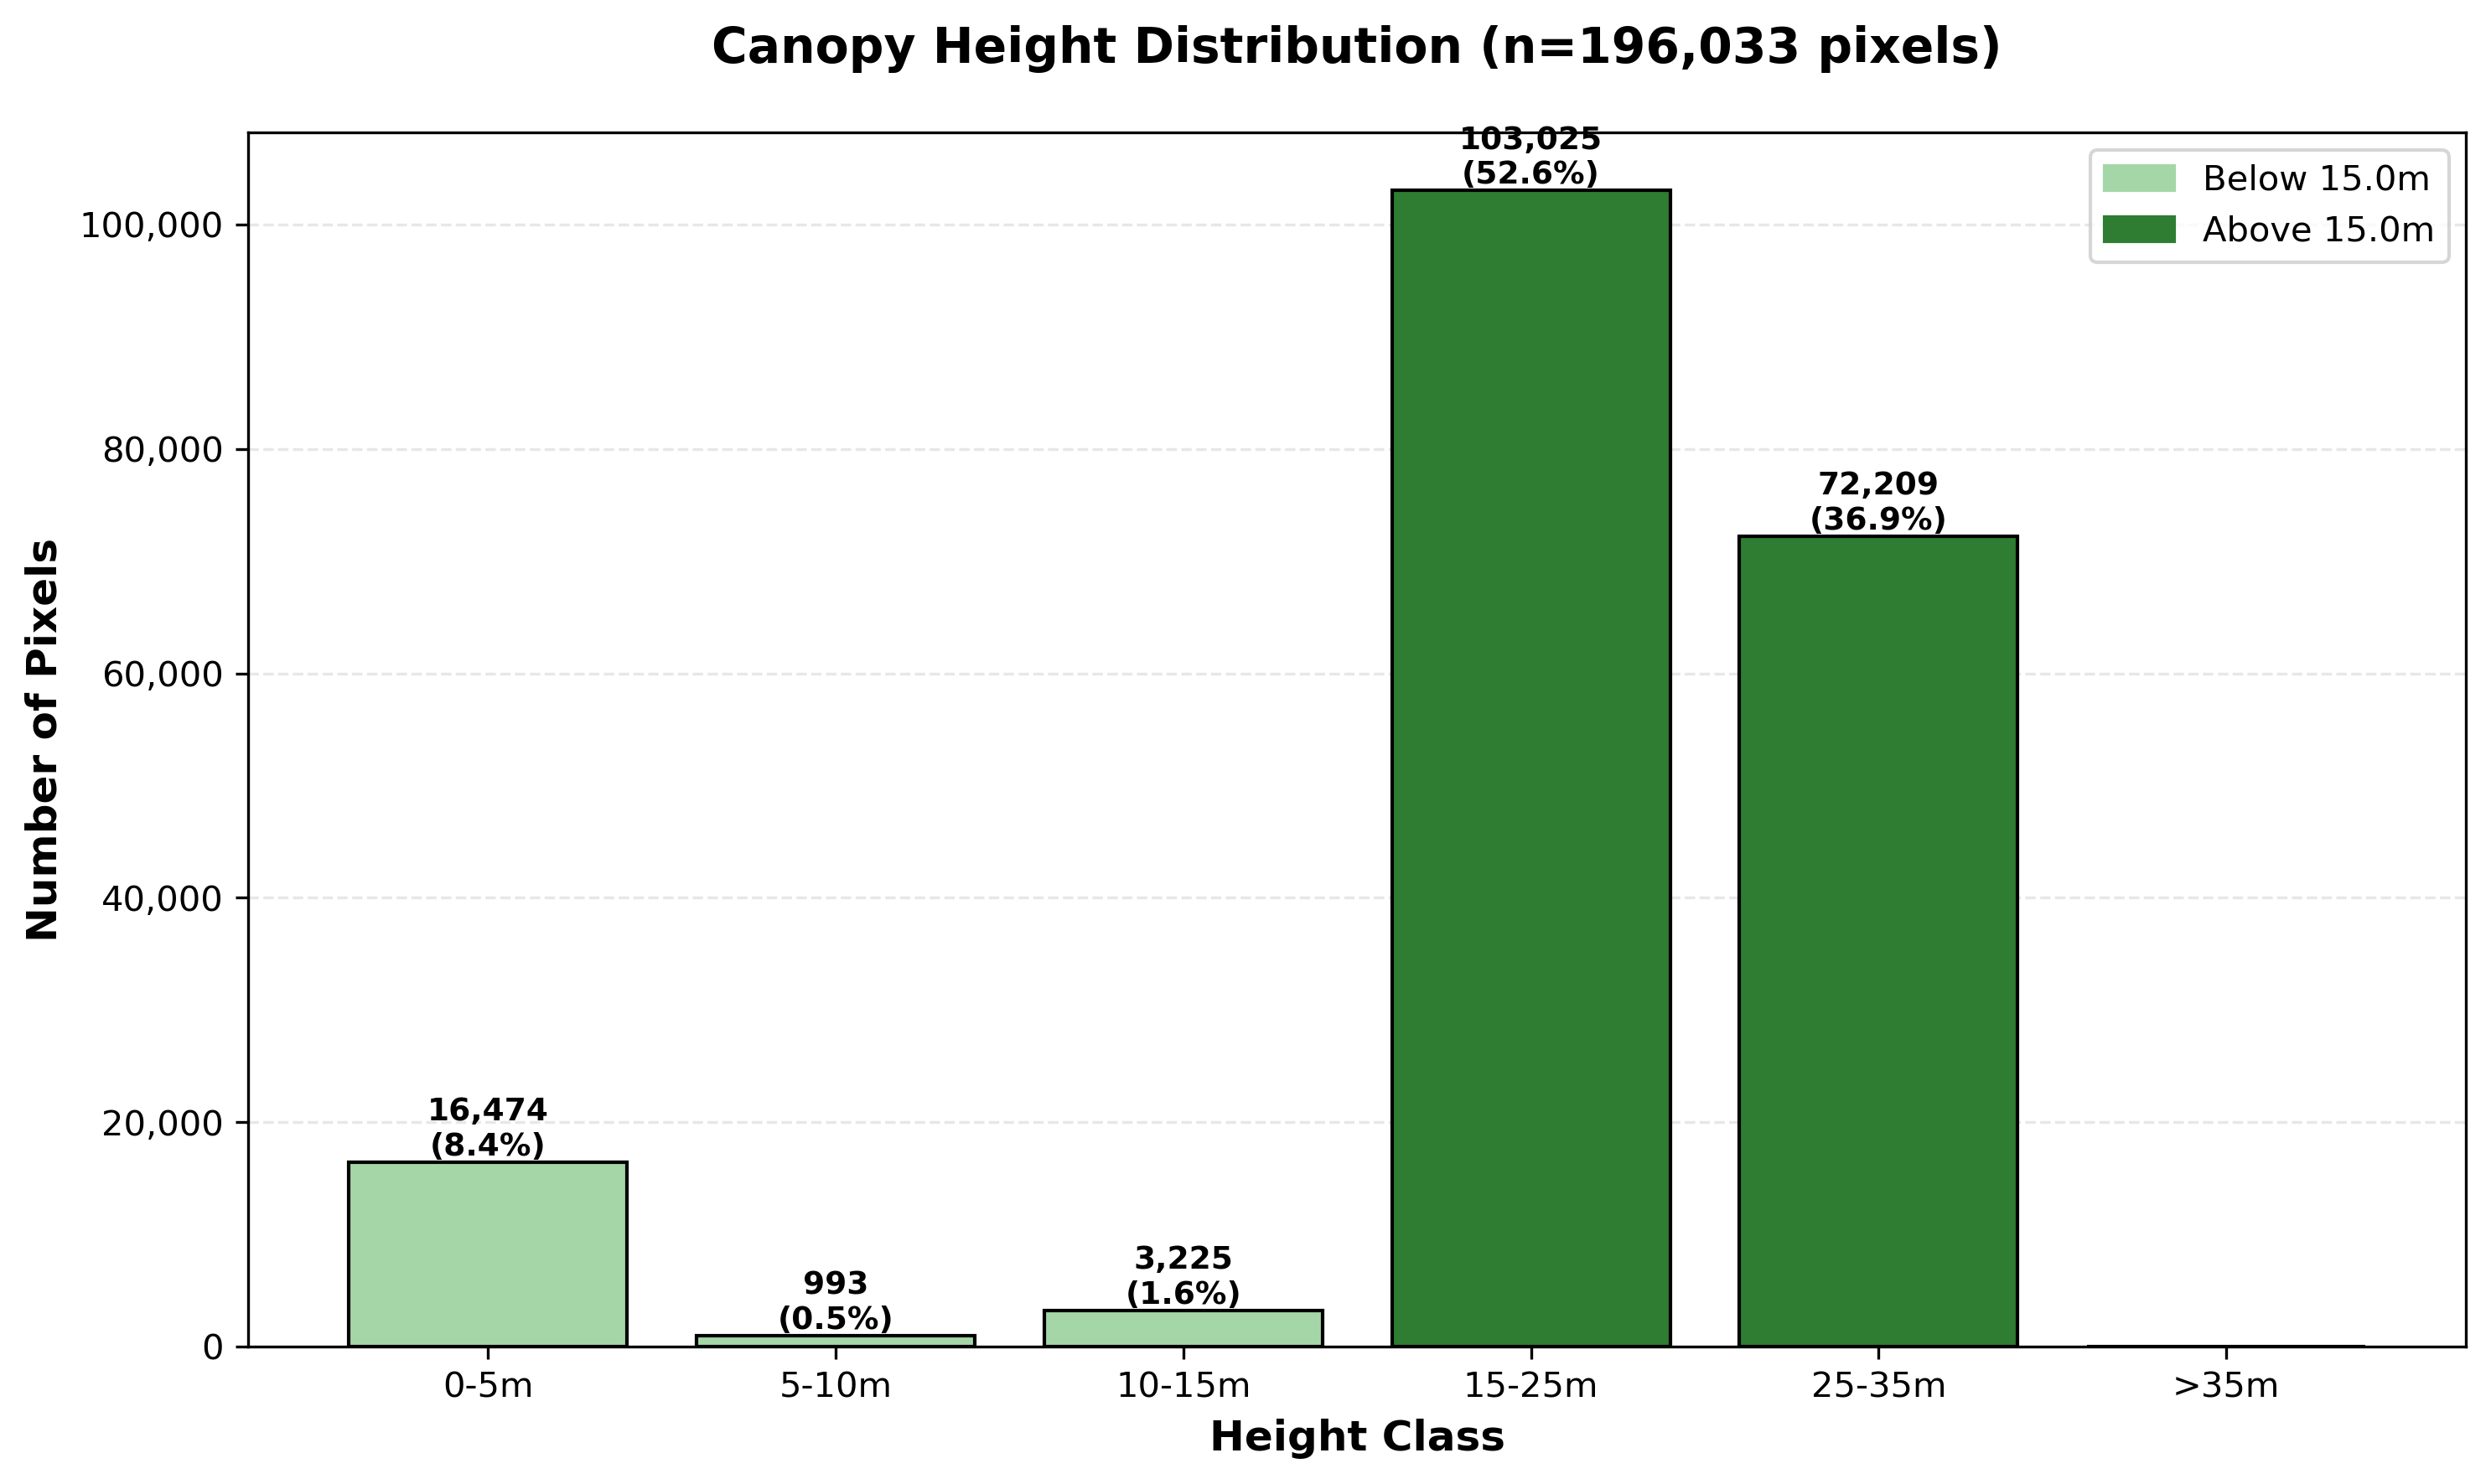


LVP03 (EBE-f 152)
  Observer:  Lücke > Baumlänge
  Derived:   0.84  (0=light .. 1=closed)
  Mean height: 20.7m | Valid pixels: 196,034


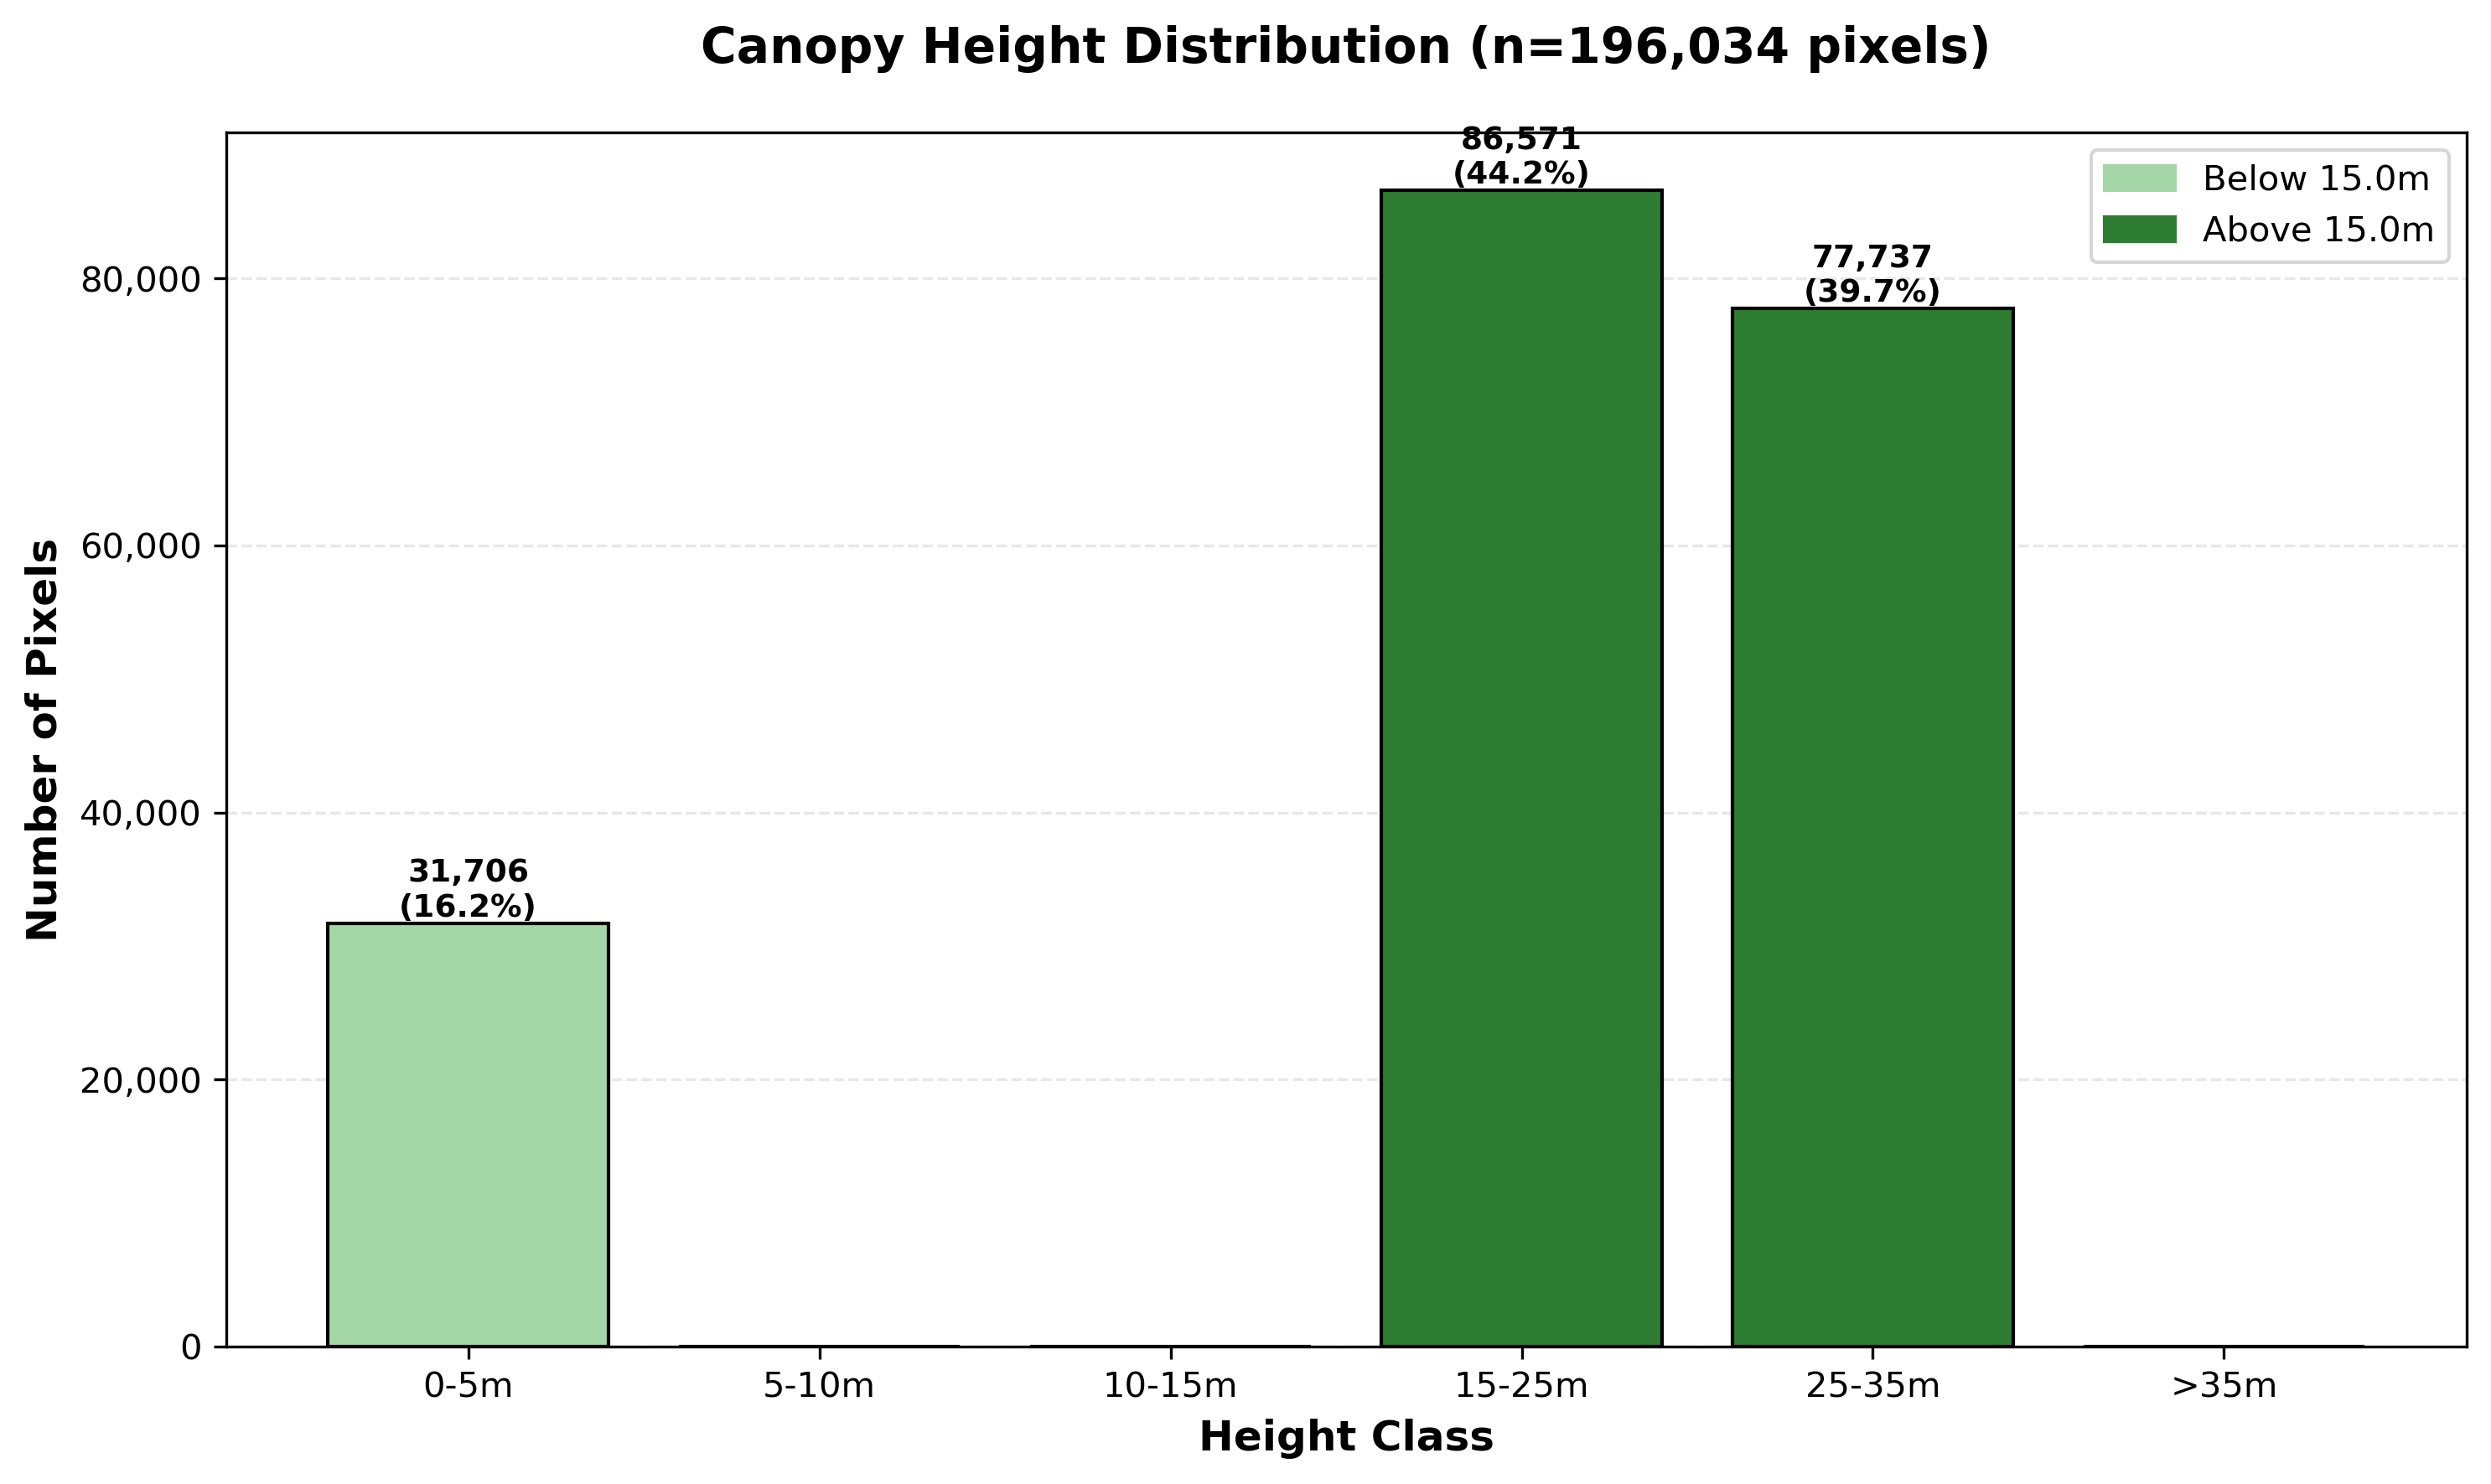


LVP04 (EBE-f 152)
  Observer:  Lücke > Baumlänge
  Derived:   0.71  (0=light .. 1=closed)
  Mean height: 17.4m | Valid pixels: 196,031


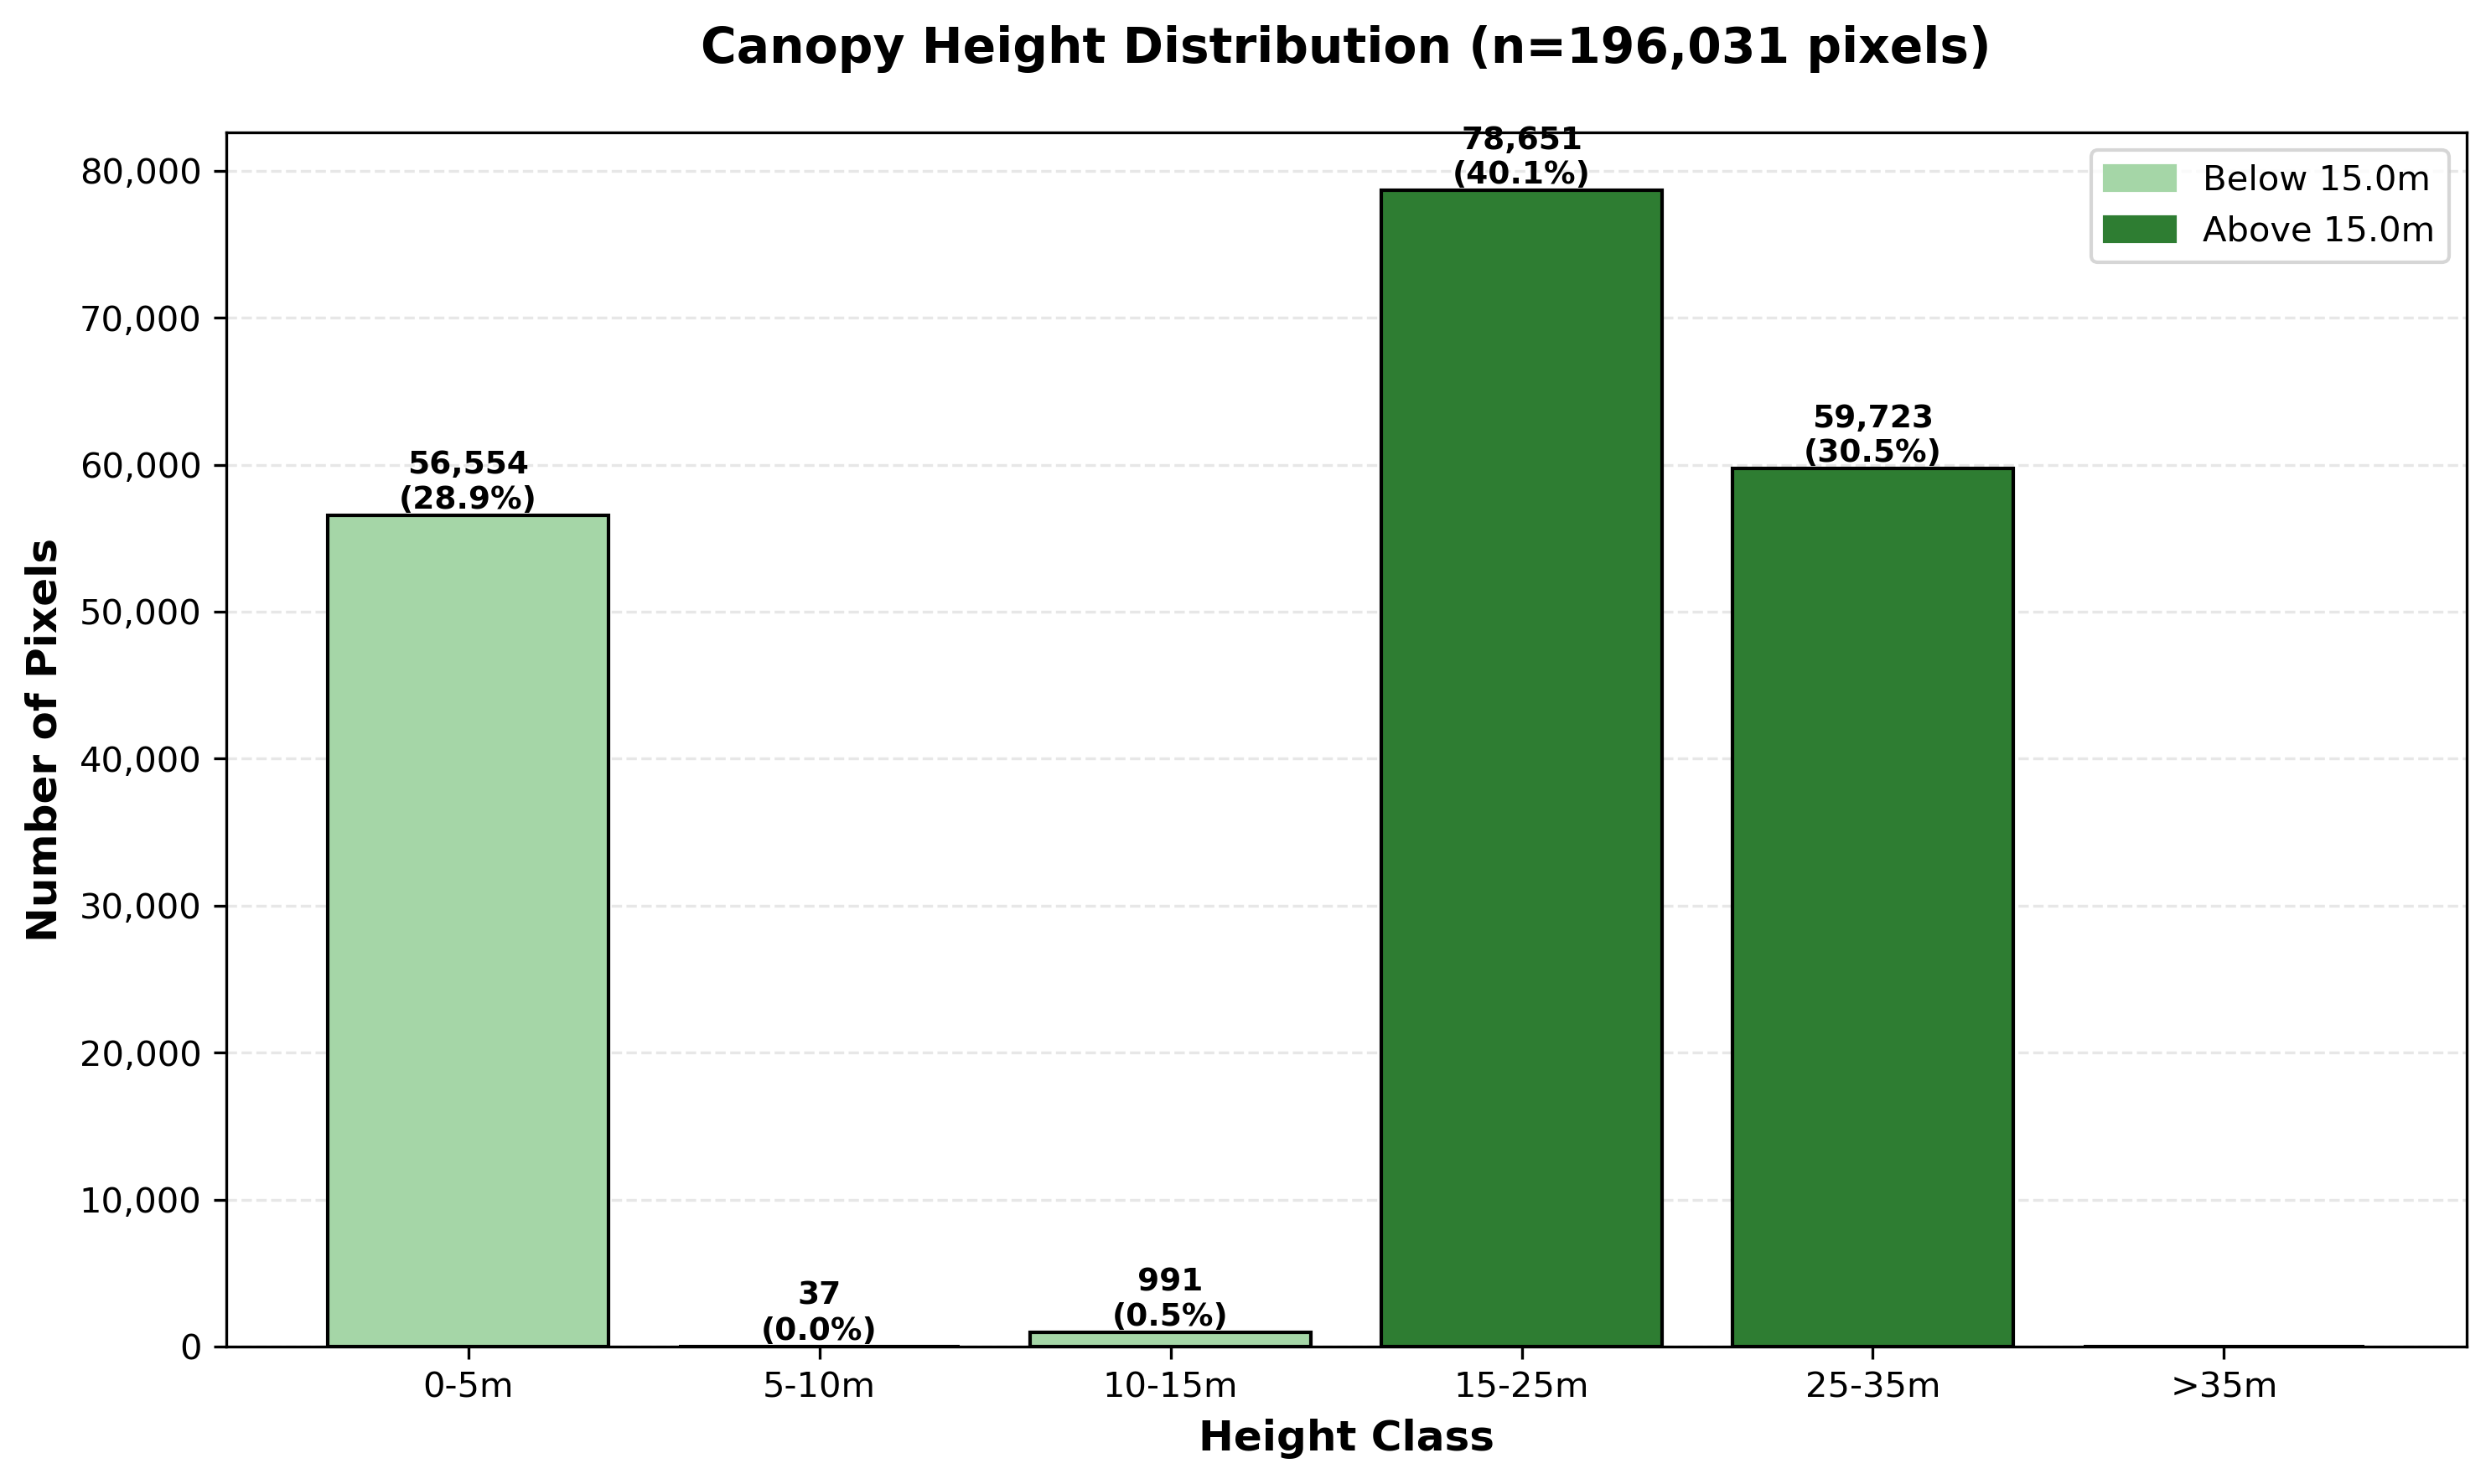


LVP05 (EBE-f 152)
  Observer:  Lücke > Baumlänge
  Derived:   0.66  (0=light .. 1=closed)
  Mean height: 15.0m | Valid pixels: 196,033


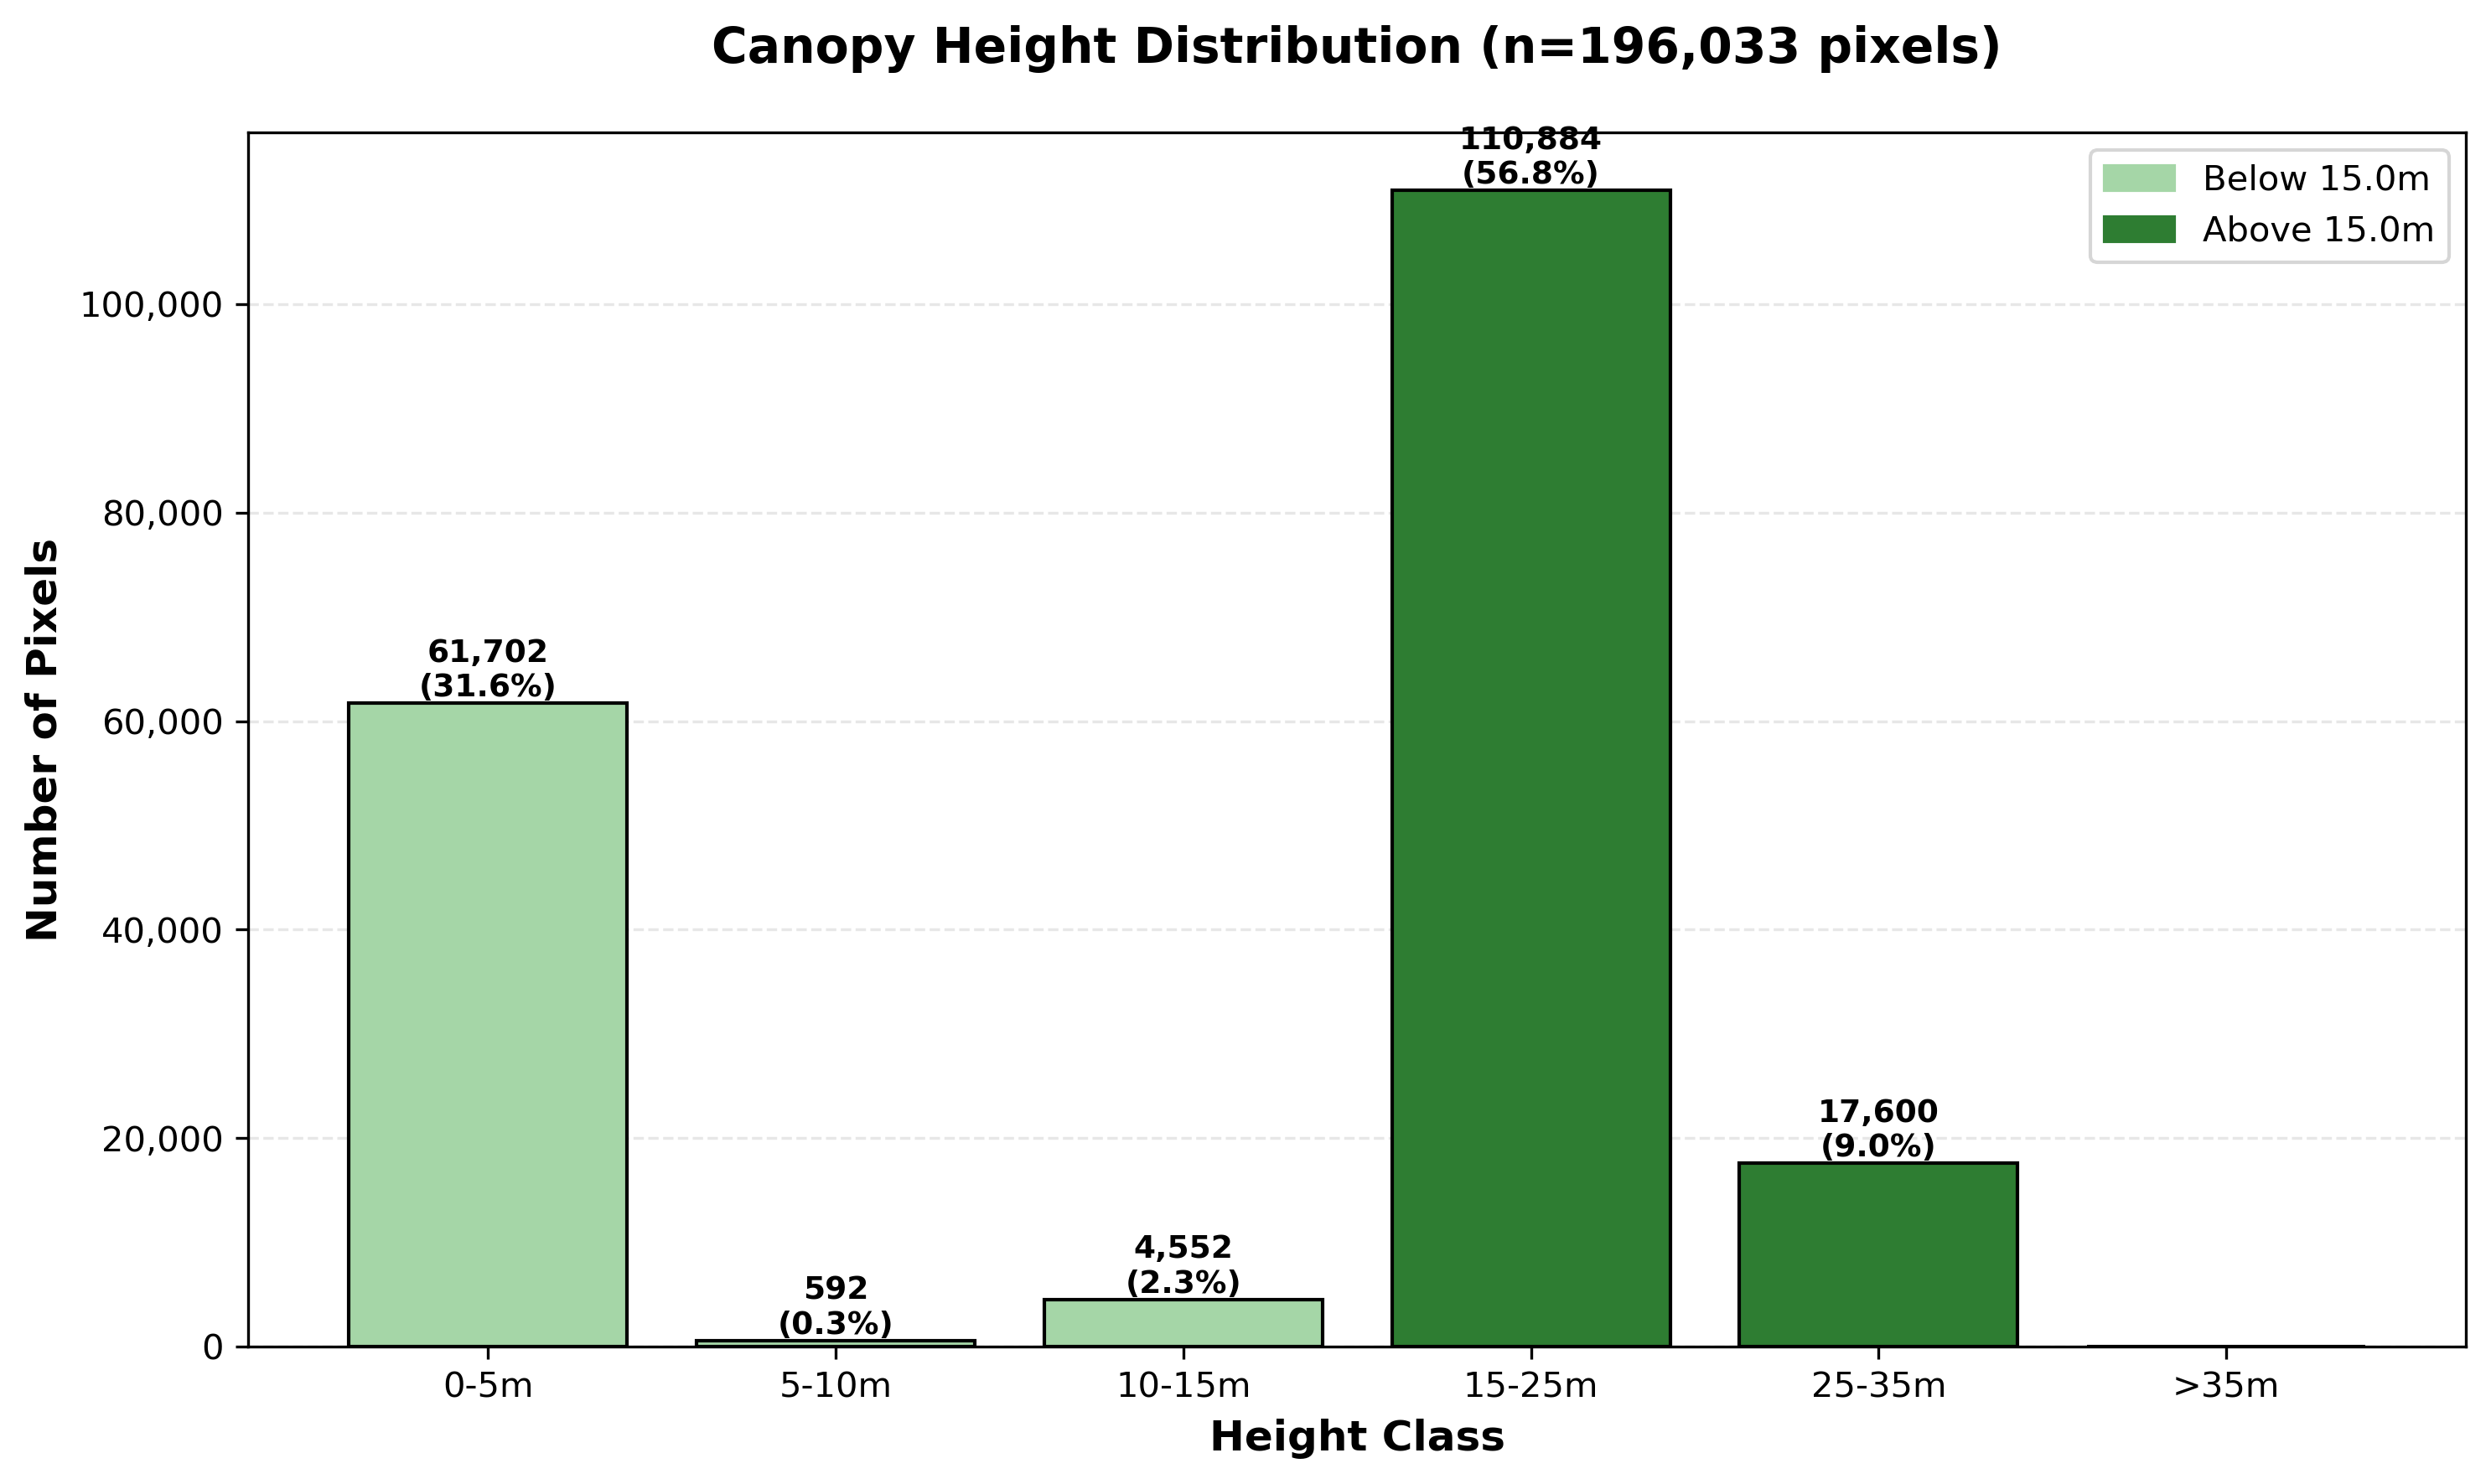


LVP06 (EBE-f 152)
  Observer:  Licht-Geschlossen/Licht
  Derived:   0.68  (0=light .. 1=closed)
  Mean height: 15.4m | Valid pixels: 196,025


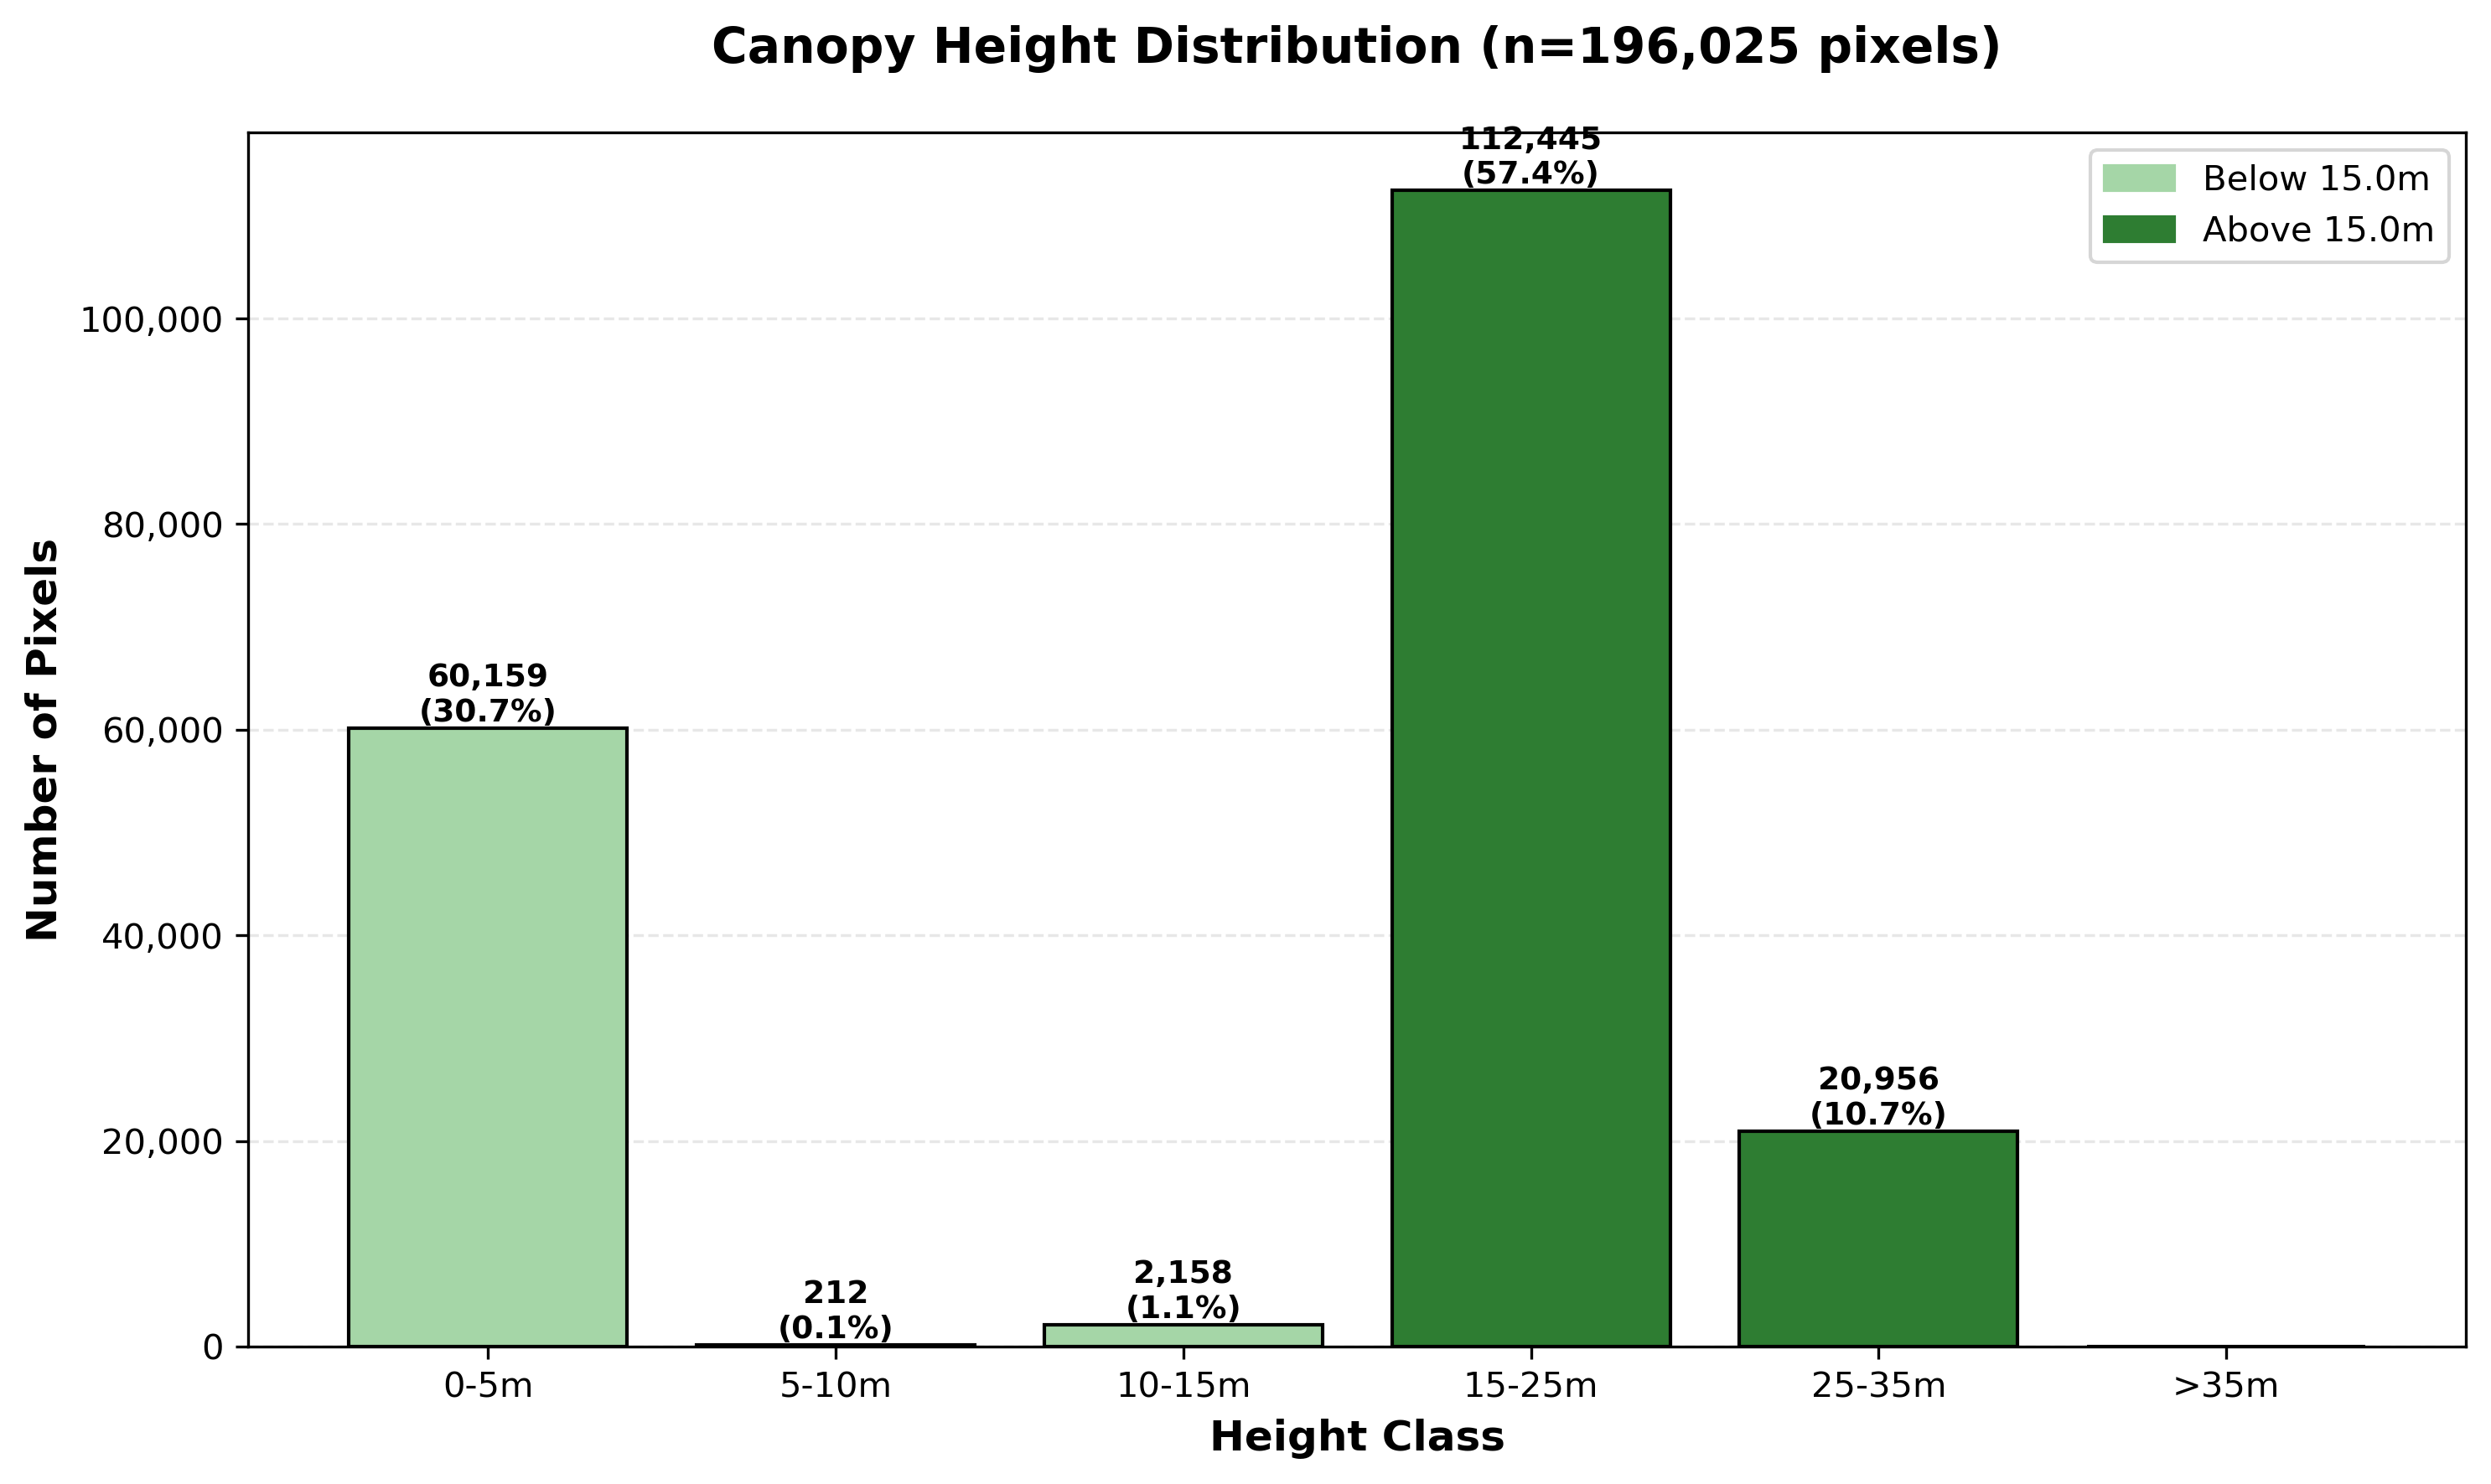


LVP07 (EBE-f 152)
  Observer:  Lücke > Baumlänge
  Derived:   0.45  (0=light .. 1=closed)
  Mean height: 11.0m | Valid pixels: 196,033


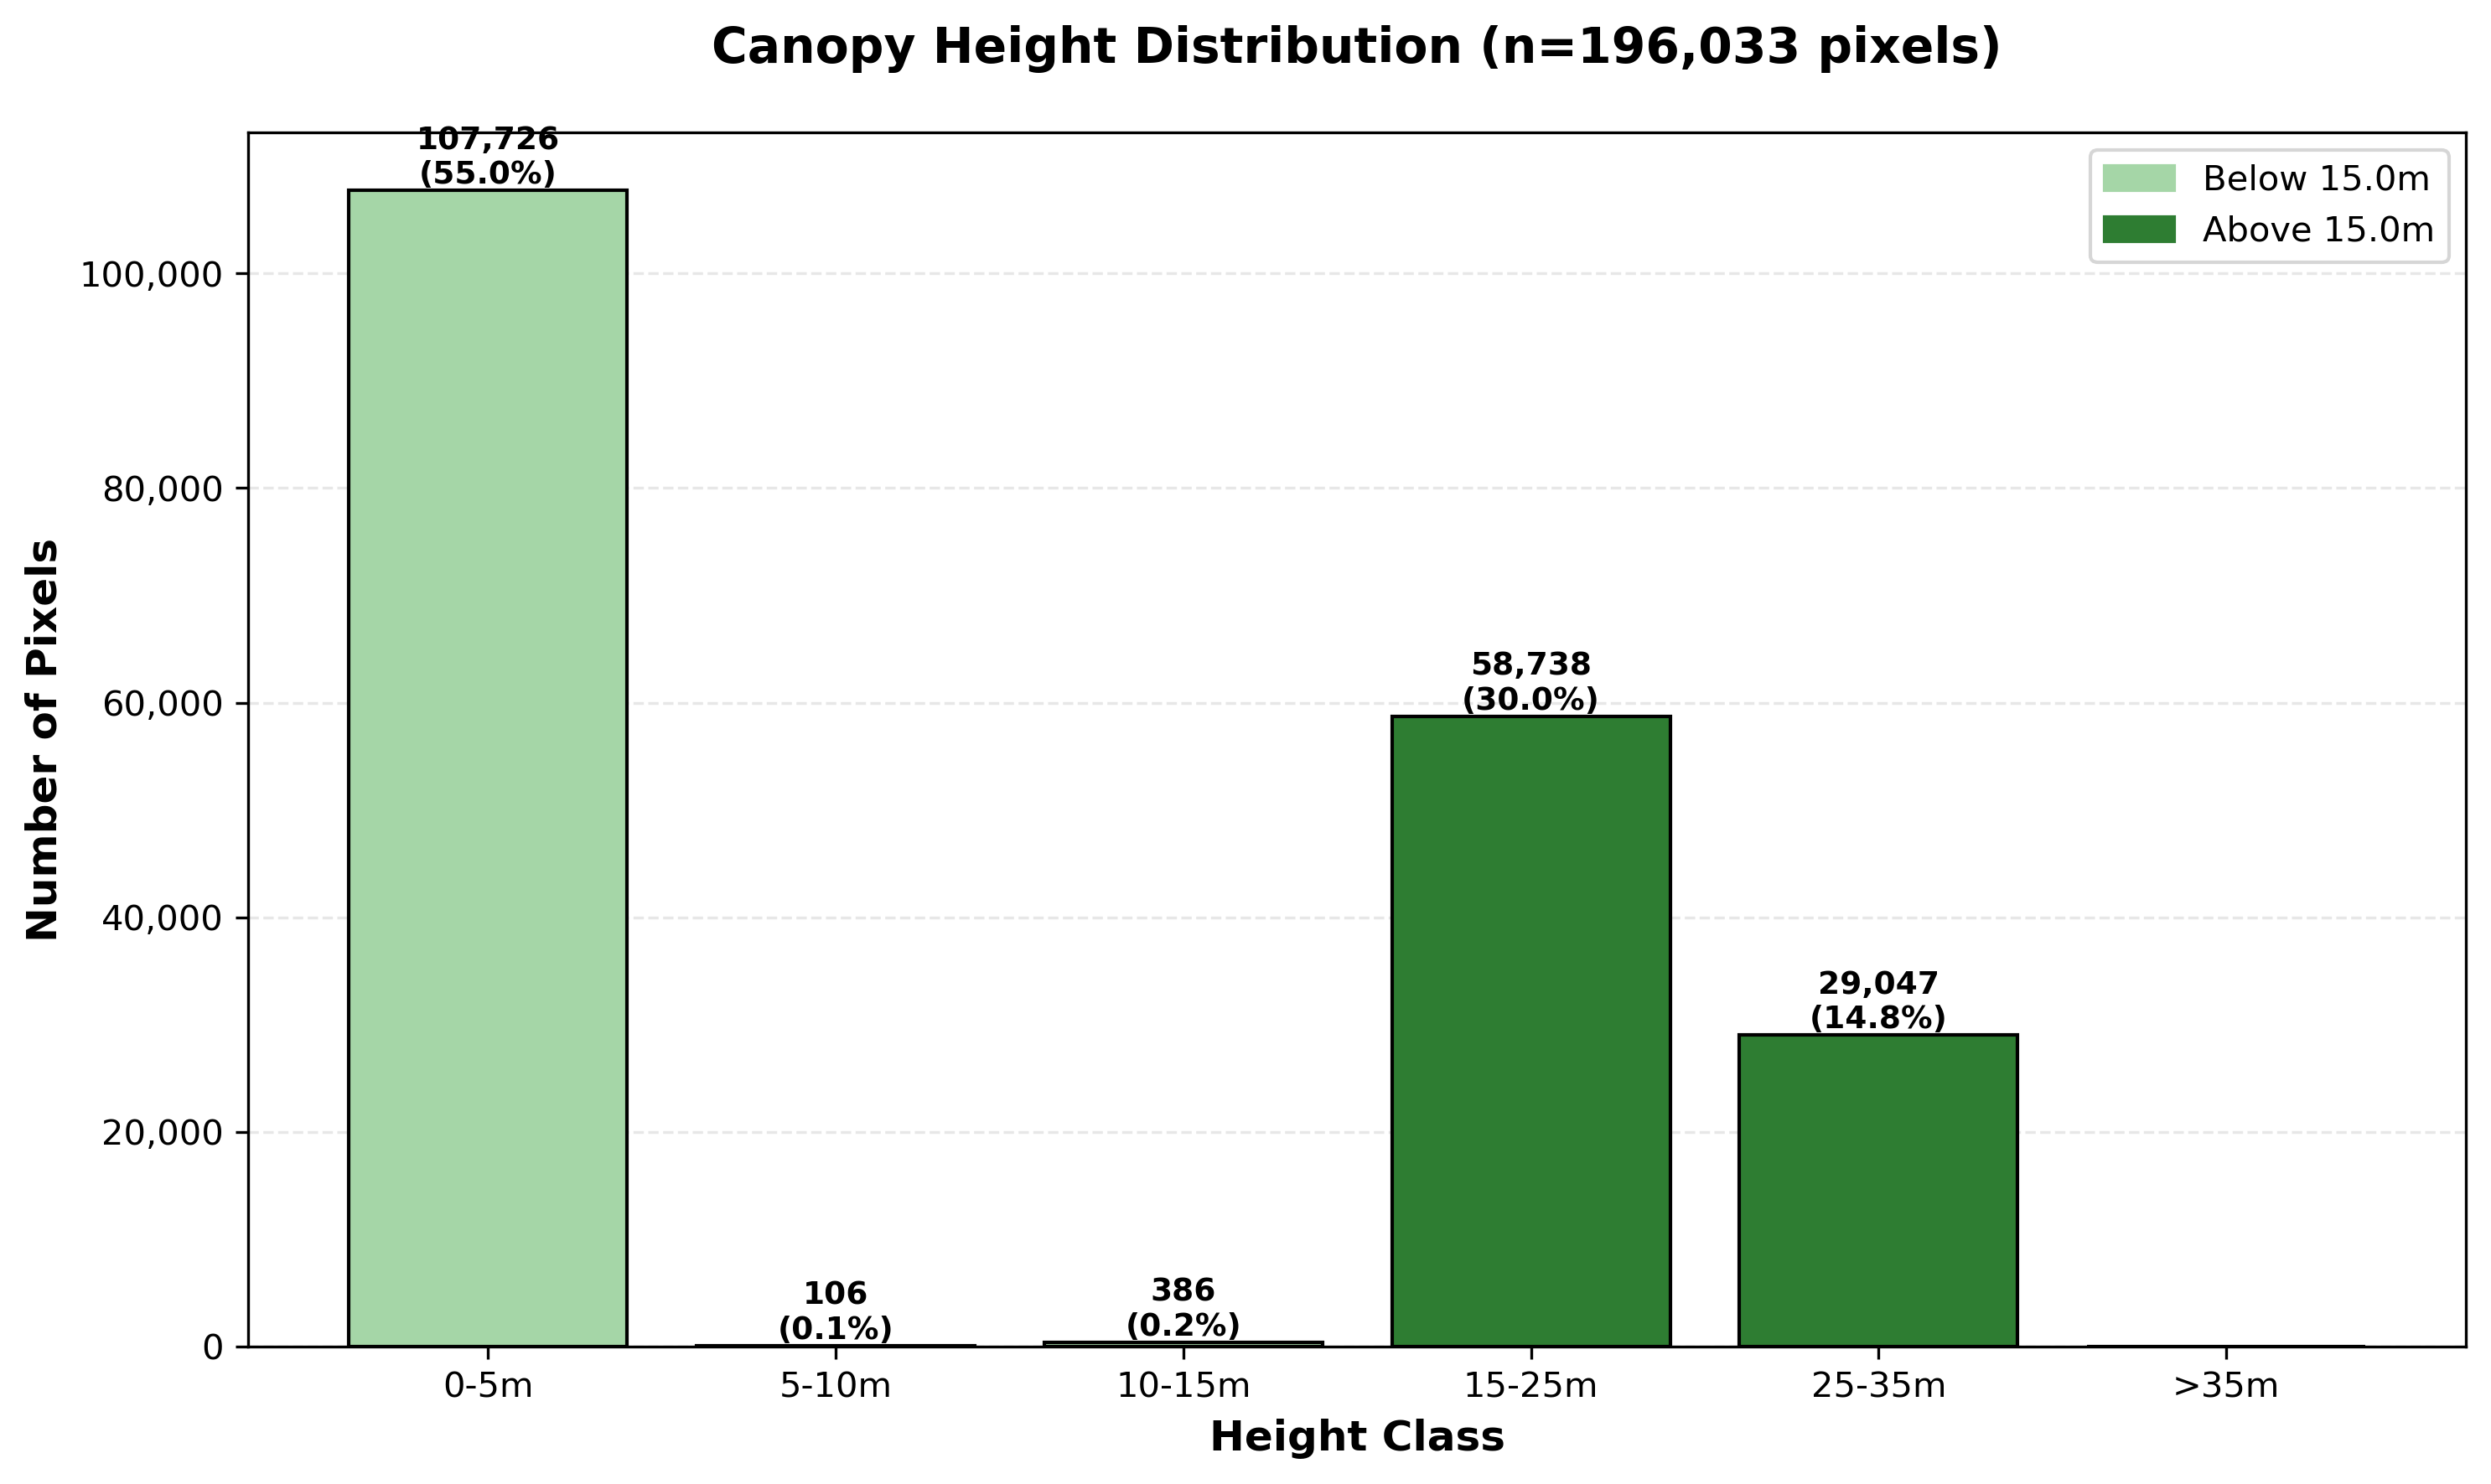


LVP08 (EBE-f 152)
  Observer:  Licht-Geschlossen/Licht
  Derived:   0.88  (0=light .. 1=closed)
  Mean height: 22.2m | Valid pixels: 196,027


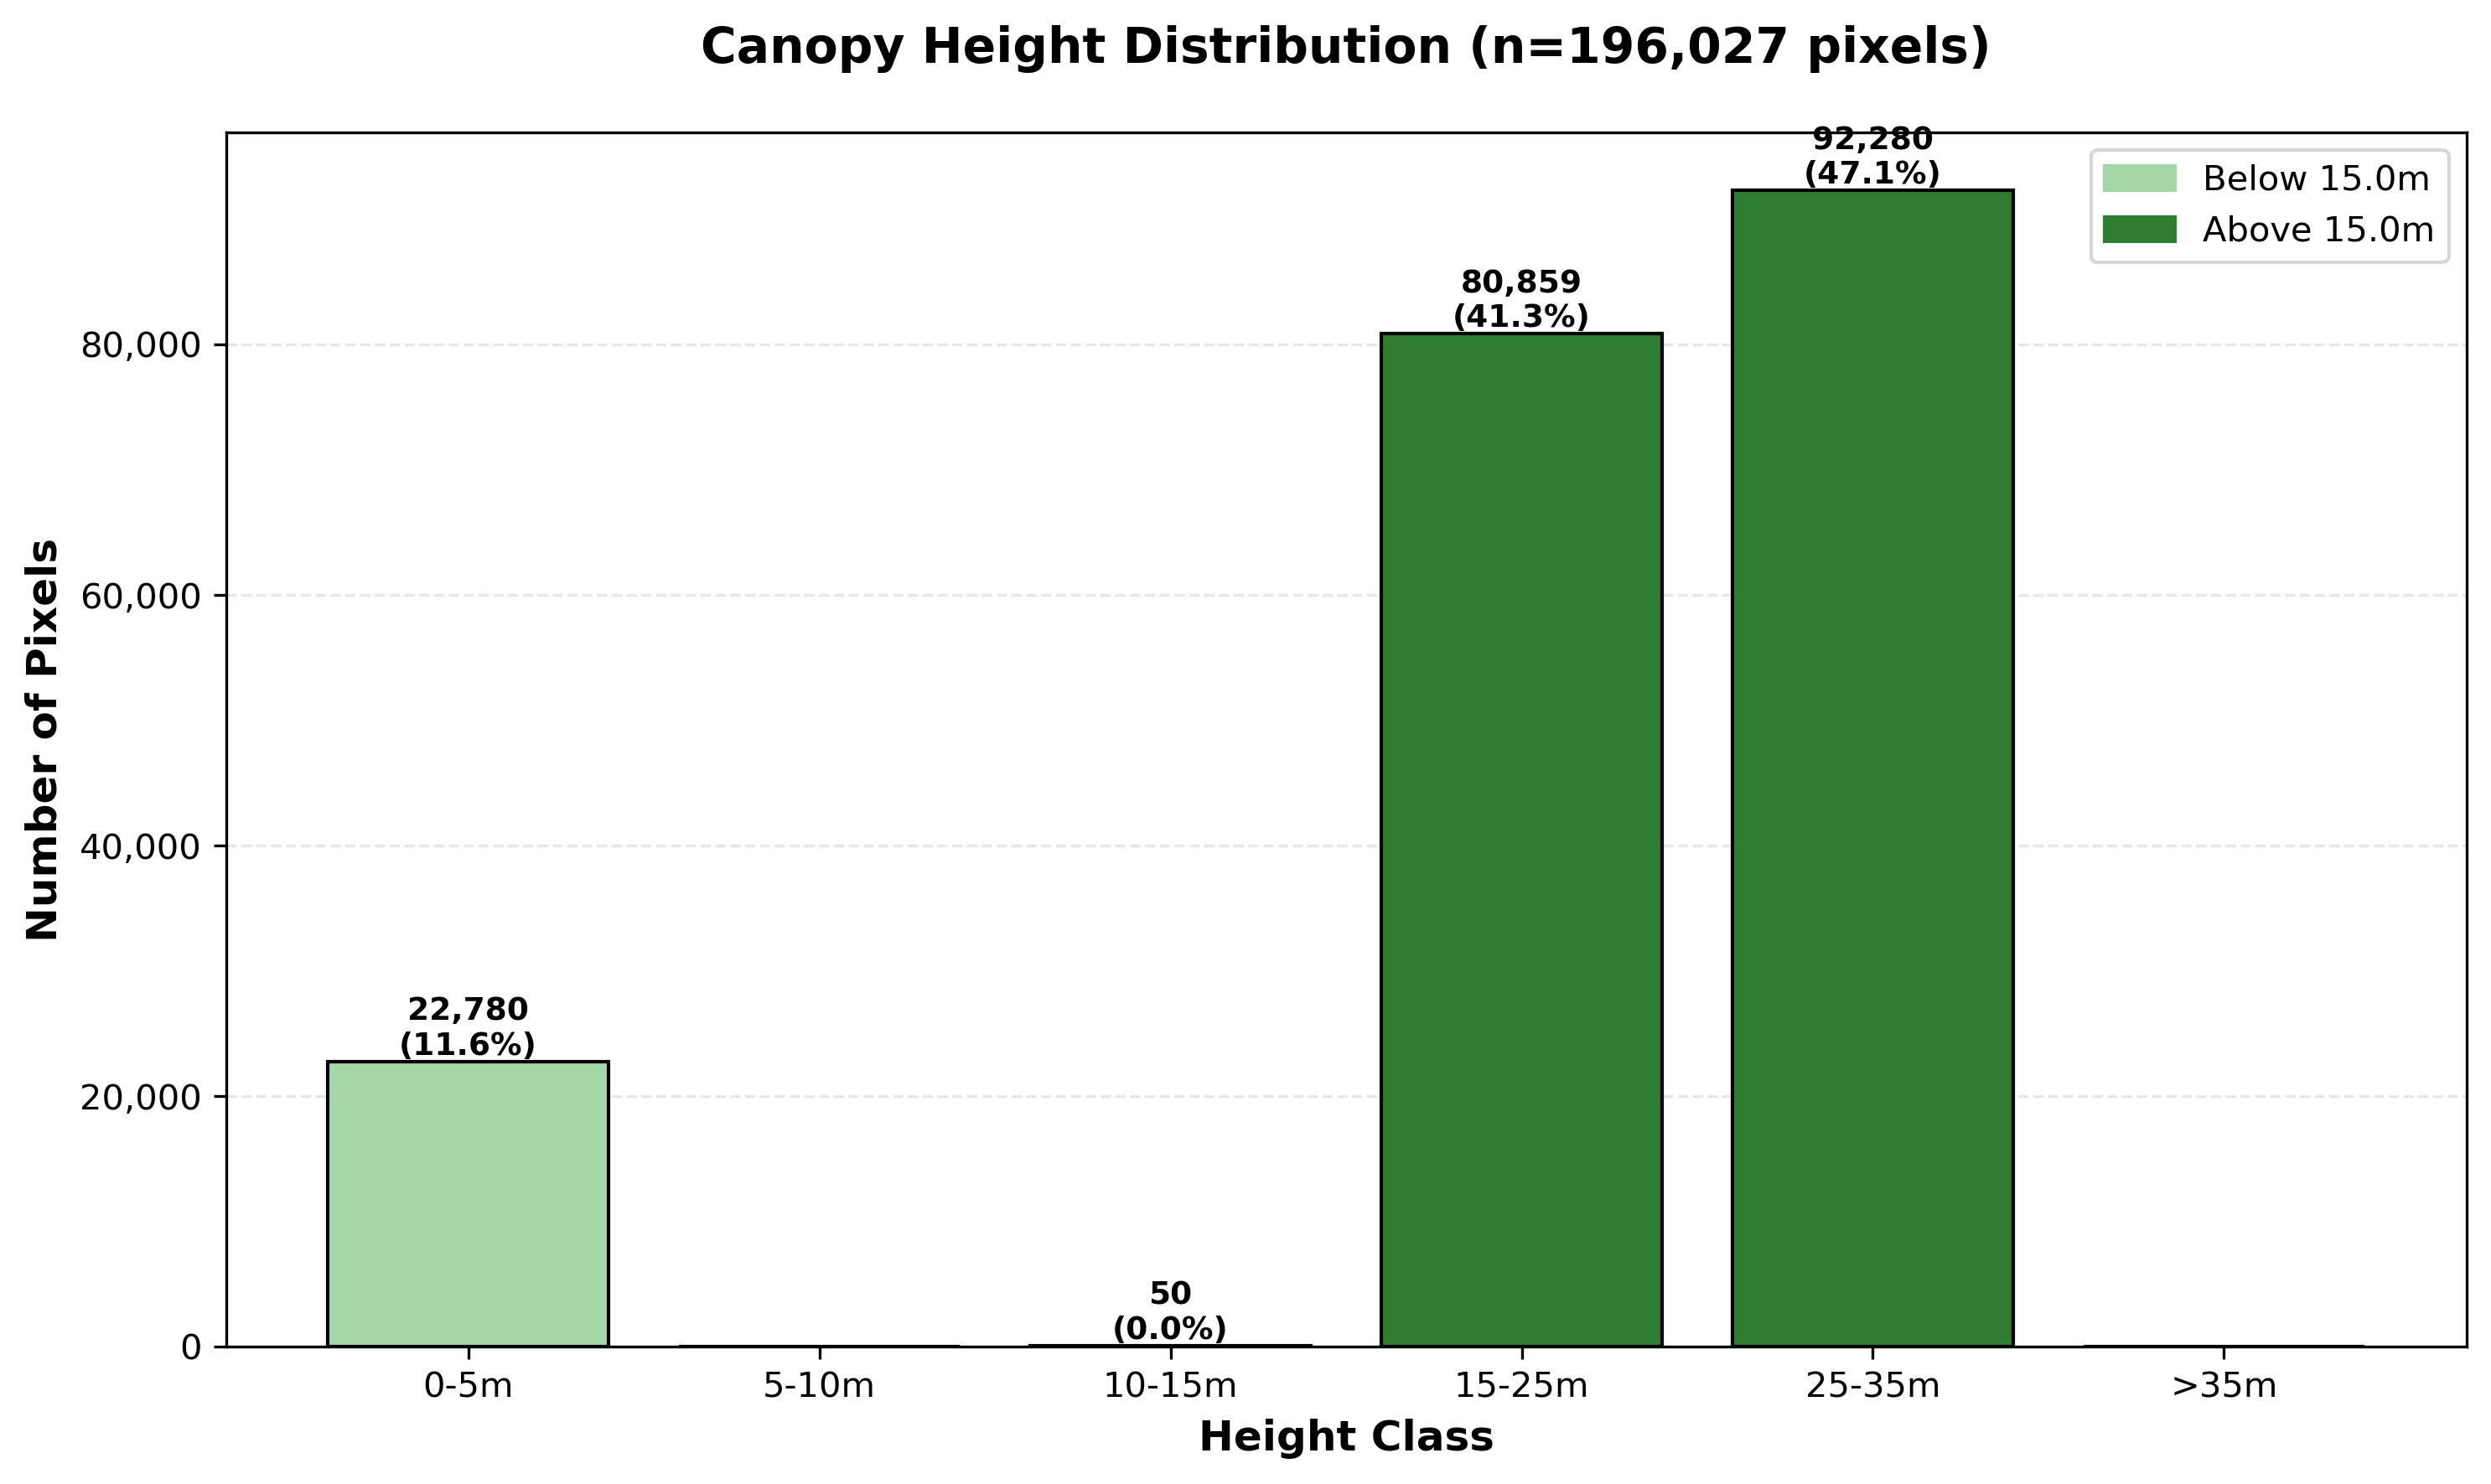


LVP09 (EBE-f 152)
  Observer:  Licht-Geschlossen/Licht
  Derived:   0.93  (0=light .. 1=closed)
  Mean height: 24.0m | Valid pixels: 196,031


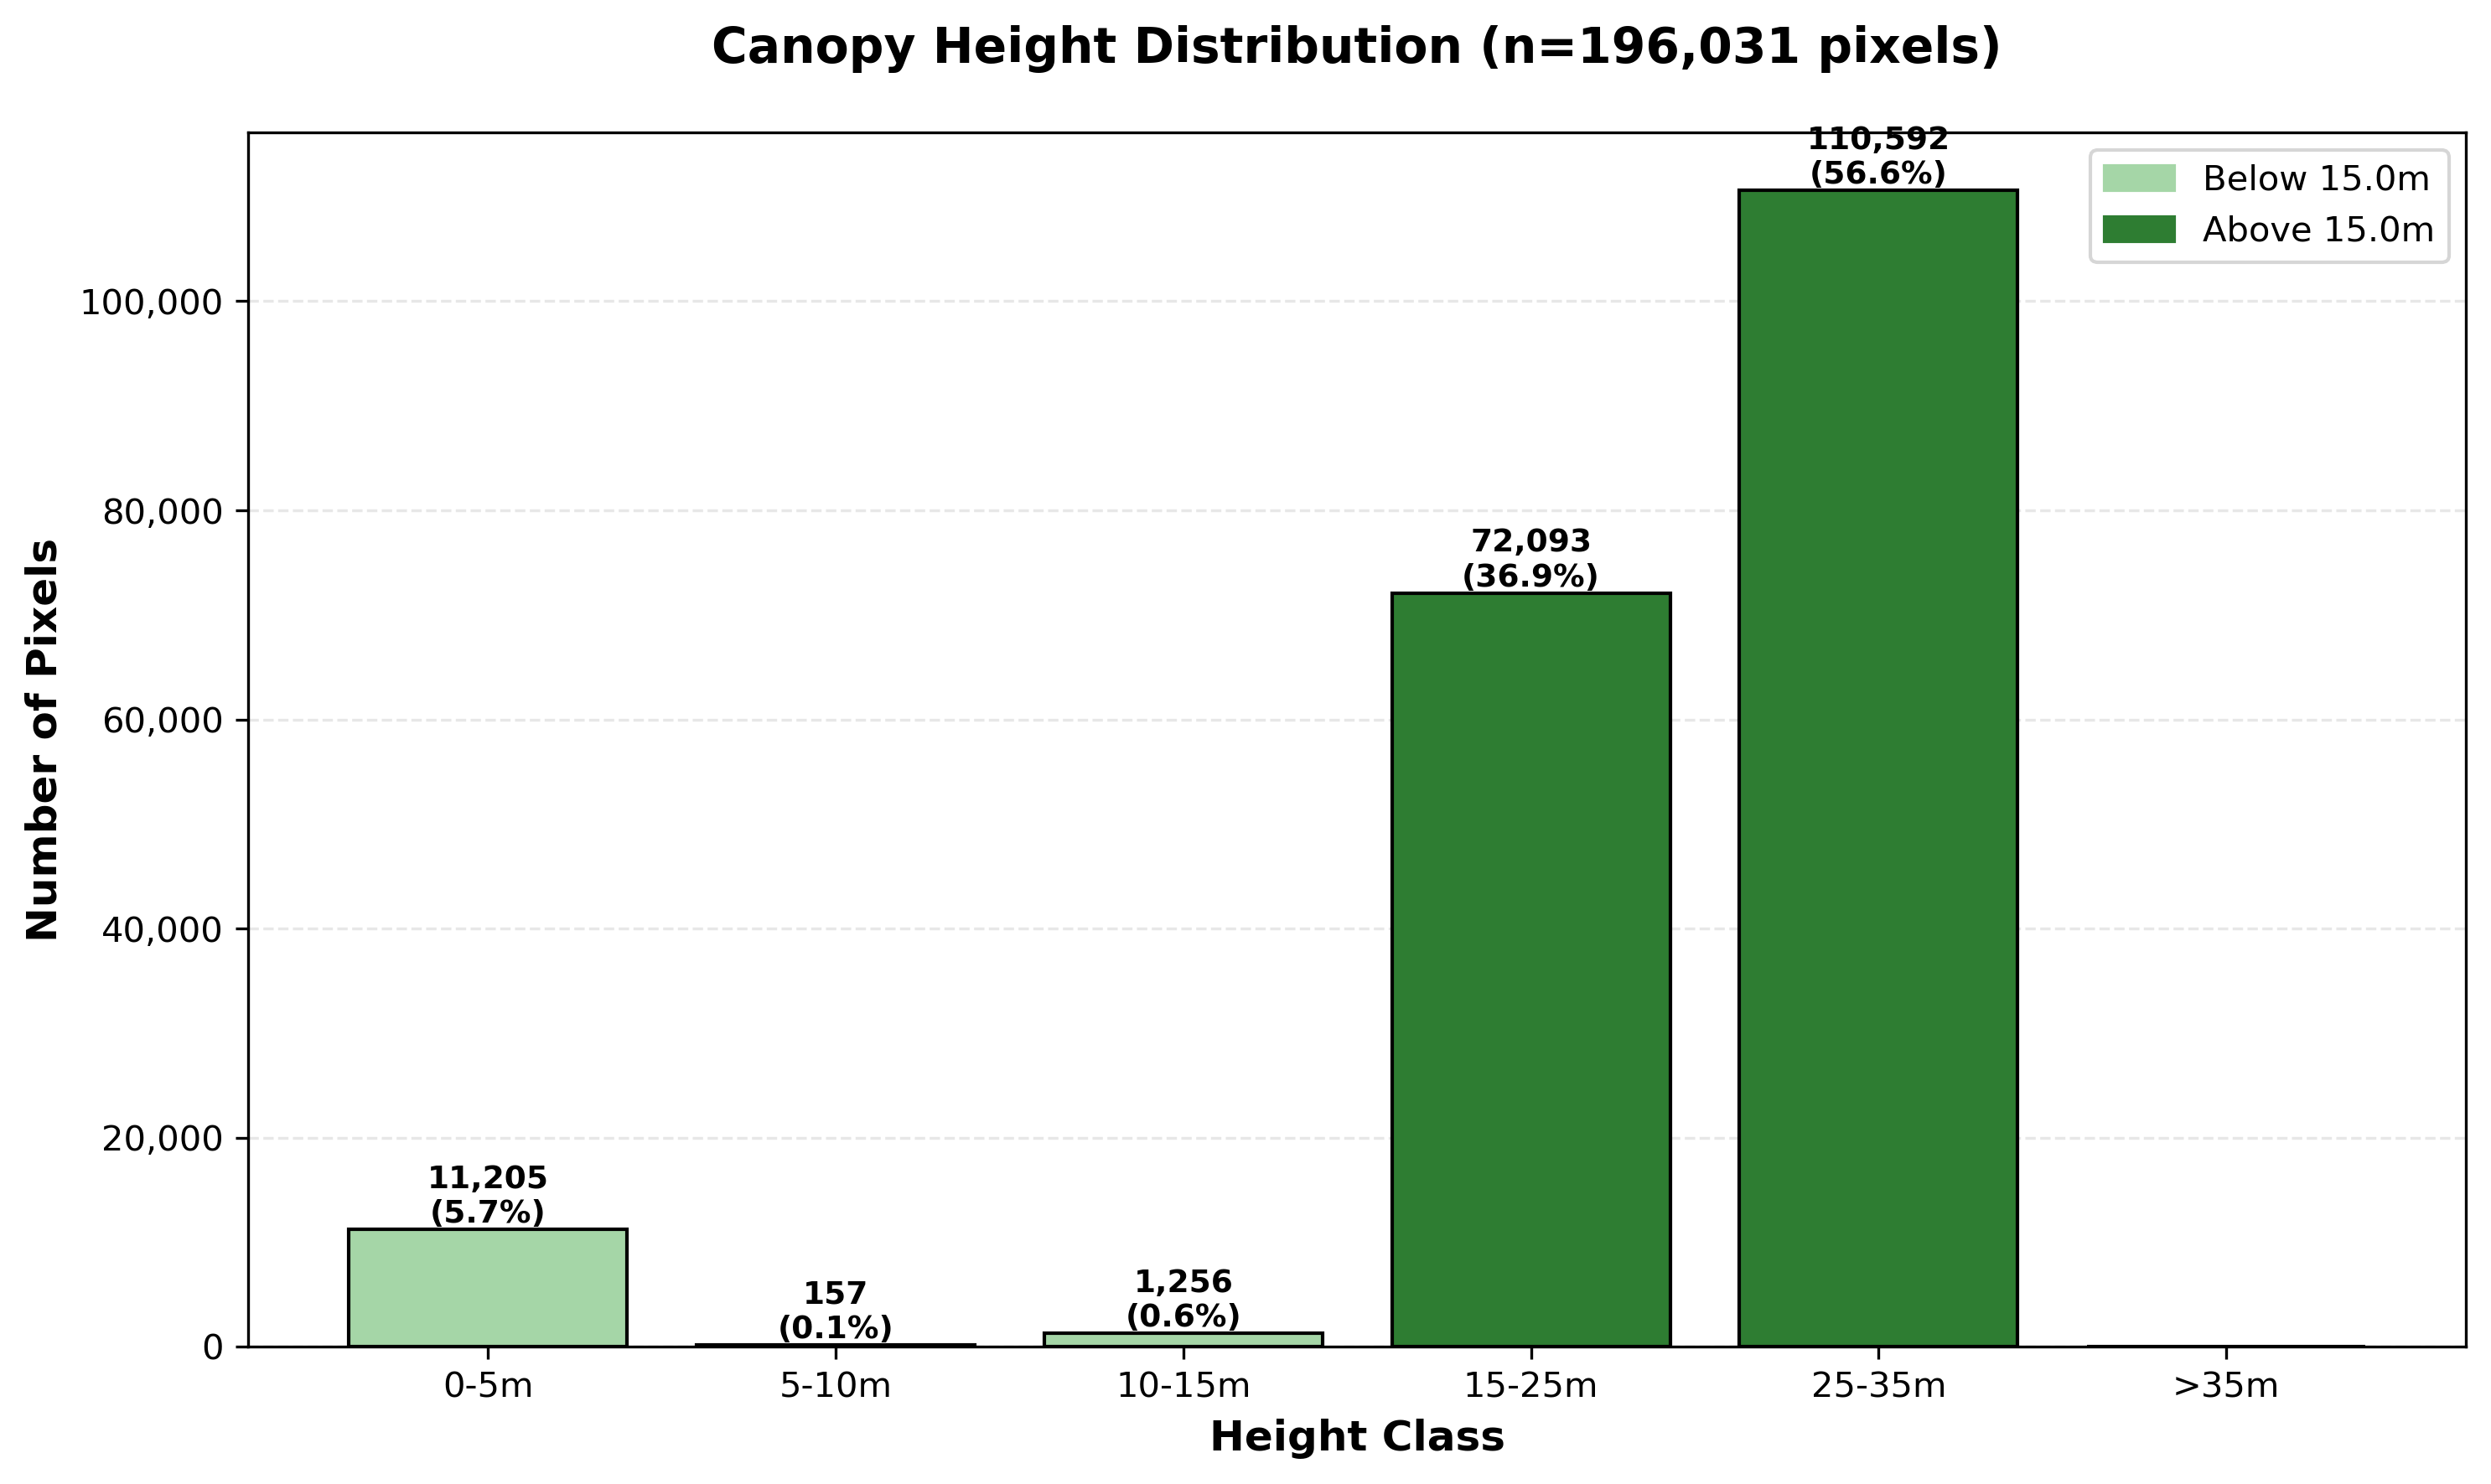


LVP10 (EBE-f 152)
  Observer:  Licht-Geschlossen/Licht
  Derived:   0.84  (0=light .. 1=closed)
  Mean height: 21.2m | Valid pixels: 196,034


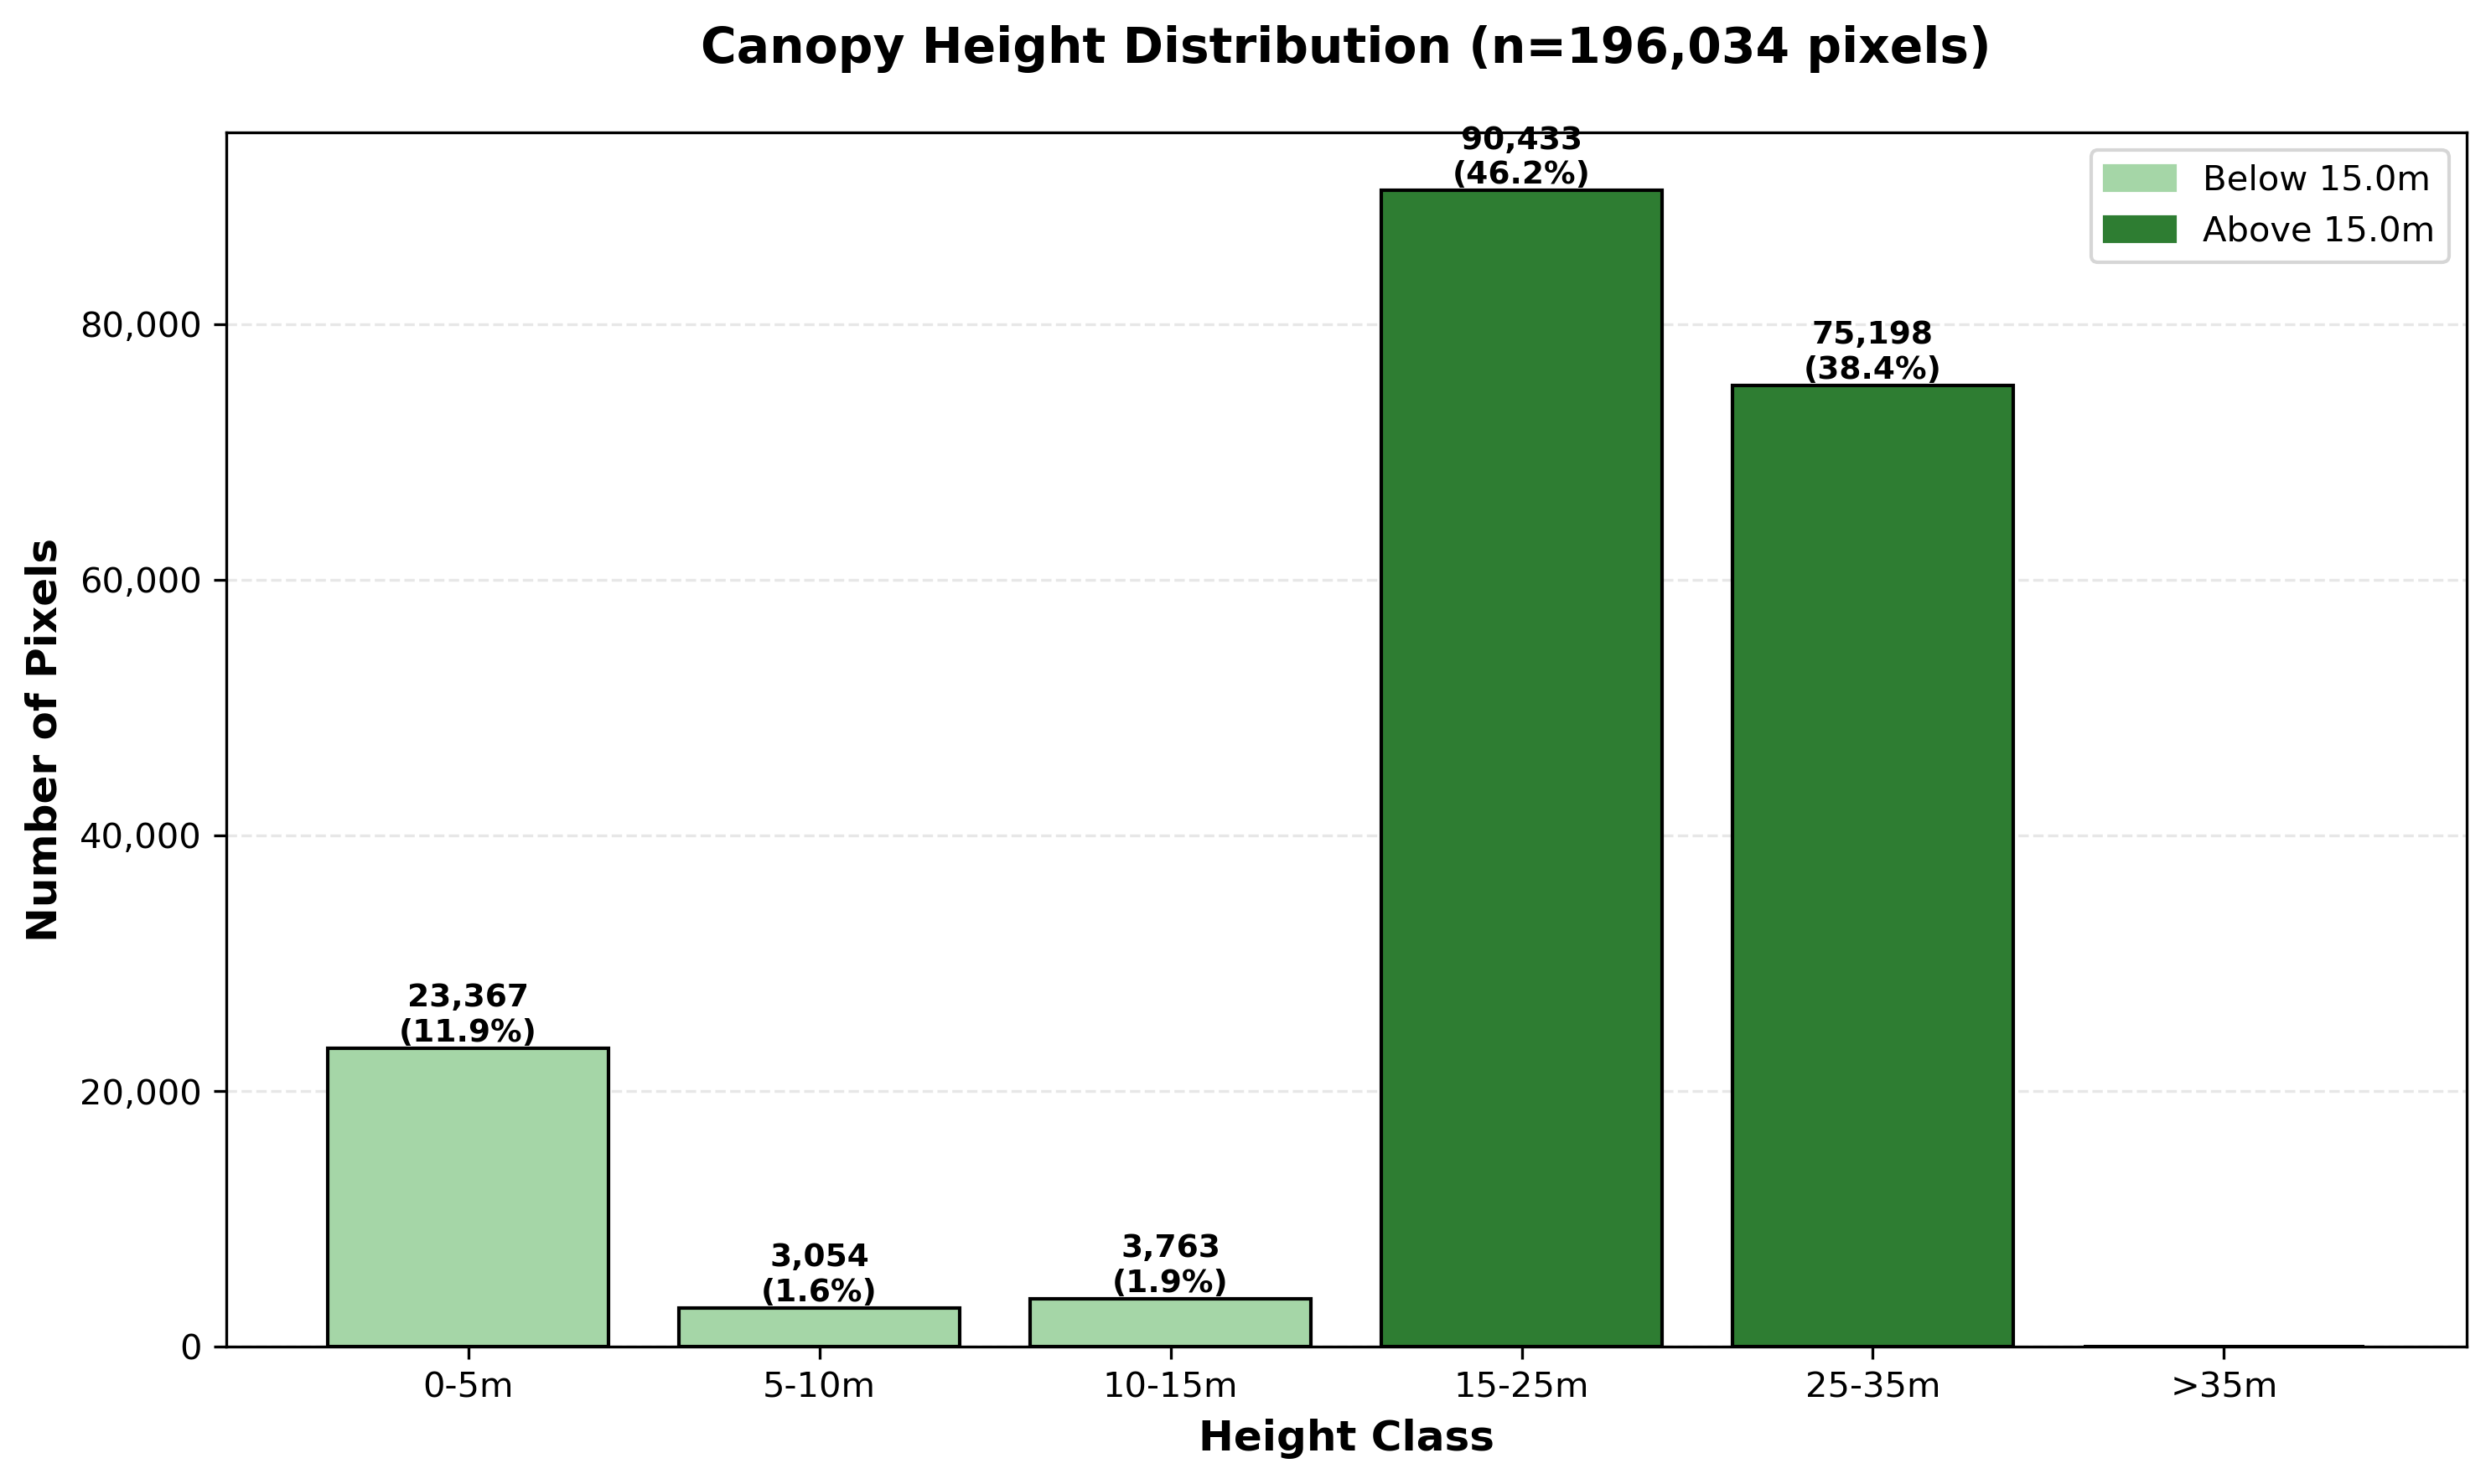


LVP11 (EBE-any)
  Observer:  Geschlossen/Gedrängt
  Derived:   0.88  (0=light .. 1=closed)
  Mean height: 21.7m | Valid pixels: 196,026


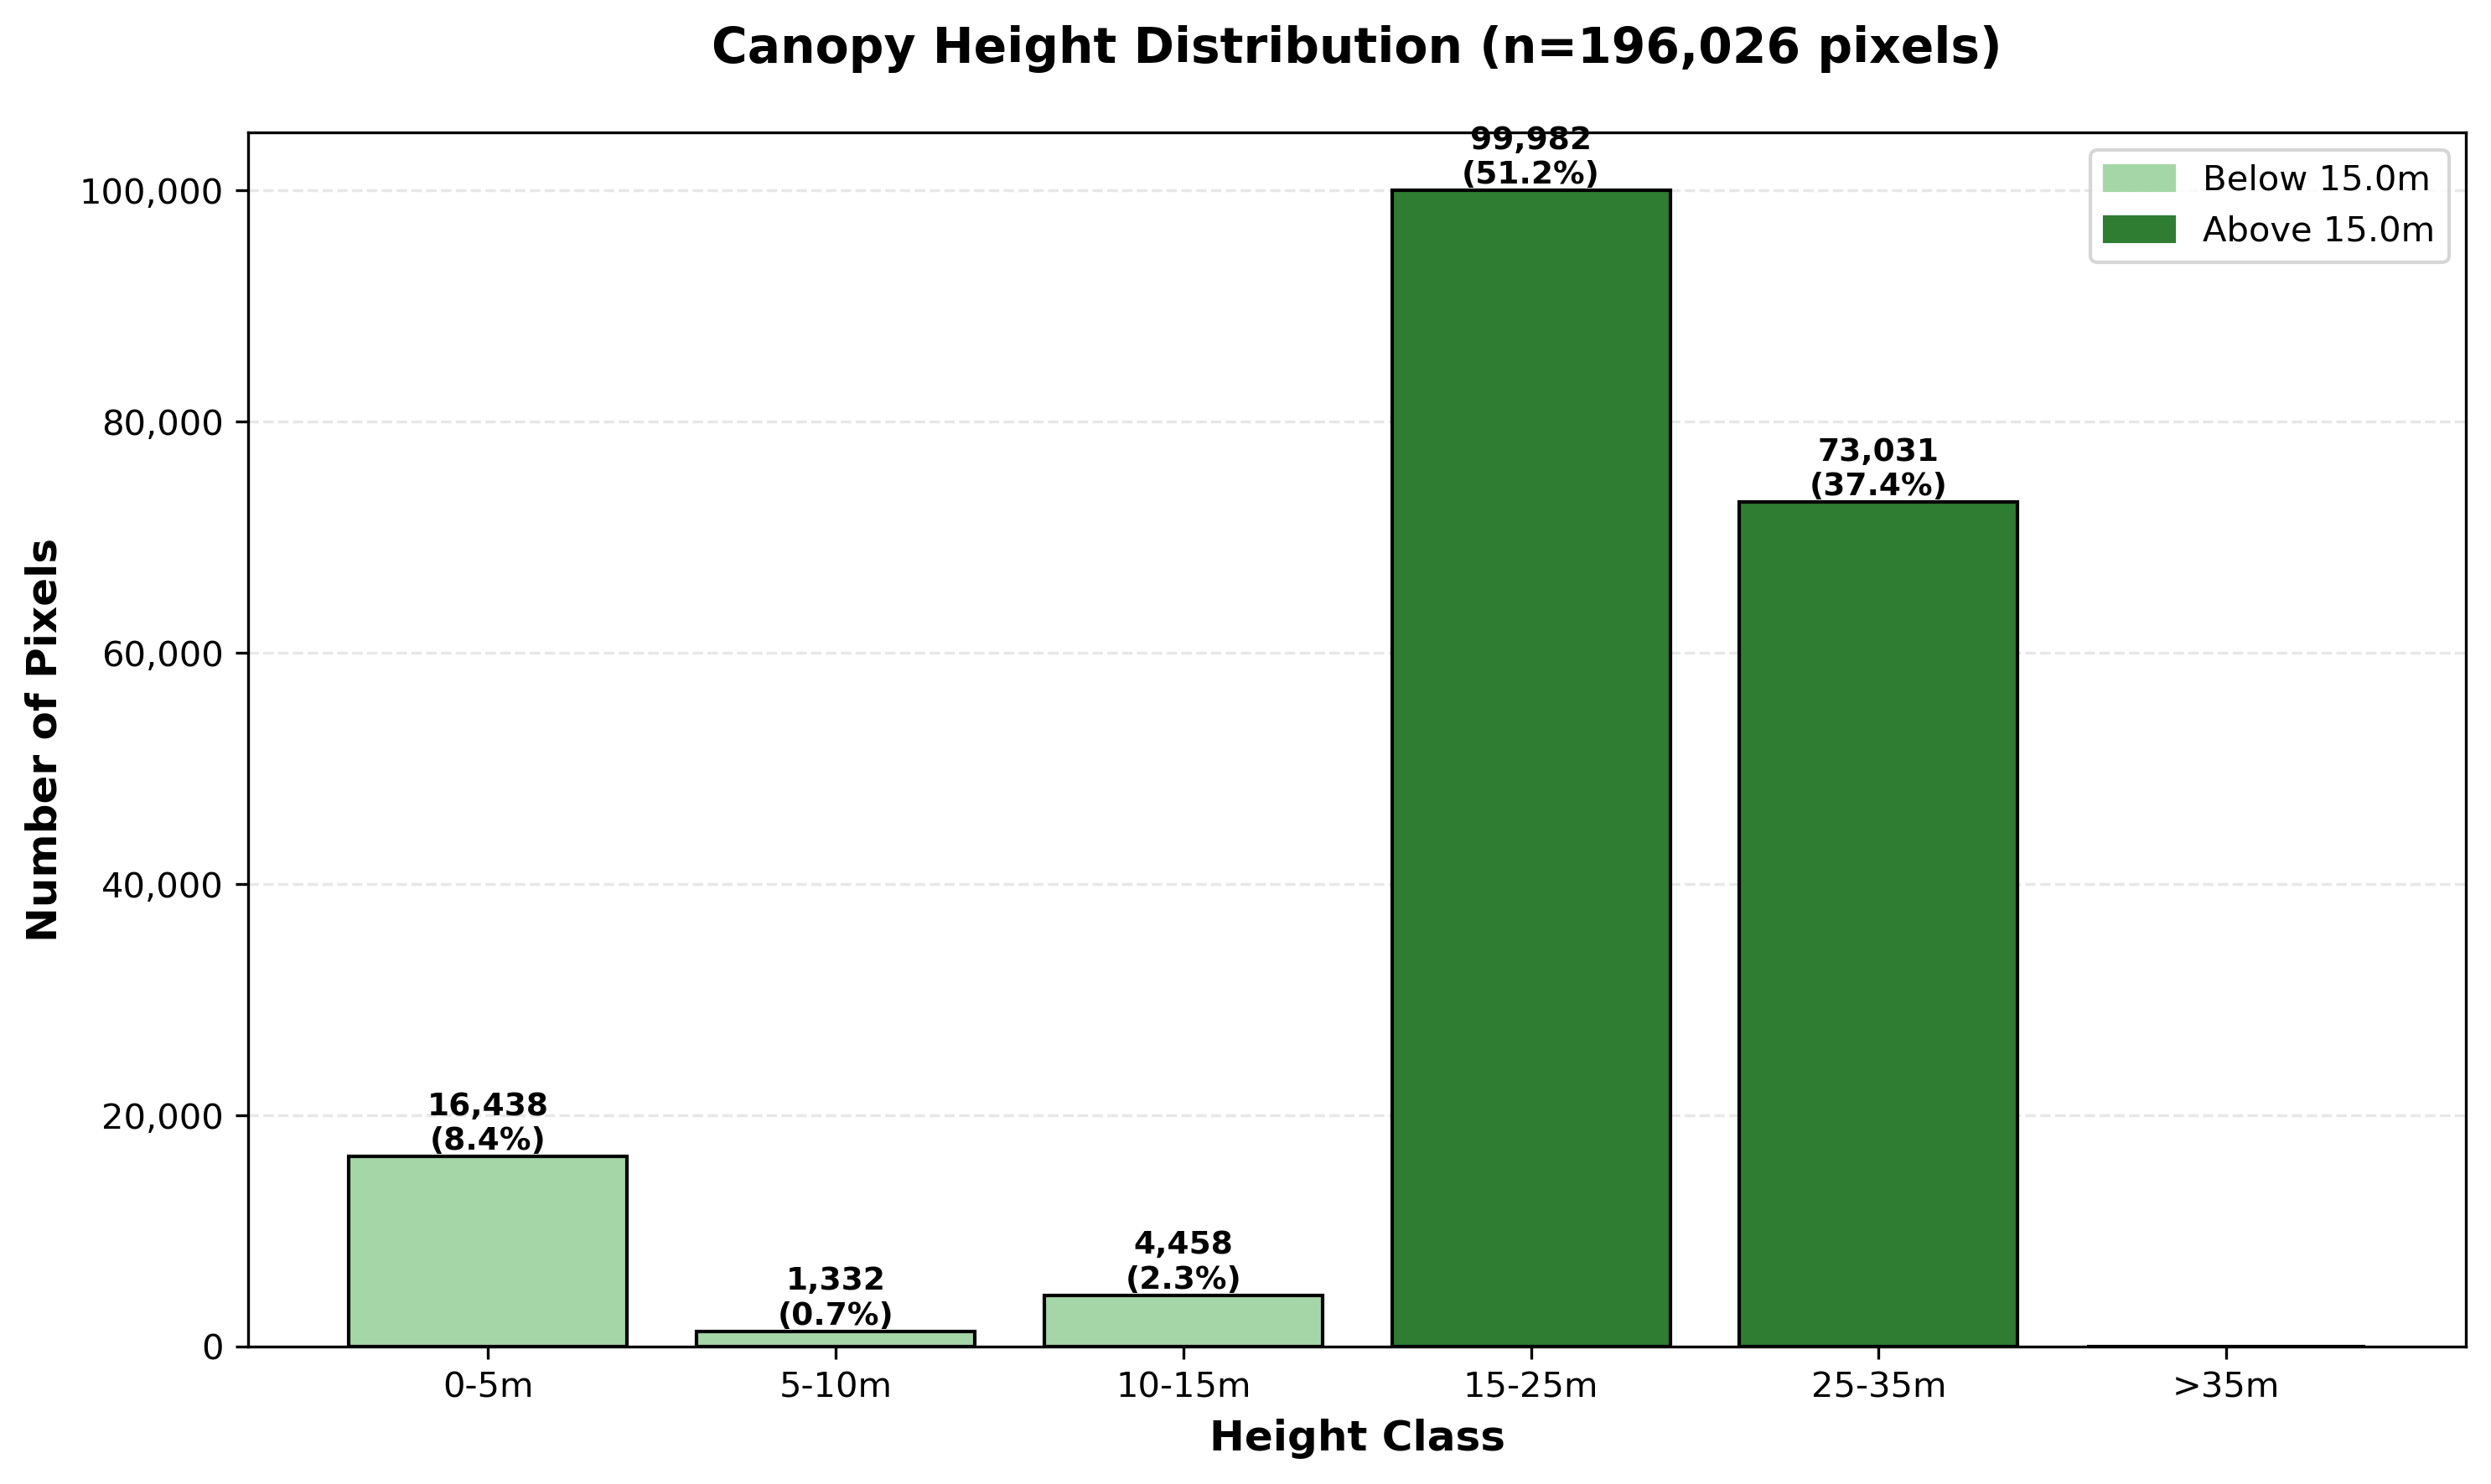


LVP12 (EBE-e 155)
  Observer:  Lücke > Baumlänge
  Derived:   0.69  (0=light .. 1=closed)
  Mean height: 16.8m | Valid pixels: 196,034


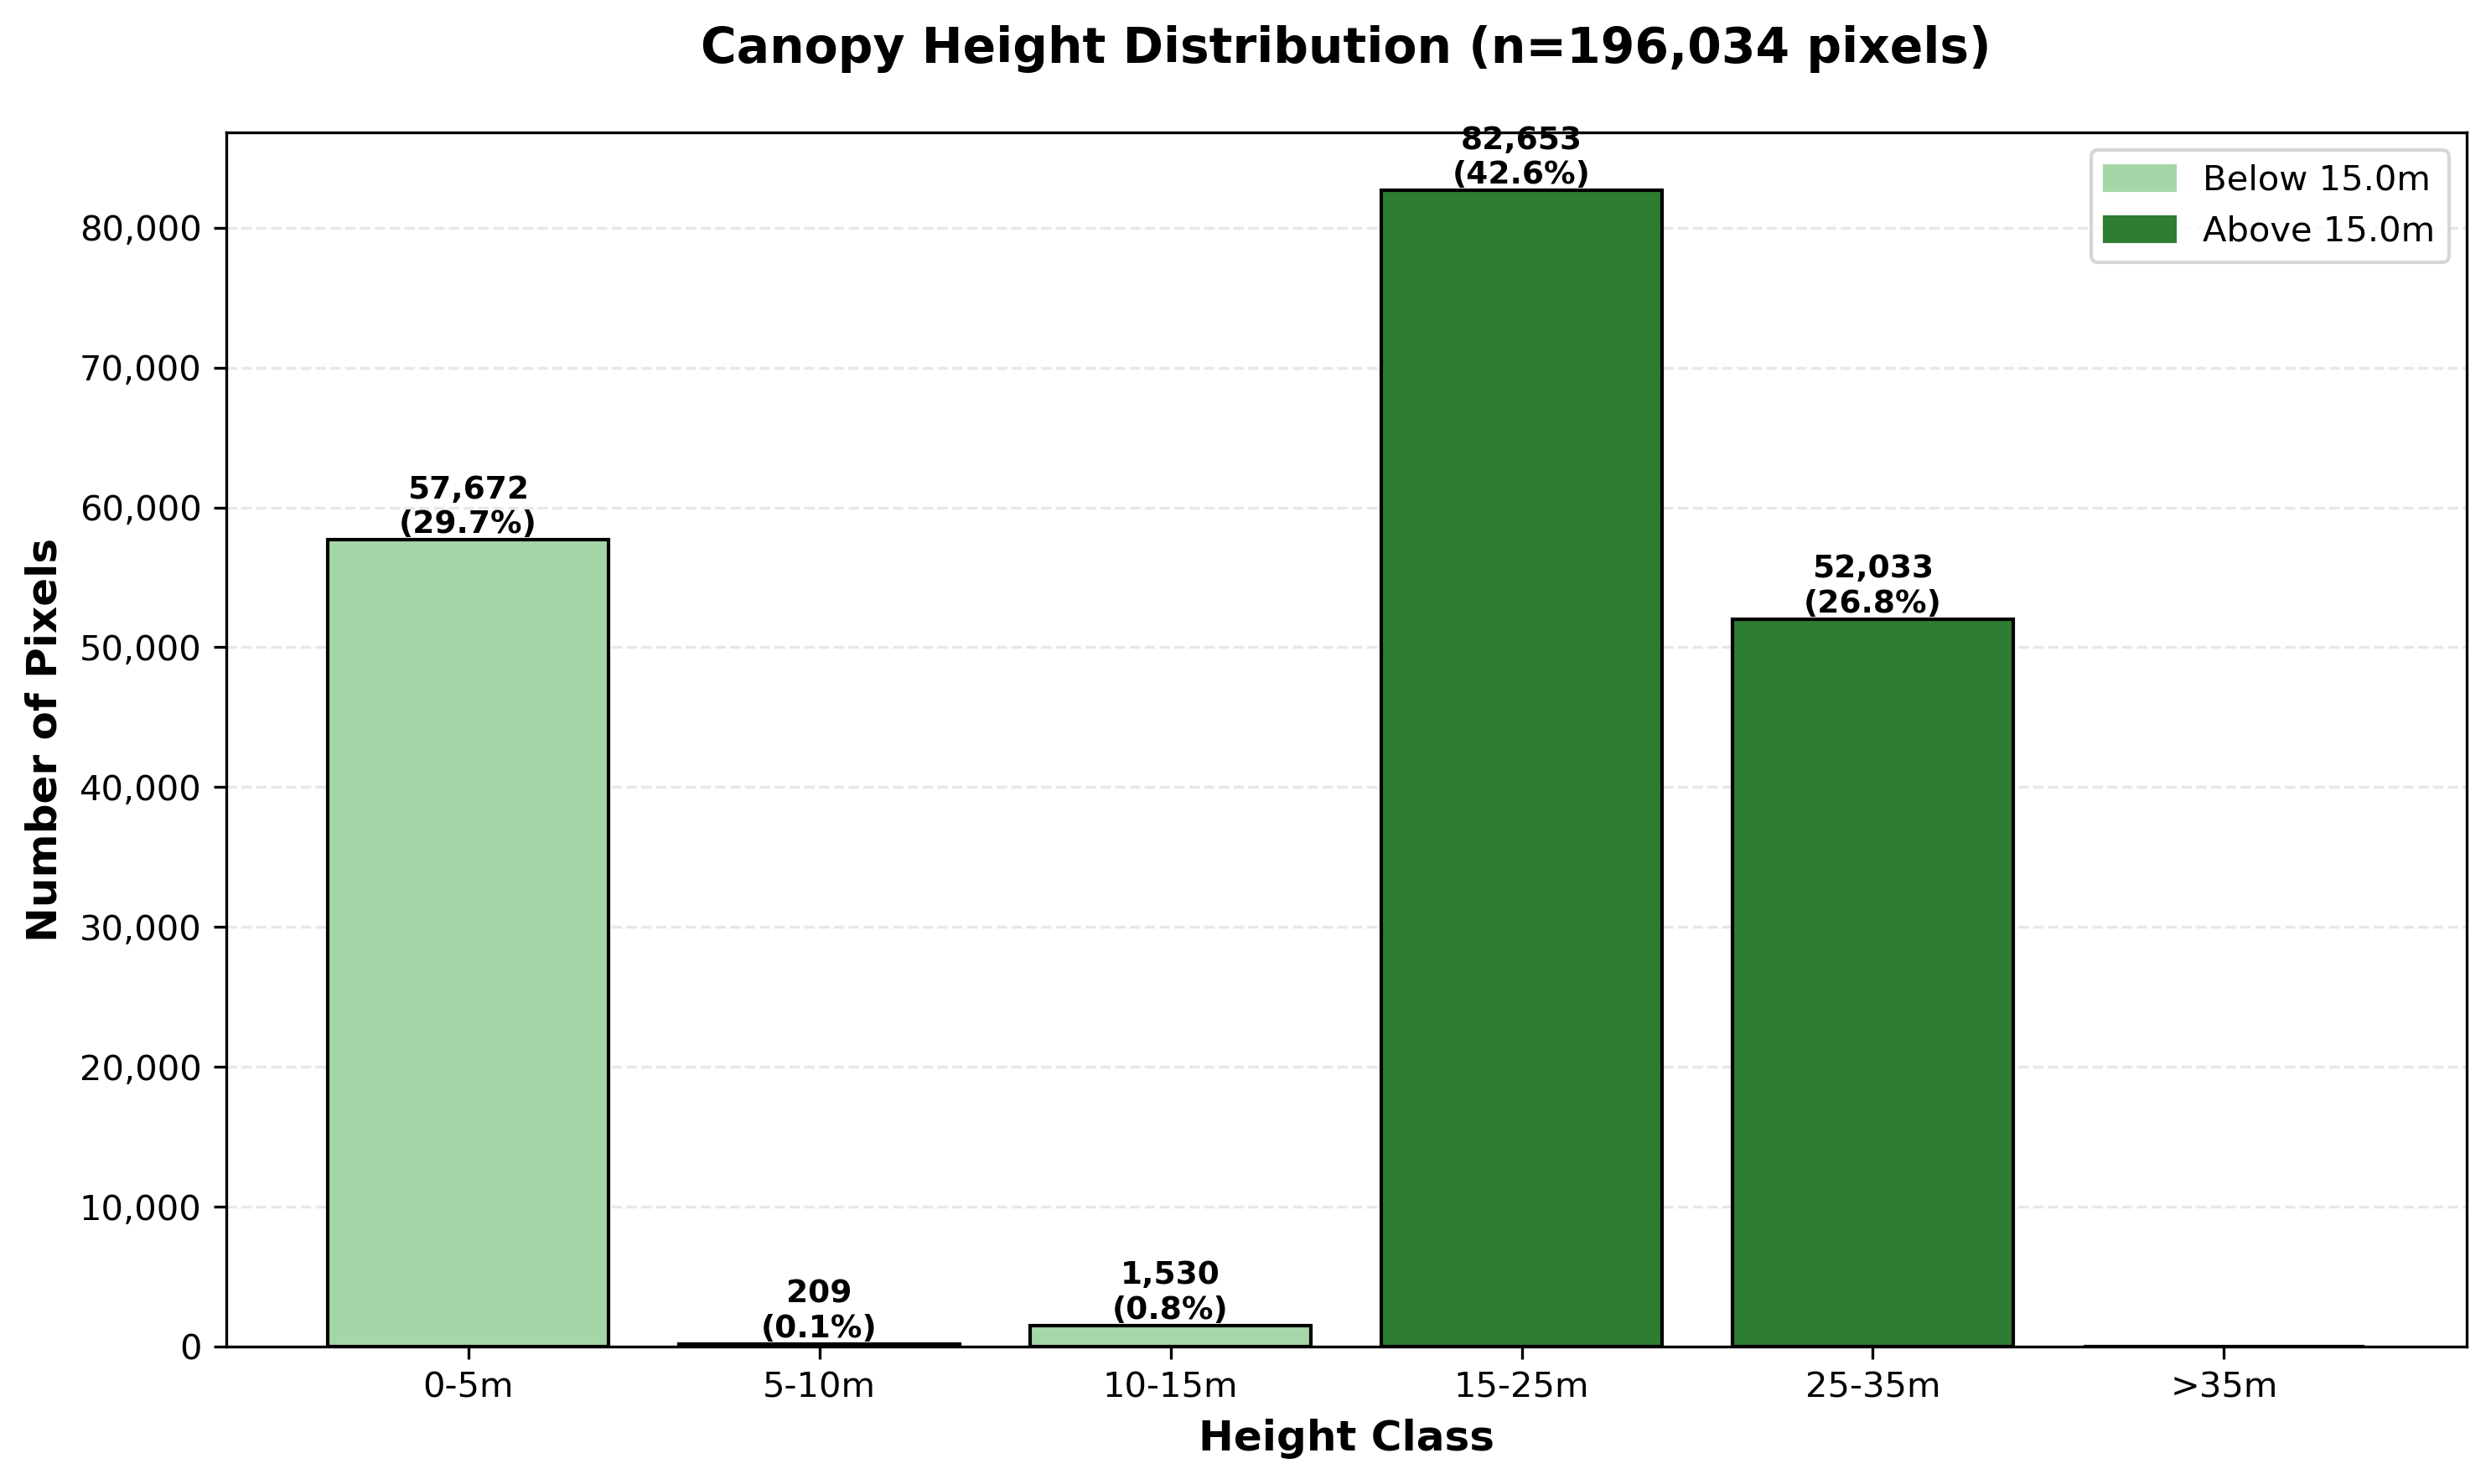


LVP13 (EBE-e 155)
  Observer:  Licht-Geschlossen/Licht
  Derived:   0.64  (0=light .. 1=closed)
  Mean height: 15.3m | Valid pixels: 196,022


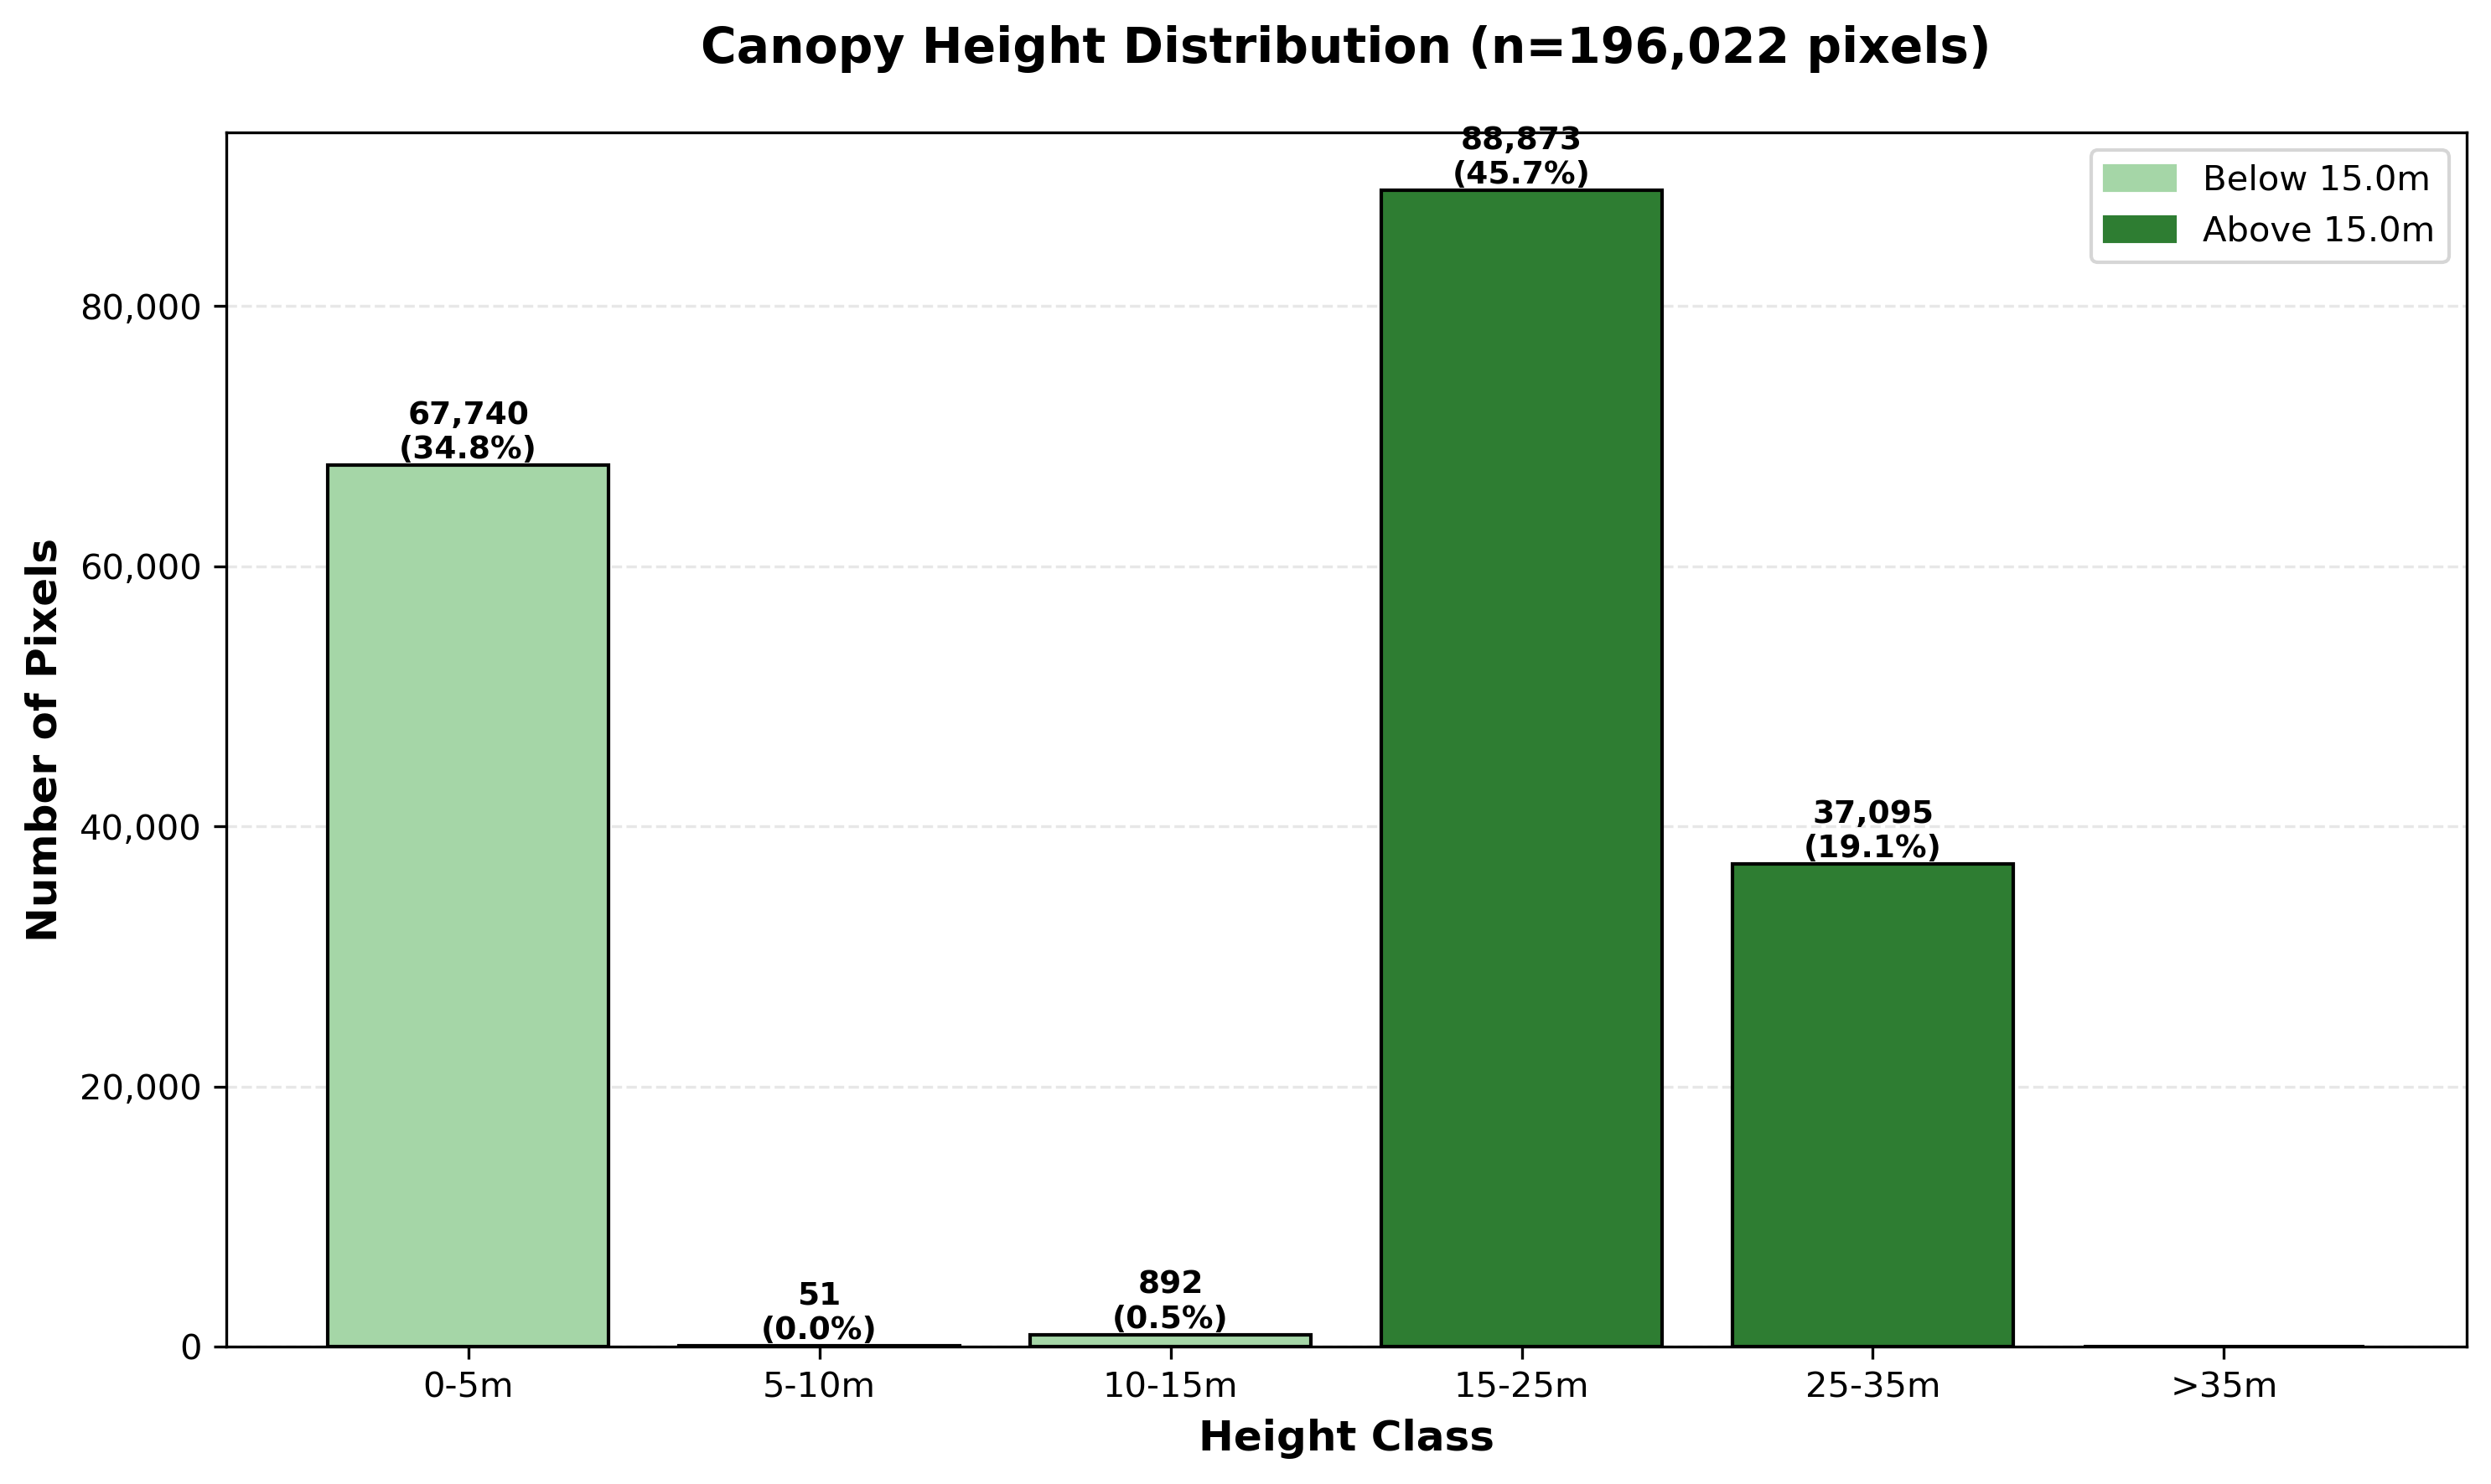


LVP14 (EBE-e 155)
  Observer:  Licht-Geschlossen/Licht
  Derived:   0.92  (0=light .. 1=closed)
  Mean height: 21.4m | Valid pixels: 196,034


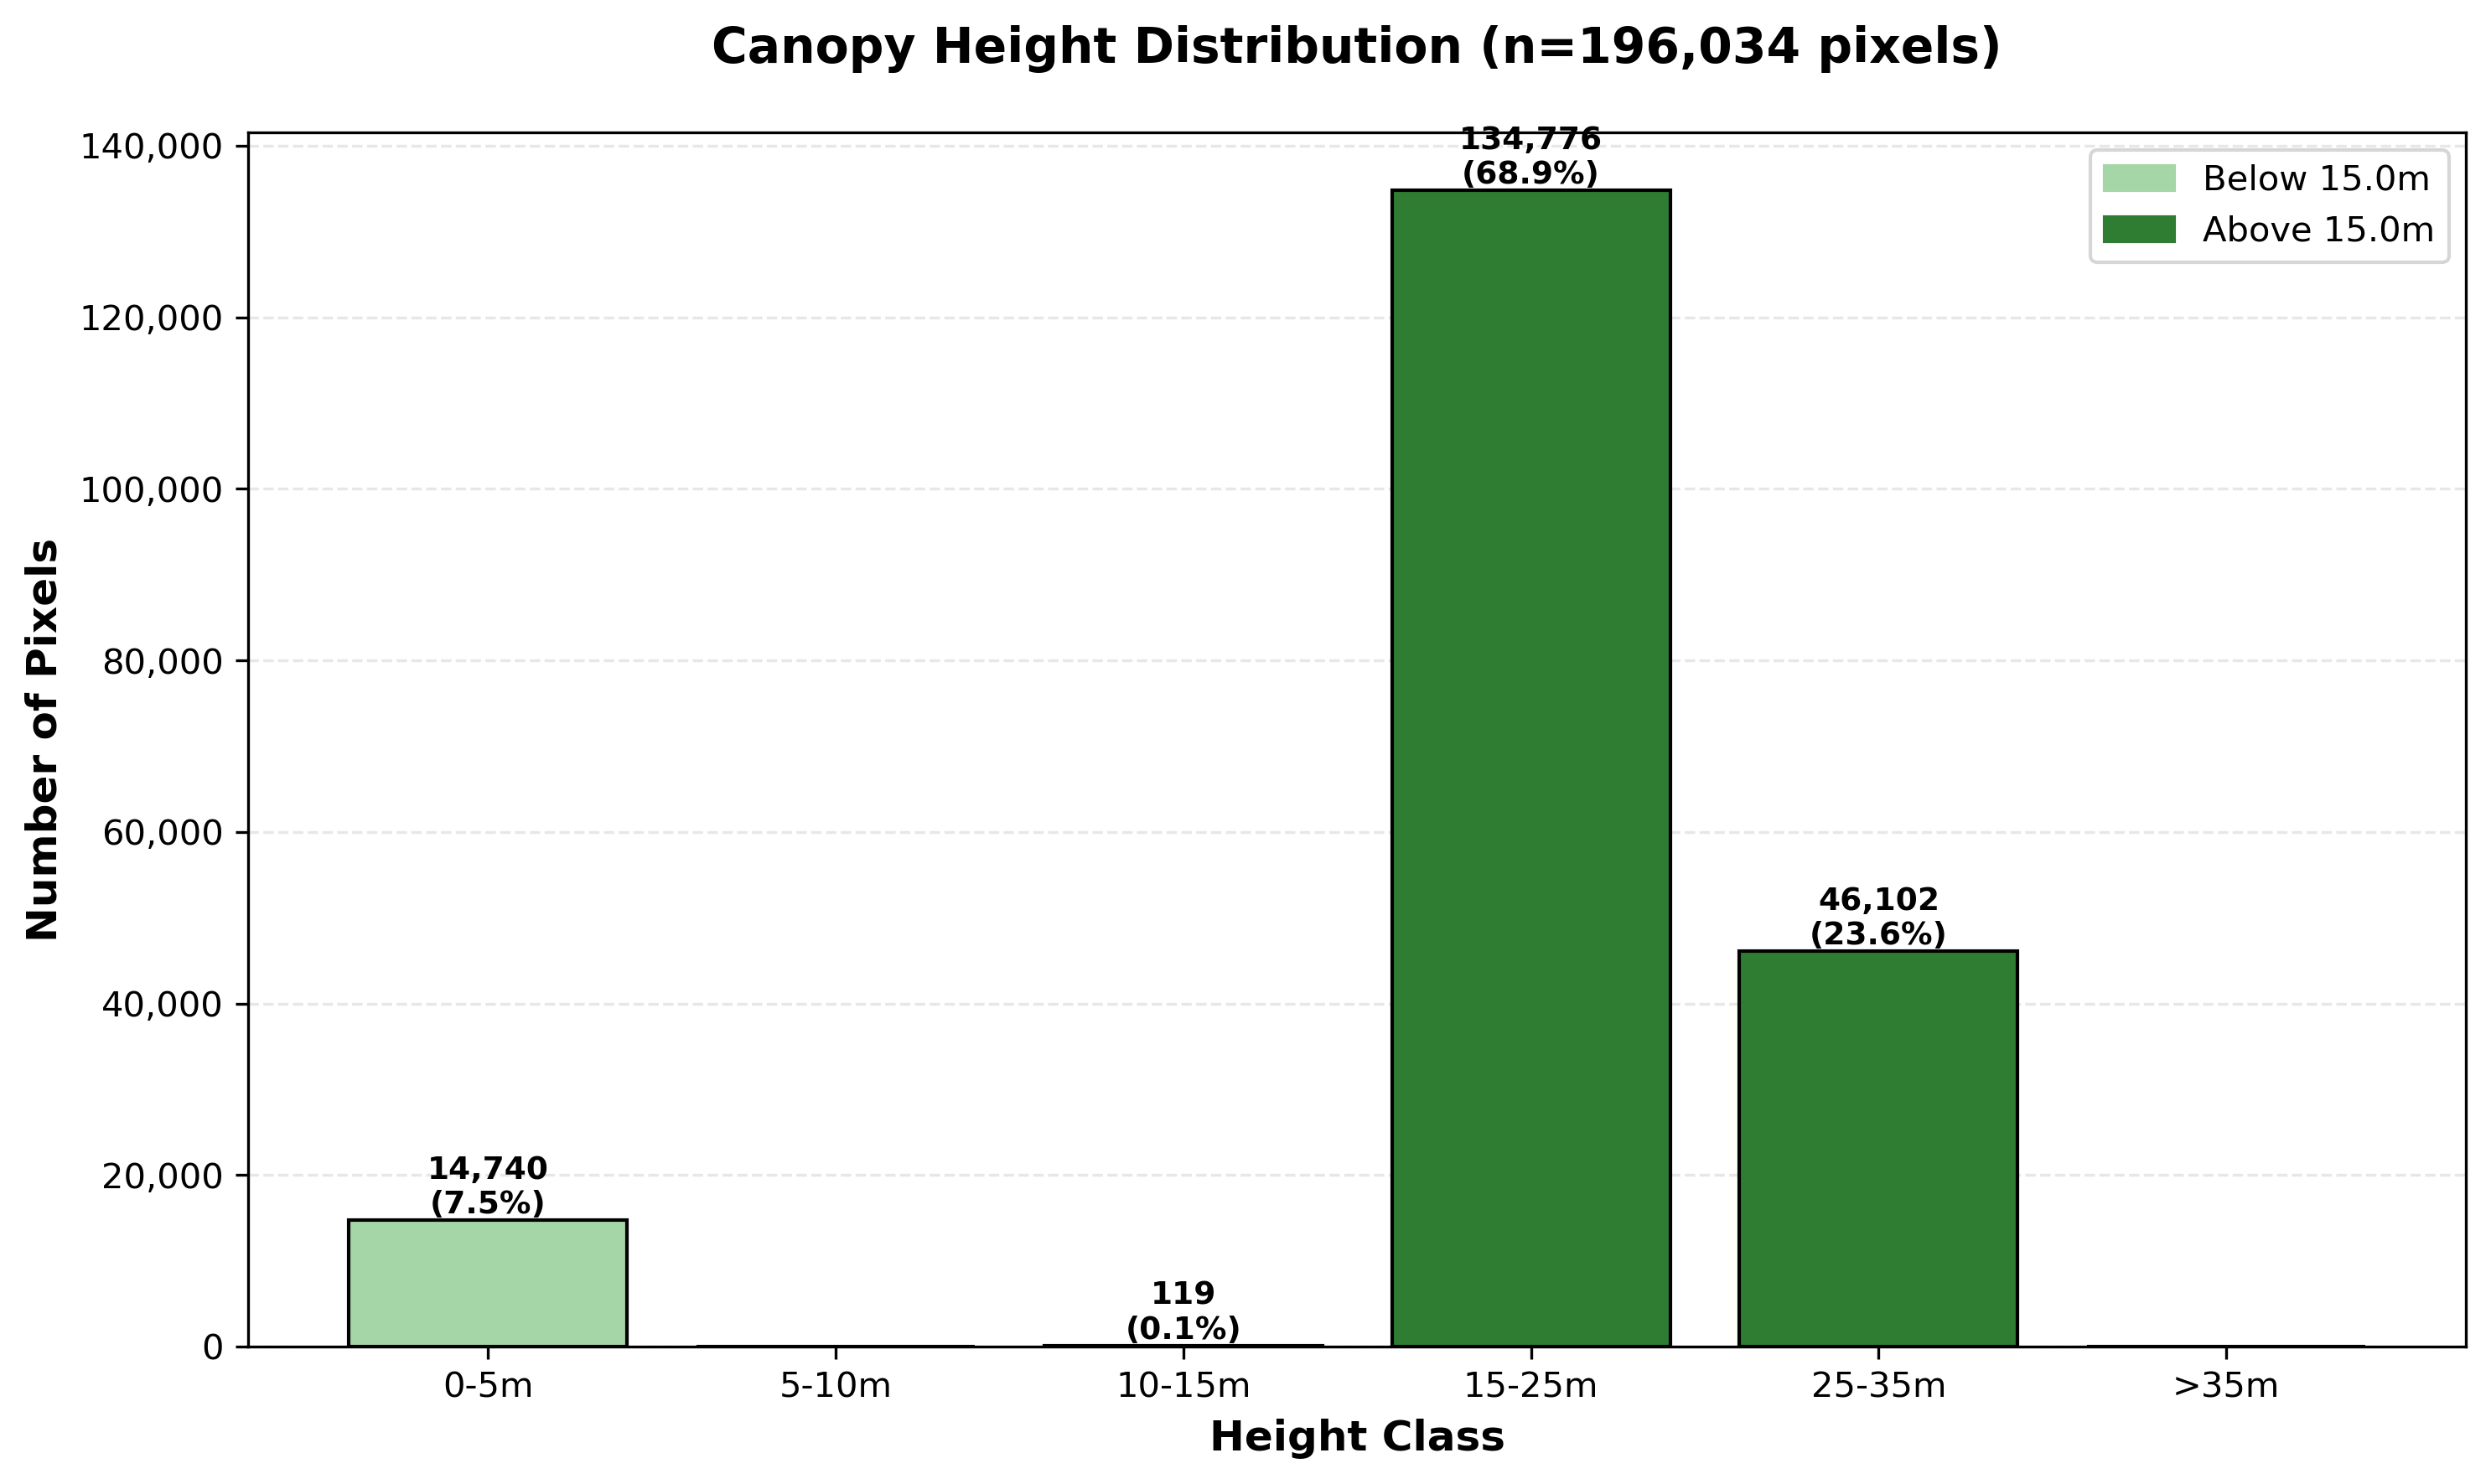


LVP15 (EBE-e 155)
  Observer:  Lücke < Baumlänge
  Derived:   0.78  (0=light .. 1=closed)
  Mean height: 18.4m | Valid pixels: 196,031


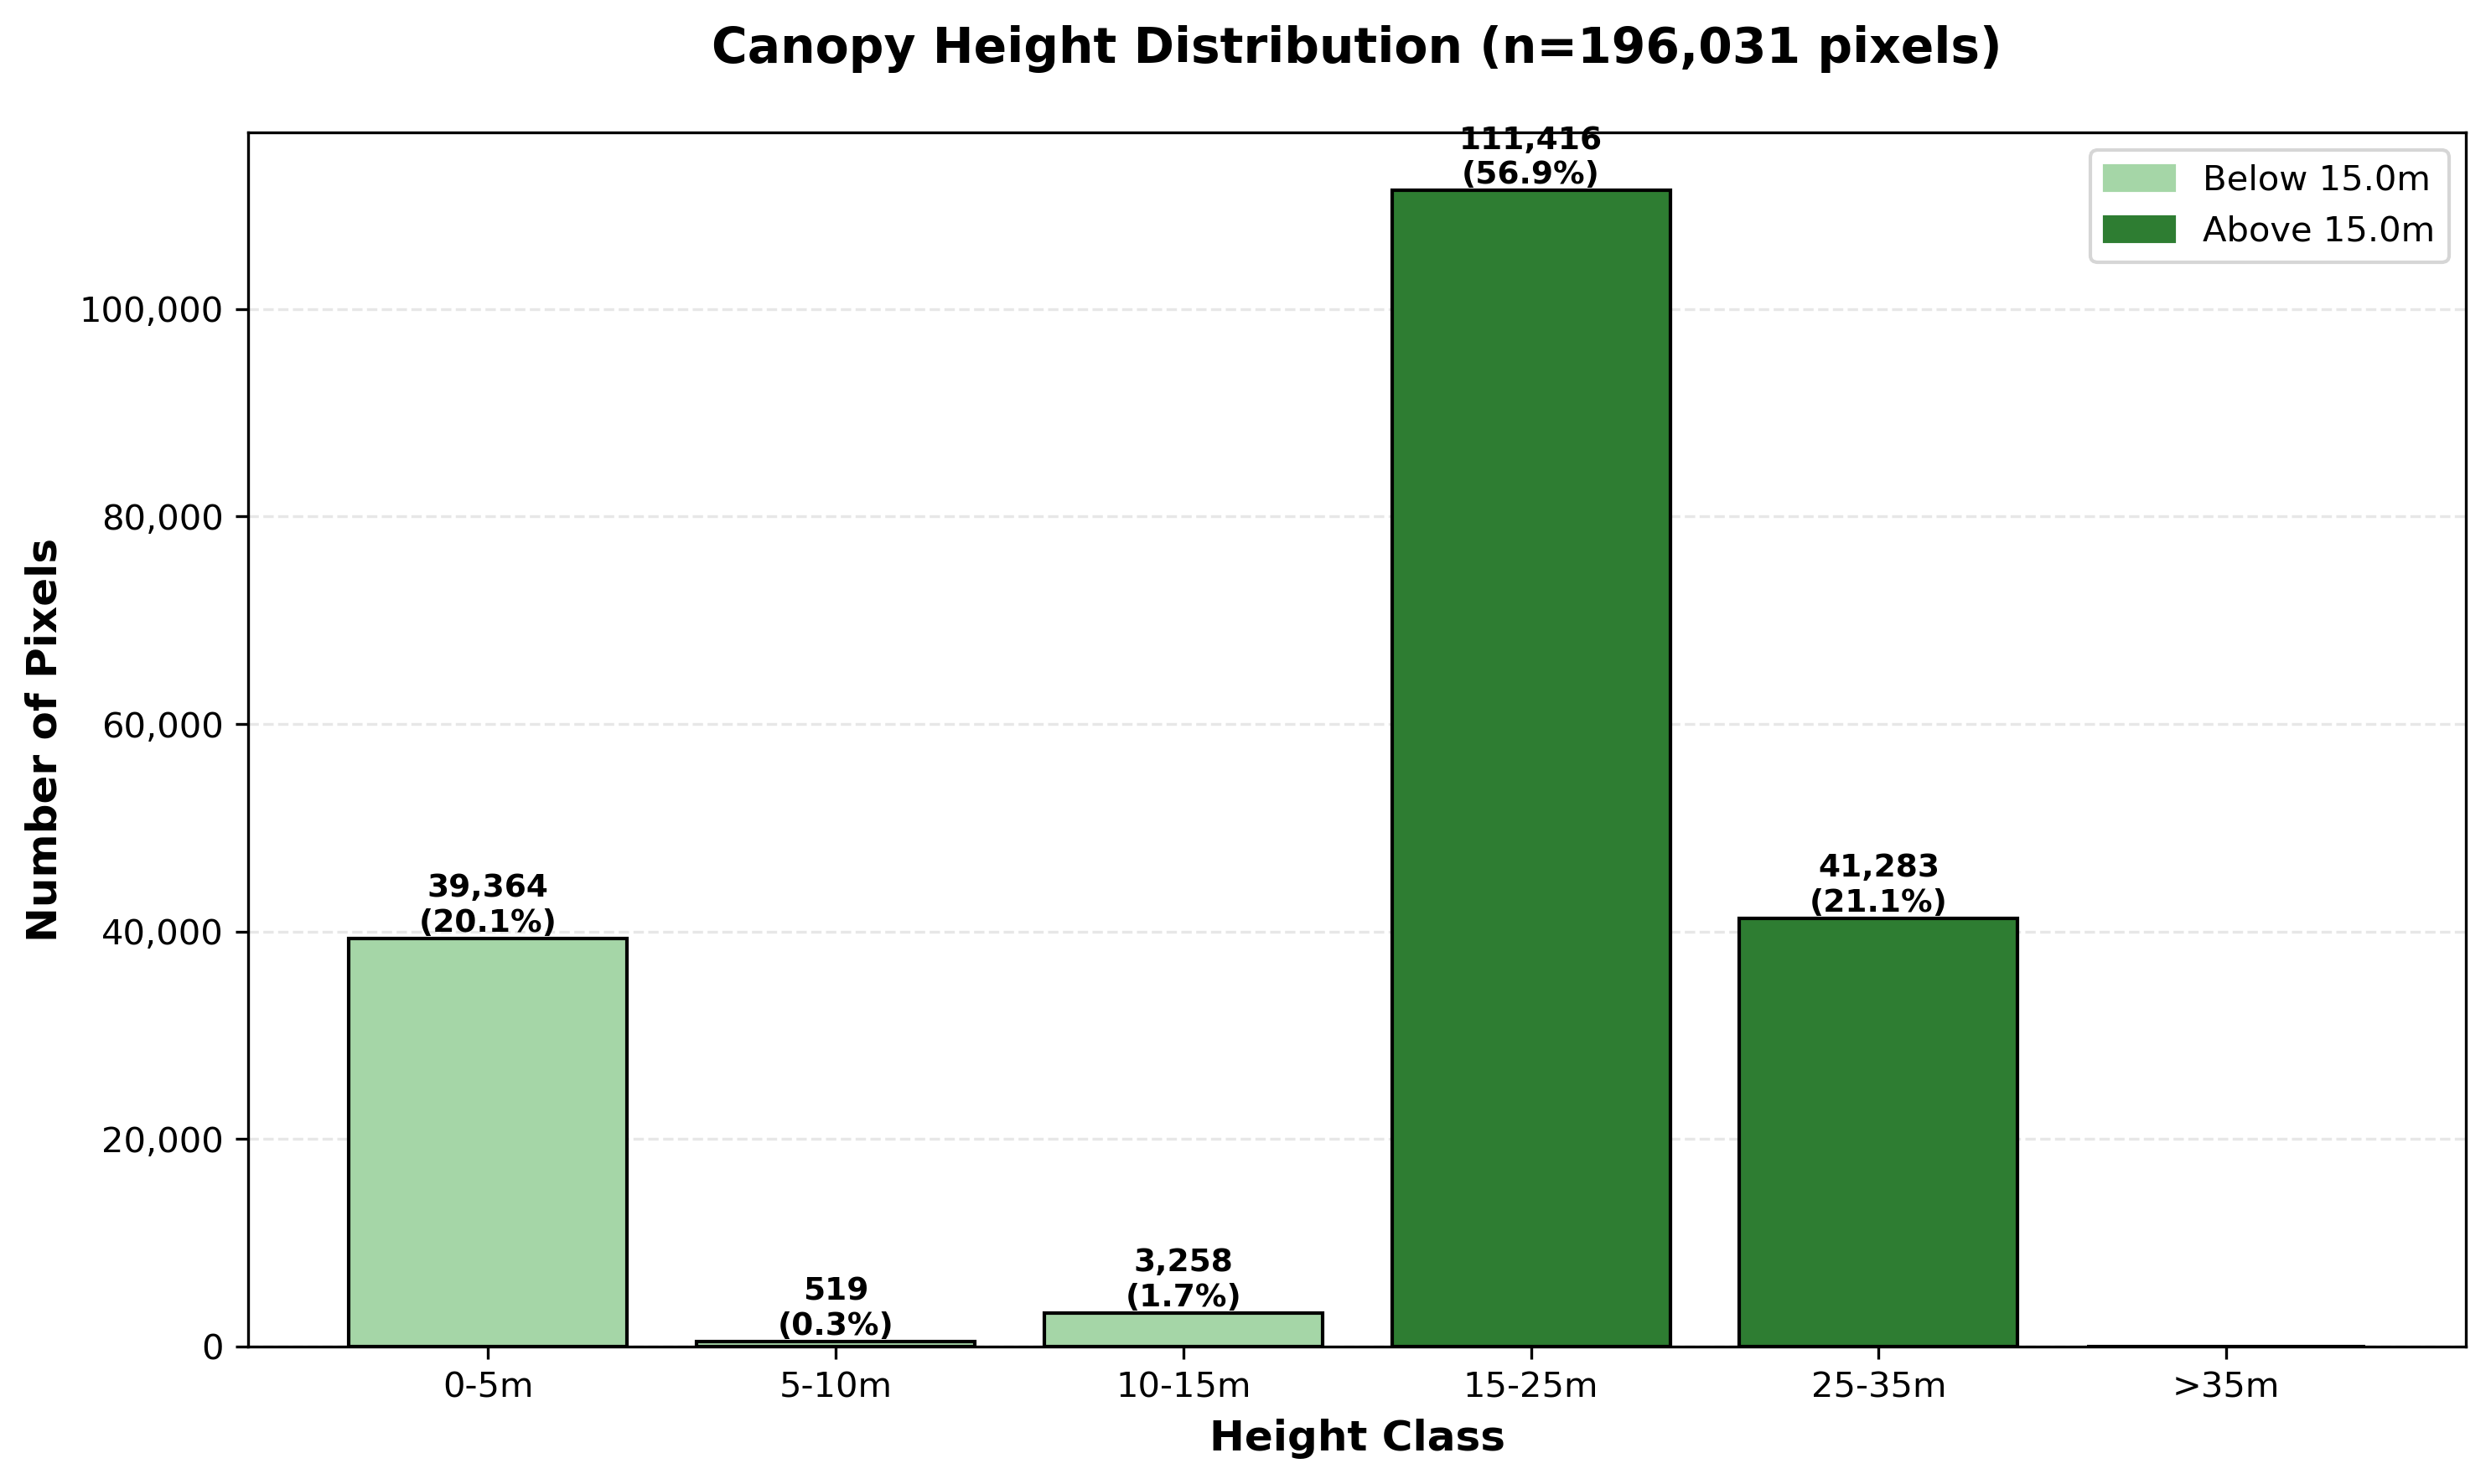


LVP16 (EBE-e 155)
  Observer:  Lücke < Baumlänge
  Derived:   0.56  (0=light .. 1=closed)
  Mean height: 14.2m | Valid pixels: 196,029


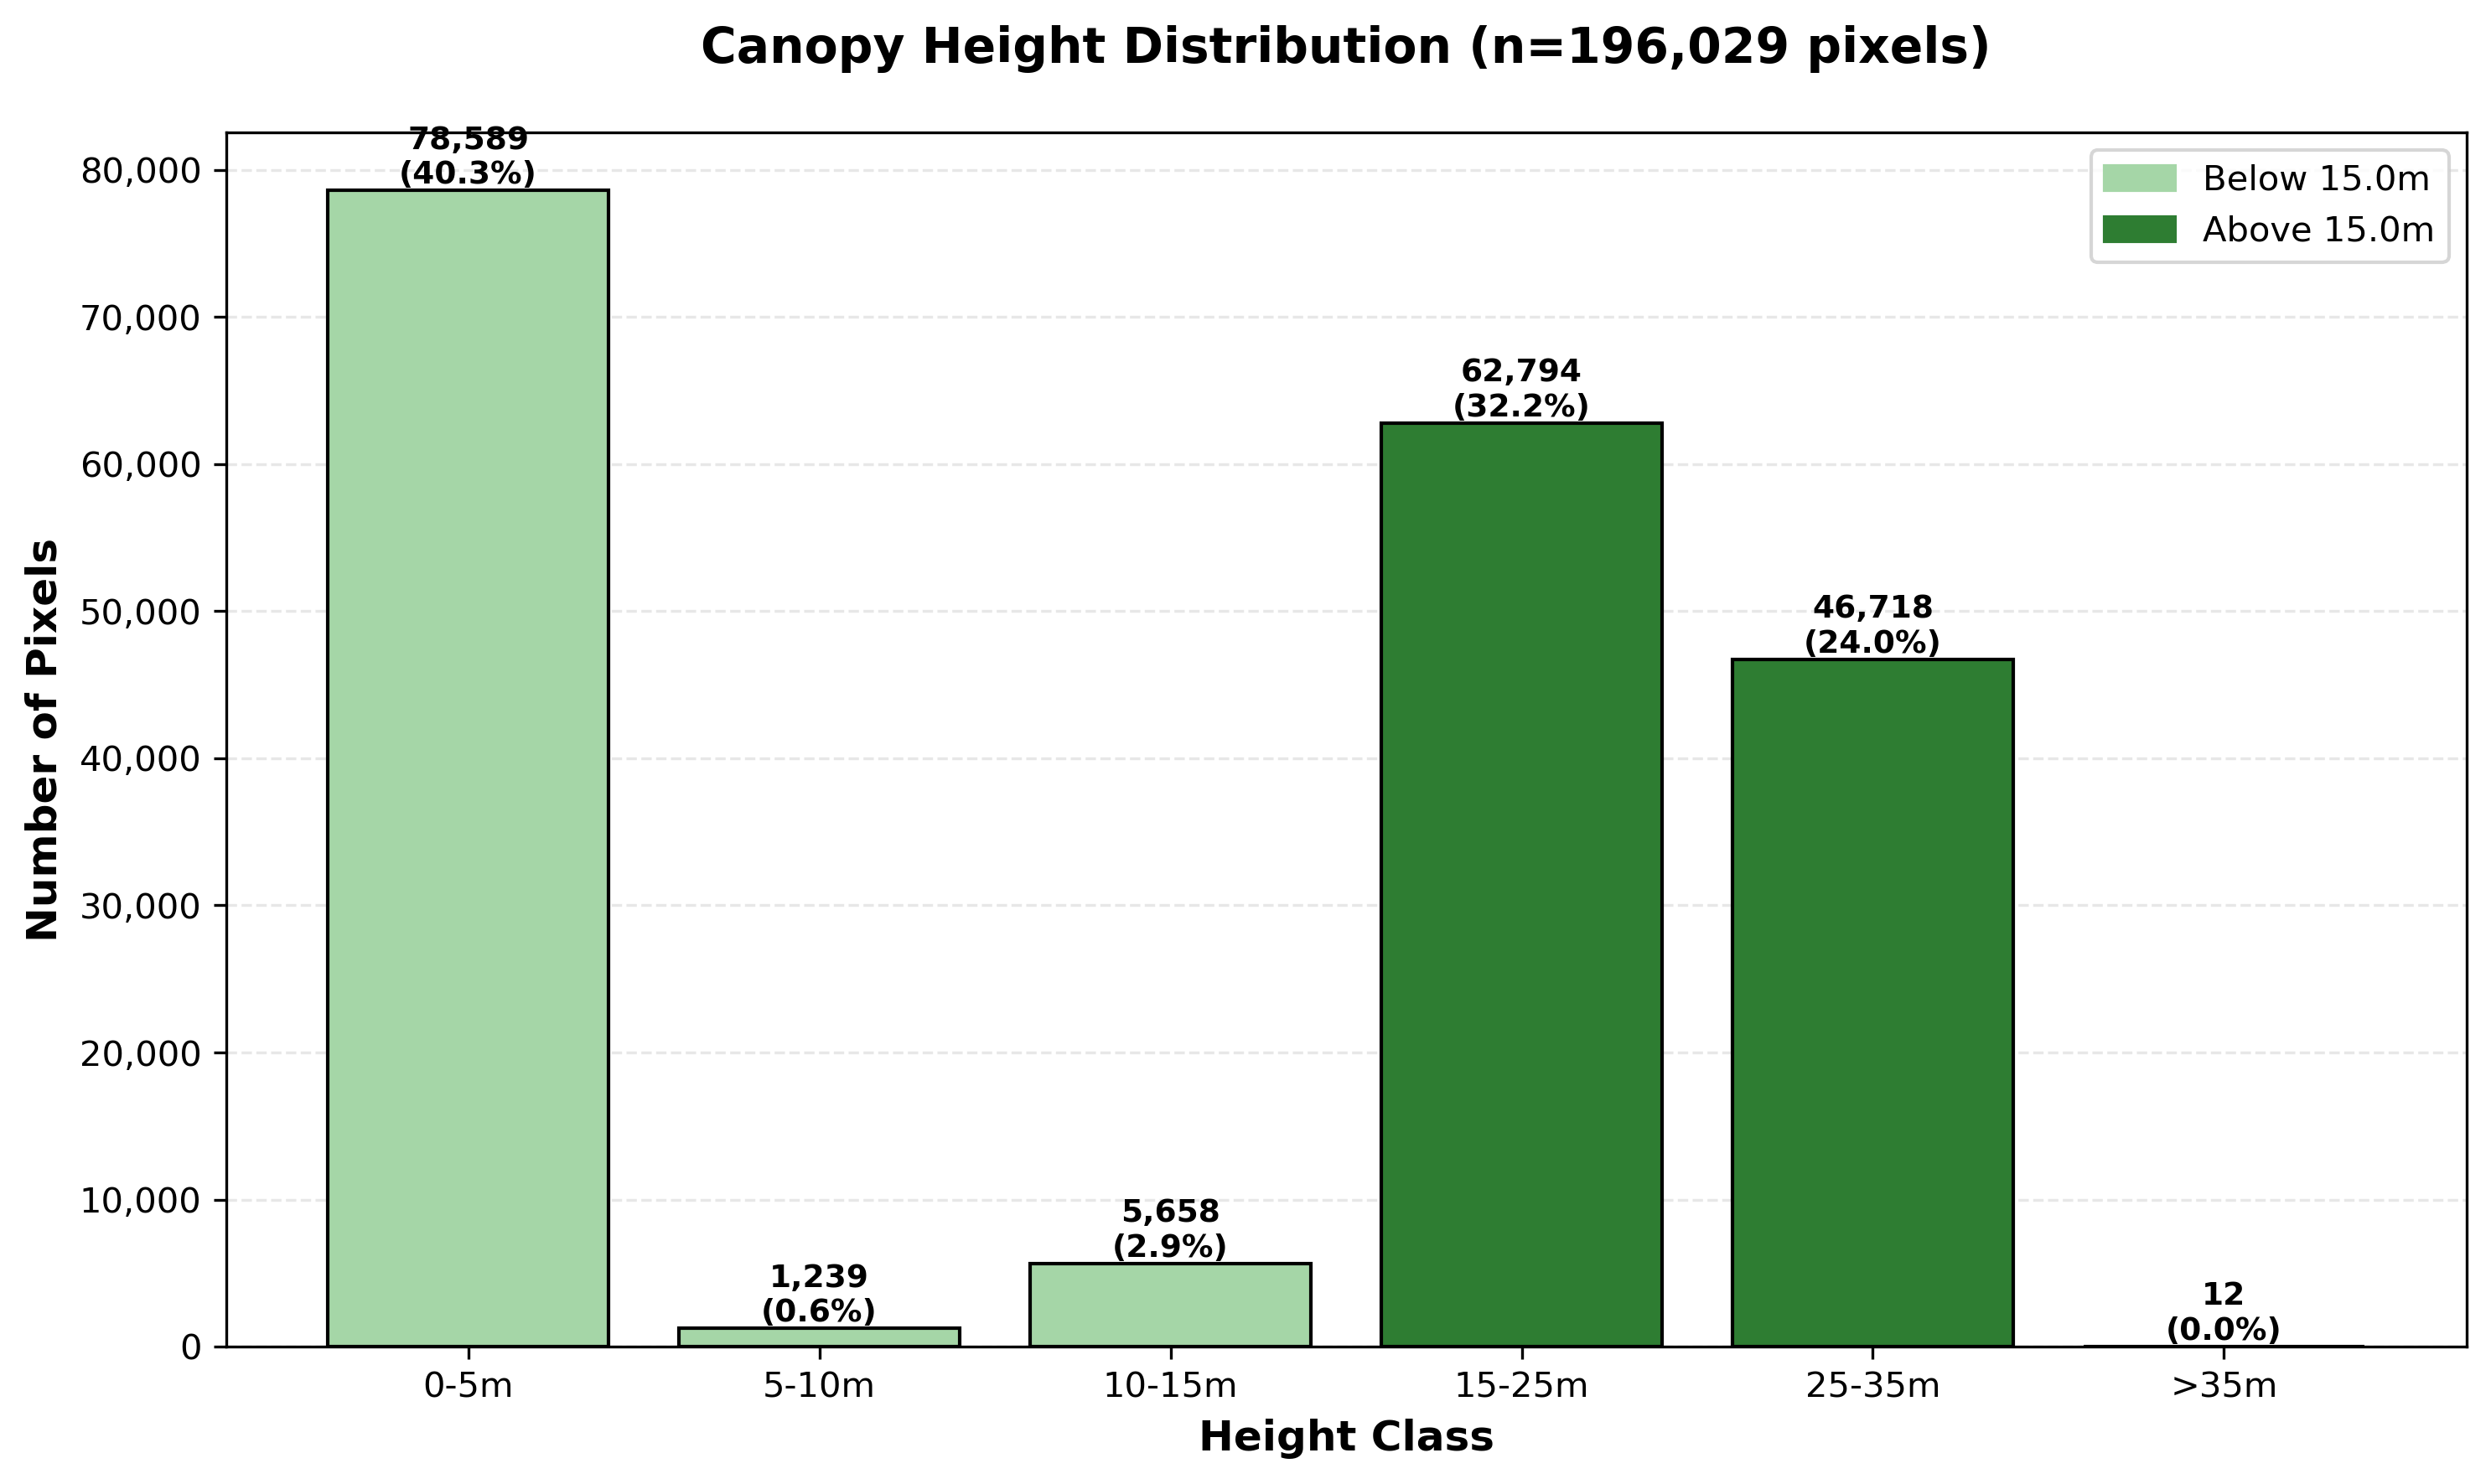


LVP17 (EBE-e 155)
  Observer:  Licht-Geschlossen/Licht
  Derived:   0.62  (0=light .. 1=closed)
  Mean height: 15.9m | Valid pixels: 196,035


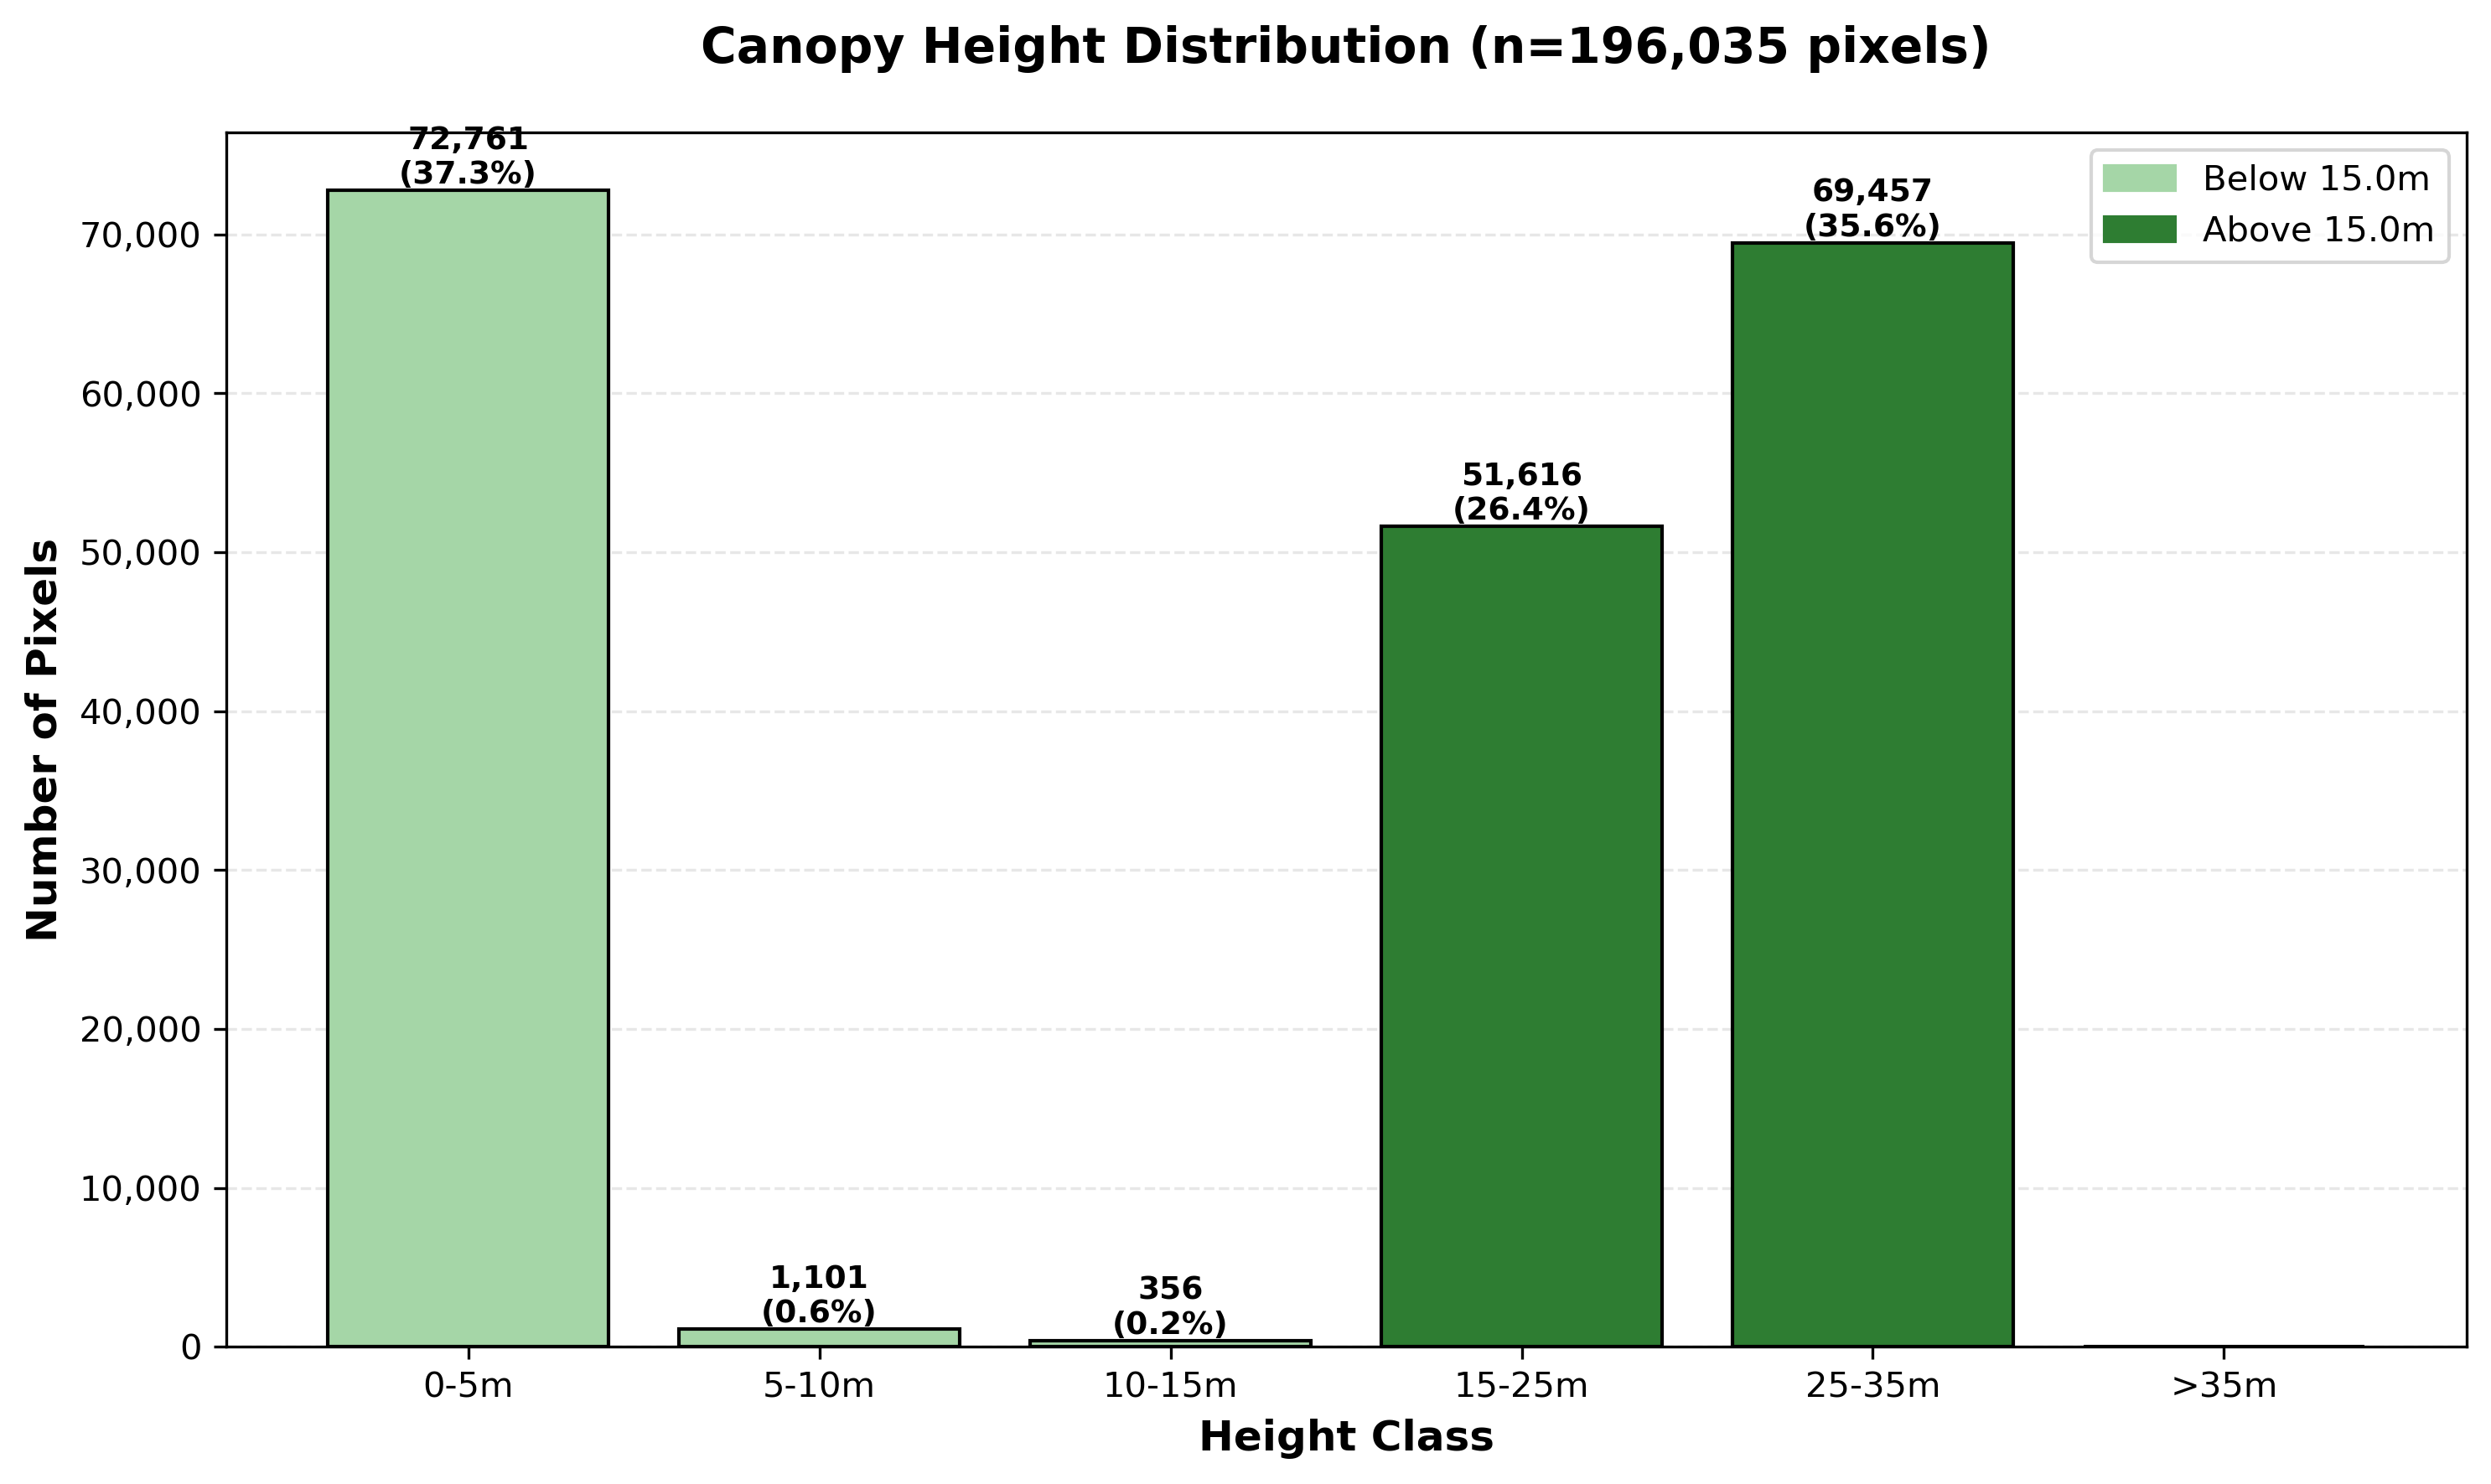


LVP18 (EBE-e 155)
  Observer:  Lücke > Baumlänge
  Derived:   0.54  (0=light .. 1=closed)
  Mean height: 13.4m | Valid pixels: 196,038


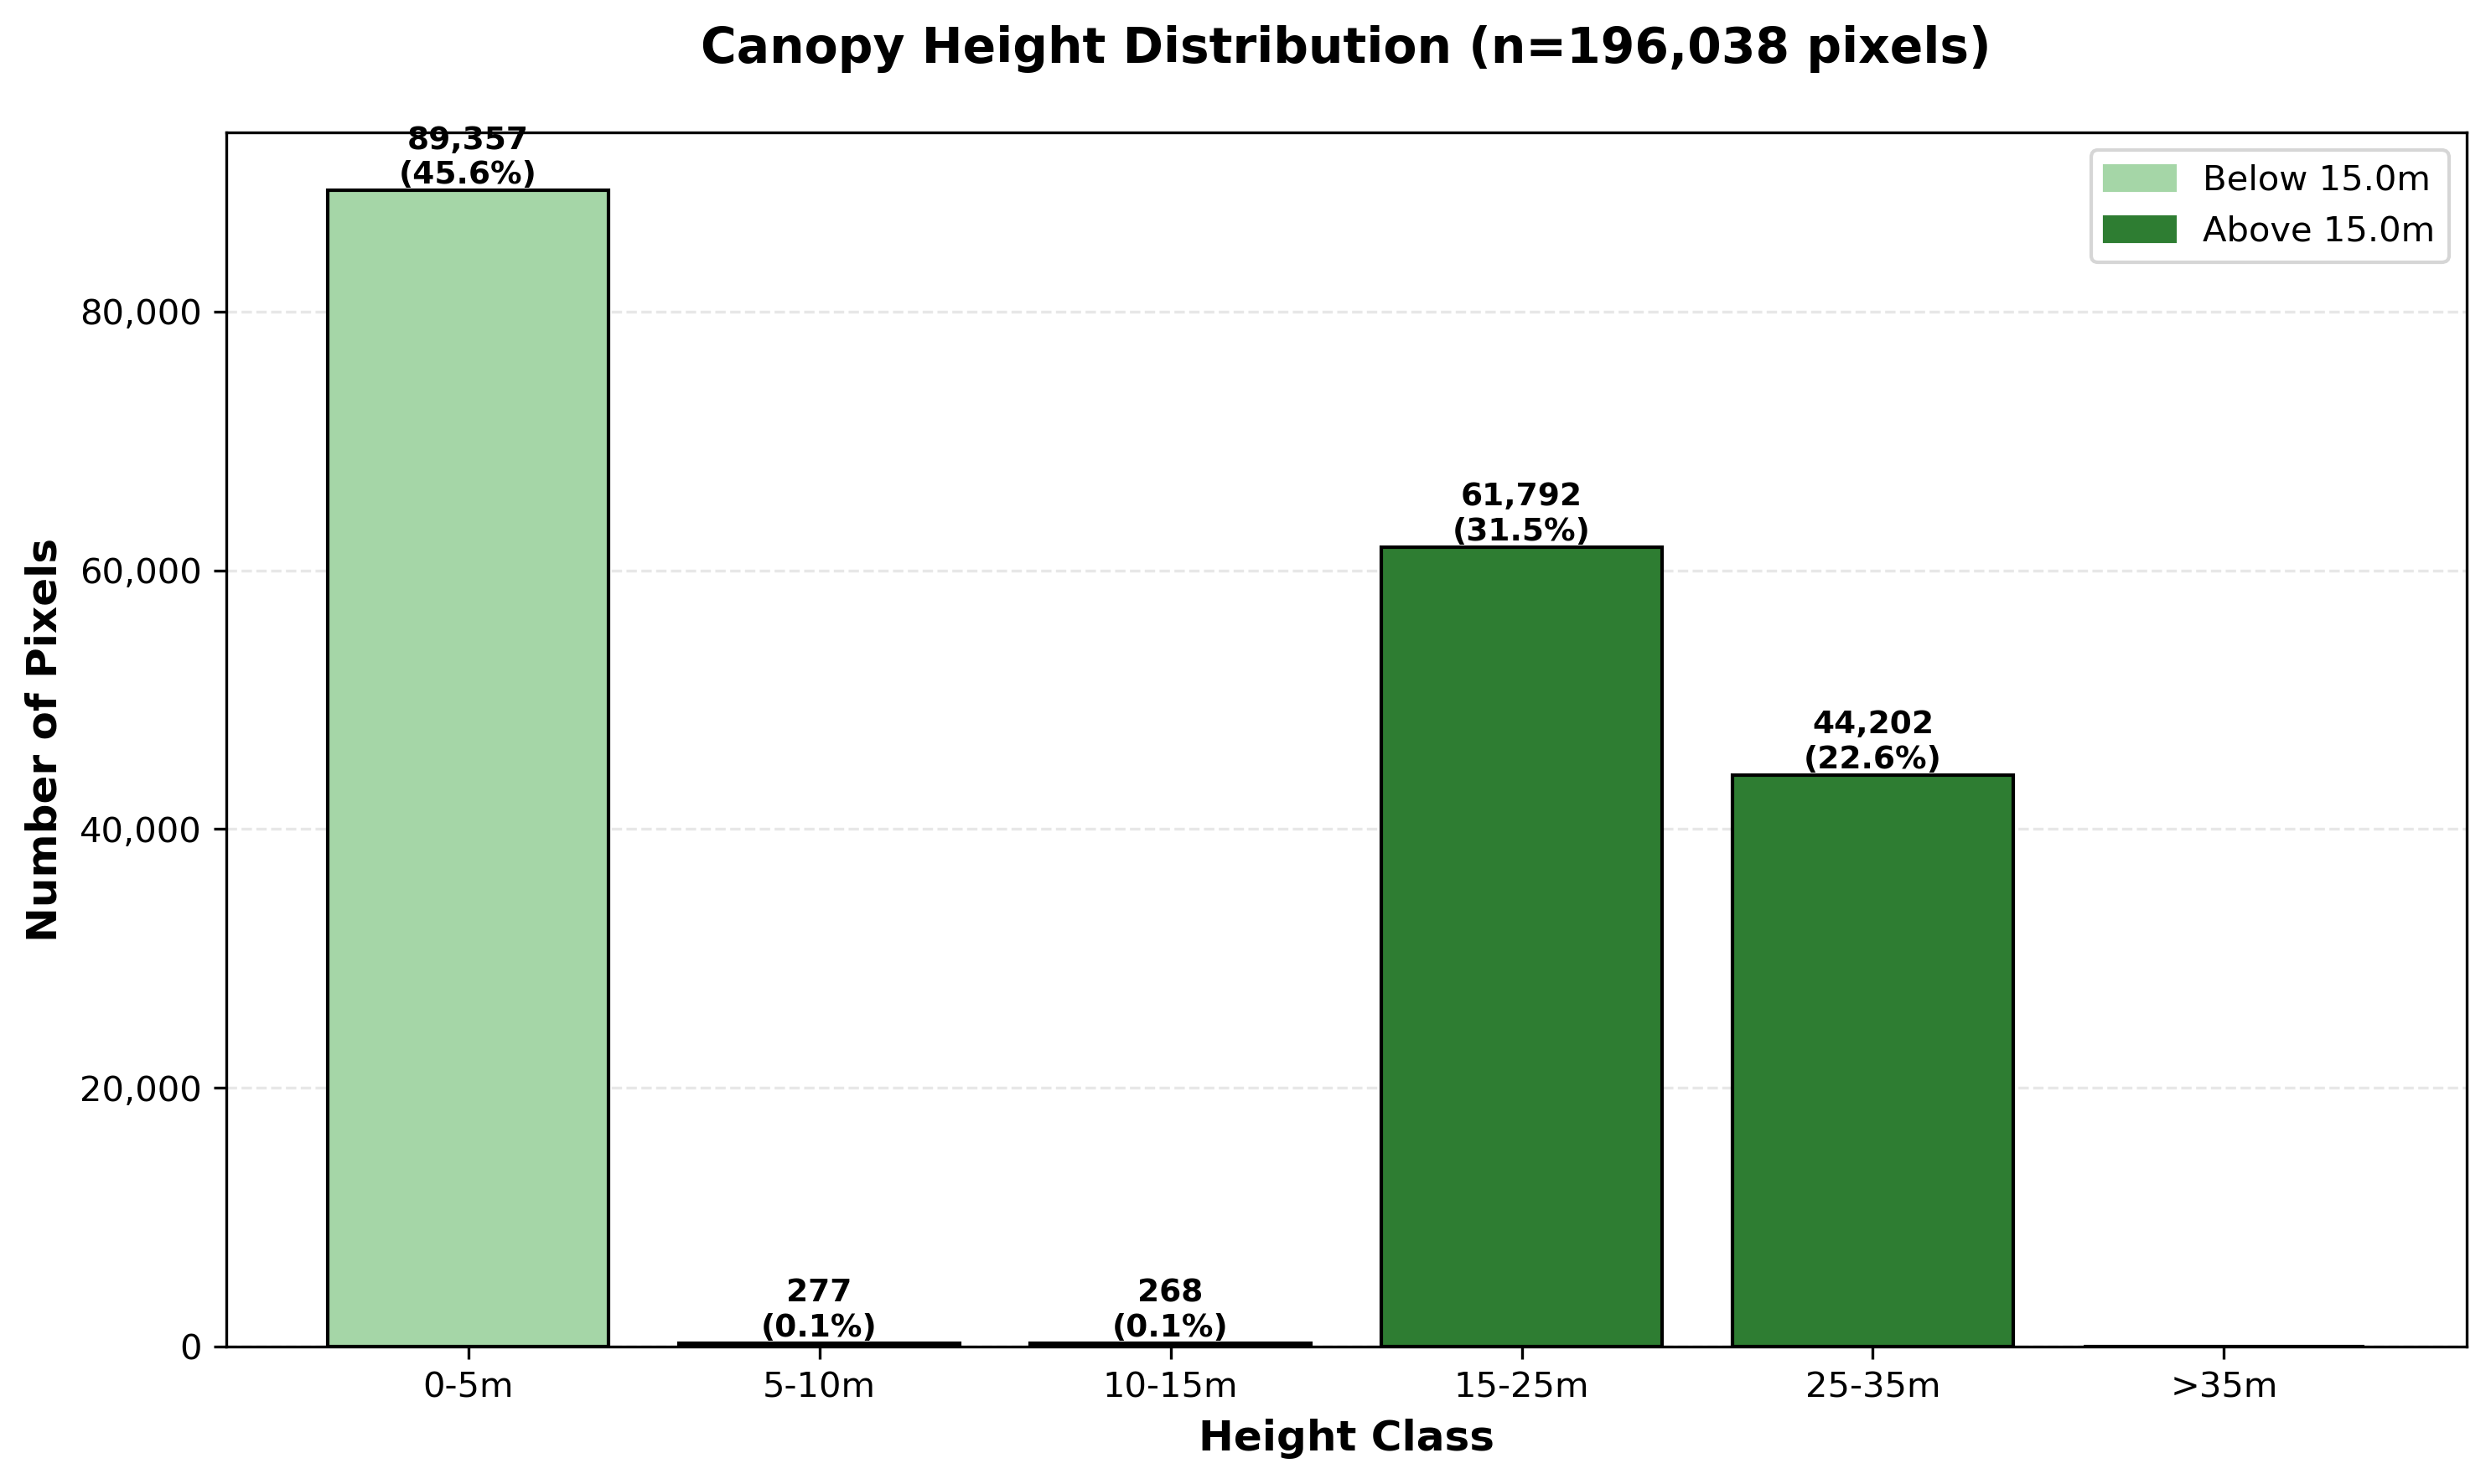


LVP19 (EBE-any)
  Observer:  Licht-Geschlossen/Licht
  Derived:   0.88  (0=light .. 1=closed)
  Mean height: 20.2m | Valid pixels: 196,038


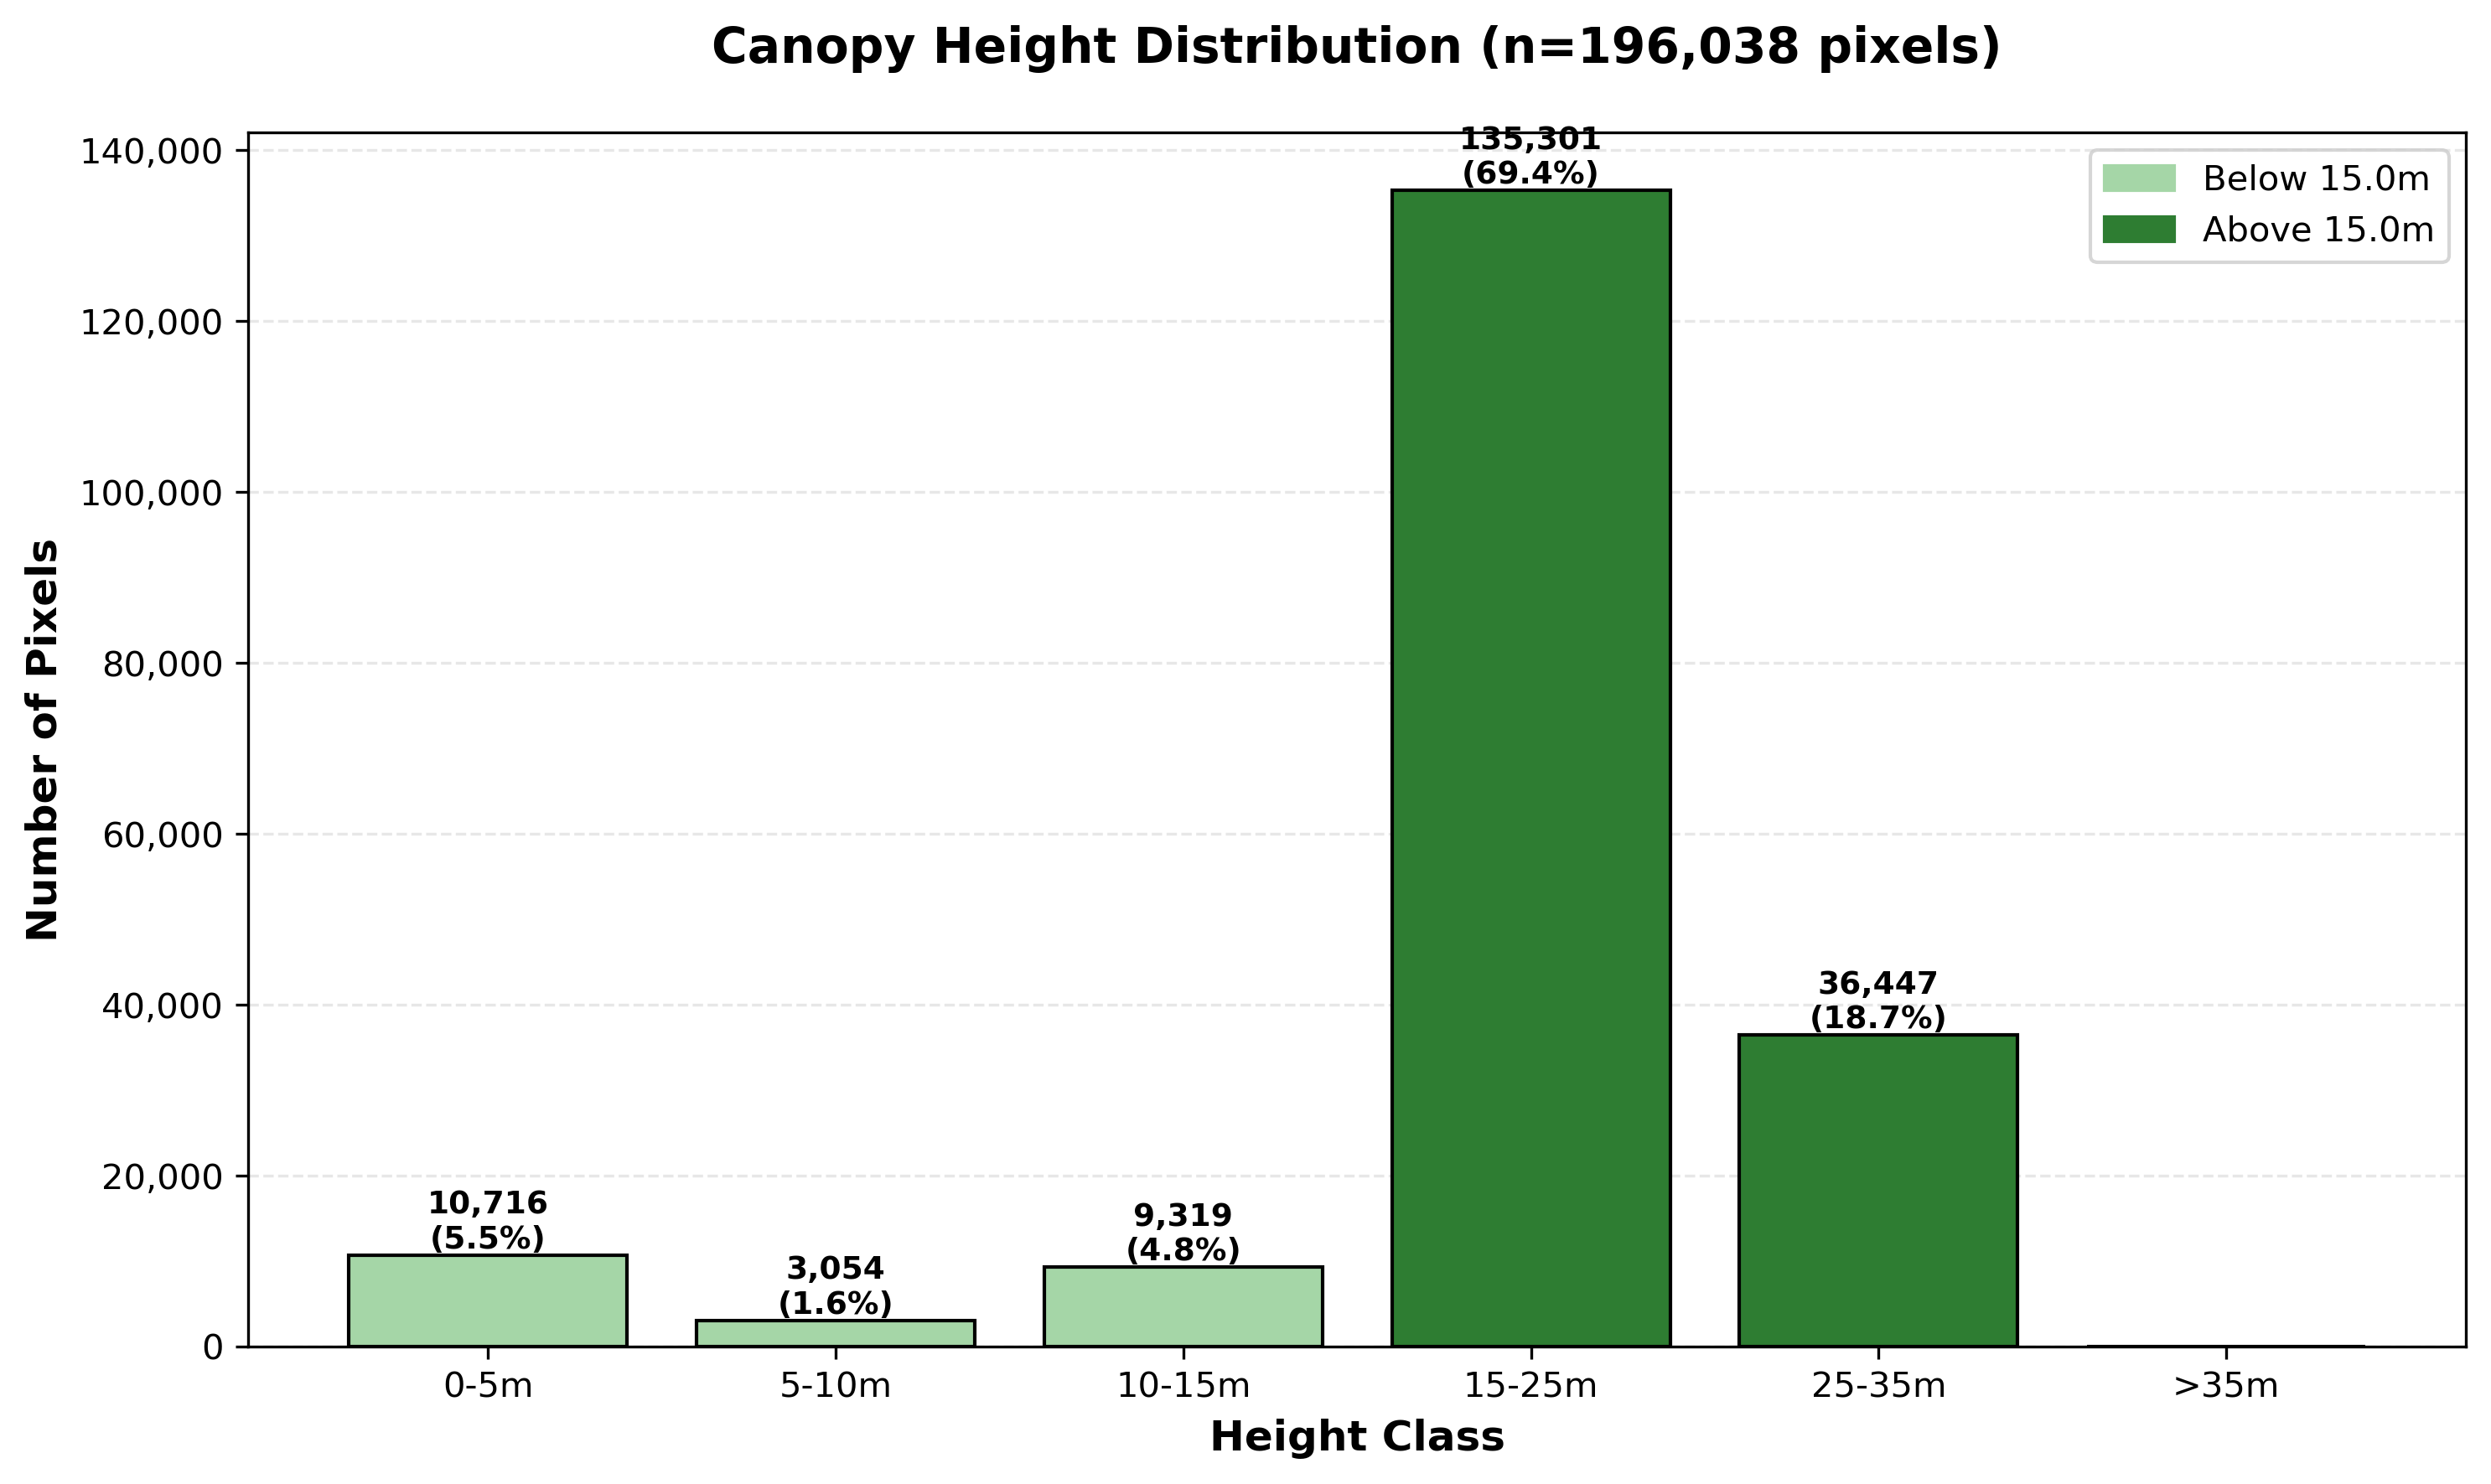


LVP20 (EBE-any)
  Observer:  Geschlossen/Gedrängt
  Derived:   0.81  (0=light .. 1=closed)
  Mean height: 19.2m | Valid pixels: 196,033


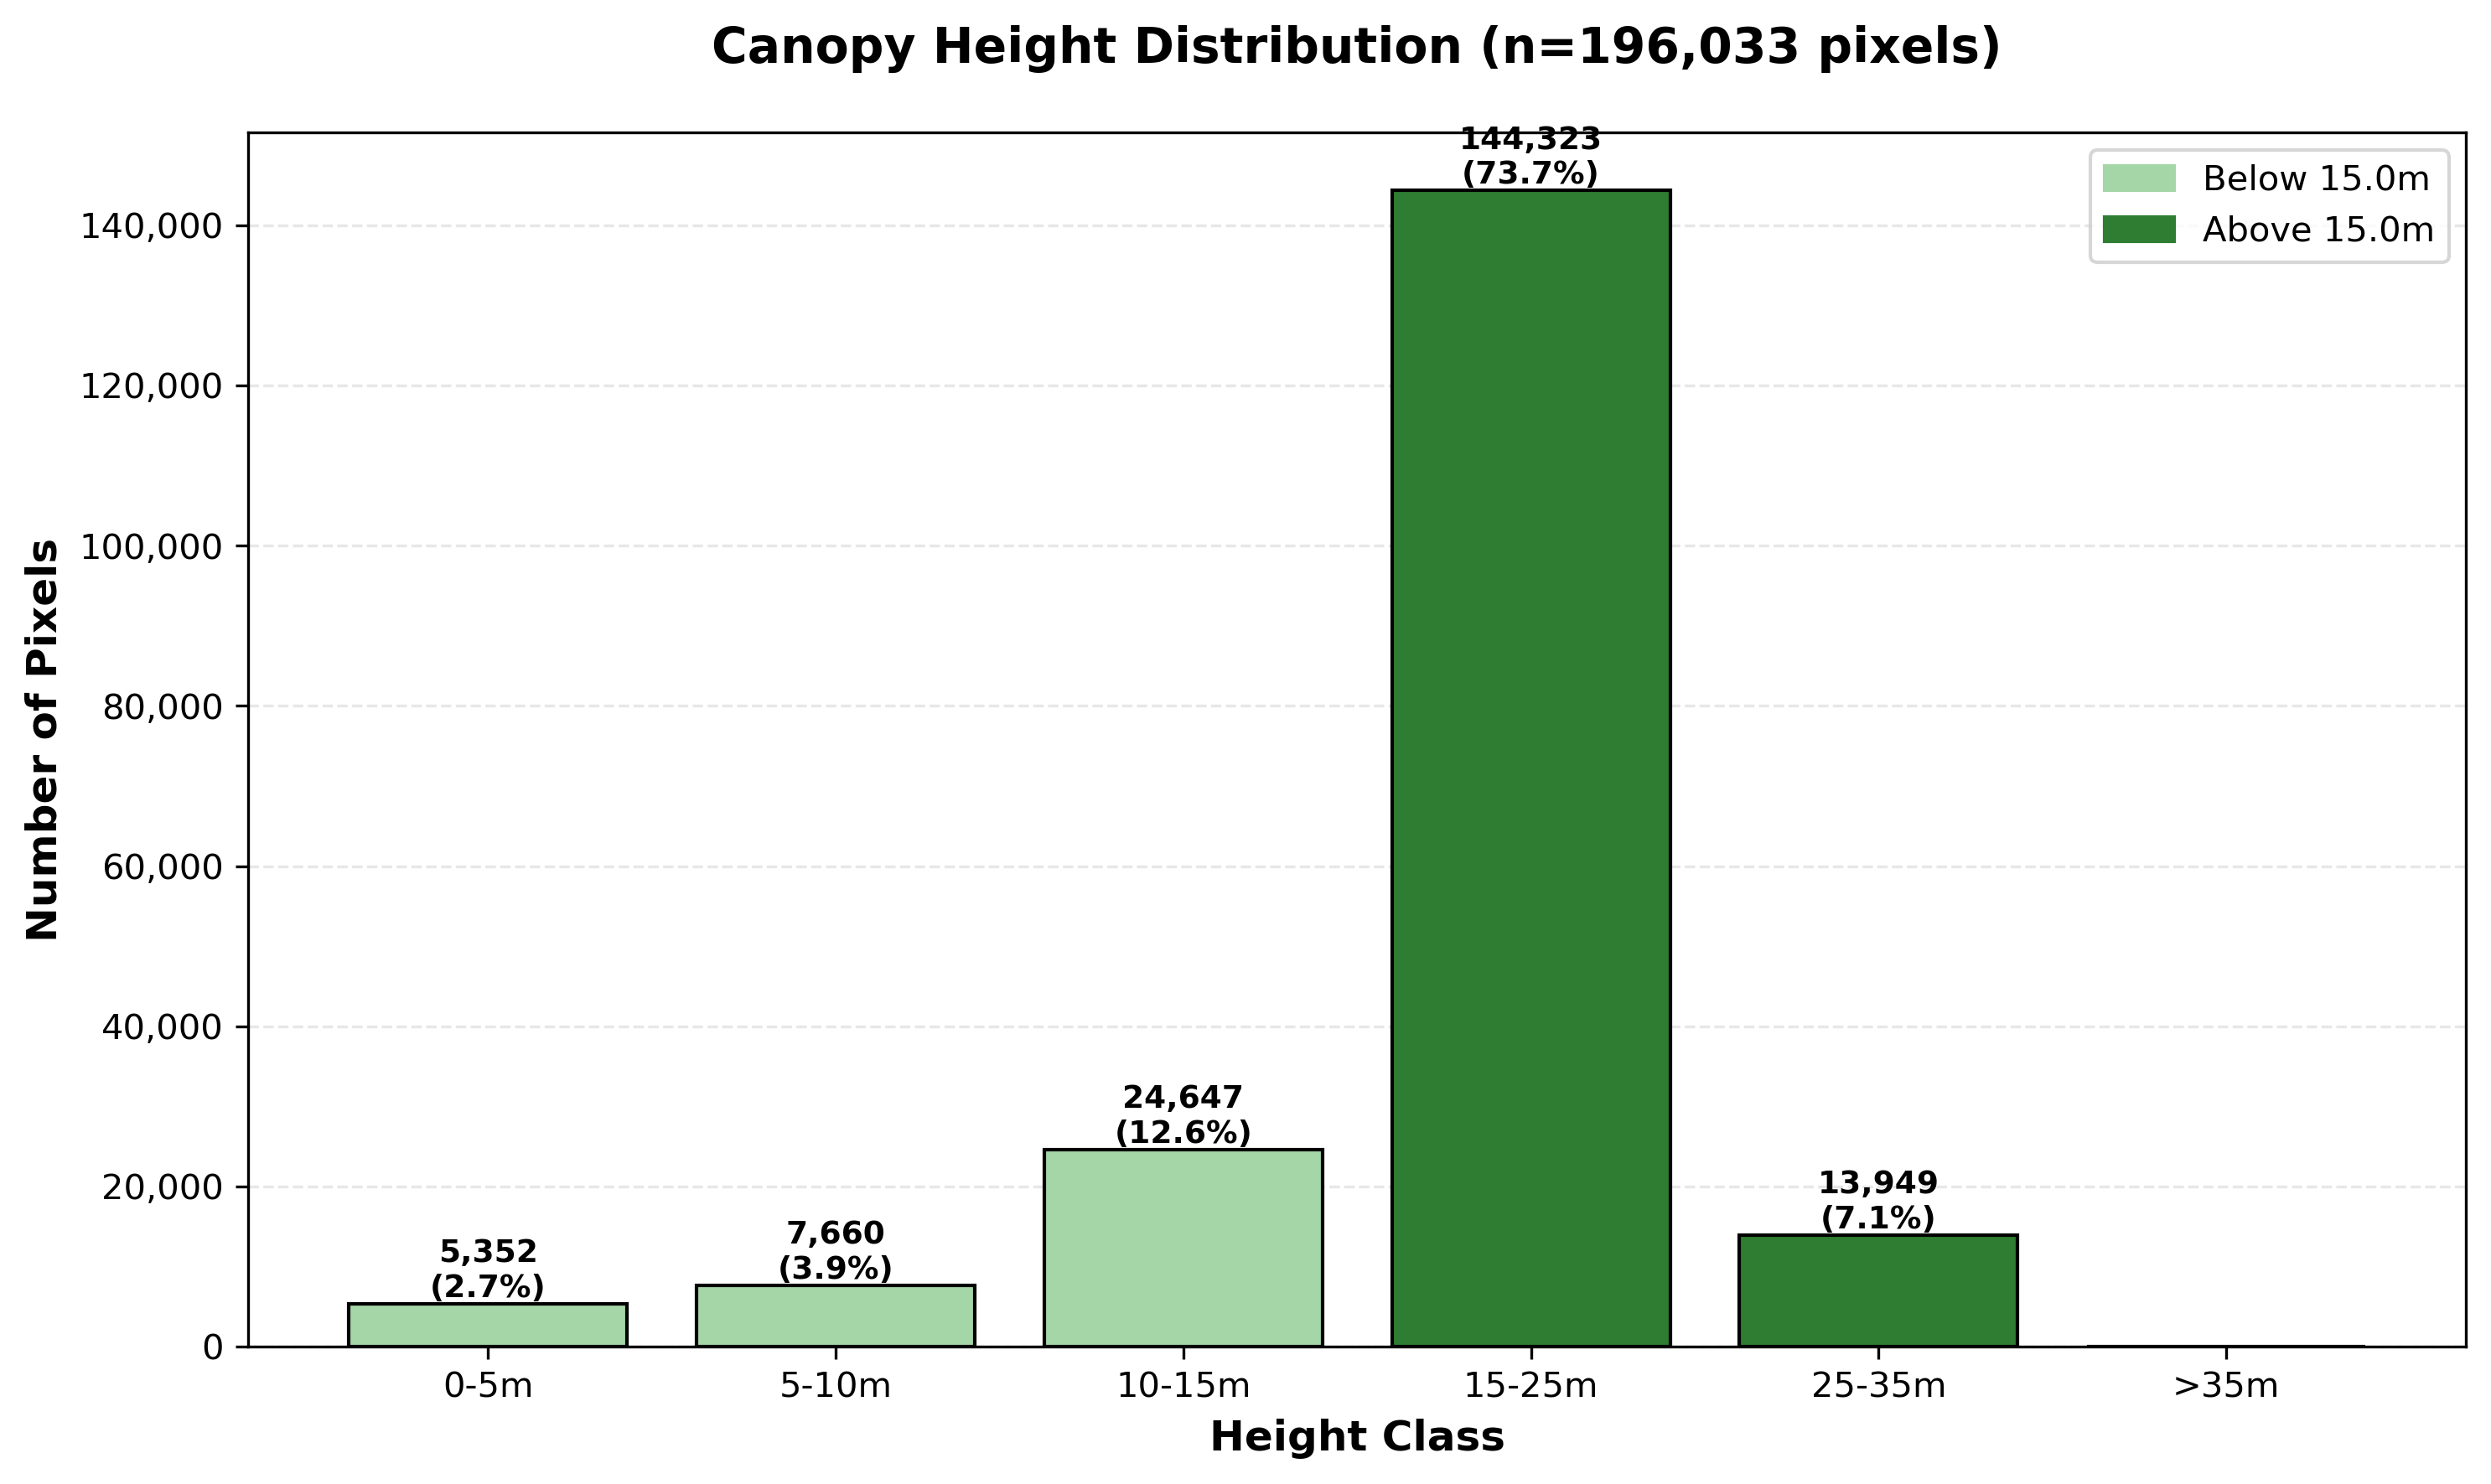


LVP21 (EBE-any)
  Observer:  Geschlossen/Gedrängt
  Derived:   1.00  (0=light .. 1=closed)
  Mean height: 22.5m | Valid pixels: 196,032


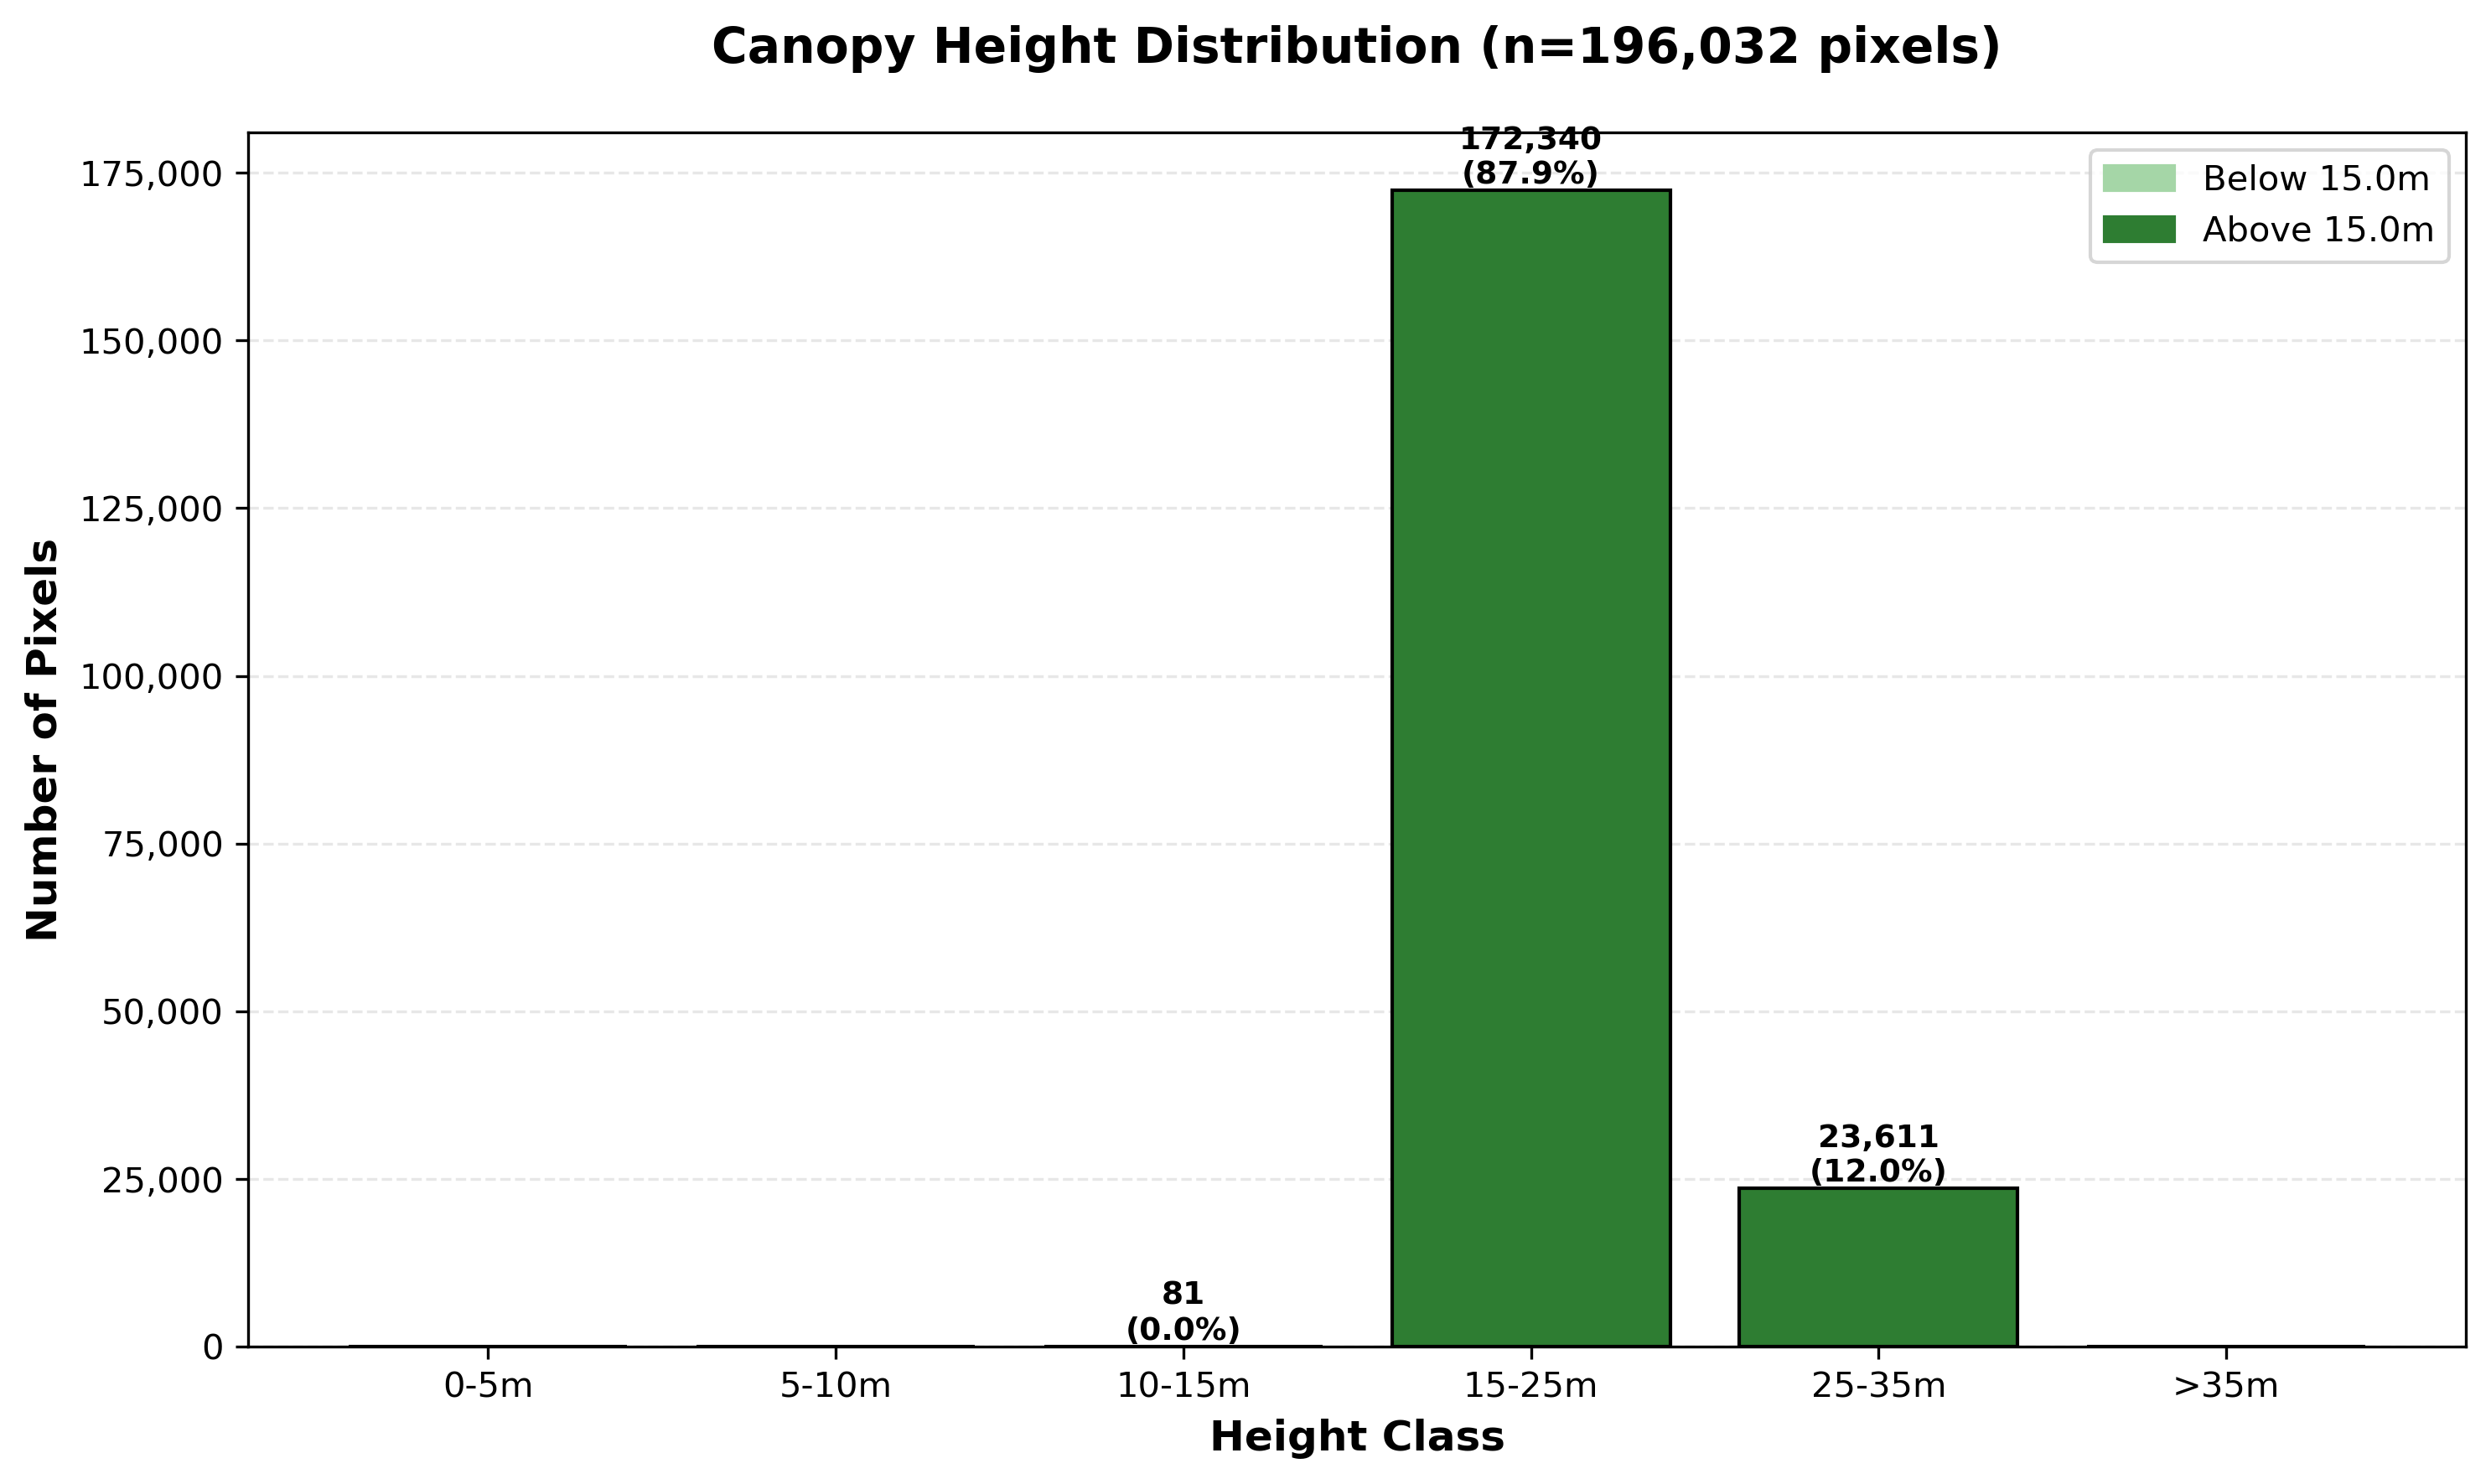


LVP22 (EBE-any)
  Observer:  Geschlossen/Gedrängt
  Derived:   0.99  (0=light .. 1=closed)
  Mean height: 22.6m | Valid pixels: 196,038


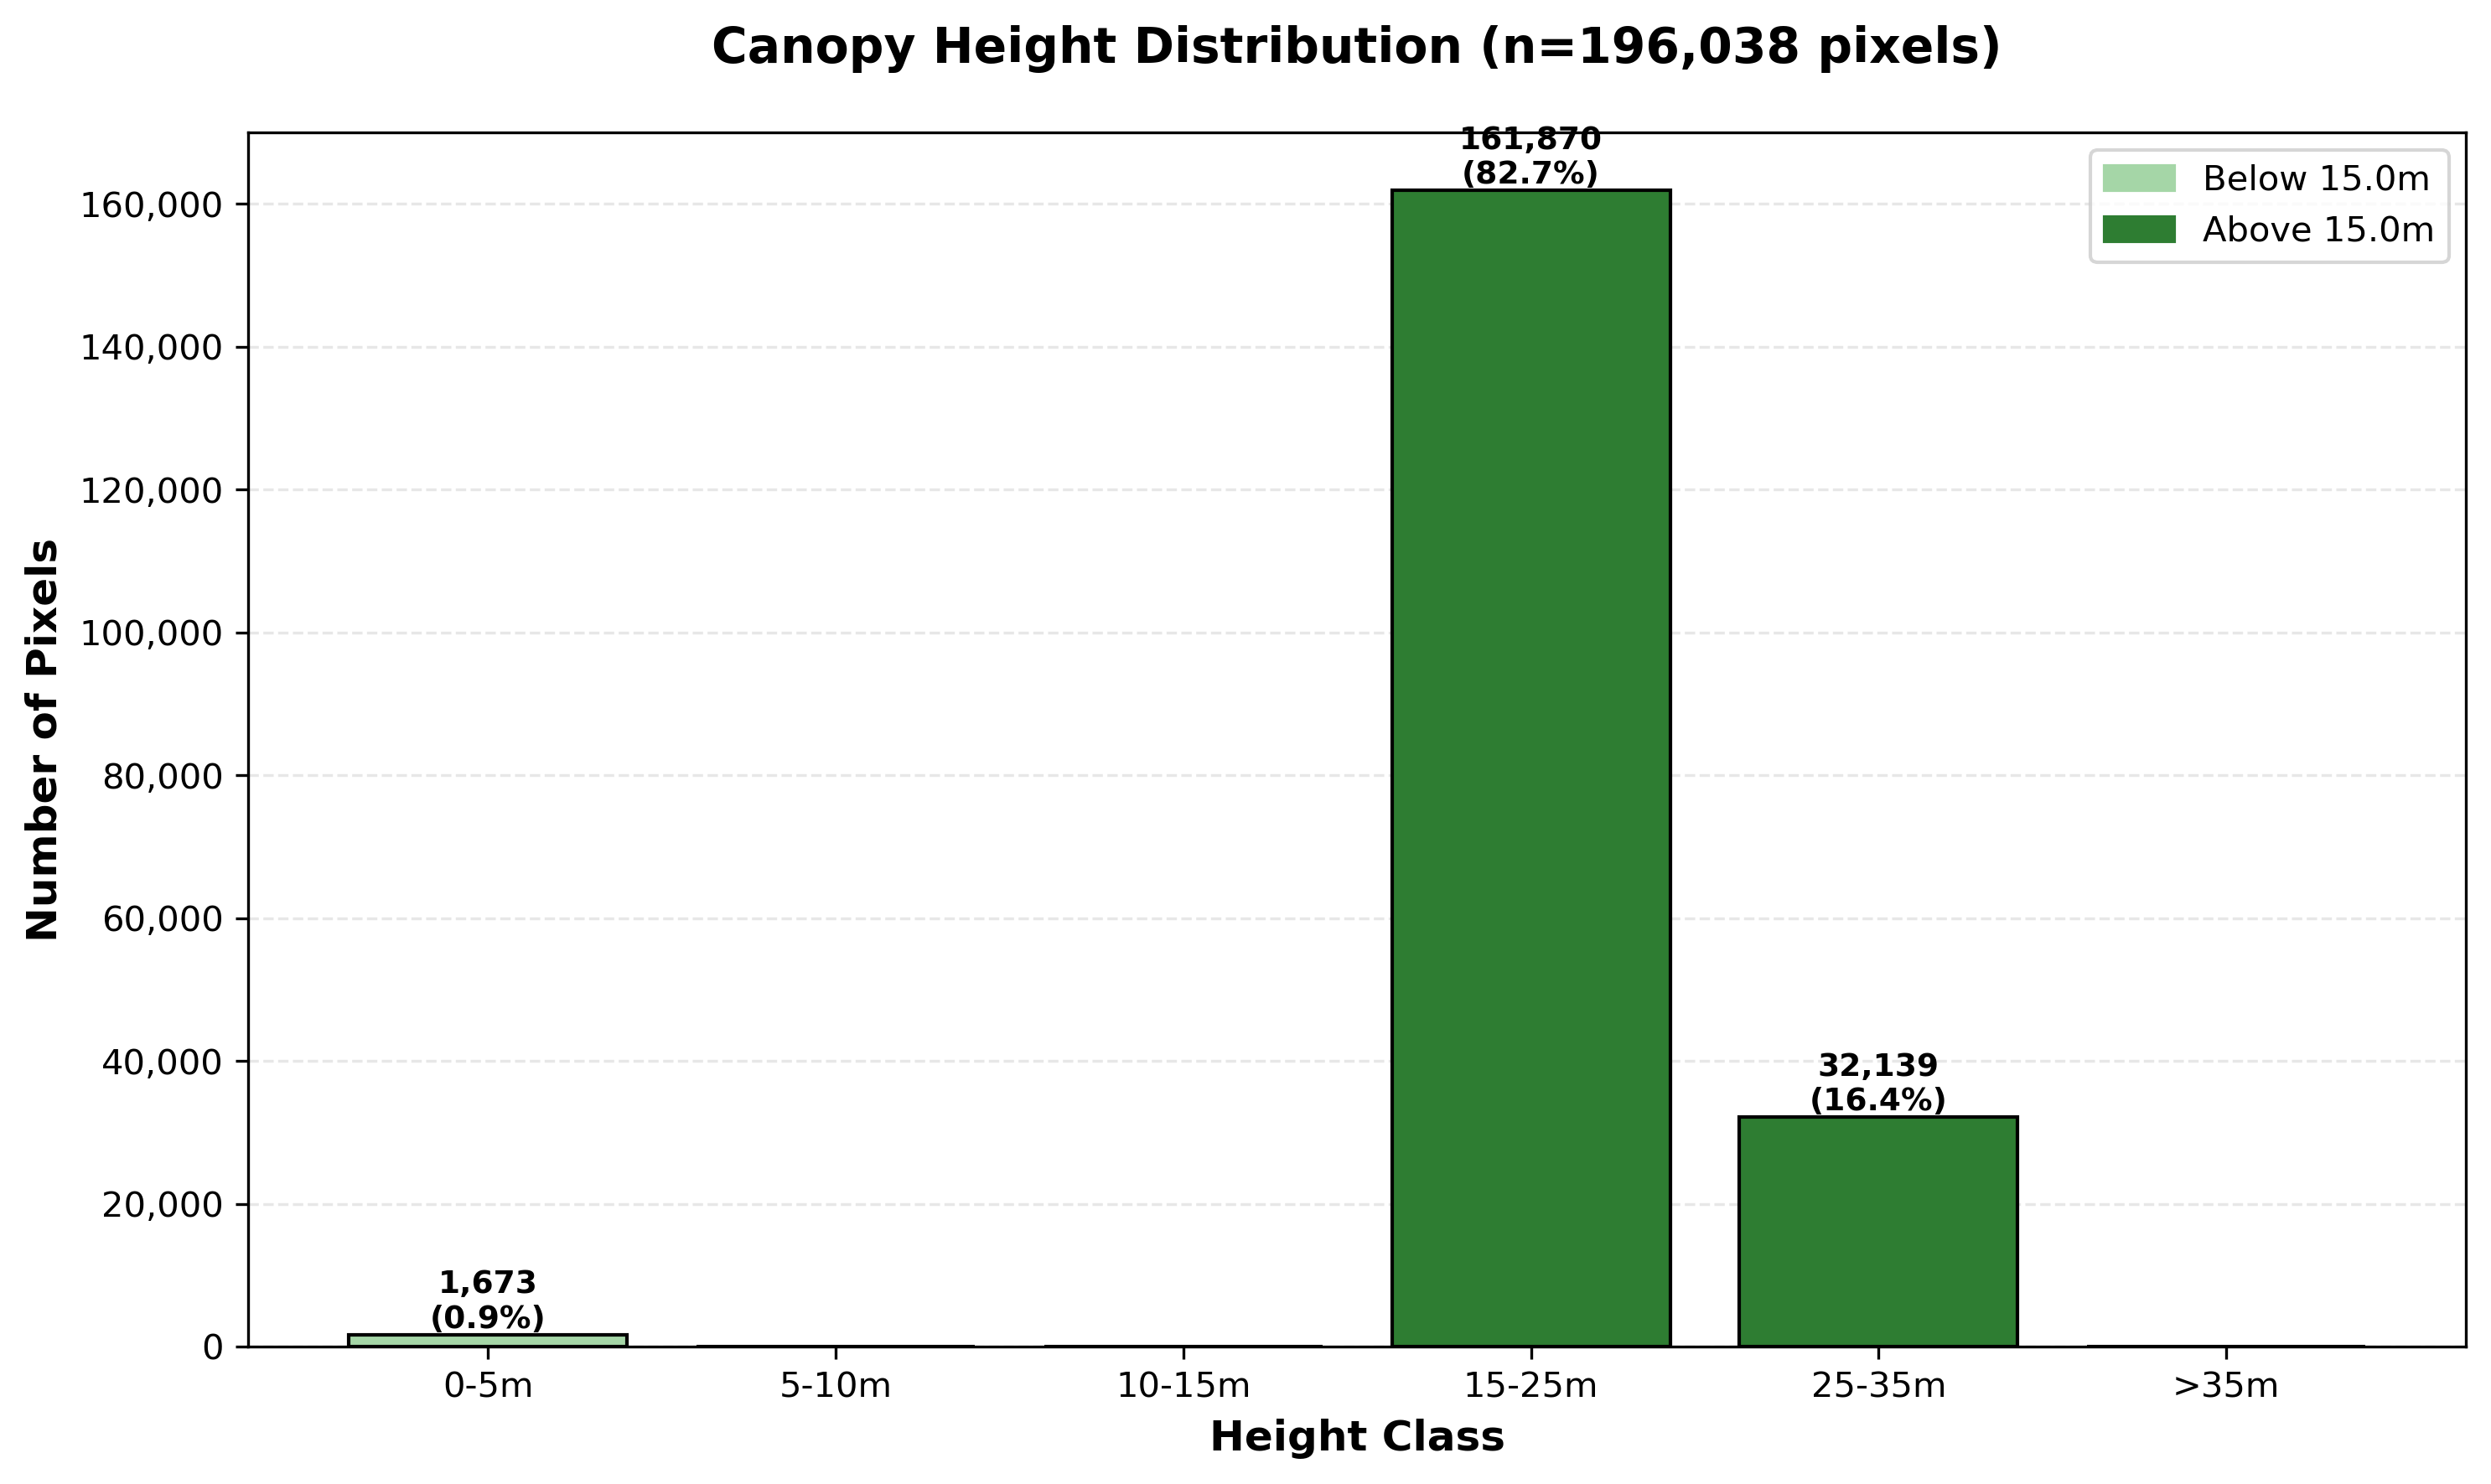


LVP23 (EBE-any)
  Observer:  Geschlossen/Gedrängt
  Derived:   0.98  (0=light .. 1=closed)
  Mean height: 21.8m | Valid pixels: 196,028


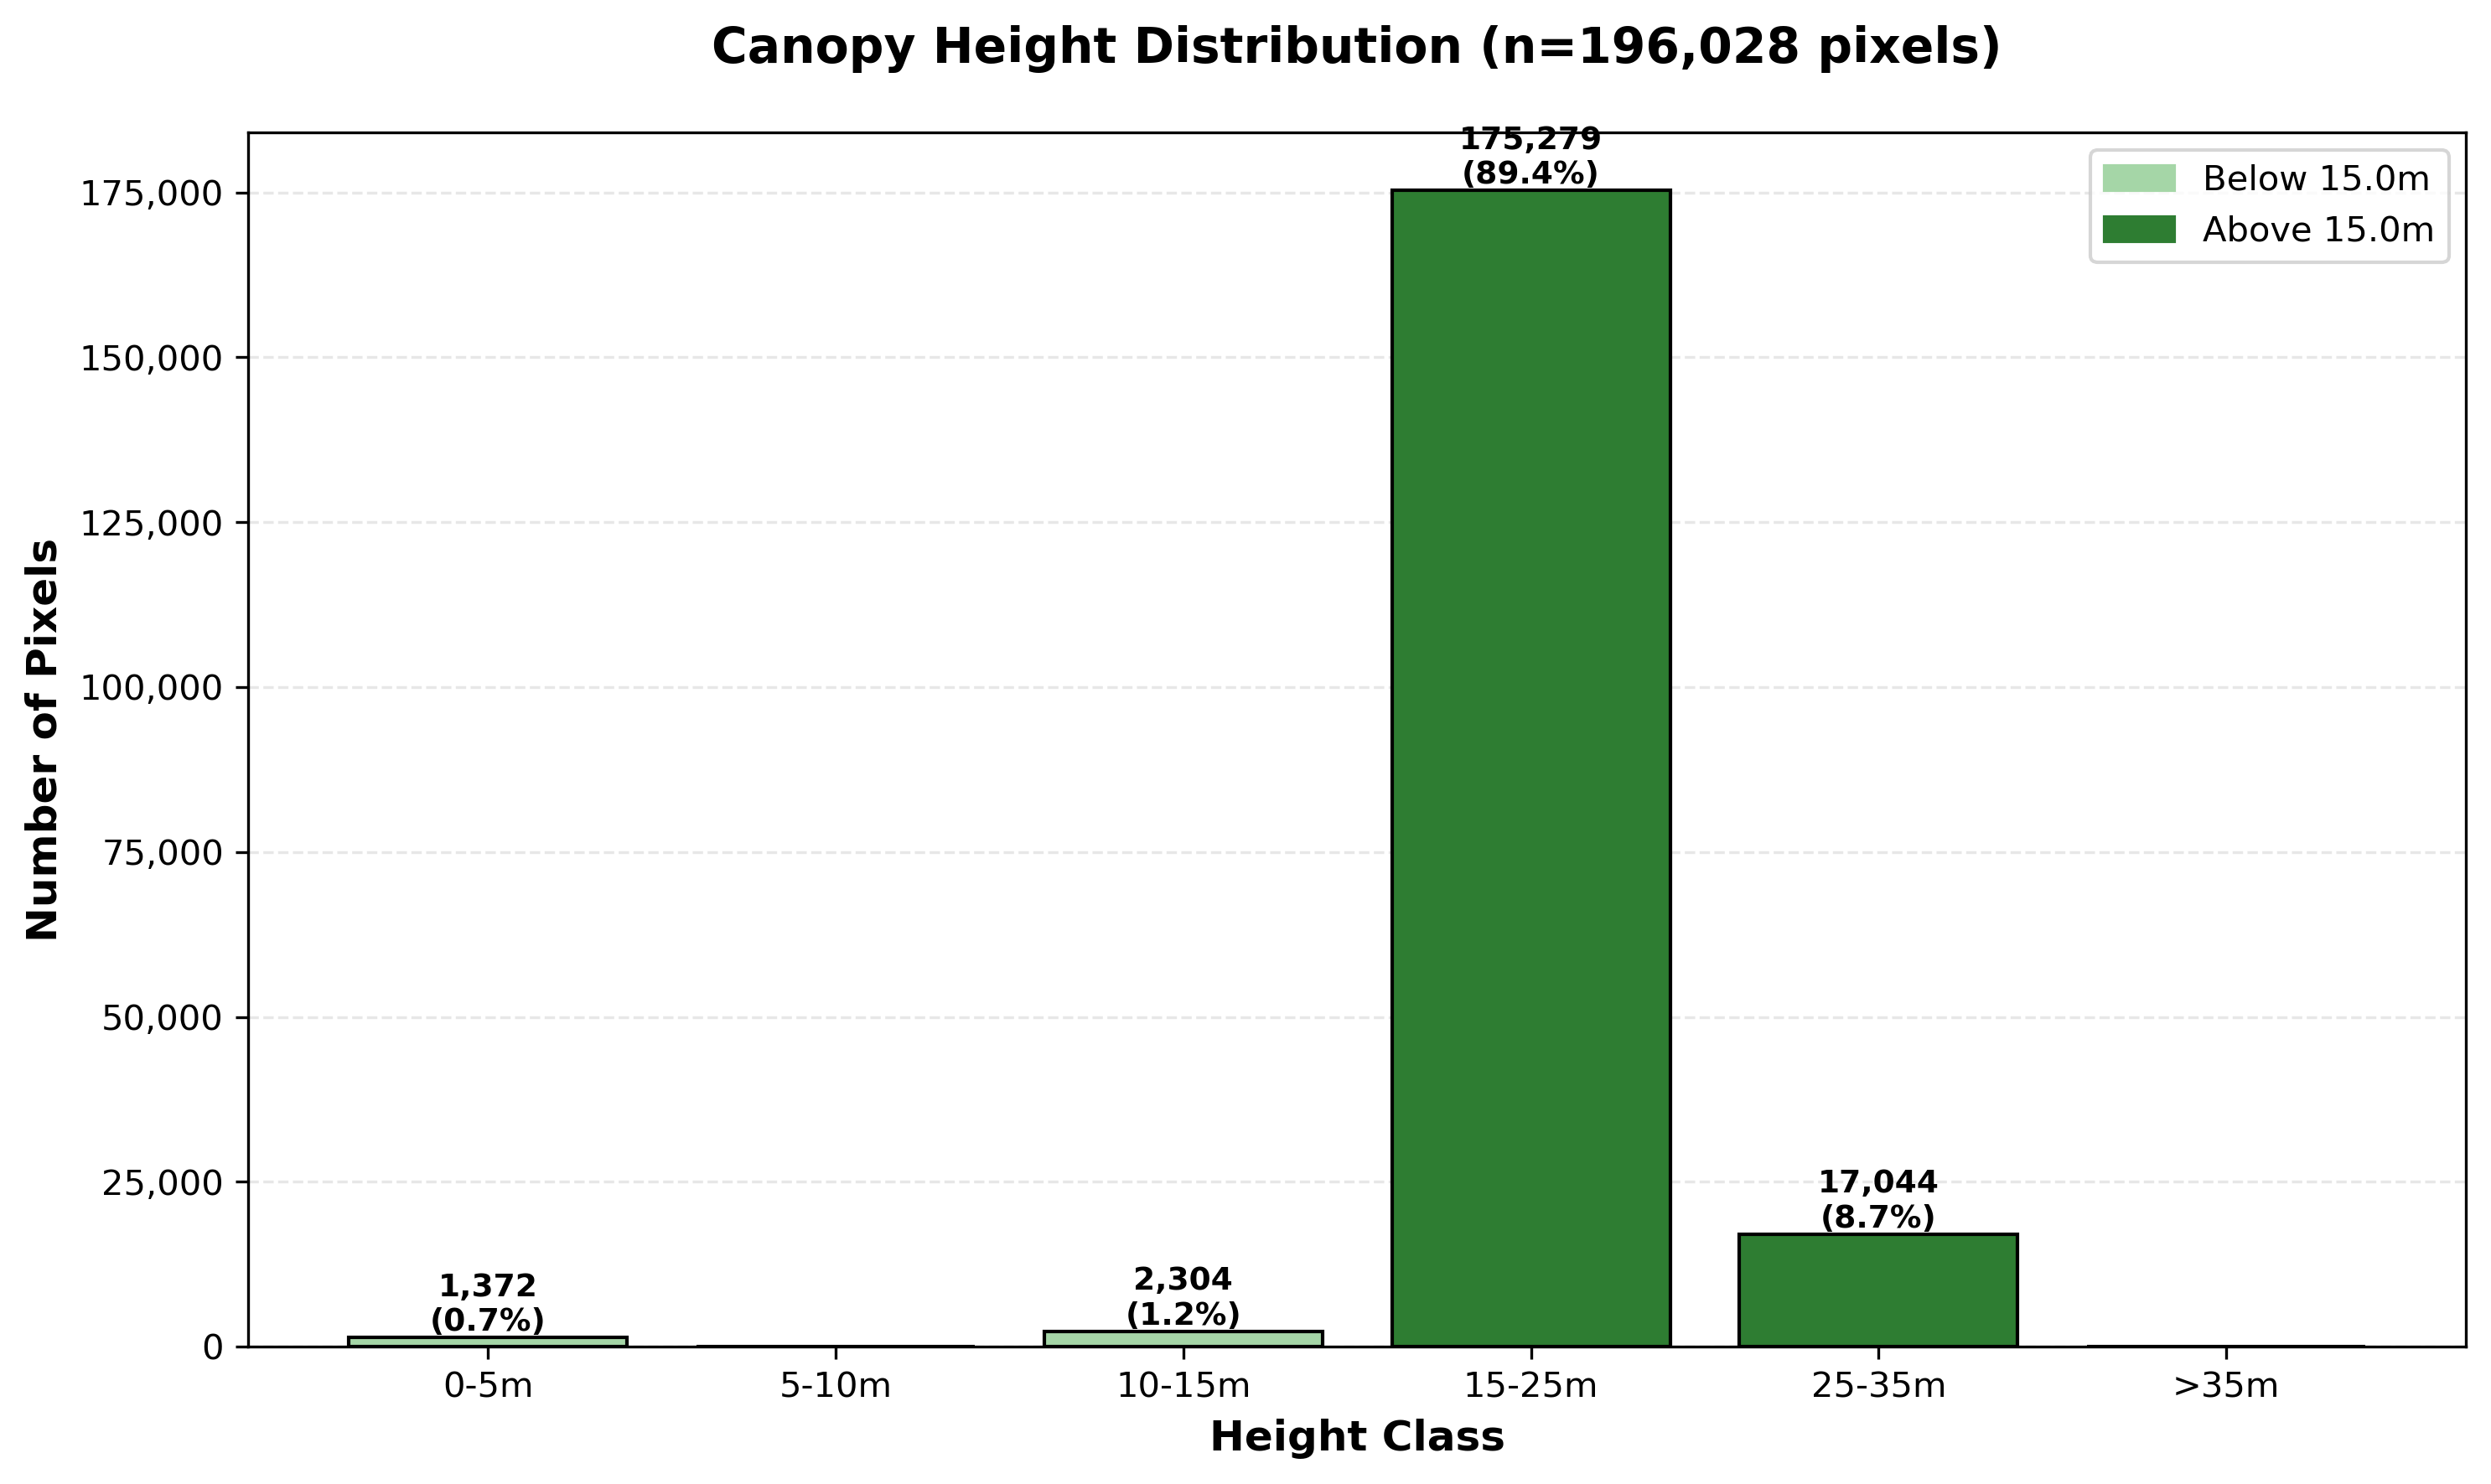


LVP24 (EBE-any)
  Observer:  Lücke < Baumlänge
  Derived:   0.97  (0=light .. 1=closed)
  Mean height: 20.8m | Valid pixels: 196,039


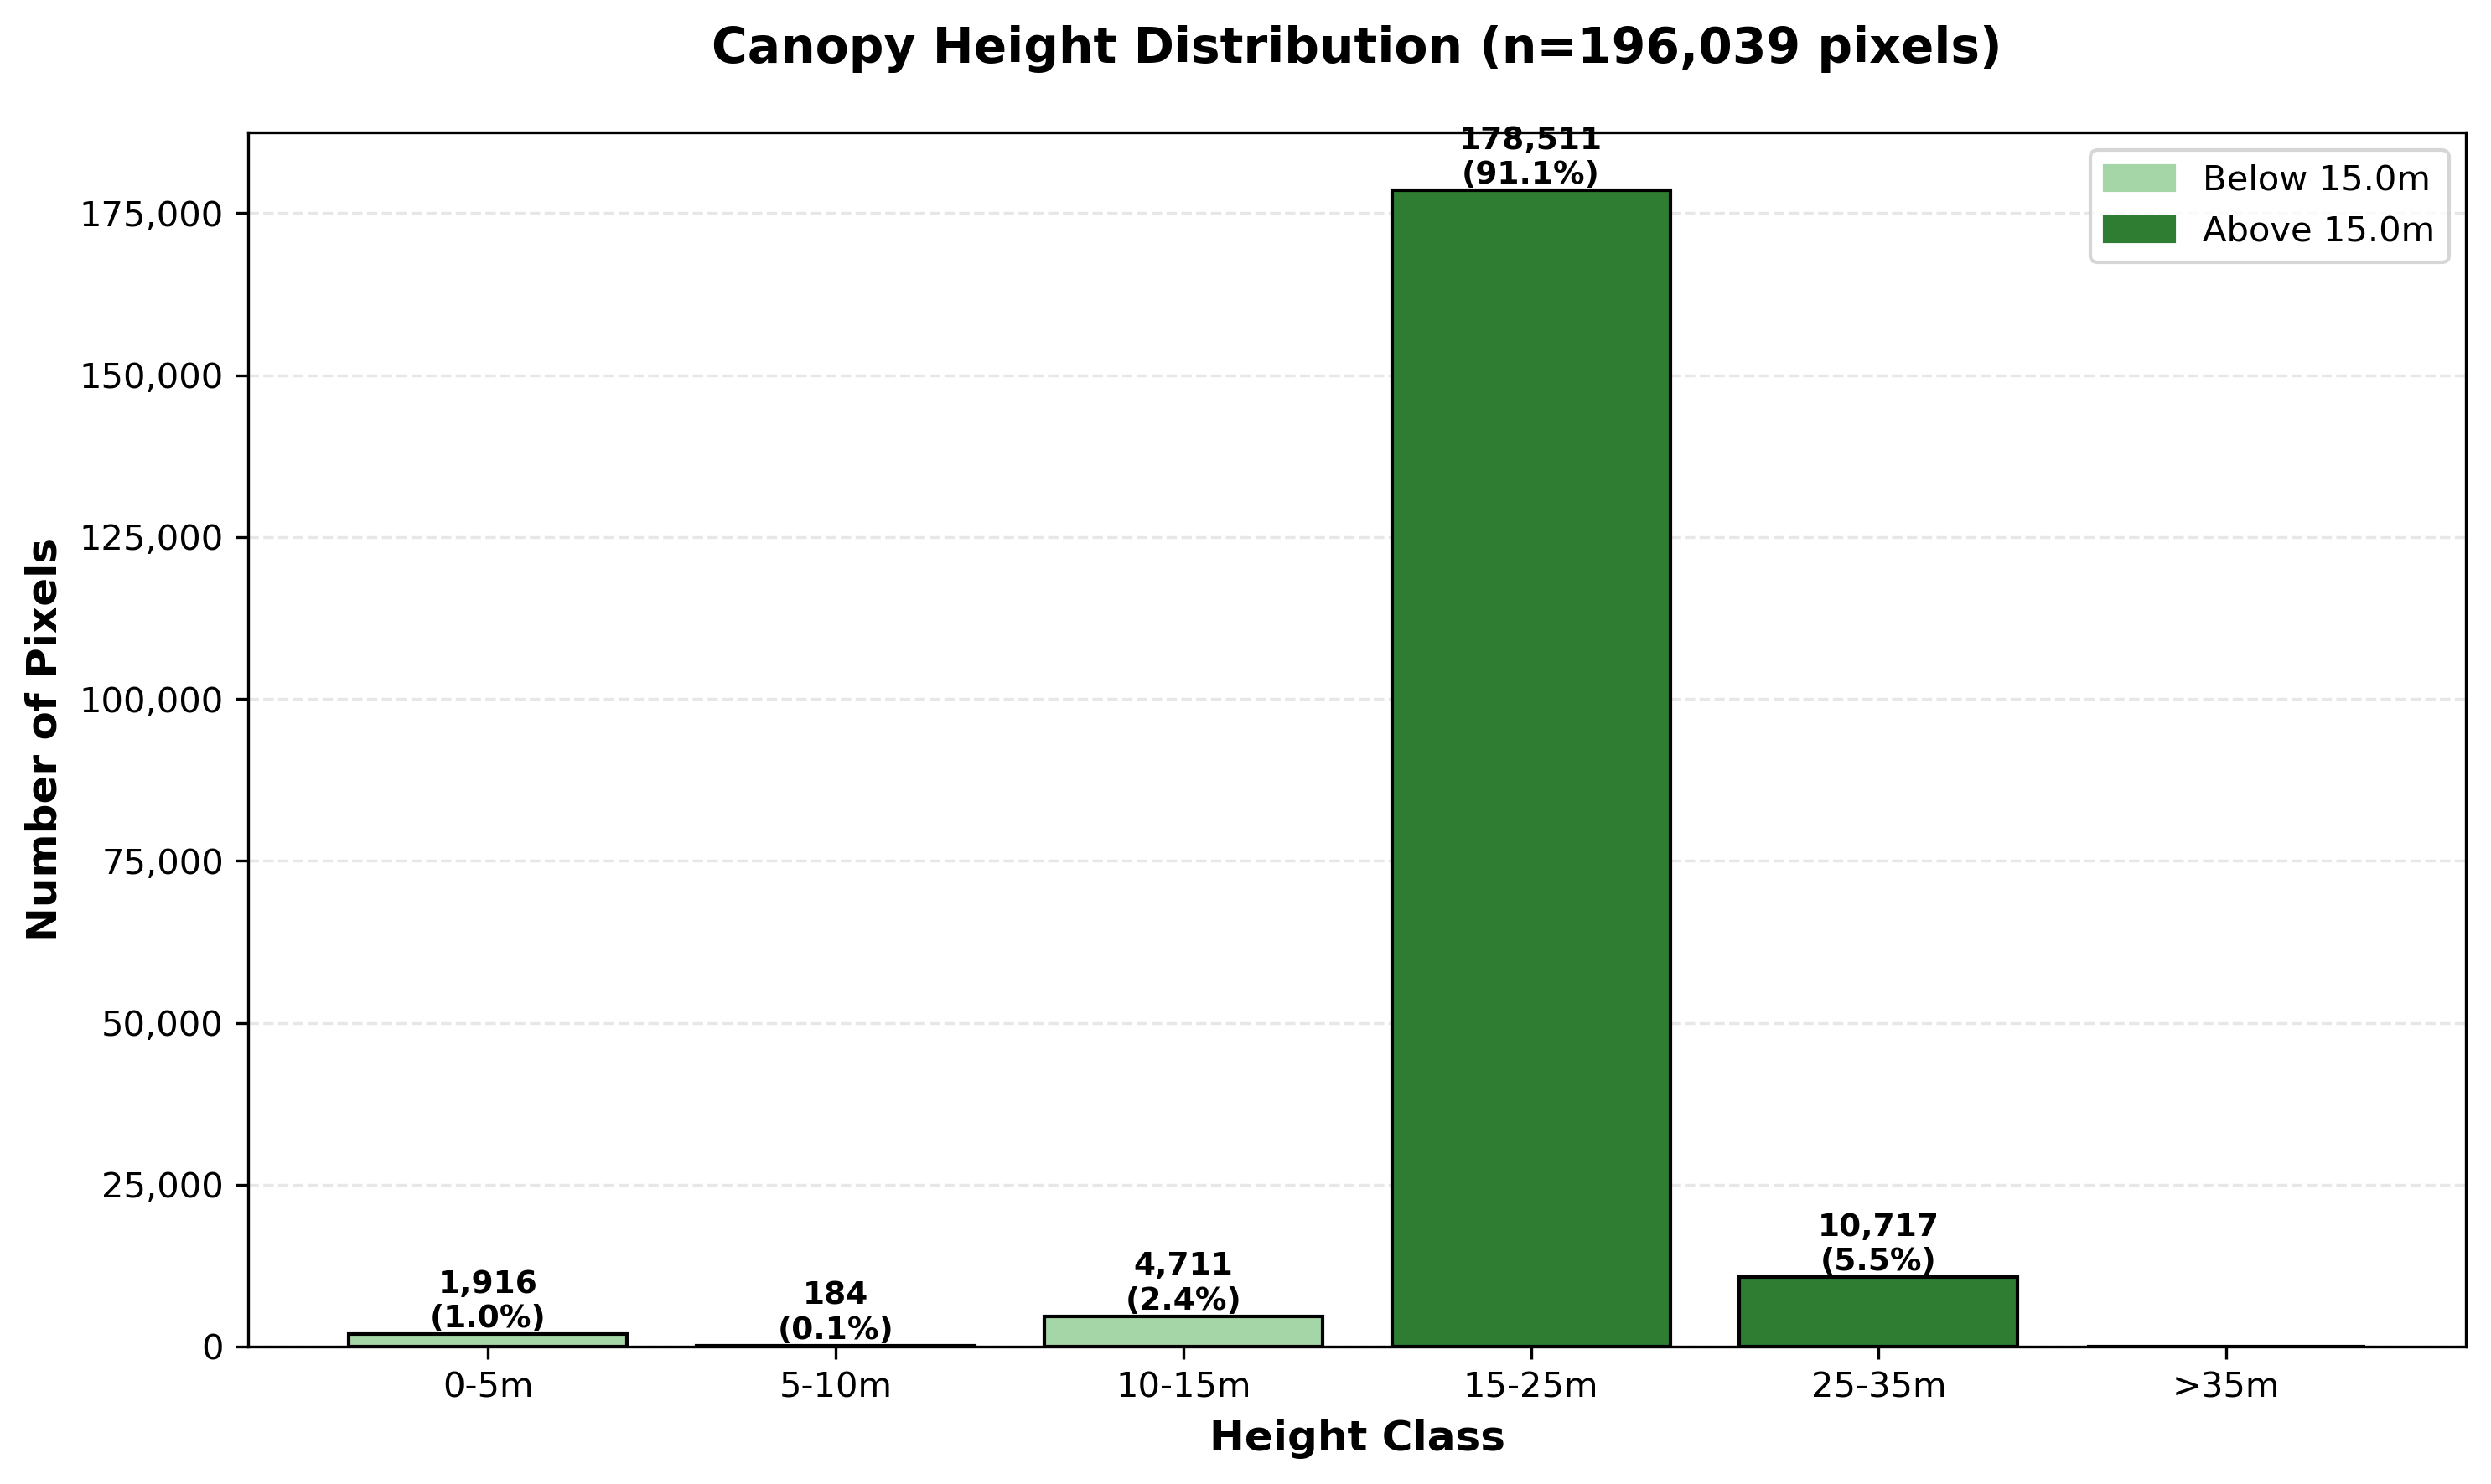


LVP25 (EBE-any)
  Observer:  Geschlossen/Gedrängt
  Derived:   0.91  (0=light .. 1=closed)
  Mean height: 22.3m | Valid pixels: 196,037


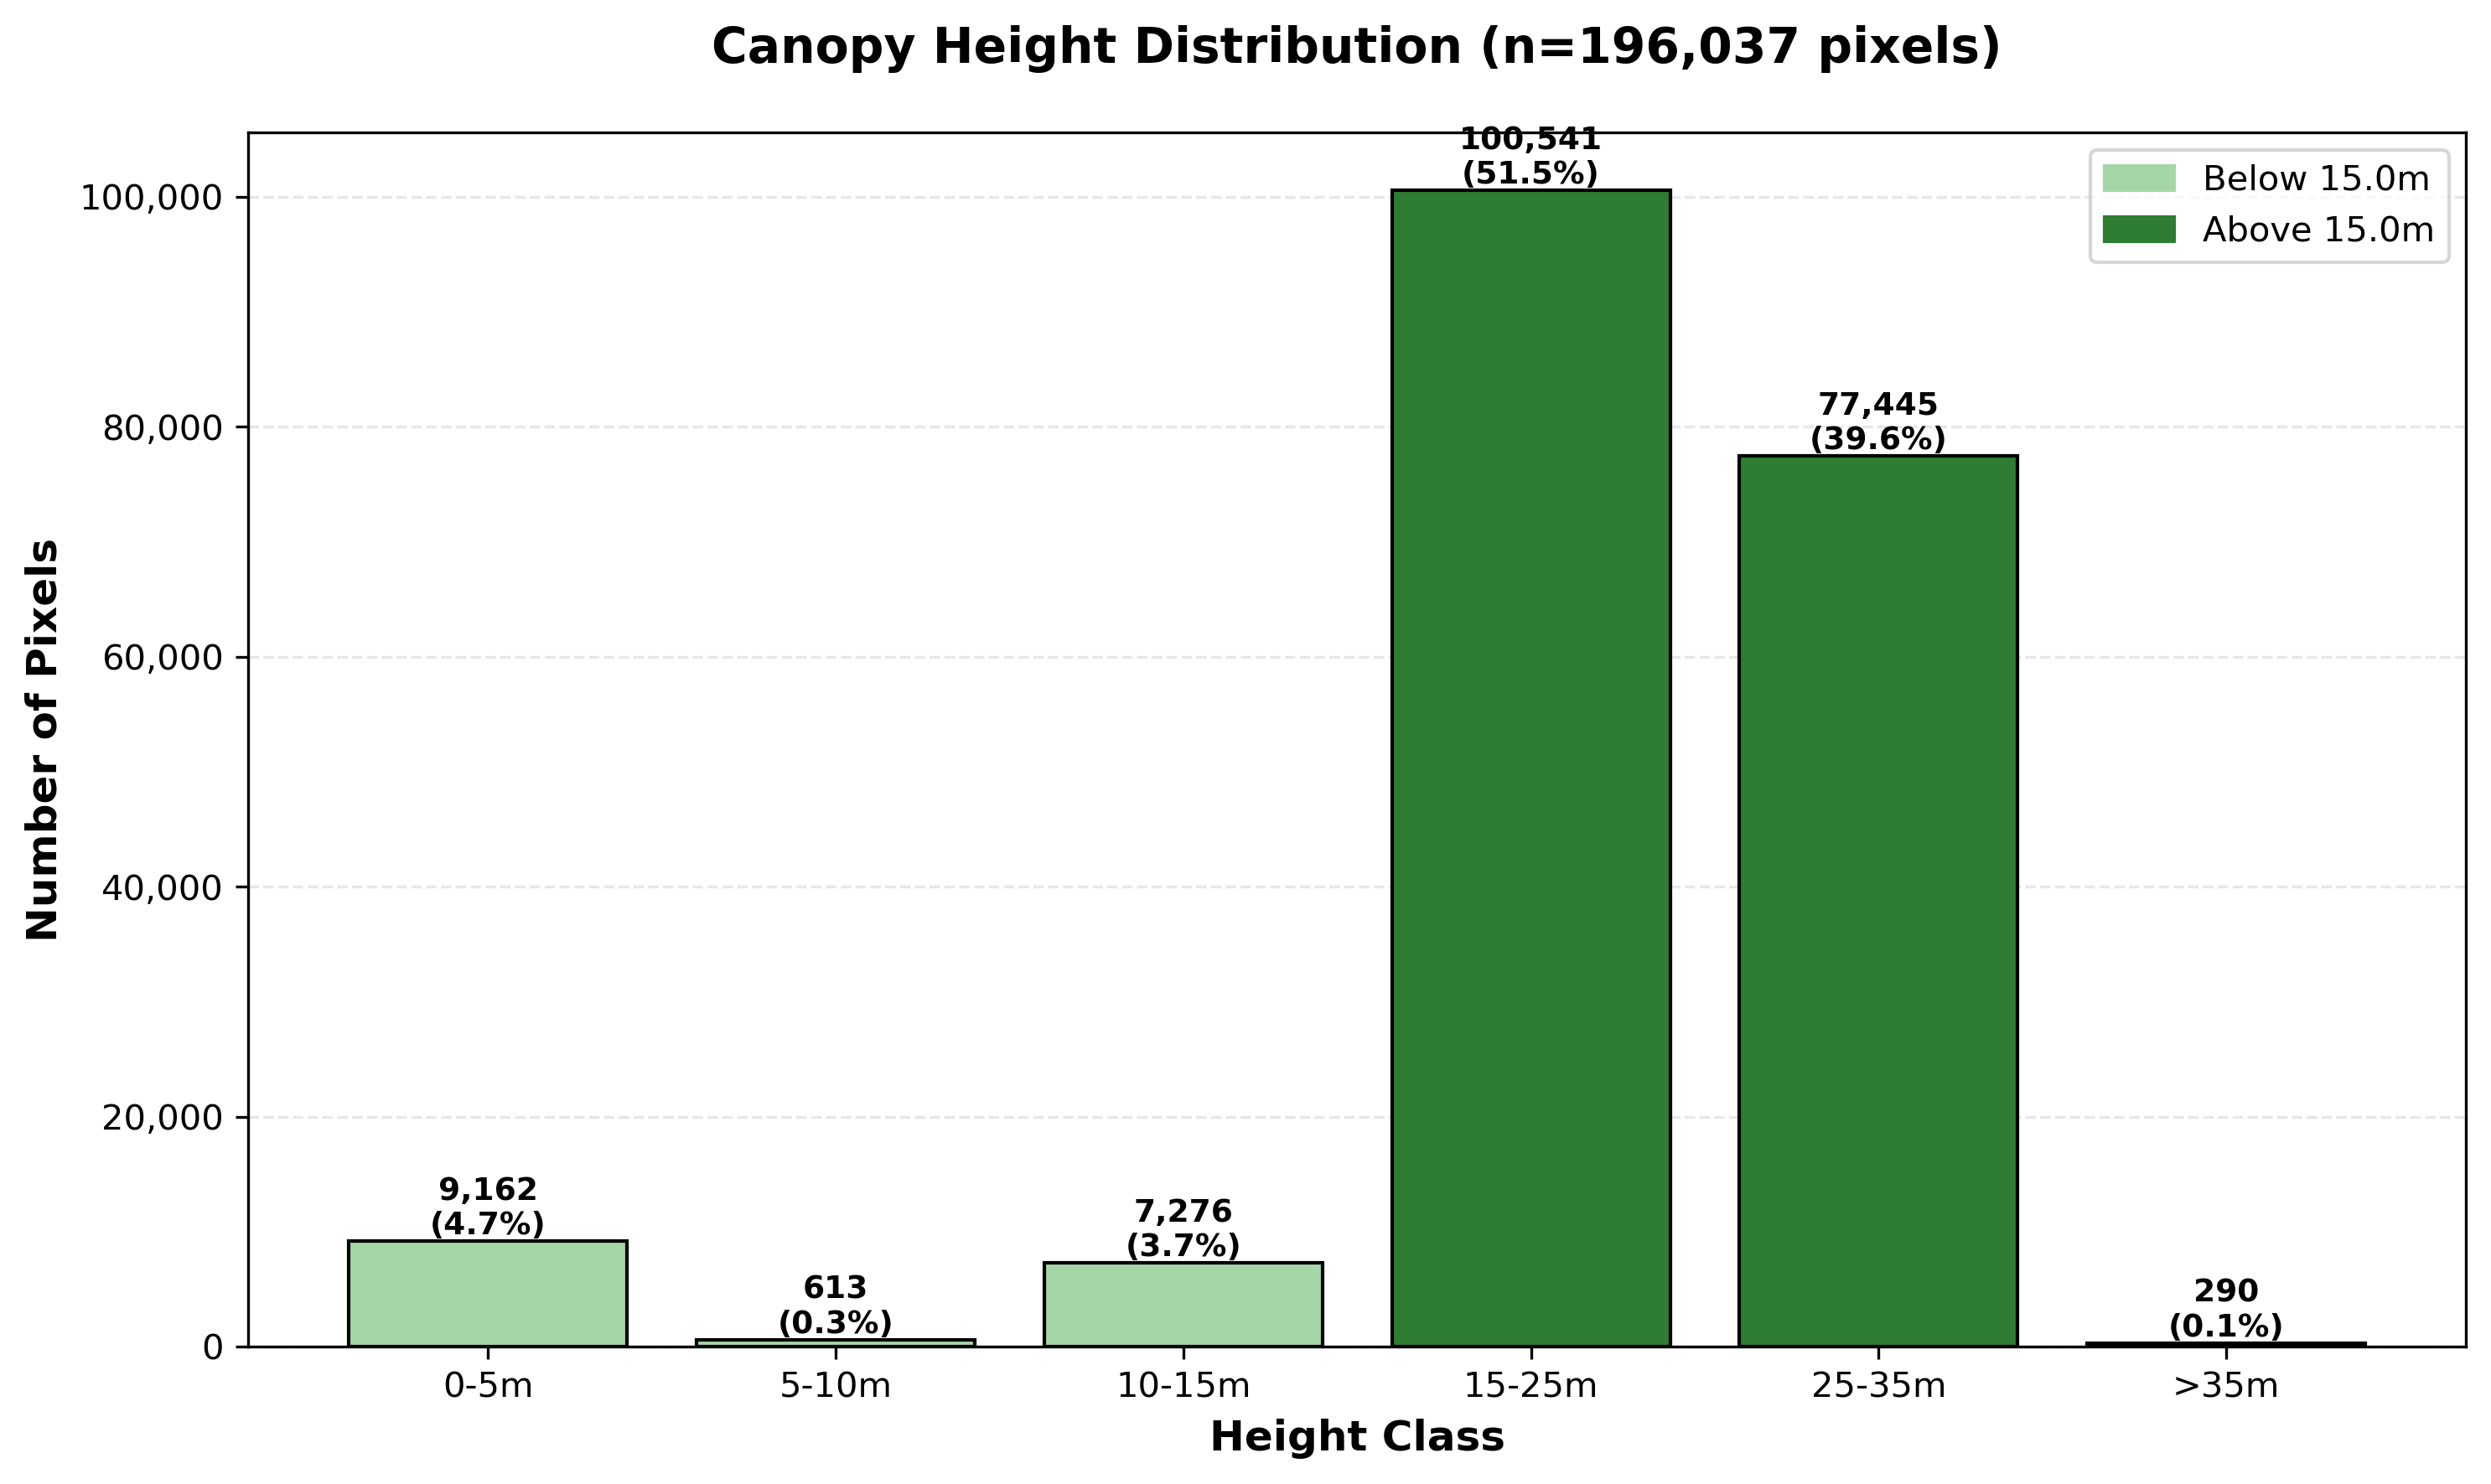


LVP26 (EBE-any)
  Observer:  Licht-Geschlossen/Licht
  Derived:   0.86  (0=light .. 1=closed)
  Mean height: 20.5m | Valid pixels: 196,023


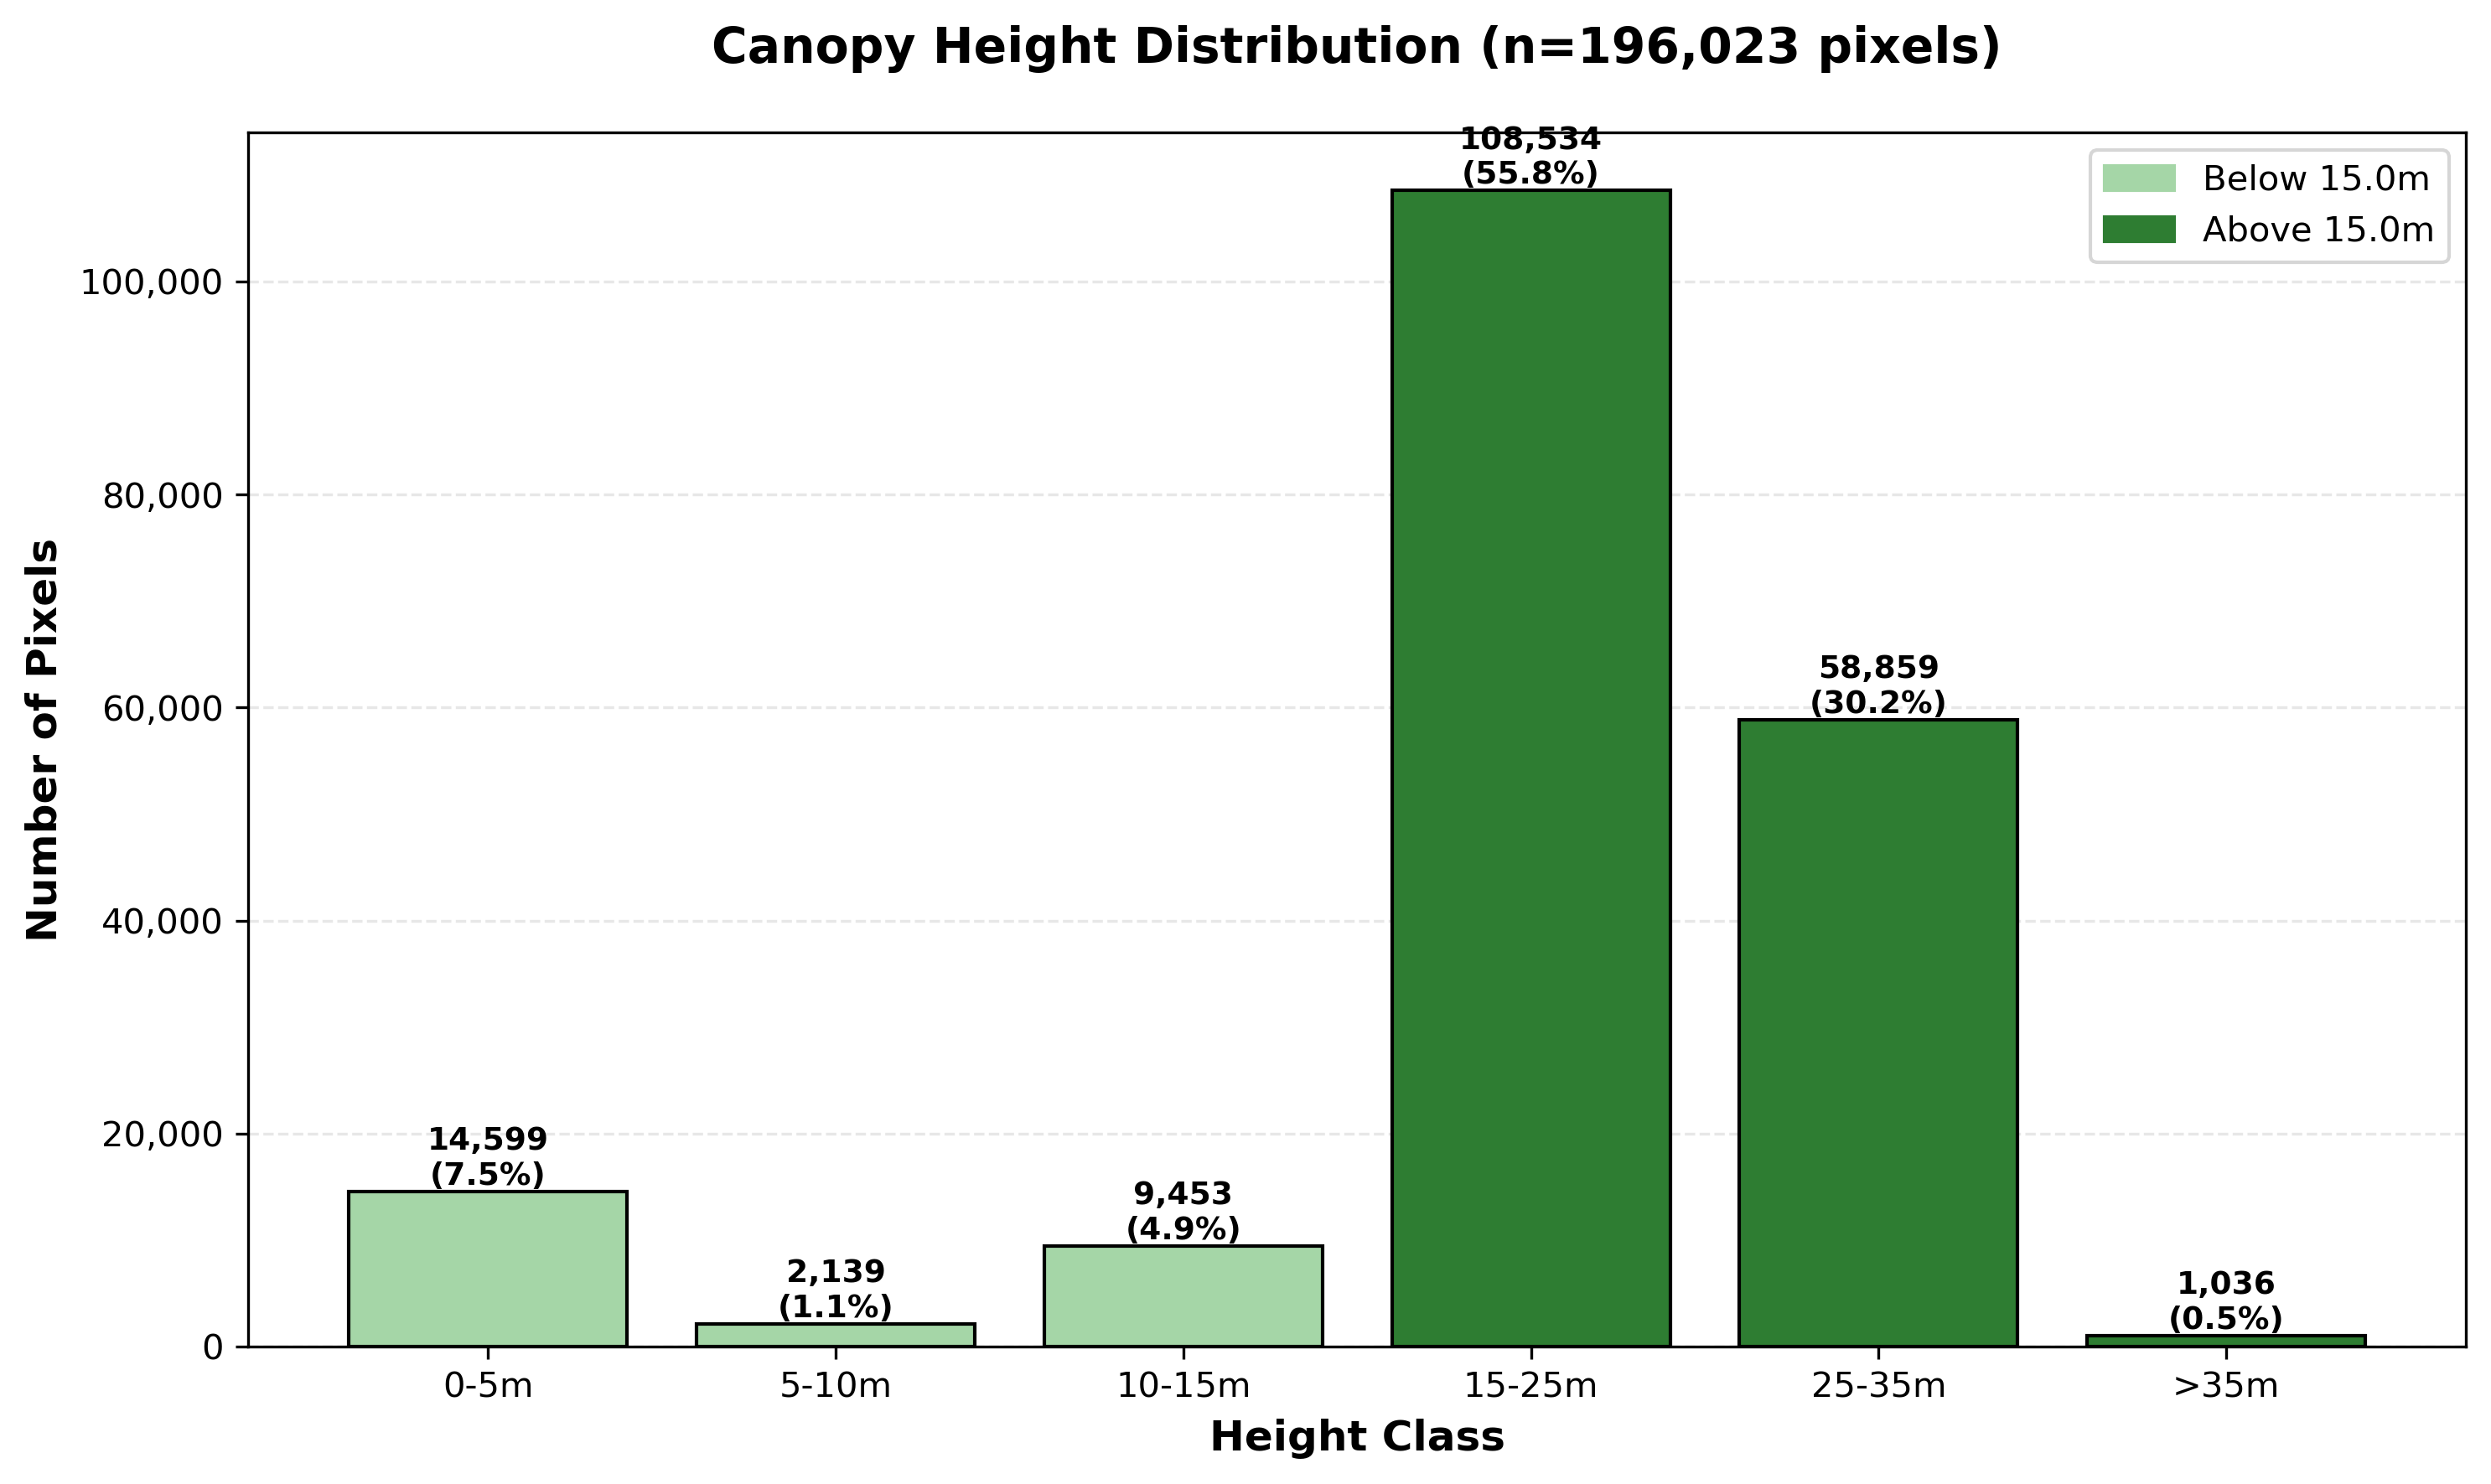


LVP27 (EBE-any)
  Observer:  Geschlossen/Gedrängt
  Derived:   0.88  (0=light .. 1=closed)
  Mean height: 20.3m | Valid pixels: 196,026


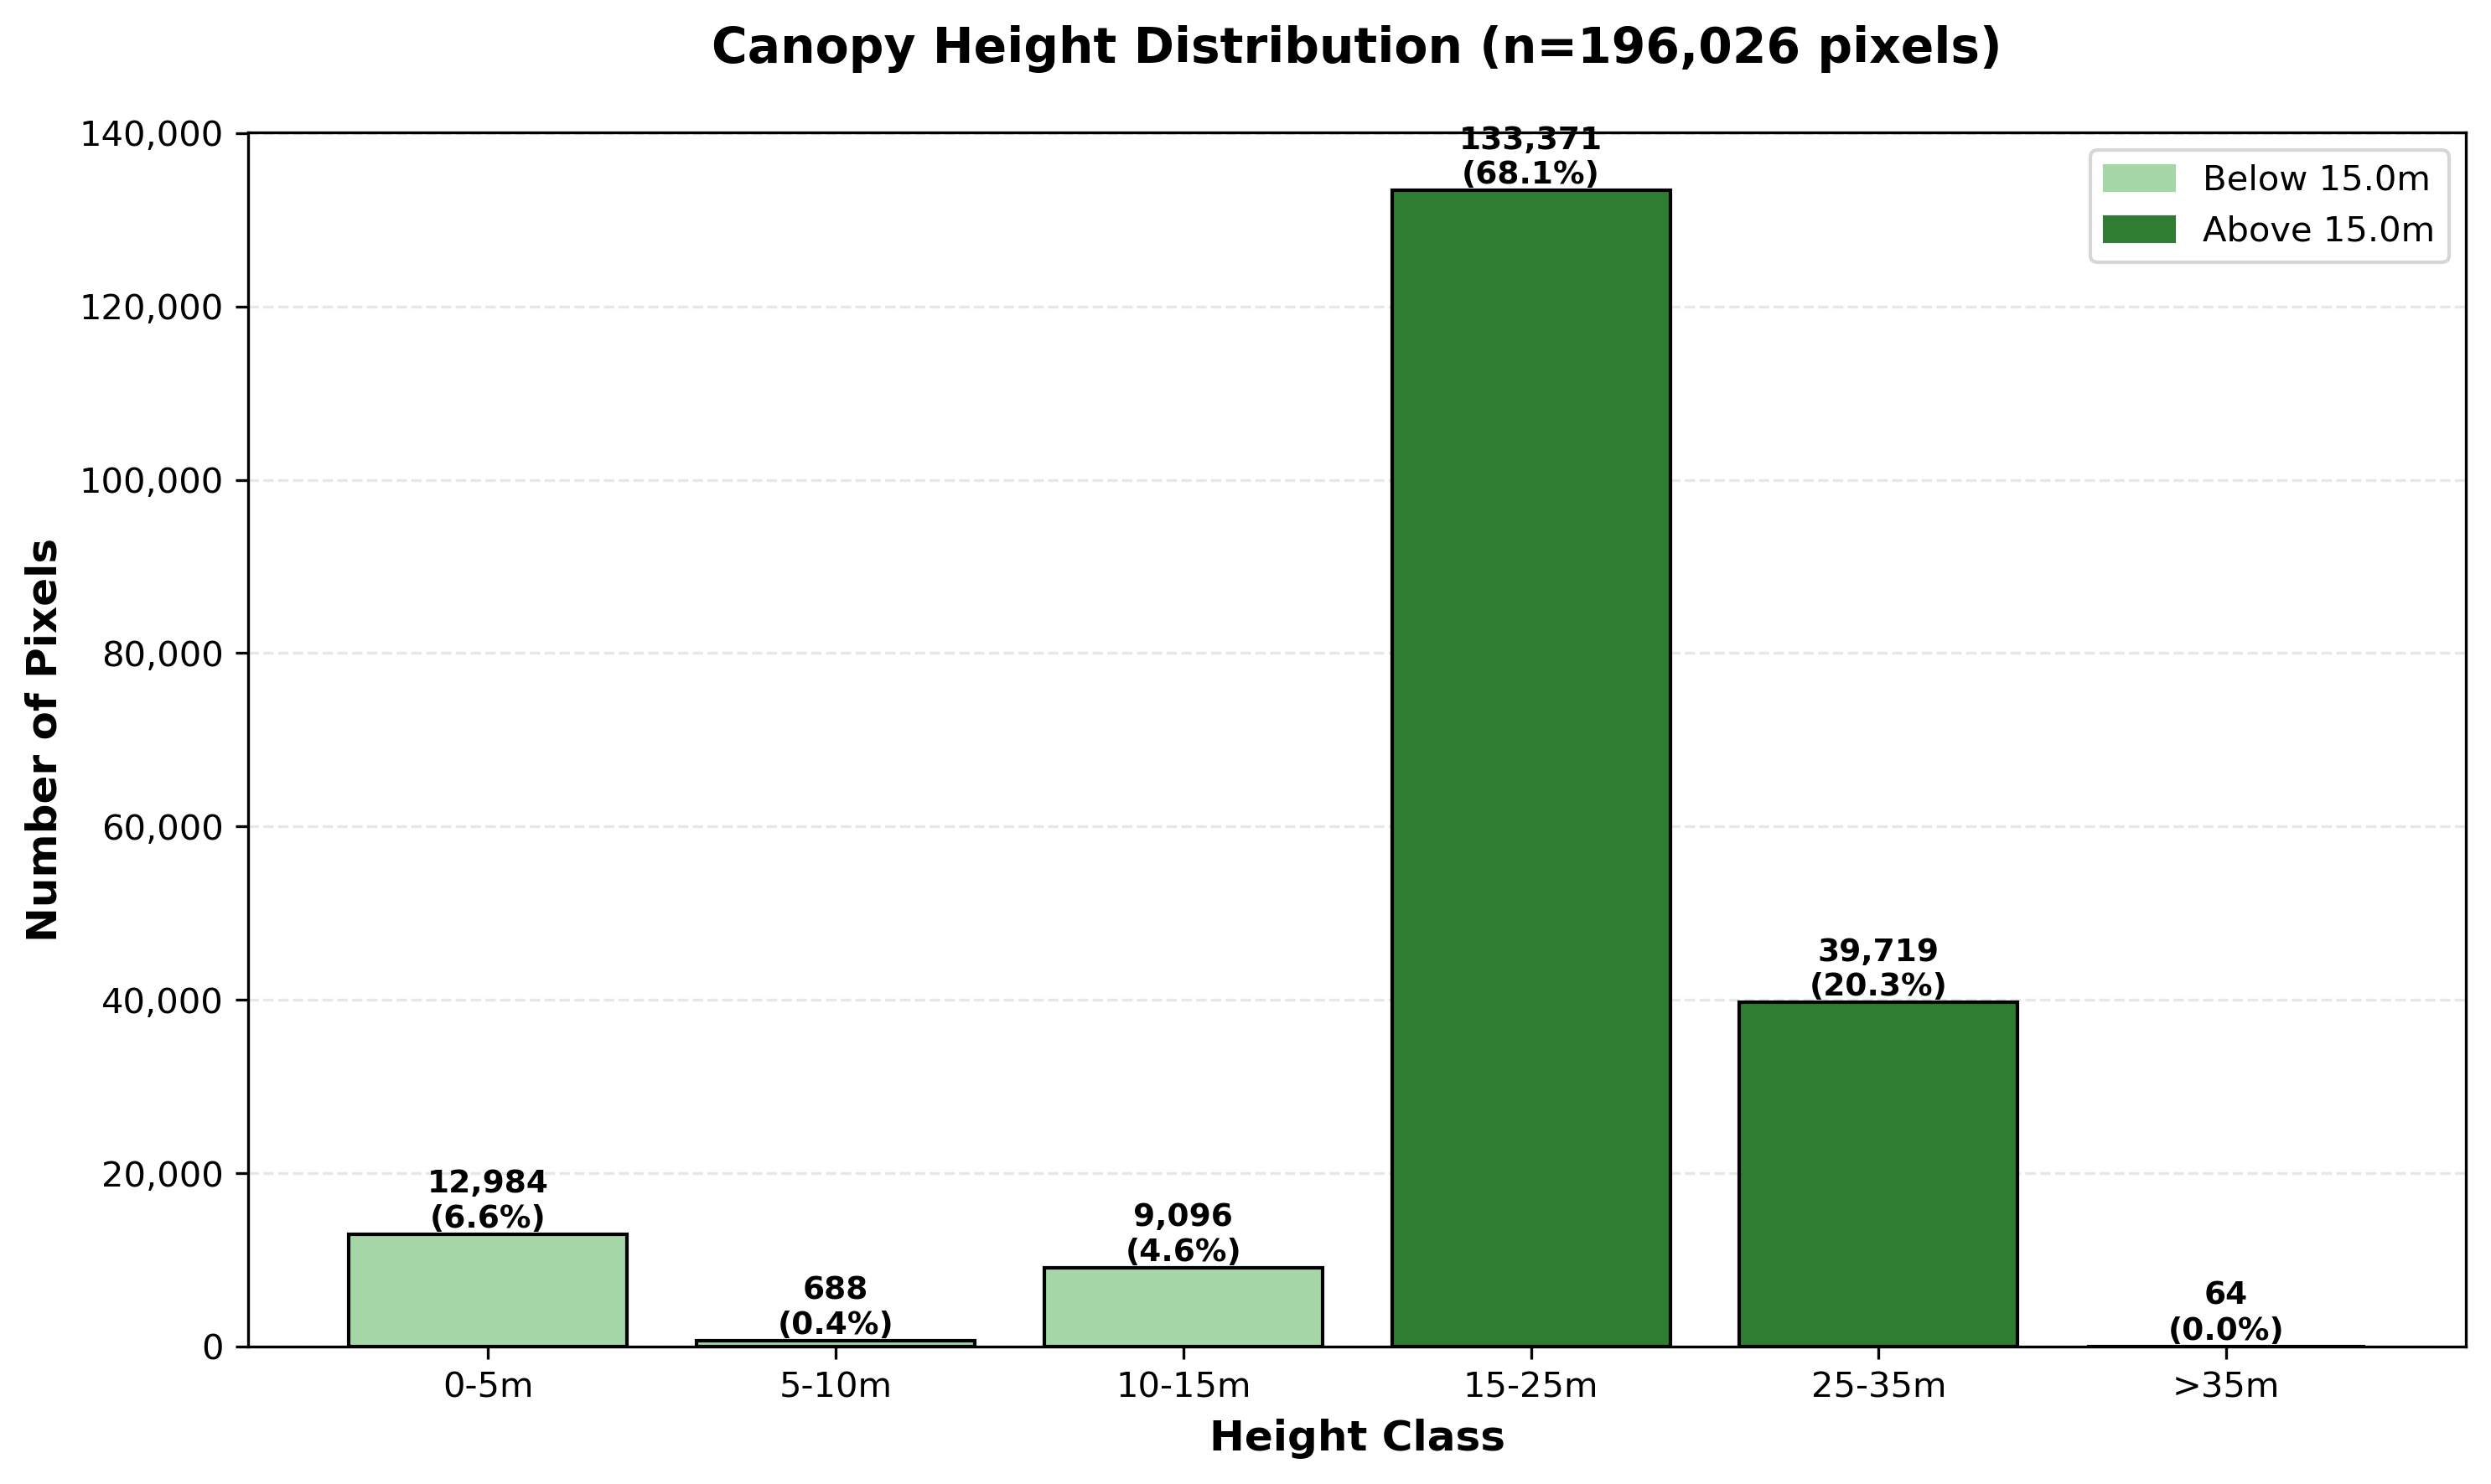


LVP28 (EBE-any)
  Observer:  Licht-Geschlossen/Licht
  Derived:   0.69  (0=light .. 1=closed)
  Mean height: 16.2m | Valid pixels: 196,026


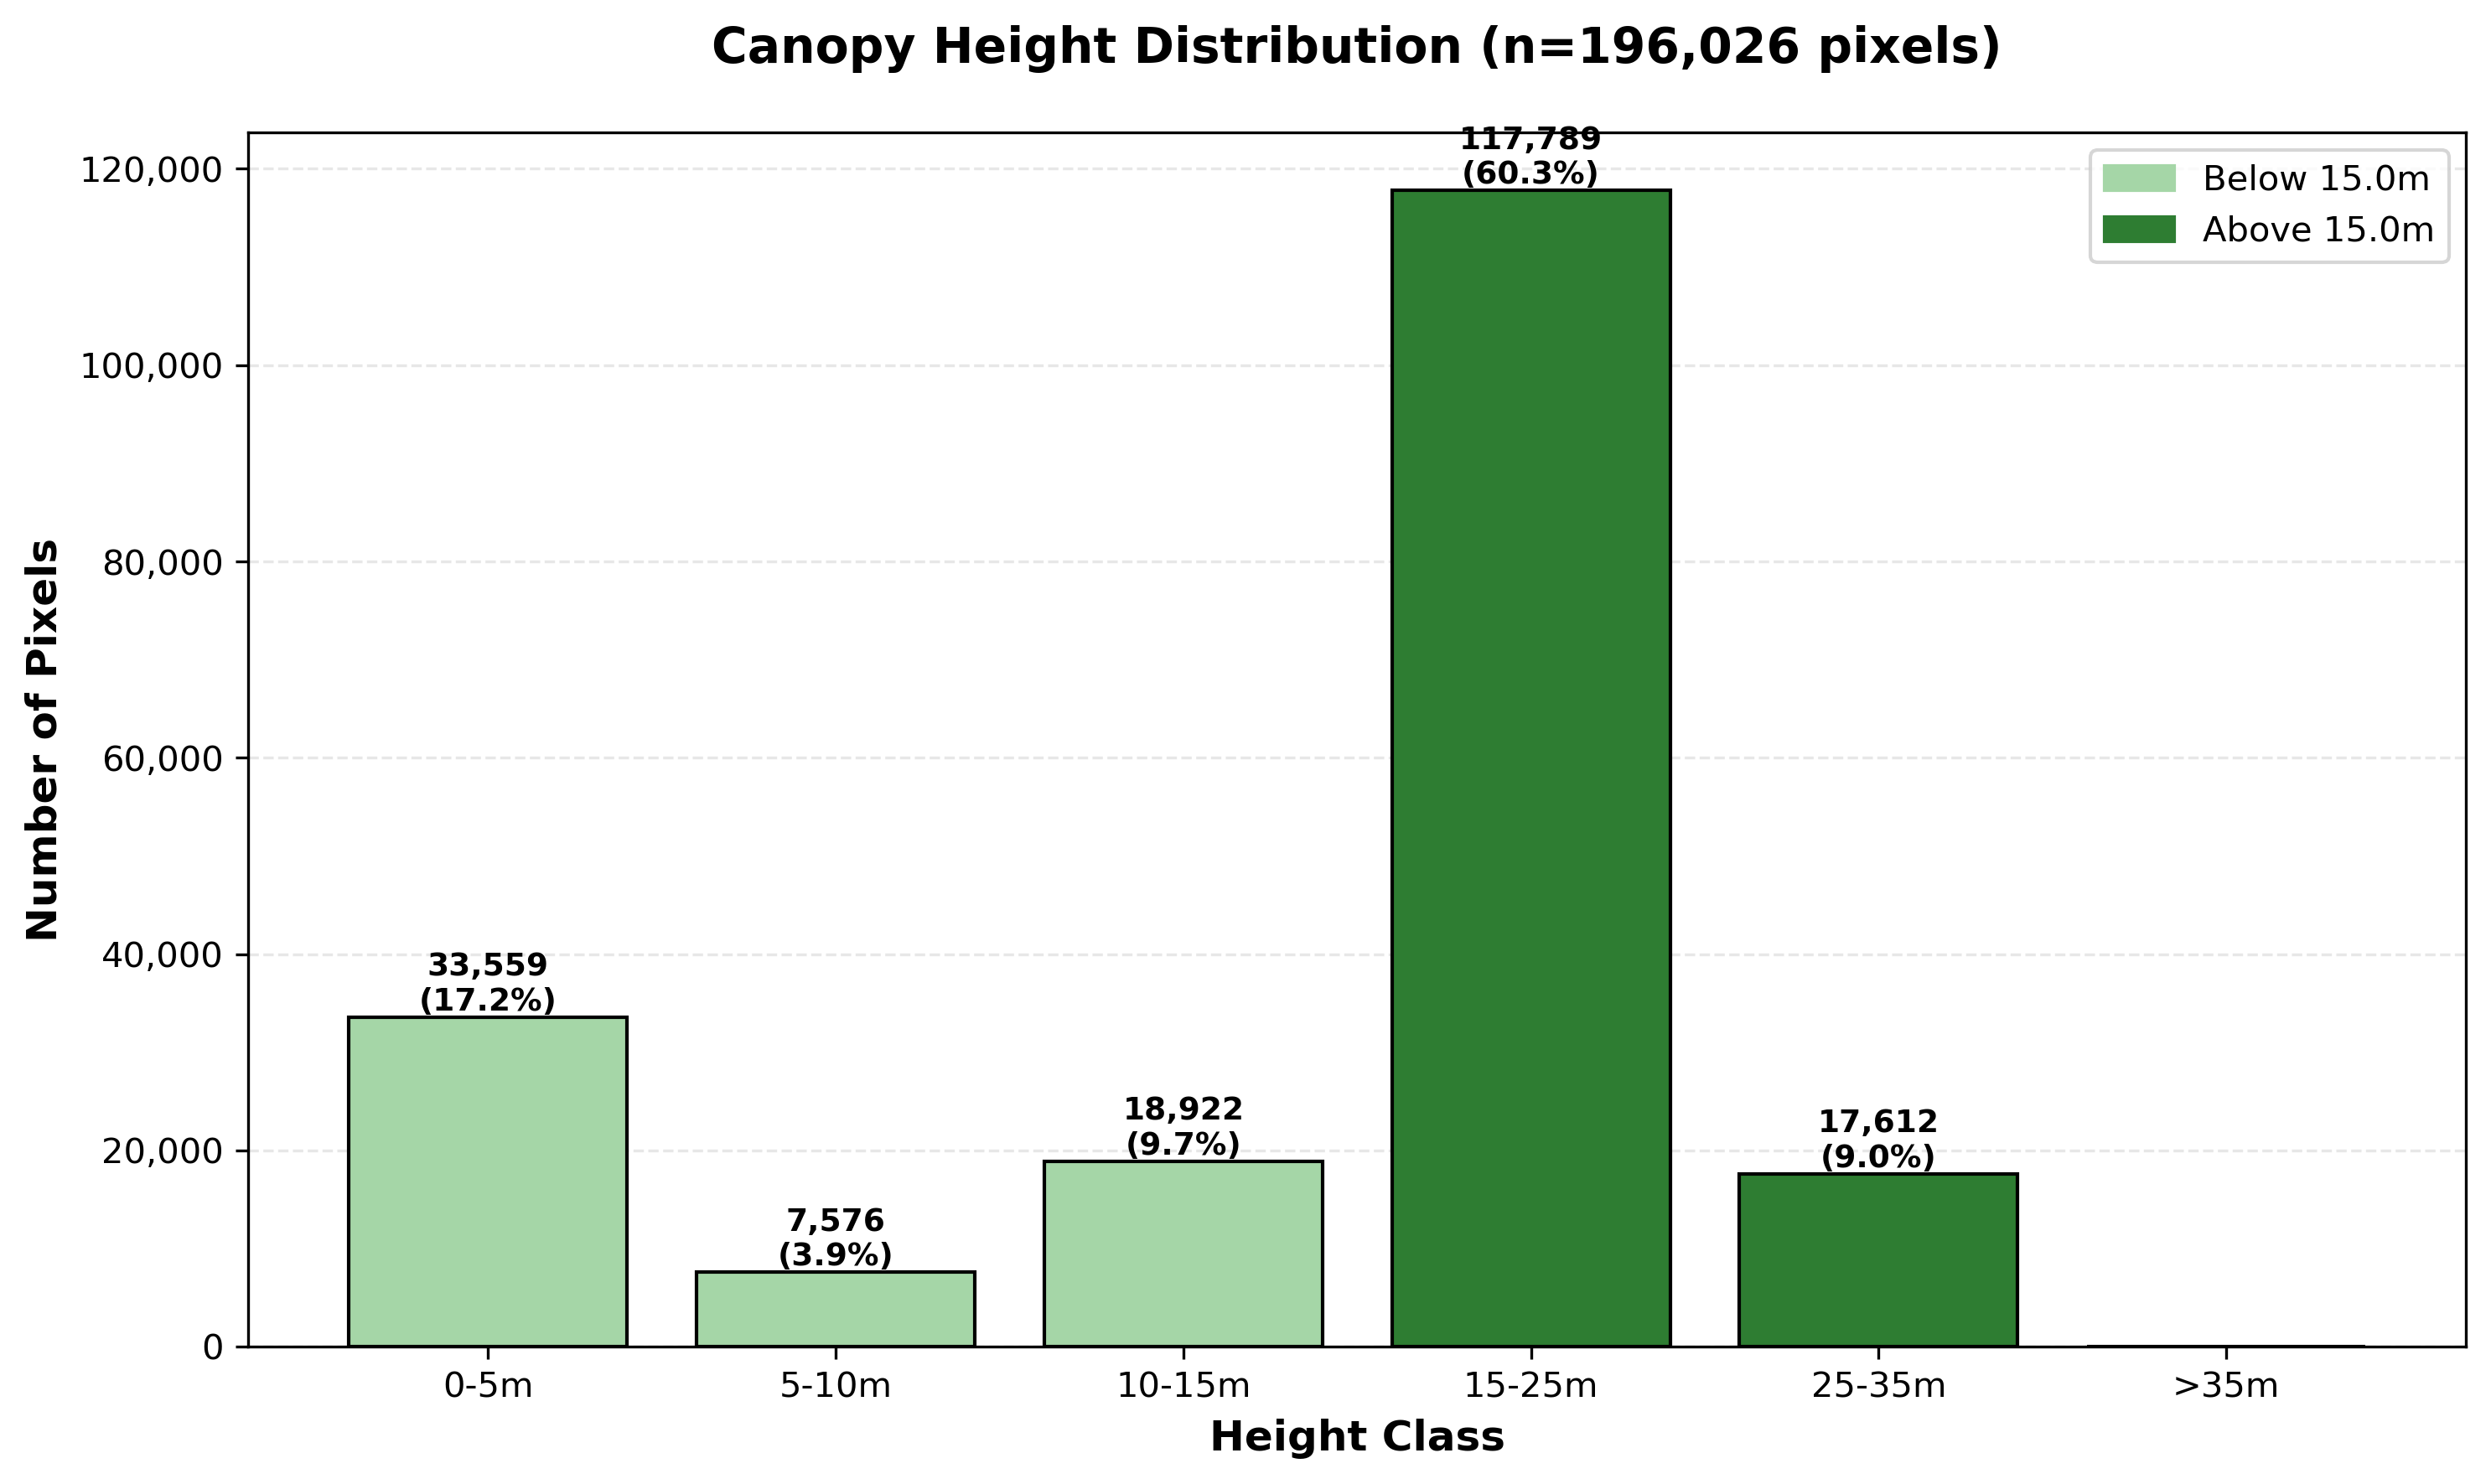


LVP29 (EBE-any)
  Observer:  Licht-Geschlossen/Licht
  Derived:   0.85  (0=light .. 1=closed)
  Mean height: 20.2m | Valid pixels: 196,037


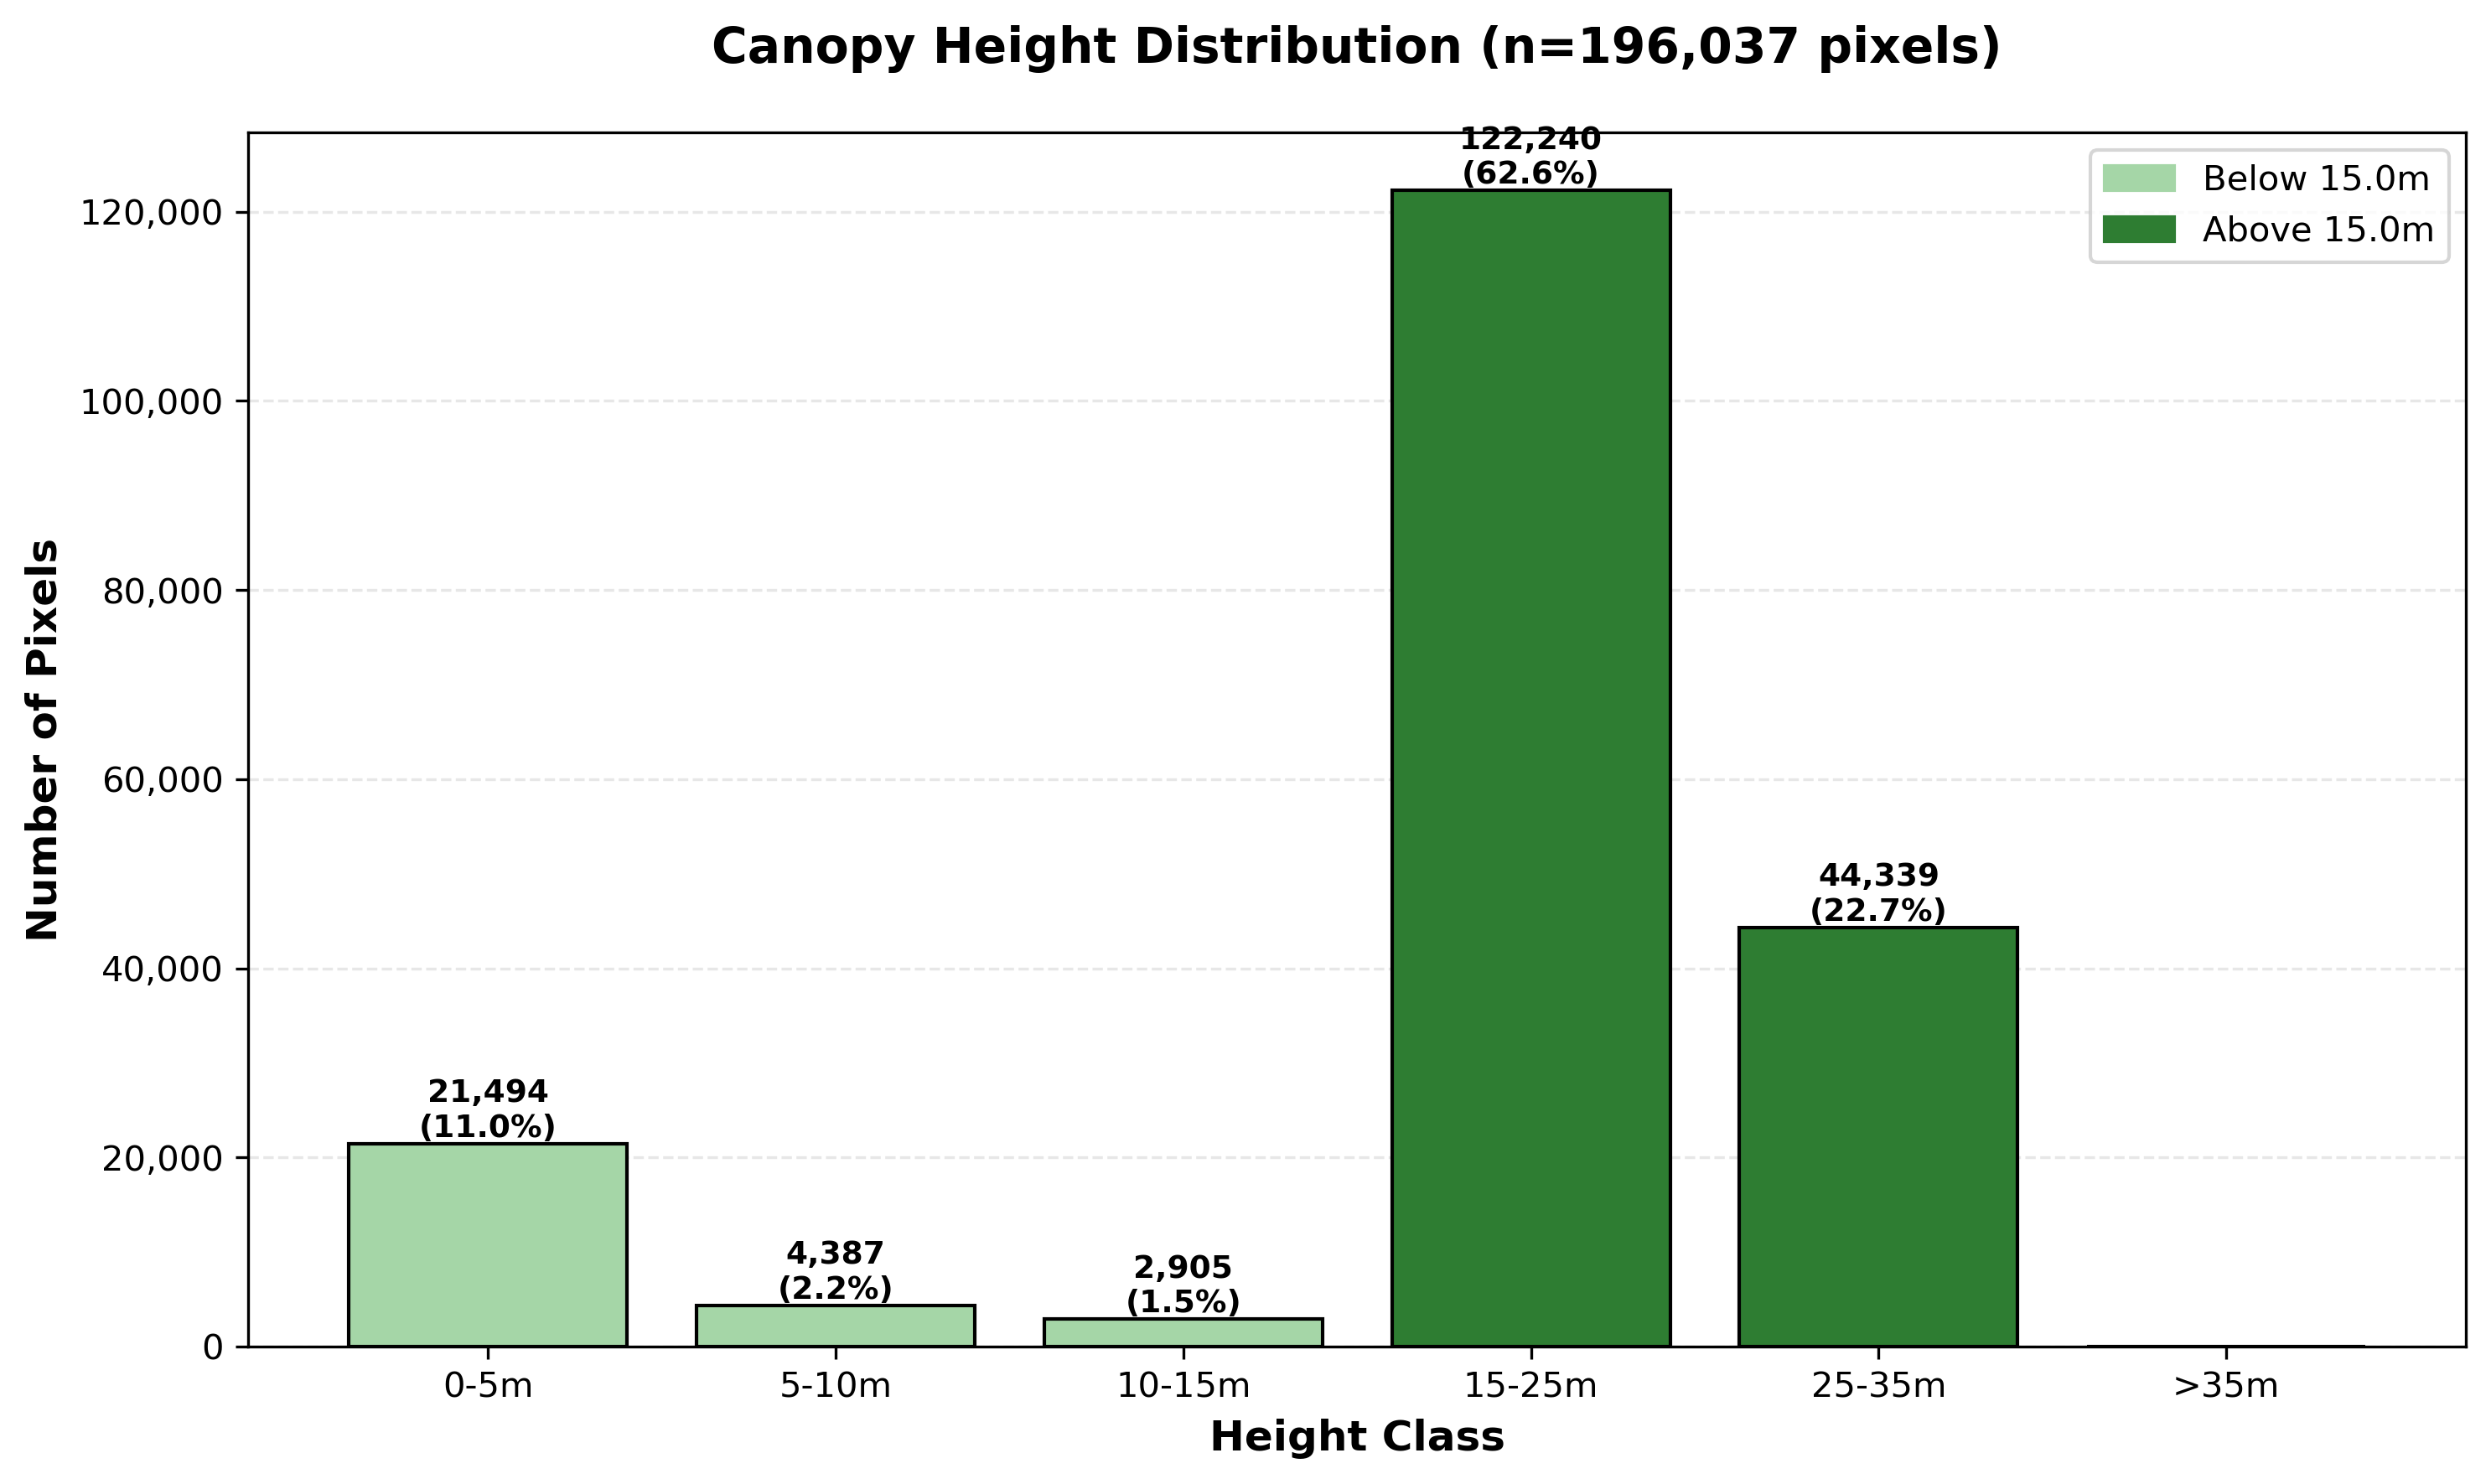


LVP30 (EBE-any)
  Observer:  Geschlossen/Gedrängt
  Derived:   0.97  (0=light .. 1=closed)
  Mean height: 22.7m | Valid pixels: 196,042


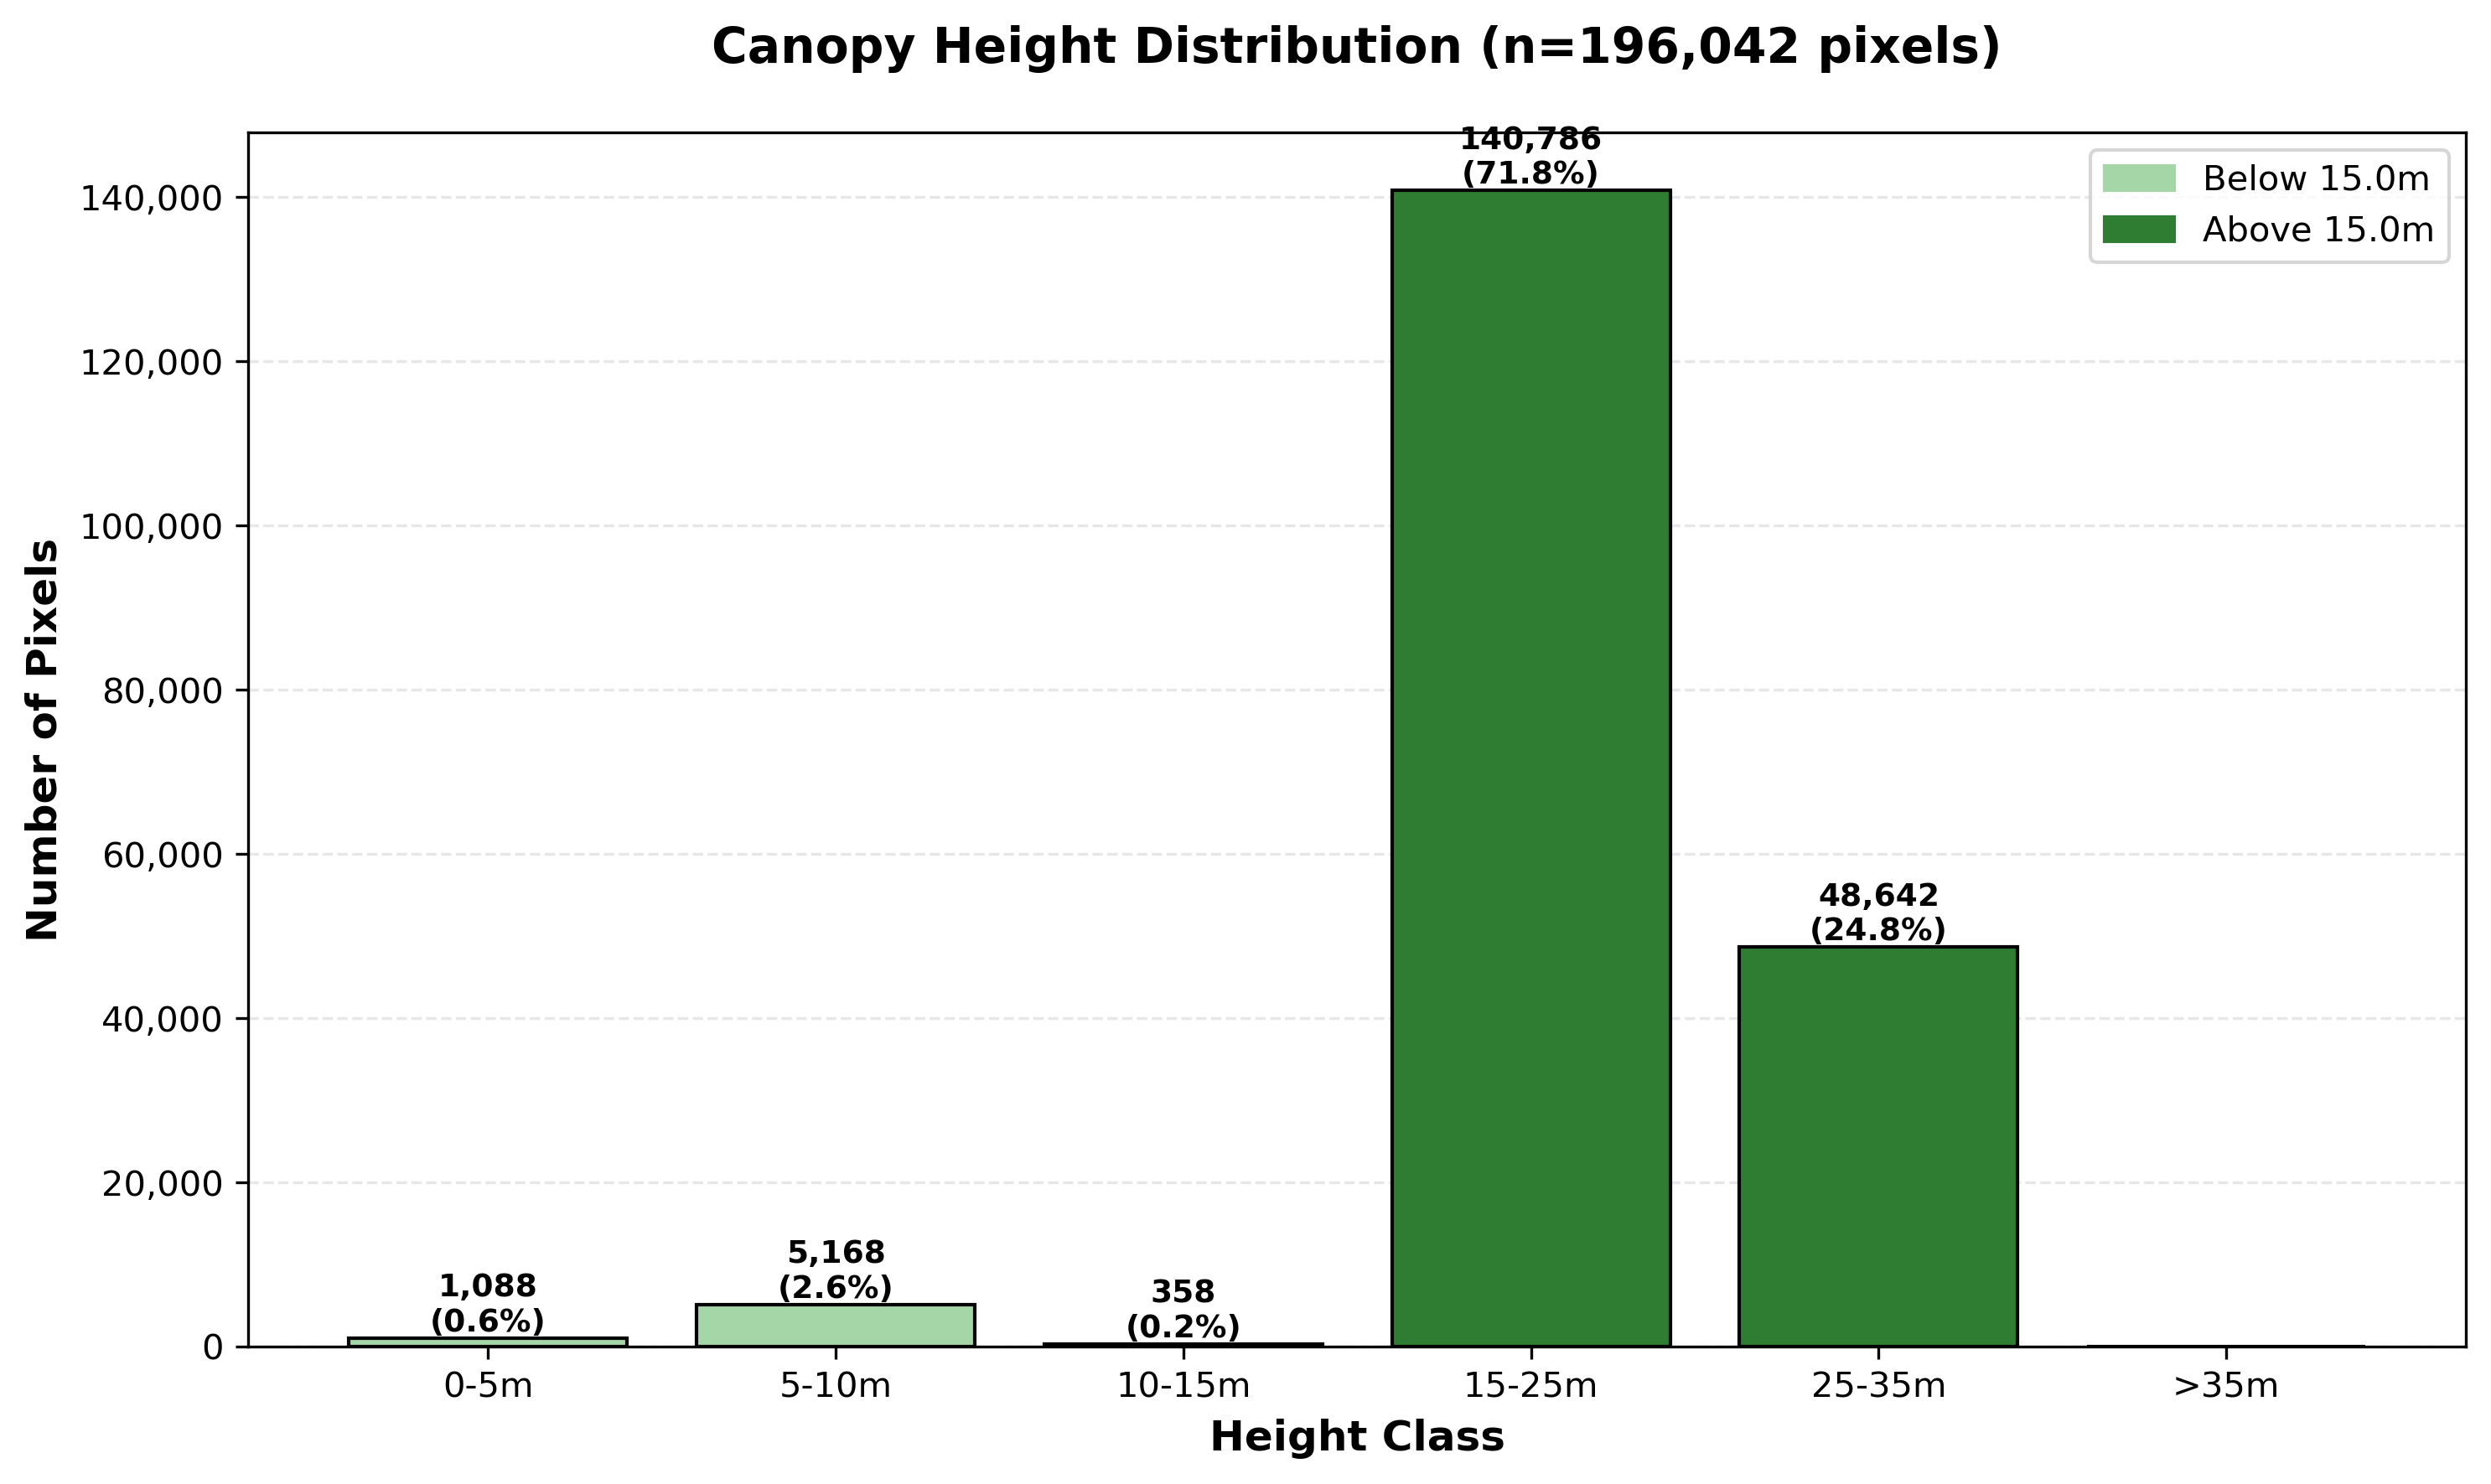


LVP31 (EBE-any)
  Observer:  Lücke < Baumlänge
  Derived:   0.97  (0=light .. 1=closed)
  Mean height: 22.5m | Valid pixels: 196,034


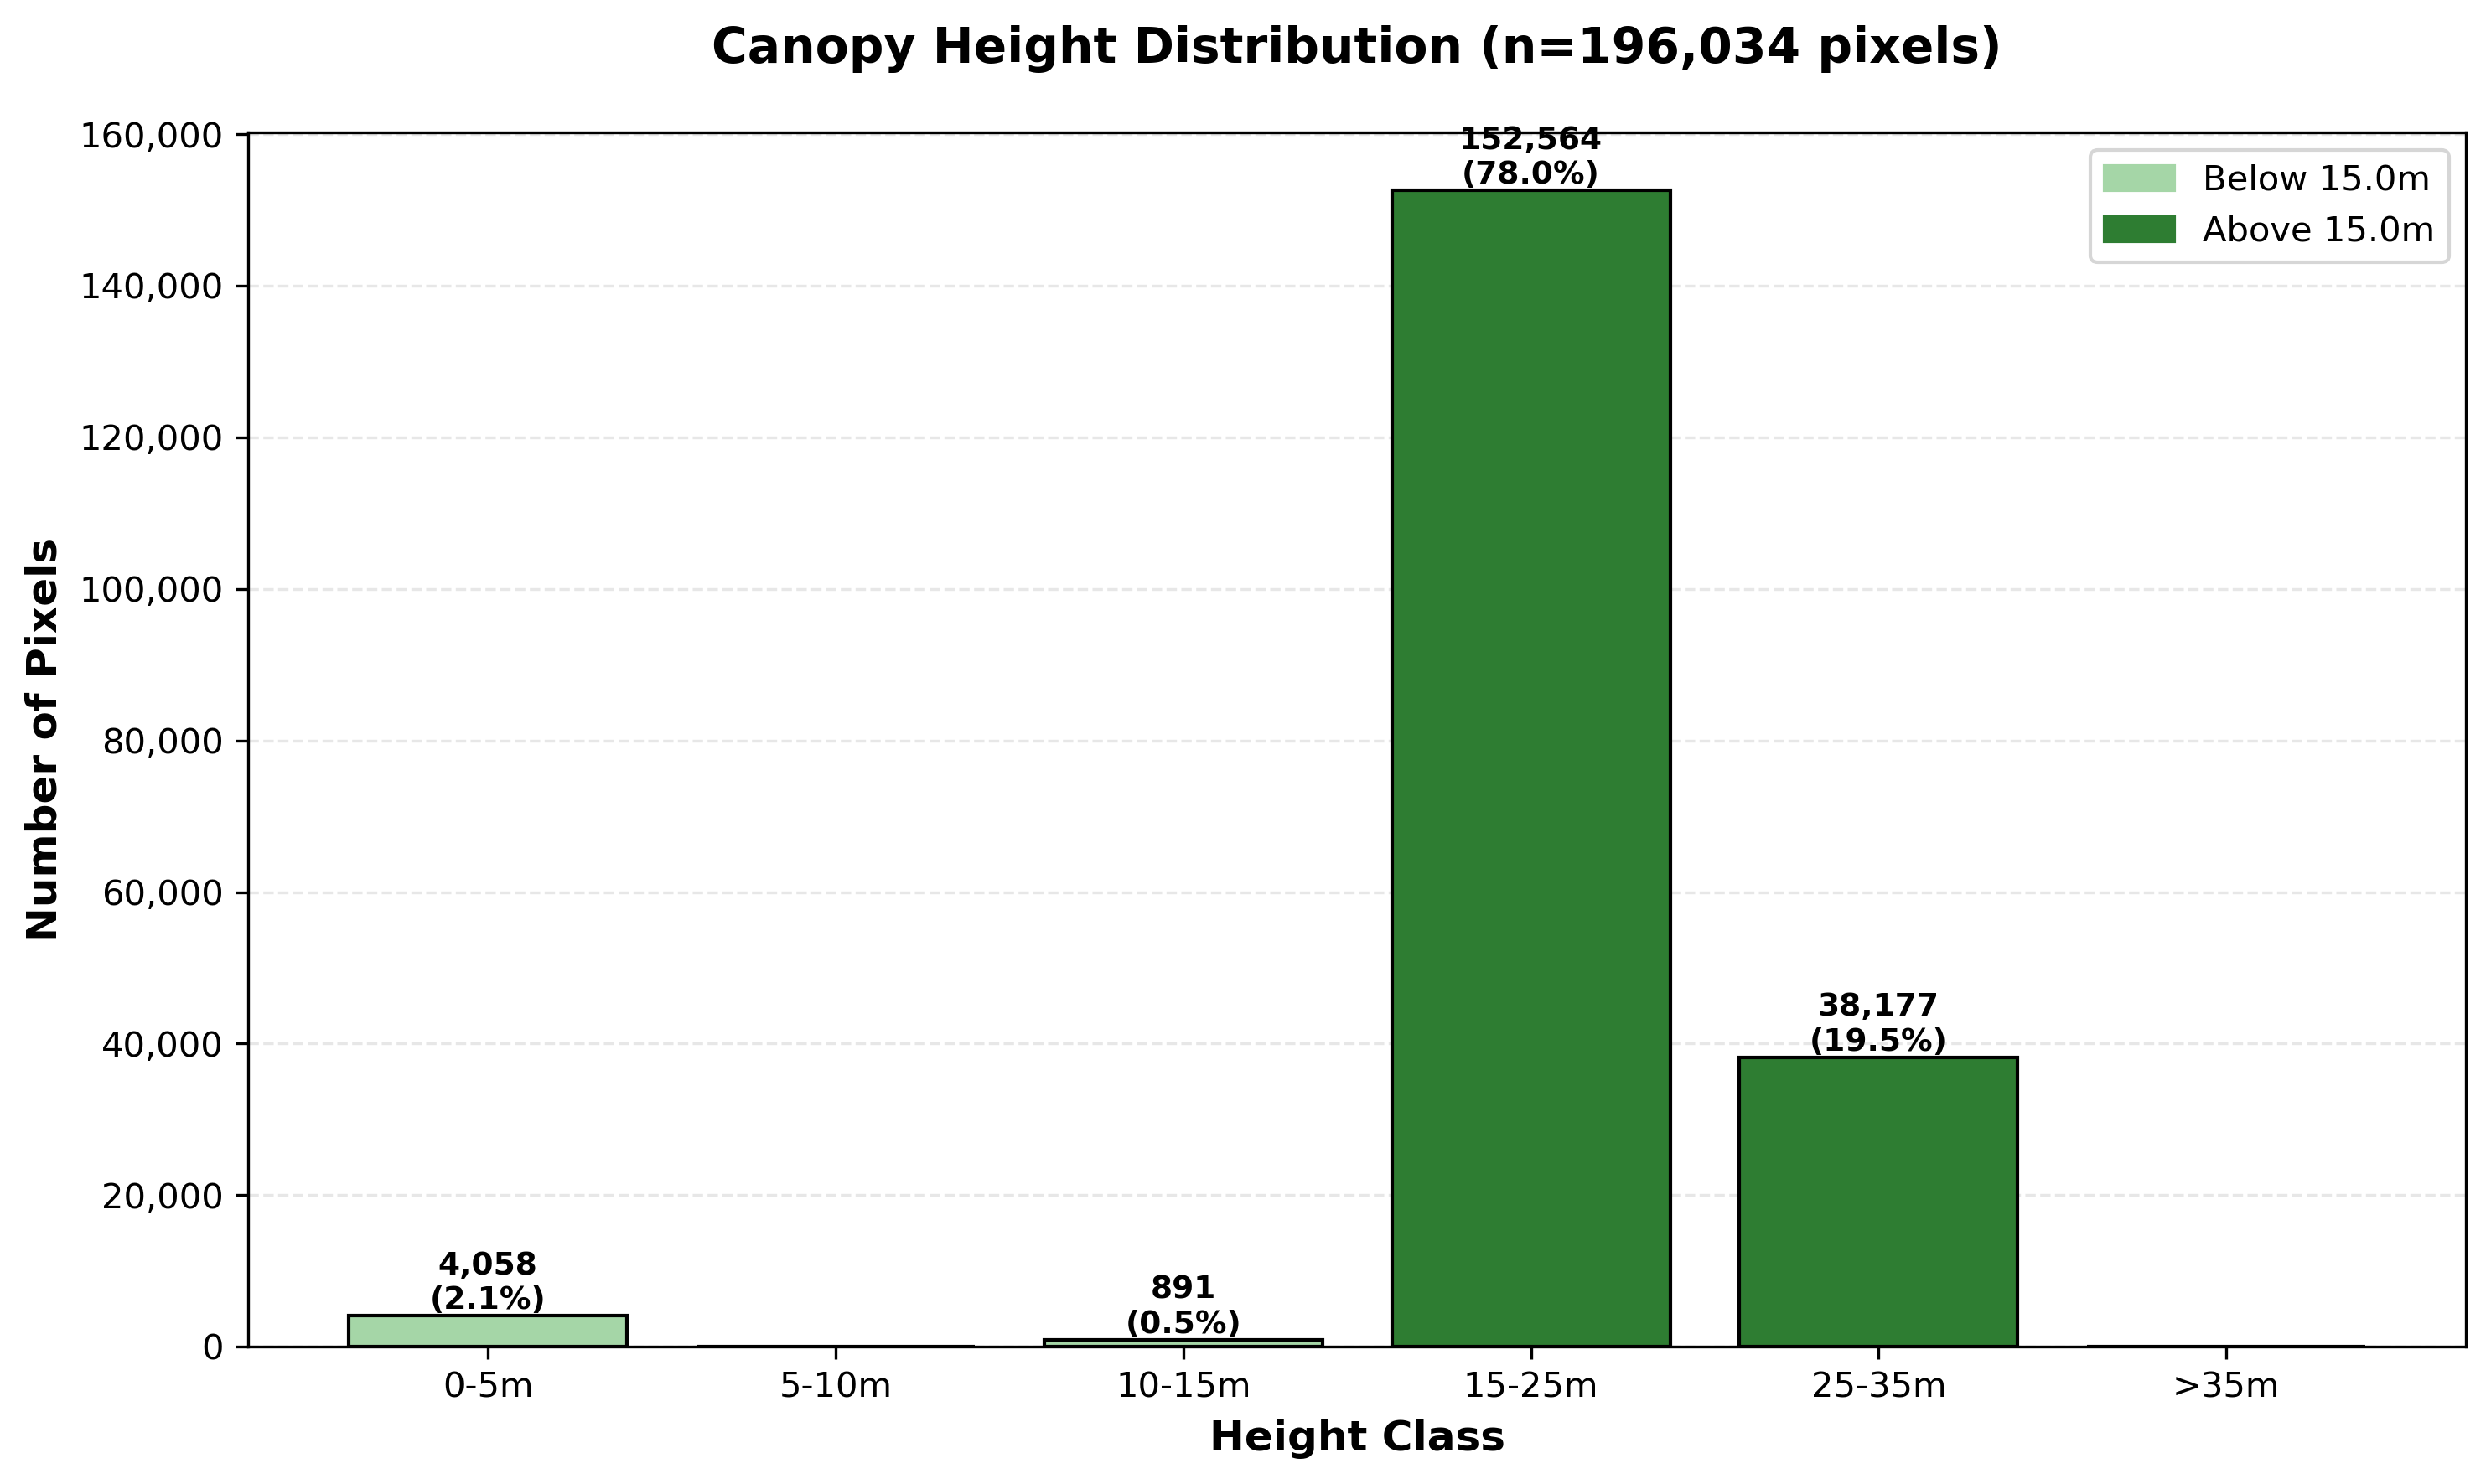


LVP32 (EBE-any)
  Observer:  Licht-Geschlossen/Licht
  Derived:   0.99  (0=light .. 1=closed)
  Mean height: 22.4m | Valid pixels: 196,030


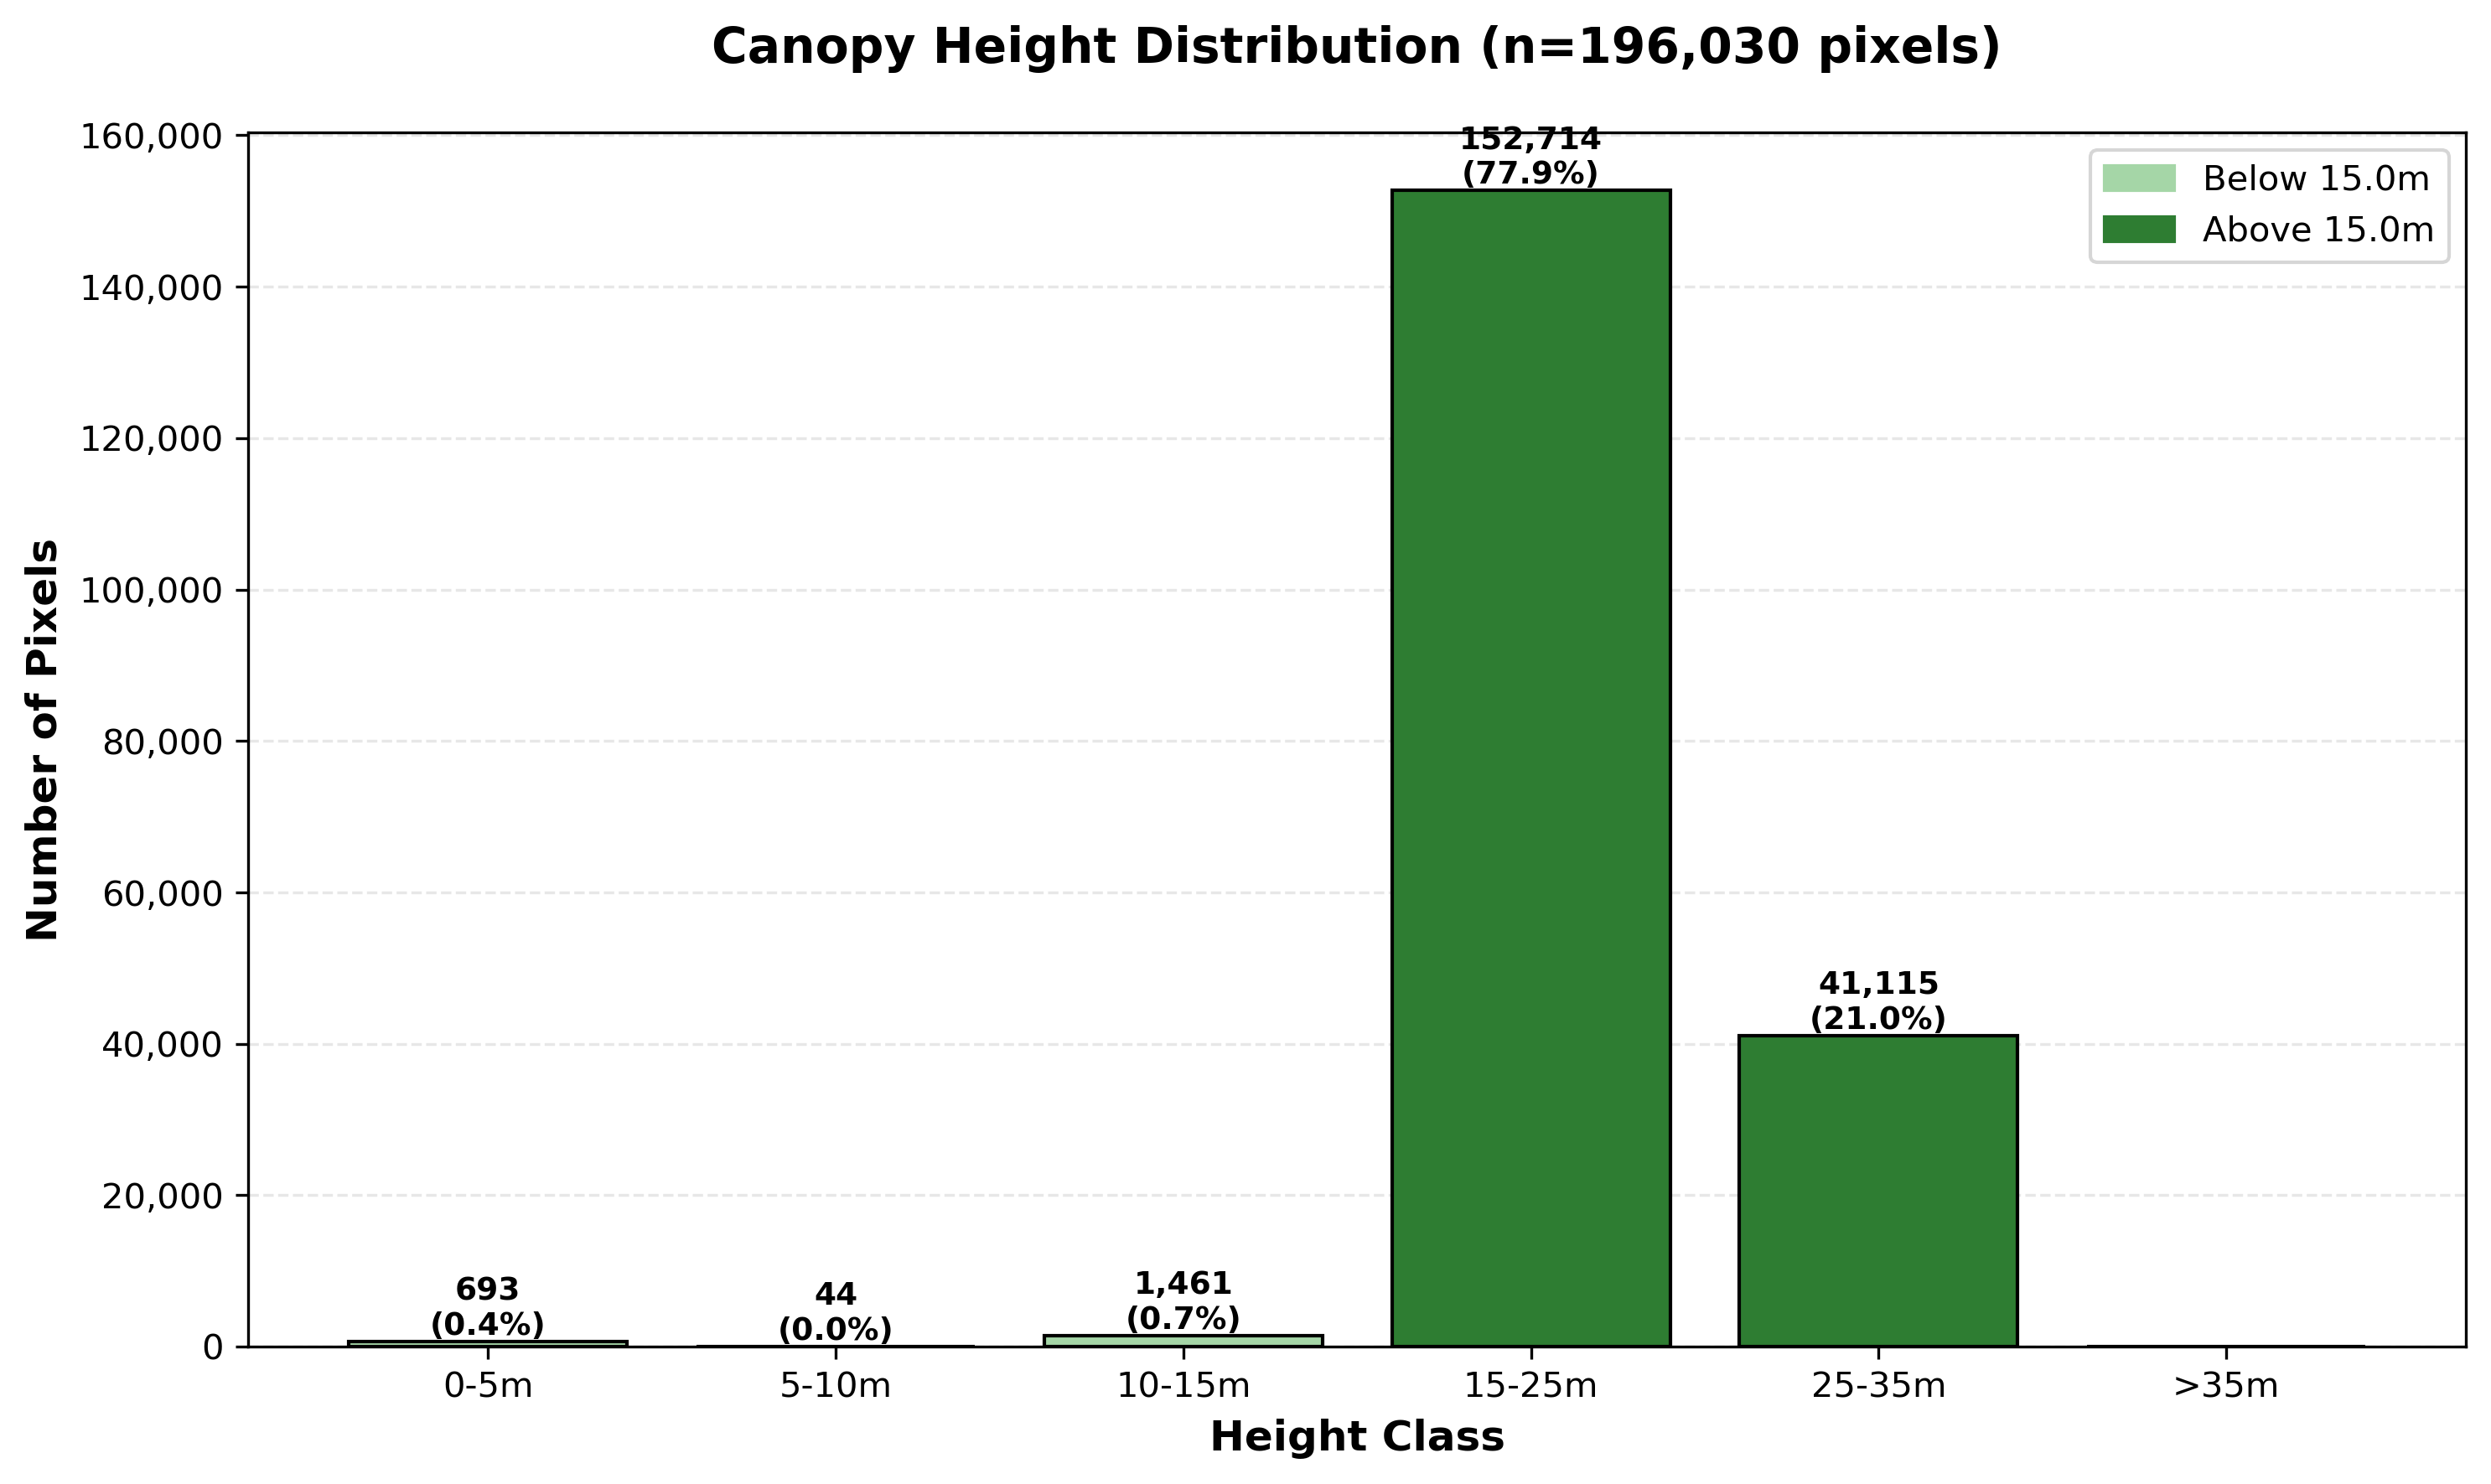


LVP33 (EBE-any)
  Observer:  Geschlossen/Gedrängt
  Derived:   0.99  (0=light .. 1=closed)
  Mean height: 23.5m | Valid pixels: 196,040


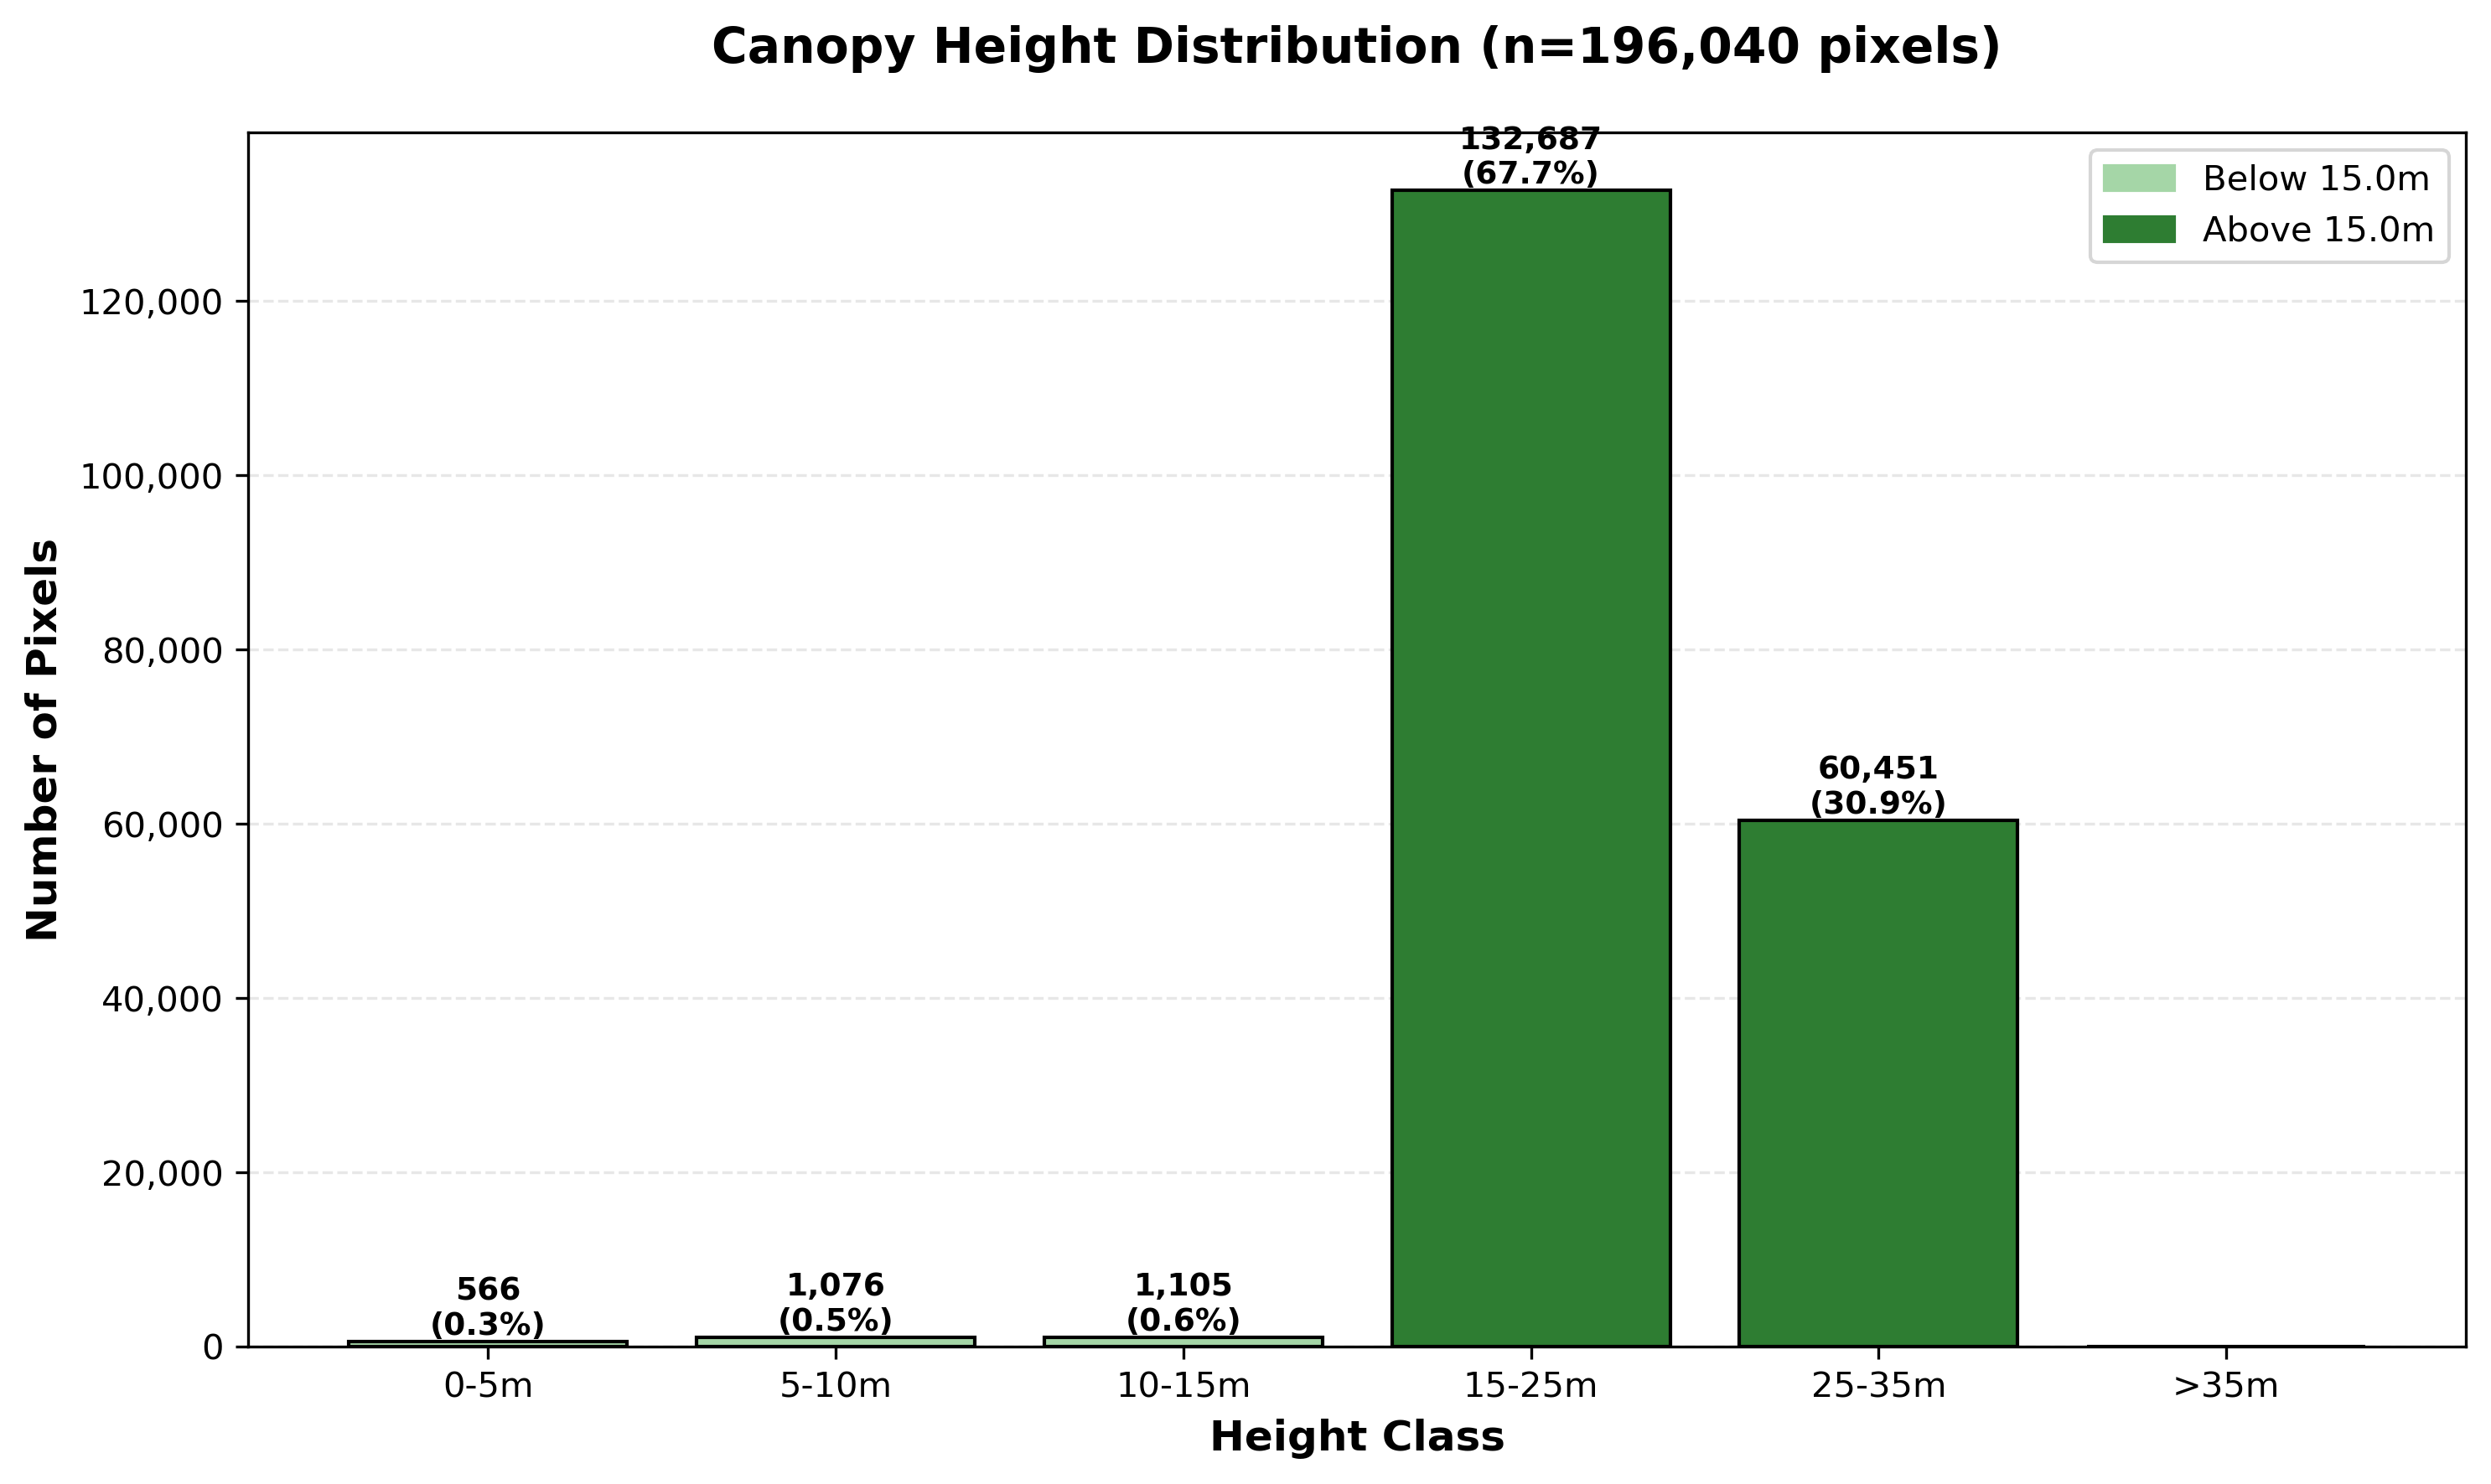


LVP34 (EBE-any)
  Observer:  Geschlossen/Gedrängt
  Derived:   1.00  (0=light .. 1=closed)
  Mean height: 23.3m | Valid pixels: 196,035


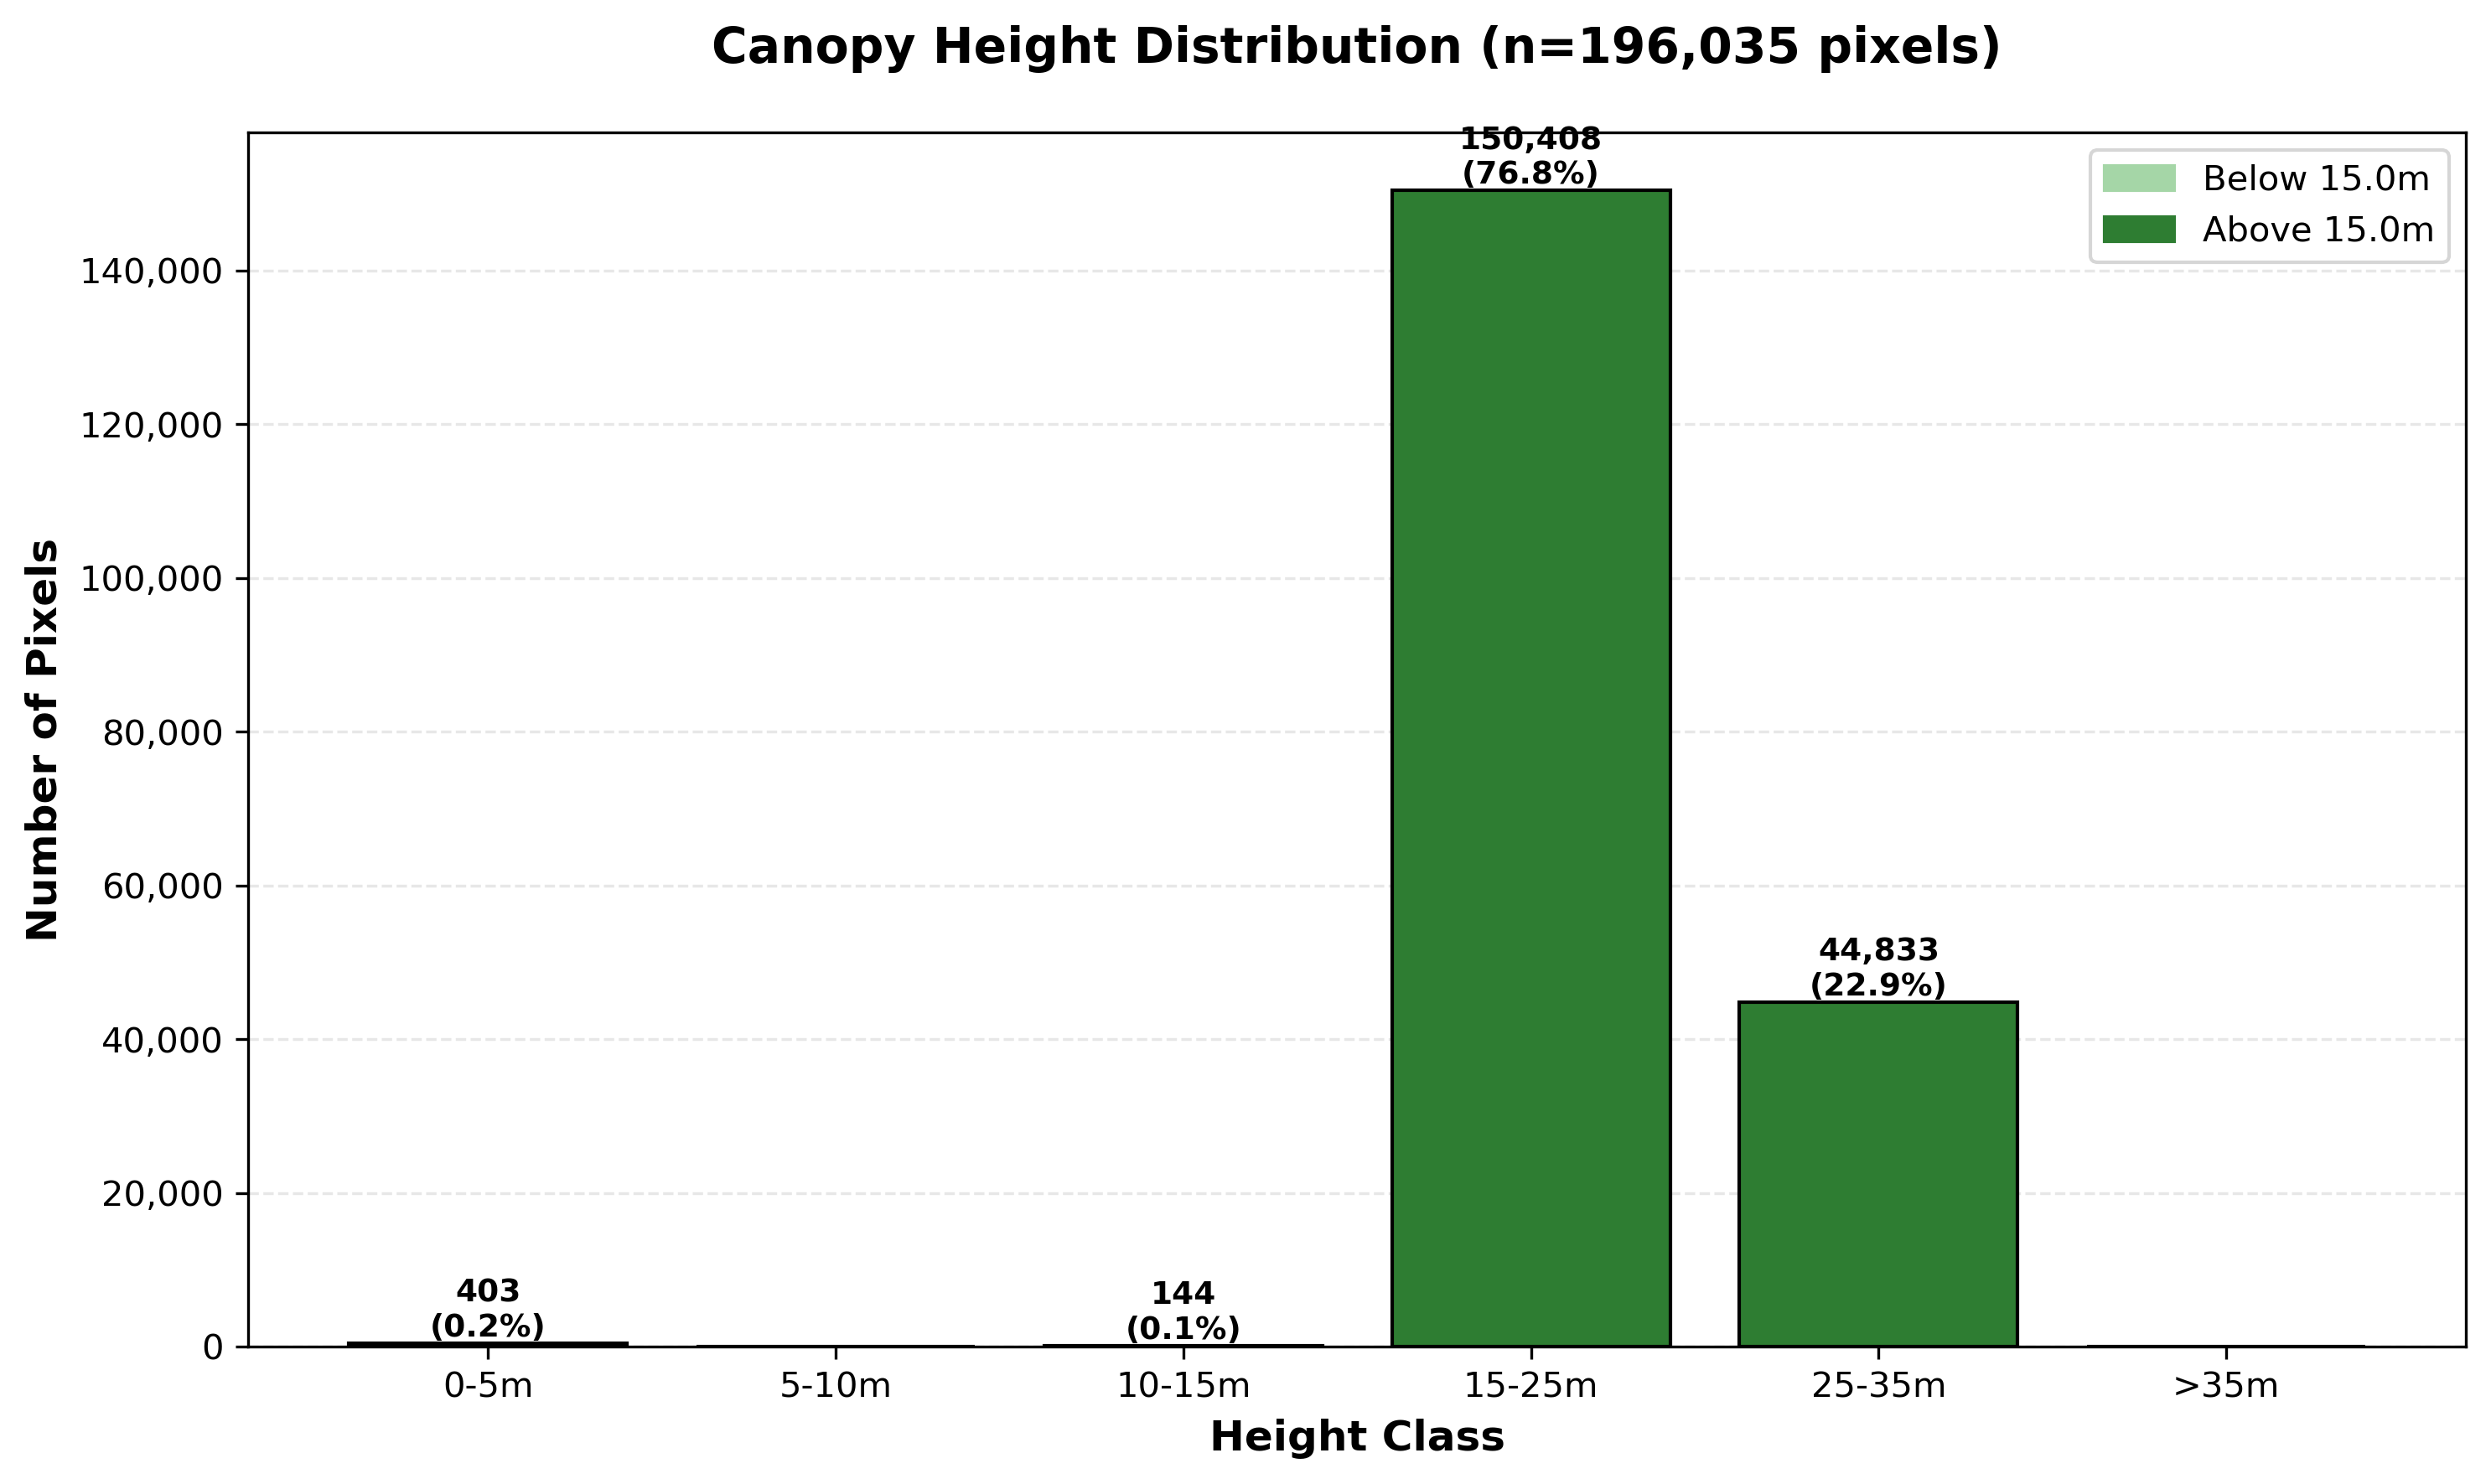


LVP35 (EBE-any)
  Observer:  Geschlossen/Gedrängt
  Derived:   0.84  (0=light .. 1=closed)
  Mean height: 21.8m | Valid pixels: 196,036


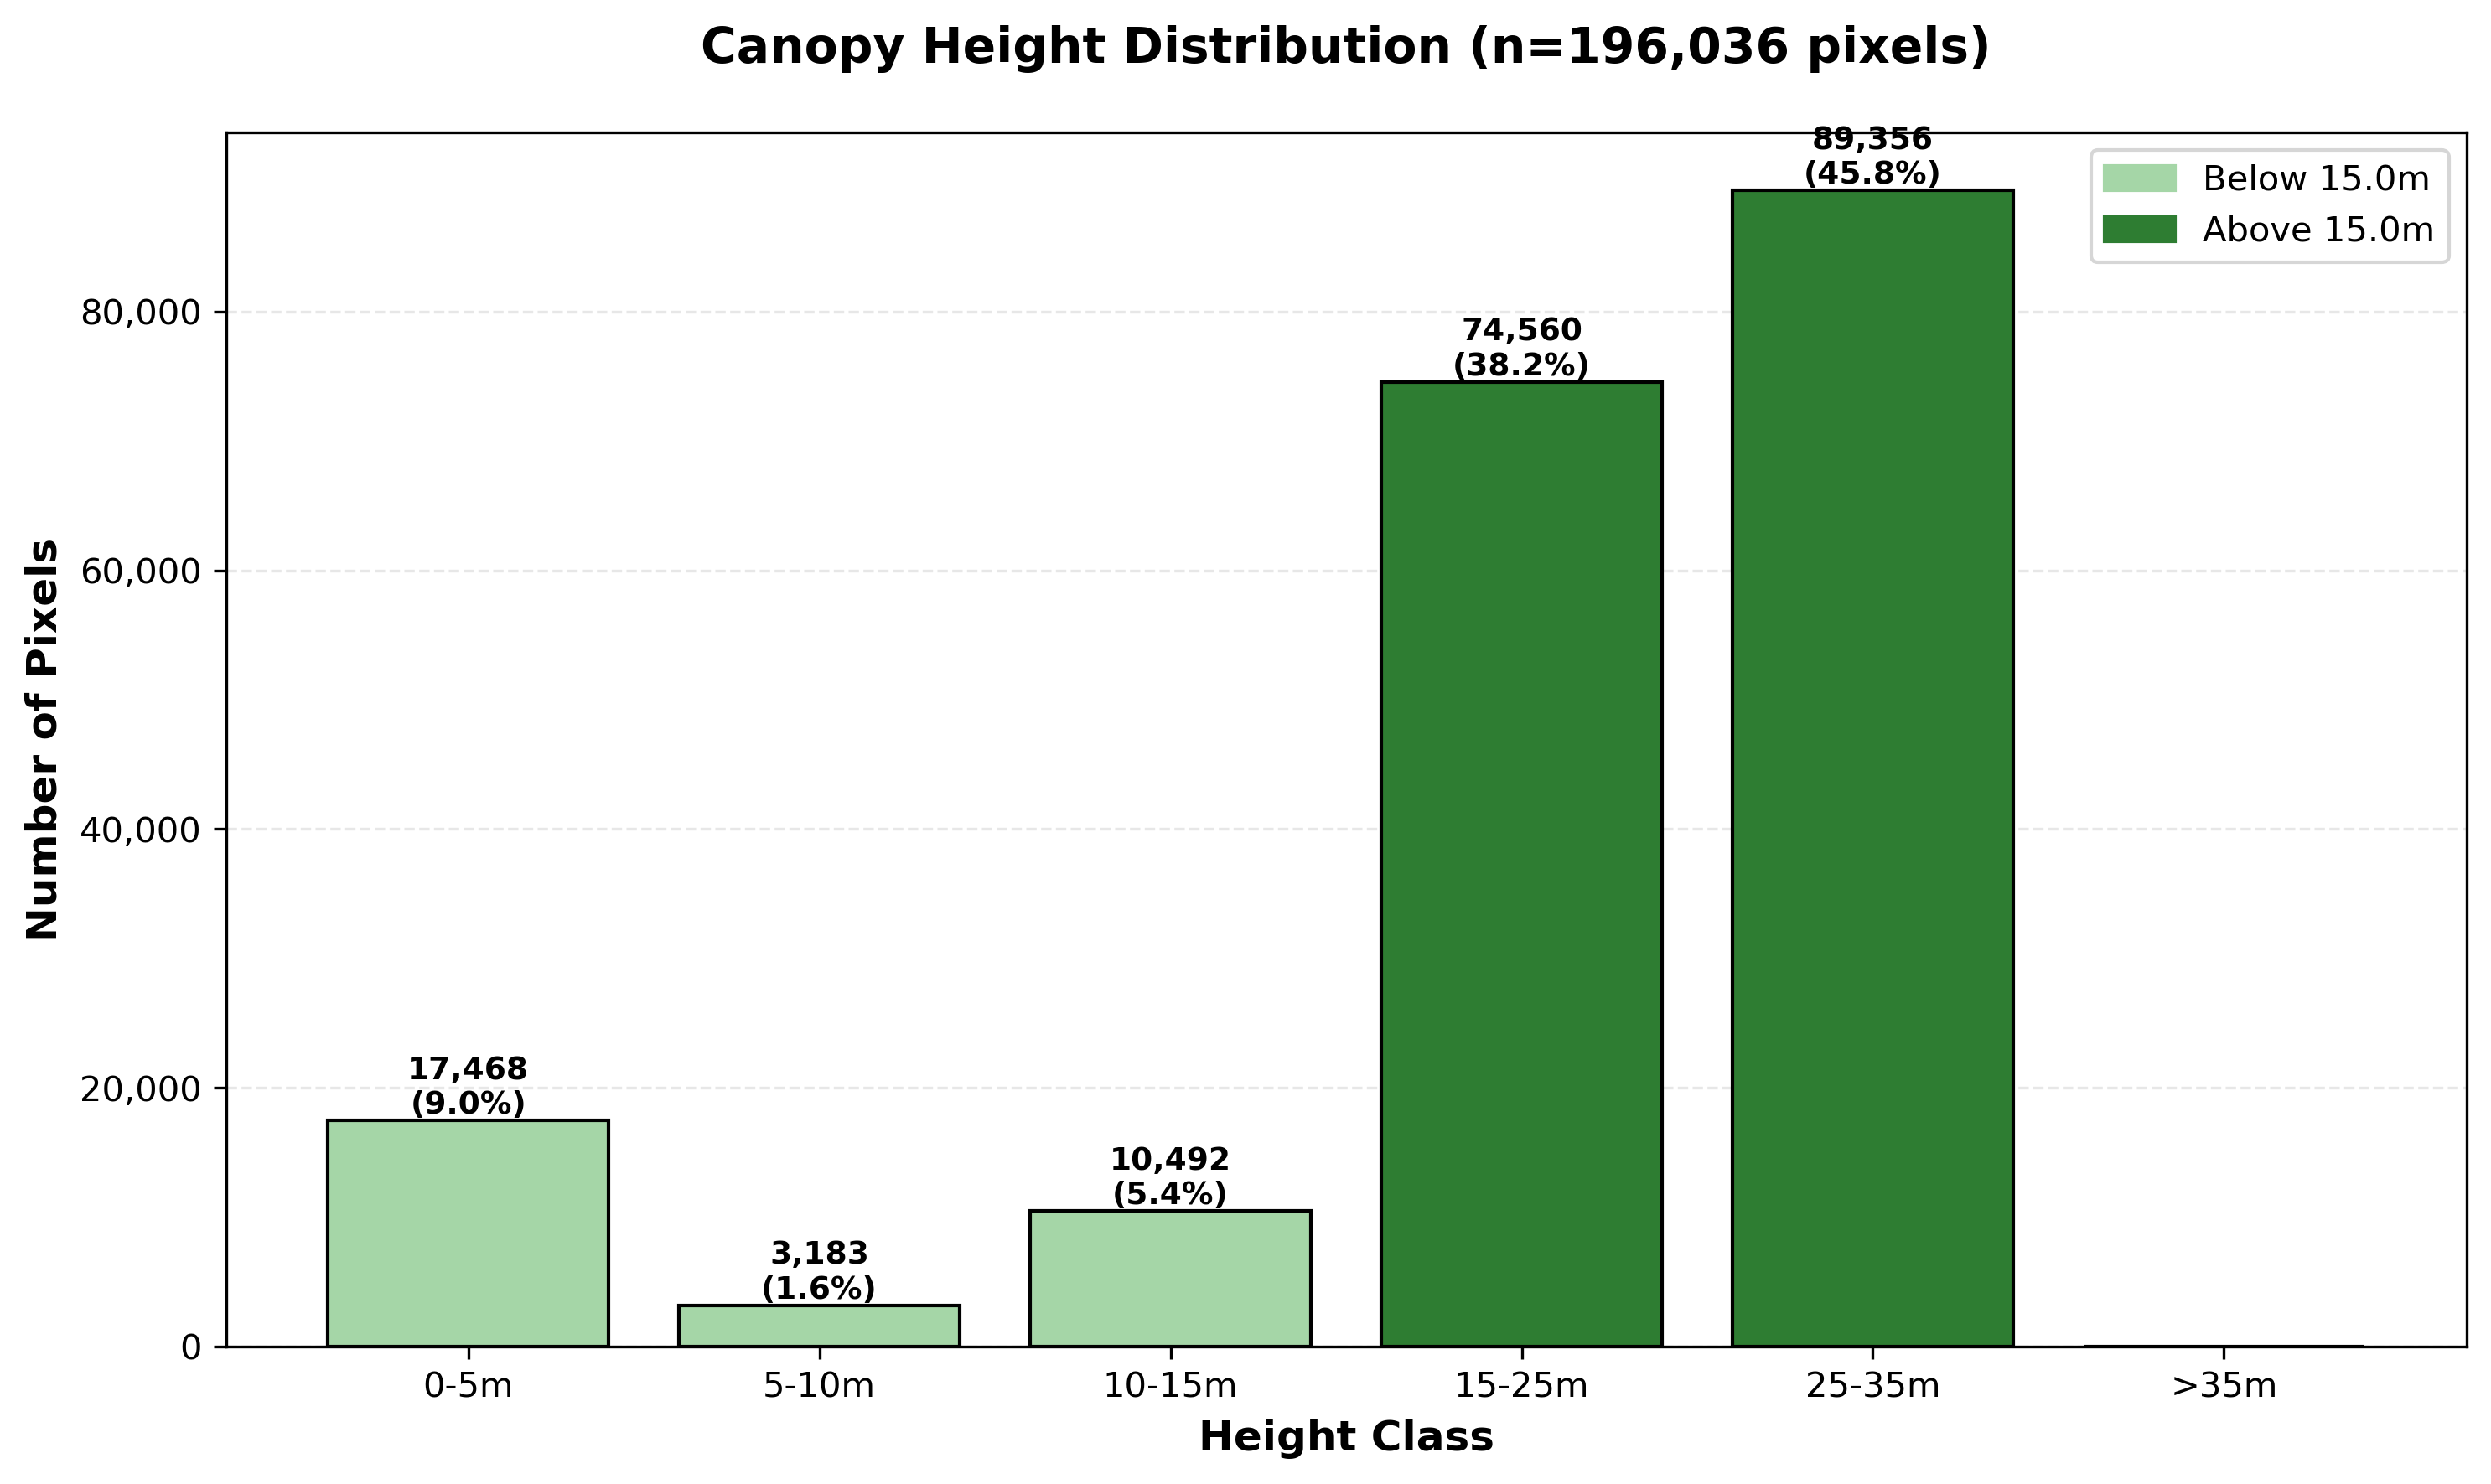

In [30]:
# Individual histogram plot per point (only for points that succeeded)
for row in results_df.itertuples():
    if row.error is not None:
        continue
    print(f"\n{row.point_id}")
    print(f"  Observer:  {row.observer_category}")
    print(f"  Derived:   {row.derived_closure_index:.2f}  (0=light .. 1=closed)")
    print(f"  Mean height: {row.mean_height_m:.1f}m | Valid pixels: {row.valid_pixels:,}")
    display(Image(filename=row.plot_path))

## Section 8: Aggregate Comparison

All points at once: does the derived DSM/DTM closure index track the observer's field
category? Categories are ordered light → closed on the x-axis; each dot is one point,
with the category median marked.

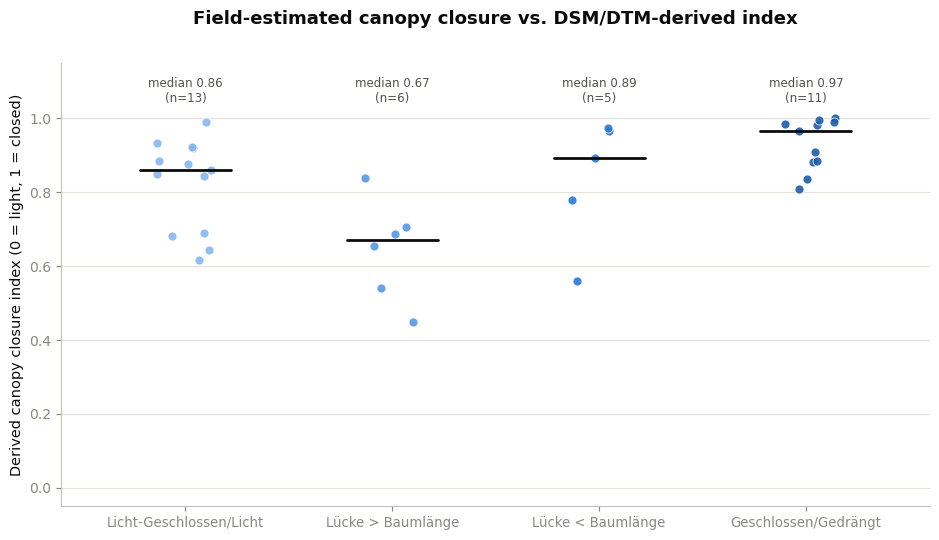

Saved: ../plots/category_comparison.png


In [31]:
valid_results = results_df.dropna(subset=['derived_closure_index'])

fig = plotting.plot_category_comparison(
    categories=valid_results['observer_category'].tolist(),
    values=valid_results['derived_closure_index'].tolist(),
    category_order=CATEGORY_ORDER,
    output_path=COMPARISON_PLOT_PATH,
)
plt.show()

print(f"Saved: {COMPARISON_PLOT_PATH}")

## Section 9: Sanity Checks & Caveats

- **Edge effects**: if a point's buffer extends outside its cluster's downloaded
  bbox, pixels are missing/nodata near the edge. Increase the `margin_m` passed to
  `cluster_bbox_25832` (Section 5) if you see this in `error` messages.
- **Small `valid_pixels` counts**: a very small `POINT_RADIUS_M` at 0.2m resolution
  should still give thousands of pixels; a low count signals nodata coverage
  problems, not real canopy conditions.
- **Threshold sensitivity**: `CANOPY_HEIGHT_THRESHOLD_M` controls what counts as
  "canopy" — lower it (e.g. 5m) to also capture shrub/regeneration layers blocking
  light, raise it to isolate only mature overstory.
- **`EBE-any` points**: these aren't a single tight plot — they span several km
  and land in multiple independent download clusters (see Section 4's cluster
  table); that's expected.